# **Arquitectura Predictiva de Diabetes Basada en Optimización Multi-Modelo y Aprendizaje Automático**

## **Análisis Exploratorio de Indicadores de Salud y Factores Asociados a la Diabetes en la Encuesta BRFSS 2015**

## **1. Introducción**


La diabetes es una de las enfermedades crónicas más prevalentes en los Estados Unidos y representa un problema significativo de salud pública a nivel mundial. Se trata de una condición metabólica caracterizada por niveles elevados de glucosa en sangre, producida cuando el organismo no genera insulina suficiente, no la produce en absoluto, o no la utiliza correctamente. La insulina, hormona secretada por el páncreas, permite que la glucosa ingrese a las células para ser aprovechada como energía; cuando este proceso falla, el azúcar se acumula en el torrente sanguíneo con consecuencias progresivamente graves.

A nivel nacional, más de 40 millones de estadounidenses viven con diabetes, y más de 1 de cada 4 adultos afectados desconoce su condición, lo que retrasa el diagnóstico y eleva el riesgo de complicaciones. La enfermedad figura como la séptima causa principal de muerte en el país y es el factor desencadenante más frecuente de insuficiencia renal, amputaciones de miembros inferiores y ceguera en adultos. En términos económicos, su costo ascendió a 640 mil millones de dólares en 2021, equivalente al 25% de todo el gasto en atención médica del país.
Frente a este panorama, el análisis exploratorio de los factores de riesgo asociados a la enfermedad se convierte en una herramienta clave para orientar estrategias preventivas. El presente estudio aborda esta problemática mediante el análisis del conjunto de datos BRFSS 2015, con el fin de identificar patrones poblacionales y asociaciones entre variables conductuales, clínicas y sociodemográficas con la presencia de diabetes.

## **2. Objetivo del análisis**

Desarrollar y optimizar modelos de clasificación para la detección temprana de diabetes y prediabetes en la población adulta de Estados Unidos, utilizando el conjunto de datos BRFSS 2015, mediante la aplicación de técnicas avanzadas de optimización de hiperparámetros y estrategias de manejo del desbalance de clases.


### **2.1 Objetivos específicos**

- Describir la distribución de la variable objetivo (presencia o ausencia de diabetes).
- Analizar el comportamiento individual de las variables numéricas y categóricas del conjunto de datos.
- Identificar patrones visuales y posibles asociaciones entre factores de riesgo (como índice de masa corporal, presión arterial, consumo de alcohol, actividad física, entre otros) y la diabetes.
- Comparar grupos poblacionales según características como edad, educación, ingreso y sexo.
- Detectar tendencias, contrastes y relaciones relevantes que aporten comprensión al fenómeno estudiado.
- Implementar y evaluar siete modelos de clasificación — K-Nearest Neighbors, Gaussian Naive Bayes, Regresión Logística con regularización L1 y L2, Decision Tree, Random Forest, XGBoost y Support Vector Machine — estableciendo un benchmark base para cada uno con hiperparámetros fijos.
Aplicar cuatro técnicas de balanceo de clases (sin balanceo, SMOTE, ADASYN y Class Weight) para mitigar el impacto del desbalance 6.18:1 presente en la variable objetivo.
- Optimizar los hiperparámetros de cada modelo mediante Grid Search, Random Search, Optimización Bayesiana (Optuna/TPE) y Algoritmos Genéticos (DEAP), garantizando la ausencia de data leakage mediante el encapsulamiento del preprocesamiento dentro del proceso de validación cruzada estratificada.
- Priorizar el recall como métrica principal de evaluación, dado el costo clínico asimétrico de los falsos negativos en el diagnóstico de diabetes.
- Reducir el costo computacional de cada modelo mediante técnicas específicas: algoritmos de búsqueda de vecinos (KD-Tree, Ball Tree, FAISS) para KNN, entrenamiento incremental con partial_fit para Naive Bayes, y tree_method='hist' con early stopping para XGBoost.
- Analizar la importancia de características mediante LIME para interpretar las predicciones de XGBoost a nivel local, identificando qué variables tienen mayor influencia en la detección de casos positivos.
- Comparar estadísticamente el rendimiento de los modelos mediante el test de DeLong para curvas ROC y bootstrap para intervalos de confianza de las métricas principales.

## **3. Propósito del estudio**

El propósito de este estudio es construir un sistema de detección temprana de diabetes y prediabetes mediante el desarrollo, optimización y comparación de modelos de clasificación supervisada aplicados al conjunto de datos BRFSS 2015. A través de técnicas avanzadas de optimización de hiperparámetros, manejo del desbalance de clases y optimización computacional, se busca maximizar la capacidad de los modelos para identificar correctamente los casos positivos, priorizando el recall como métrica clínica principal dado el alto costo asociado a los falsos negativos en el diagnóstico de enfermedades crónicas. Los resultados se validan estadísticamente mediante el test de DeLong y bootstrap, con el fin de garantizar que las diferencias de rendimiento entre modelos sean significativas y no producto del azar.

## **4. Marco Teórico**


### **La diabetes como enfermedad crónica y problema de salud pública**
La diabetes mellitus es una condición de origen multifactorial cuya prevalencia ha crecido de forma sostenida en las últimas décadas. Existen principalmente dos tipos: la diabetes tipo 1, de origen autoinmune, que representa entre el 5% y el 10% de los casos, y la diabetes tipo 2, asociada a factores conductuales y resistencia a la insulina, que concentra entre el 90% y el 95% de los diagnósticos. Esta última es la de mayor relevancia en términos de salud pública, dado que muchos de sus factores de riesgo son prevenibles o modificables. La enfermedad no solo compromete la calidad de vida del paciente, sino que también se vincula con un mayor riesgo de enfermedades cardiovasculares y ciertos tipos de cáncer, lo que amplía su impacto sobre el sistema de salud en su conjunto.

### **Factores de riesgo conductuales y sociodemográficos**
La literatura científica ha identificado de manera consistente un conjunto de variables asociadas al desarrollo de diabetes tipo 2. Entre los factores clínicos y conductuales destacan el índice de masa corporal elevado, la inactividad física, el tabaquismo, el consumo excesivo de alcohol, la hipertensión arterial y los niveles altos de colesterol. A estos se suman factores sociodemográficos como la edad, el nivel educativo, el ingreso económico y el sexo, los cuales condicionan tanto la exposición a los factores de riesgo como el acceso a servicios de salud y diagnóstico oportuno. La naturaleza conductual de muchos de estos factores los hace susceptibles de ser capturados mediante encuestas poblacionales y analizados estadísticamente para construir perfiles de riesgo.

### **El BRFSS como fuente de datos en salud pública**
El Behavioral Risk Factor Surveillance System (BRFSS) es el principal sistema nacional de encuestas telefónicas sobre salud, administrado por el CDC desde 1984. Opera en los 50 estados del país, el Distrito de Columbia y territorios participantes, completando más de 400.000 entrevistas anuales, lo que lo convierte en el sistema de vigilancia telefónica en salud más grande del mundo. Su cobertura temática incluye condiciones crónicas, comportamientos de riesgo, acceso a atención médica y uso de servicios preventivos, lo que lo posiciona como una fuente idónea para el estudio de enfermedades como la diabetes. Además, el BRFSS sirve como base para herramientas clave del CDC como el sistema PLACES, los Indicadores de Enfermedades Crónicas y el marco Healthy People 2030.

### **Análisis Exploratorio de Datos (EDA)**
El análisis exploratorio de datos, o EDA por sus siglas en inglés, es una etapa fundamental en cualquier proyecto de ciencia de datos. Propuesto originalmente por el estadístico John Tukey en 1977, consiste en examinar los datos de manera sistemática antes de aplicar modelos formales, con el objetivo de comprender su estructura, identificar patrones, detectar valores atípicos y evaluar la distribución de las variables. En el contexto de datos de salud, el EDA permite visualizar la relación entre variables clínicas y conductuales con la presencia de una enfermedad, orientando las decisiones metodológicas posteriores y garantizando la calidad del análisis.

### **Modelo de regresión logística**
La regresión logística es una técnica estadística de análisis de datos que utiliza relaciones matemáticas entre variables para predecir el valor de una variable dependiente a partir de una o más variables independientes. Está diseñada para situaciones donde el resultado tiene un número finito de categorías, típicamente dos: sí o no, presente o ausente, ocurre o no ocurre.
Su funcionamiento se basa en la función sigmoide, que transforma cualquier valor numérico en una probabilidad comprendida entre 0 y 1:
$$P(Y=1) = \frac{1}{1+e^{-(\beta_0 + \beta_1 X_1 + \cdots + \beta_n X_n)}}$$
Donde cada coeficiente β representa la contribución de cada variable independiente sobre la probabilidad del resultado. Estos coeficientes, al ser exponenciados, se interpretan directamente como odds ratios, lo que facilita la comprensión de la fuerza y dirección de cada asociación.
Dentro del campo del aprendizaje automático, la regresión logística destaca por su simplicidad matemática, su velocidad de procesamiento ante grandes volúmenes de datos, su flexibilidad para ser usada tanto como modelo predictivo final como herramienta de preprocesamiento, y su interpretabilidad, que permite comprender con claridad el peso de cada variable sobre el resultado predicho.

### **Odds y razón de momios**
El odds es un concepto estadístico que expresa la razón entre la probabilidad de que un evento ocurra y la probabilidad de que no ocurra. Formalmente, si p representa la probabilidad de que un evento suceda, el odds se define como:
$$Odds = \frac{p}{1-p}$$
Un odds mayor a 1 indica que el evento es más probable que su ausencia, mientras que un valor menor a 1 señala lo contrario. A partir de este concepto se deriva el Odds Ratio (OR), una medida estadística utilizada para cuantificar la asociación entre dos variables en estudios observacionales y ensayos clínicos. El OR compara los odds de un evento entre dos grupos distintos, permitiendo determinar la magnitud y dirección de dicha asociación. Un OR igual a 1 indica ausencia de asociación; un OR mayor a 1 sugiere una asociación positiva, y un OR menor a 1 indica una asociación negativa o protectora. Por esta razón, el OR es una herramienta ampliamente empleada en investigaciones médicas, epidemiológicas y de salud pública.

### **Algoritmo KNN**
El algoritmo de k-nearest neighbors (KNN) es un clasificador de aprendizaje supervisado no paramétrico, que emplea la proximidad para realizar clasificaciones o predicciones sobre la agrupación de un punto de datos individual. Es uno de los clasificadores de clasificación y regression más populares y sencillos que se emplean actualmente en machine learning.
Si bien el algoritmo KNN se puede usar para problemas de regresión o clasificación, generalmente se usa como un algoritmo de clasificación, partiendo del supuesto de que se pueden encontrar puntos similares cerca uno del otro.

### **Naive Bayes**
El clasificador Naive Bayes es un algoritmo de aprendizaje supervisado utilizado principalmente para tareas de clasificación. Se basa en el teorema de Bayes y asume que las variables son independientes entre sí, lo que permite calcular la probabilidad de que un dato pertenezca a una clase determinada. Es ampliamente utilizado en clasificación de textos, detección de spam y predicción de categorías.


### **Random forest**
Random forest, o bosque aleatorio, es un algoritmo de aprendizaje automático registrado por Leo Breiman y Adele Cutler que combina los resultados de múltiples árboles de decisión para producir un único resultado más preciso; su facilidad de uso y flexibilidad lo han convertido en una herramienta popular tanto para problemas de clasificación como de regresión. Los árboles de decisión que lo componen funcionan haciendo una serie de preguntas que dividen los datos en nodos hasta llegar a una decisión final en el nodo hoja, y se entrenan típicamente mediante el algoritmo CART, usando métricas como la impureza de Gini, la ganancia de información o el error cuadrático medio para evaluar la calidad de cada división. Aunque los árboles de decisión individuales son propensos a sesgos y sobreajuste, cuando se combinan en un bosque aleatorio con árboles no correlacionados entre sí, el conjunto logra predicciones significativamente más precisas y robustas.

### **Árbol de decisión**

Un árbol de decisión es un algoritmo de aprendizaje supervisado no paramétrico utilizado tanto para tareas de clasificación como de regresión. Su estructura se asemeja a un diagrama de flujo compuesto por un nodo raíz, ramas, nodos internos y nodos hoja, donde cada división representa una decisión basada en las características de los datos. El modelo funciona aplicando una estrategia de “divide y vencerás”, realizando divisiones sucesivas para crear subconjuntos cada vez más homogéneos hasta llegar a una predicción final. Los árboles de decisión son valorados por su facilidad de interpretación y visualización, ya que permiten comprender de manera clara cómo se toma una decisión dentro del modelo. Sin embargo, cuando el árbol crece demasiado, puede producirse sobreajuste, por lo que suelen emplearse técnicas como la poda y la validación cruzada para reducir la complejidad y mejorar el rendimiento del modelo.

### **Máquinas de vectores de soporte (SVM)**
Una máquina de vectores de soporte (SVM) es un algoritmo de machine learning supervisado desarrollado por Vladimir N. Vapnik y sus colegas en la década de 1990, que clasifica los datos buscando un hiperplano óptimo que maximice la distancia entre clases en un espacio N-dimensional; cuando los datos son linealmente separables, este hiperplano puede ser una línea en 2D o un plano en dimensiones superiores, y los puntos de datos más cercanos a él se denominan vectores de soporte, pues son los que determinan el margen máximo. Dado que maximizar dicho margen permite al modelo generalizar mejor ante datos nuevos, las SVM son especialmente valoradas por su precisión en tareas de clasificación. Cuando los datos no son separables linealmente, se recurre al llamado "truco de kernel", que consiste en aplicar funciones de núcleo —como los kernels lineal, polinómico, RBF o sigmoide— para transformar los datos a un espacio de mayor dimensión donde sí sea posible separar las clases linealmente, lo que convierte a las SVM en un algoritmo versátil capaz de abordar tanto problemas lineales como no lineales.

### **Regresión logística**
La regresión logística es un algoritmo de machine learning supervisado que, a diferencia de predecir valores continuos, se enfoca en clasificar resultados discretos o categóricos —como determinar si un préstamo es aprobado o no según variables como ingresos, ahorros y puntuación crediticia— lo que la convierte en uno de los algoritmos de clasificación más utilizados tanto en machine learning como en inteligencia artificial. Sus fundamentos matemáticos siguen siendo relevantes incluso en la era de la IA generativa, donde desempeñan un papel importante en la orquestación de modelos complejos de redes neuronales, y también mantiene vigencia en la investigación en ciencias sociales y del comportamiento como herramienta de análisis estadístico. Su implementación es accesible y práctica, pudiendo realizarse fácilmente a través del módulo scikit-learn en Python.

### **XGBoost**

XGBoost (eXtreme Gradient Boosting) es una biblioteca de aprendizaje automático de código abierto basada en árboles de decisión potenciados mediante gradiente, destacada por su alta velocidad, eficiencia y capacidad de escalabilidad en grandes volúmenes de datos. Entre sus principales características se encuentran la computación paralela y distribuida, un algoritmo optimizado que aprovecha la memoria caché para acelerar el procesamiento, la regularización integrada que mejora el rendimiento del modelo y la capacidad de manejar valores faltantes de forma eficiente, lo que la convierte en una herramienta robusta para problemas de aprendizaje supervisado.

### **Clases desequilibradas**

Los problemas de clasificación con clases desequilibradas (imbalanced data) ocurren cuando en un conjunto de datos una o más clases tienen muchas menos muestras que otras, como sucede en casos de detección de enfermedades o fraude, donde predominan los ejemplos negativos frente a pocos positivos. Este desbalance afecta el aprendizaje de los modelos, ya que tienden a favorecer la clase mayoritaria y a ignorar la minoritaria, lo que puede generar resultados engañosos, como altas tasas de acierto general pero bajo rendimiento en la detección de los casos más importantes.

### **Validación cruzada estratificada (k-fold)**

La validación cruzada K-fold estratificada es una técnica de evaluación de modelos que mantiene la proporción original de las clases en cada partición del conjunto de datos, lo que resulta especialmente útil en problemas de clasificación con datos desbalanceados. A diferencia de la división aleatoria tradicional, que puede generar conjuntos de entrenamiento y prueba con distribuciones desiguales, esta técnica asegura que cada pliegue refleje adecuadamente las clases, evitando resultados engañosos y permitiendo obtener métricas más confiables y representativas del desempeño real del modelo.

### **Pipeline**

Un pipeline de machine learning es un flujo de trabajo estructurado que organiza las etapas necesarias para desarrollar y poner en funcionamiento un modelo de aprendizaje automático de manera eficiente. Este proceso incluye tres fases principales: el procesamiento de datos (recolección, limpieza y preparación), el desarrollo del modelo (selección, entrenamiento y validación del algoritmo) y el despliegue (integración en producción y monitoreo). Los pipelines facilitan la automatización y gestión de estas etapas, siendo fundamentales dentro de las prácticas de MLOps.

### **La curva ROC (Receiver Operating Characteristic) y el AUC (Área Bajo la Curva)**

La curva ROC (Receiver Operating Characteristic) y el AUC (Área Bajo la Curva) son herramientas clave para evaluar modelos de clasificación binaria, ya que permiten analizar su rendimiento a través de distintos umbrales de decisión. Mientras que métricas como precisión o F1 se calculan en un único umbral, el AUC-ROC mide la capacidad del modelo para distinguir entre clases considerando todos los posibles umbrales, lo que lo hace especialmente útil en conjuntos de datos desbalanceados y en la comparación de distintos modelos.

### **Threshold tuning**

El threshold tuning (ajuste de umbral) es el proceso de modificar los valores límite que determinan cuándo se activa una decisión o alerta en un sistema o modelo, con el fin de optimizar su rendimiento. En el contexto de machine learning, implica ajustar el punto de corte de clasificación para equilibrar métricas como precisión y recall según las necesidades del problema. En sistemas como OMEGAMON, también se utiliza para controlar la recolección de datos y el uso de recursos, permitiendo definir distintos niveles de alerta (como advertencias o estados críticos) y mejorar la eficiencia operativa.

### **Smote(Synthetic Minority Oversampling Technique)**
SMOTE es una técnica de sobremuestreo diseñada para tratar datasets desbalanceados mediante la generación de nuevas muestras sintéticas de la clase minoritaria. Para cada instancia de la clase minoritaria, selecciona aleatoriamente uno de sus k vecinos más cercanos e interpola nuevos puntos entre ambos, creando datos artificiales en el espacio de características en lugar de simplemente duplicar observaciones existentes.

### **ADASYN (Adaptive Synthetic Sampling)**
ADASYN es una variante adaptativa de SMOTE que genera más muestras sintéticas en las regiones del espacio de características donde la clasificación es más difícil, es decir, cerca de la frontera de decisión entre clases. A diferencia de SMOTE, que distribuye el sobremuestreo de forma uniforme, ADASYN usa una distribución de densidad para determinar cuántas muestras sintéticas crear por cada instancia minoritaria, concentrando el esfuerzo donde el modelo más lo necesita.

### **Optimización Bayesiana — Optuna (TPE)**
La optimización bayesiana es una estrategia de búsqueda secuencial que construye un modelo probabilístico de la función objetivo para guiar la selección de los siguientes hiperparámetros a evaluar. Optuna implementa el algoritmo Tree-structured Parzen Estimator (TPE), que modela por separado la distribución de hiperparámetros que producen buenos resultados y los que producen malos, seleccionando nuevas configuraciones que maximizan la relación entre ambas distribuciones para converger más rápido que métodos aleatorios.

### **Algoritmos Genéticos — DEAP**
Los algoritmos genéticos son metaheurísticas inspiradas en la evolución biológica que optimizan una función objetivo mediante operadores de selección, cruce y mutación aplicados sobre una población de soluciones candidatas. En el contexto de optimización de hiperparámetros, cada individuo representa una configuración de parámetros, y la aptitud se evalúa mediante validación cruzada. DEAP (Distributed Evolutionary Algorithms in Python) es el framework que implementa estas primitivas evolutivas de forma flexible y paralelizable.

### **Data leakage (fuga de datos)**
El data leakage ocurre cuando información del conjunto de validación o prueba influye de manera inadvertida en el proceso de entrenamiento del modelo, produciendo estimaciones de rendimiento artificialmente optimistas que no se replican en producción. En el contexto de validación cruzada, el leakage más común sucede cuando el preprocesamiento como el escalado o el sobremuestreo se aplica sobre el dataset completo antes de dividirlo en folds, en lugar de ajustarse únicamente sobre los datos de entrenamiento de cada iteración.

### **Test de DeLong**
El test de DeLong es una prueba estadística no paramétrica que compara el AUC de dos curvas ROC obtenidas sobre el mismo conjunto de datos. Utiliza estadísticos U para estimar la covarianza entre los AUC de los modelos y deriva un valor z que permite determinar si la diferencia observada es estadísticamente significativa, con la ventaja de no requerir remuestreo y ser computacionalmente eficiente.

### **Bootstrap (intervalos de confianza)**
El bootstrap es una técnica de remuestreo estadístico que estima la distribución de una métrica de interés generando múltiples muestras con reemplazo del conjunto de datos original. En machine learning se utiliza para calcular intervalos de confianza de métricas como AUC, recall o F1, permitiendo cuantificar la incertidumbre asociada a las estimaciones de rendimiento de un modelo y comparar modelos más allá de sus valores puntuales.



## **5. Metodología**


### **5.1 Fuente de datos y descripción del dataset**
Para este estudio se empleó una versión procesada del dataset BRFSS 2015, compuesta por 253.680 observaciones y 21 variables predictoras. La variable objetivo es de naturaleza binaria e indica la presencia de diabetes o prediabetes (1) frente a su ausencia (0). Las variables del dataset abarcan tres dimensiones: indicadores clínicos como el índice de masa corporal (BMI), presión arterial y niveles de colesterol; factores conductuales como actividad física, consumo de alcohol y tabaquismo; y características sociodemográficas como edad, sexo, nivel educativo e ingreso.

### **5.2 Herramientas y entorno de trabajo**
El análisis fue desarrollado en Python, utilizando un entorno de Jupyter Notebook (.ipynb) con celdas de código y celdas de texto en formato Markdown para documentar el proceso de manera estructurada. Las librerías empleadas fueron Pandas y NumPy para la manipulación y exploración de datos, Matplotlib y Seaborn para la generación de visualizaciones, SciPy para la aplicación de pruebas estadísticas, Scikit-learn para la implementación de modelos de clasificación y validación cruzada, Imbalanced-learn para el manejo del desbalance de clases, XGBoost para el modelo de gradient boosting, Optuna para la optimización bayesiana, DEAP para los algoritmos genéticos, FAISS para la búsqueda eficiente de vecinos más cercanos, y LIME para la interpretabilidad local de los modelos.

### **5.3 Proceso de análisis**
El análisis se estructuró en las siguientes etapas:

1. Revisión general del dataset:
Se examinó la dimensión y estructura del conjunto de datos, se clasificaron las variables según su tipo (numéricas y categóricas), se verificó la ausencia de datos faltantes y registros duplicados, y se comprobaron los rangos esperados para detectar posibles inconsistencias o valores fuera de rango.
2. Detección de valores atípicos: 
Se identificaron observaciones extremas en las variables numéricas mediante análisis de distribución, evaluando su potencial impacto en los resultados del análisis.
3. Análisis univariado: Se describió el comportamiento individual de cada variable mediante estadísticos descriptivos y representaciones gráficas, lo que permitió comprender su distribución y frecuencia.
4. Análisis bivariado: Se evaluó la relación entre la variable objetivo y las variables del estudio. Para las variables numéricas continuas —BMI, salud mental (MentHlth) y salud física (PhysHlth)— se compararon las distribuciones y medias entre los grupos con y sin diabetes mediante la prueba t de Welch, apropiada para muestras con varianzas desiguales. Dado el elevado tamaño muestral, la robustez de la prueba queda garantizada por el Teorema del Límite Central. Complementariamente, se calculó el estadístico Cohen's d para evaluar el tamaño del efecto y distinguir entre diferencias estadísticamente significativas y diferencias con relevancia práctica. Para las variables categóricas, se aplicó la prueba chi-cuadrado de independencia con el fin de evaluar la asociación estadística con la variable objetivo. Todas las comparaciones fueron apoyadas en representaciones gráficas como boxplots y curvas de densidad, que permiten visualizar la dispersión y la forma de la distribución en cada grupo.
5. Partición y validación cruzada: El dataset fue dividido en un conjunto de entrenamiento (80%) y uno de prueba (20%) mediante partición estratificada, preservando la proporción de clases en ambos subconjuntos. Para la evaluación de los modelos durante la optimización se empleó validación cruzada estratificada con 5 folds, garantizando que cada fold reflejara la distribución original de la variable objetivo.
6. Preprocesamiento: Se construyó un preprocesador mediante ColumnTransformer que aplica imputación por mediana y estandarización con StandardScaler a las variables numéricas continuas, imputación por mediana a las variables ordinales, e imputación por moda a las variables binarias. El preprocesador fue encapsulado dentro de un Pipeline de Scikit-learn para garantizar que el ajuste ocurra exclusivamente sobre los datos de entrenamiento en cada fold, evitando data leakage.
7. Modelado benchmark: Se implementaron siete modelos de clasificación con hiperparámetros fijos — KNN, Gaussian Naive Bayes, Regresión Logística L1 y L2, Decision Tree, Random Forest, XGBoost y SVM — como línea base de comparación. Cada modelo fue evaluado mediante validación cruzada y en el conjunto de prueba, reportando accuracy, precision, recall, F1 y AUC-ROC.
8. Manejo del desbalance de clases: Dado el desbalance de 6.18:1 entre clases, se evaluaron cuatro estrategias para cada modelo: sin balanceo, SMOTE, ADASYN y Class Weight. Las técnicas de sobremuestreo fueron aplicadas exclusivamente dentro del pipeline de validación cruzada para evitar contaminación del conjunto de validación.
9. Optimización de hiperparámetros: Para cada modelo se aplicaron cuatro métodos de optimización: Grid Search, Random Search, Optimización Bayesiana mediante Optuna con el algoritmo TPE, y Algoritmos Genéticos mediante DEAP. En todos los casos el preprocesamiento fue encapsulado dentro del proceso de validación, garantizando la ausencia de data leakage. La métrica principal de optimización fue el recall, dada la prioridad clínica de minimizar los falsos negativos.
10. Optimización computacional: Se implementaron técnicas específicas para reducir el costo computacional de cada modelo manteniendo o mejorando el desempeño: para KNN se compararon los algoritmos de búsqueda Brute Force, KD-Tree, Ball Tree y FAISS combinados con la mejor técnica de balanceo; para Gaussian Naive Bayes se implementó entrenamiento incremental mediante partial_fit con mini-batches; y para XGBoost se aplicó tree_method='hist' con early stopping para reducir el número de árboles necesarios.
11. Comparación estadística: El rendimiento final de los modelos fue comparado mediante el test de DeLong para evaluar si las diferencias en AUC entre pares de modelos son estadísticamente significativas, y mediante bootstrap con 1000 iteraciones para estimar intervalos de confianza al 95% para las métricas principales de cada modelo.


## **6. Carga y estructura del dataset**

Para la realización del análisis exploratorio se emplea el lenguaje de programación Python junto con las librerías especializadas en análisis y visualización de datos. Inicialmente, se cargan las librerías necesarias para la manipulación, análisis estadístico y representación gráfica de la información.

Posteriormente, se importa el conjunto de datos BRFSS 2015 desde un archivo en formato CSV, permitiendo su almacenamiento en una estructura tipo DataFrame que facilita la exploración y análisis de las variables. Esta etapa permite verificar la correcta lectura del archivo, reconocer la organización de las columnas y preparar el entorno para las fases posteriores del análisis exploratorio.

In [7]:
# Librerías importantes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# Quitar mensajes de advertencia
import warnings
warnings.filterwarnings("ignore")

# Configuración estética
sns.set_theme(style="whitegrid")
df = pd.read_csv(r"C:\Users\MSI TRUE GAMING\Desktop\Semestre 2026\machine\machineentrega2\diabetes_binary_health_indicators_BRFSS2015.csv", index_col=None)

#Colores a utilizar
coral = "#E2A8A4"
aqua = "#56D8CB"
colors = [aqua, coral]

In [8]:

#imports necesarios
import os
import time
import pickle
import random
import warnings
import joblib
import numpy as np
import pandas as pd
 
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    GridSearchCV, RandomizedSearchCV, cross_val_score
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)
 
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline
 
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)
 
from deap import base, creator, tools, algorithms
 
warnings.filterwarnings("ignore")
RANDOM_STATE = 42

### **6.1 Visualización inicial de los datos**

In [191]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [192]:
df.tail()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,1.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0
253679,1.0,1.0,1.0,1.0,25.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,9.0,6.0,2.0


### **6.2 Dimensiones**

In [193]:
df.shape

(253680, 22)

In [194]:
df.columns

Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

El conjunto de datos presenta un total de **253.680 observaciones (filas)** y **22 variables (columnas)**. Cada fila representa un individuo encuestado dentro del sistema BRFSS 2015, mientras que las columnas corresponden a distintos indicadores relacionados con condiciones médicas, hábitos de vida, características sociodemográficas y estado general de salud.

El tamaño del dataset resulta considerablemente amplio, lo que permite realizar un análisis exploratorio robusto y facilita la identificación de patrones y tendencias dentro de la población estudiada. Asimismo, la cantidad de variables disponibles proporciona una visión multidimensional de los factores asociados a la salud, permitiendo analizar diferentes aspectos del bienestar físico y conductual de los individuos.

### **6.3 Estructura**

In [195]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

Aunque todas las variables se encuentran almacenadas como valores numéricos, es importante destacar que varias de ellas representan **variables categóricas binarias u ordinales codificadas numéricamente**. Esta codificación facilita el análisis estadístico y la visualización, pero requiere una interpretación adecuada según el significado conceptual de cada variable.

### **6.4 Clasificación de variables**

Aunque `df.info()` muestra que la mayoría de columnas están almacenadas como valores numéricos, esto no significa que todas deban interpretarse como variables numéricas continuas. En este conjunto de datos, varias columnas representan respuestas categóricas binarias codificadas como 0/1 (por ejemplo, Smoker, HighBP, Stroke), mientras que otras representan escalas ordinales (por ejemplo, GenHlth, Education, Income, Age), donde el orden de los valores tiene significado pero no necesariamente una distancia numérica “real” entre categorías.

Para fines de visualización y análisis exploratorio, clasificamos las variables según su naturaleza conceptual y las convertimos a su tipo adecuado, esto para mejorar la interpretación de gráficos, facilitar cálculos descriptivos y evitar tratamientos incorrectos (por ejemplo, interpretar un 0/1 como una variable continua)Aunque muchas variables aparecen como numéricas (int64), varias de ellas representan categorías binarias (0/1), por lo que conceptualmente son variables categóricas.

#### **6.4.2 Definir variables numéricas, binarias y ordinales**

Se realiza una clasificación conceptual en tres grupos: variables numéricas (magnitud), ordinales (escala ordenada) y binarias (presencia/ausencia). Esta distinción mejora la selección de gráficos y evita interpretaciones incorrectas.

In [9]:
Objetivo = "Diabetes_binary"


binary_cols = []
for col in df.columns:
    unique_vals = set(df[col].dropna().unique())
    if unique_vals.issubset({0, 1, 0.0, 1.0}) and len(unique_vals) <= 2:
        binary_cols.append(col)
        
# Binarias conceptuales: detectadas automáticamente, excluyendo target
binary_feature_cols = [c for c in binary_cols if c != Objetivo]

numeric_cols = ["BMI", "MentHlth", "PhysHlth"]
ordinal_cols = ["GenHlth", "Age", "Education", "Income"]



# Validación rápida
print("Objetivo:", Objetivo)
print("Numéricas:", numeric_cols)
print("Ordinales:", ordinal_cols)
print("Binarias:", binary_feature_cols)

Objetivo: Diabetes_binary
Numéricas: ['BMI', 'MentHlth', 'PhysHlth']
Ordinales: ['GenHlth', 'Age', 'Education', 'Income']
Binarias: ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']


#### **6.4.3 Conversión de los tipos**

Con el fin de garantizar coherencia semántica y mejorar la interpretabilidad de las visualizaciones, se realizó una reclasificación conceptual de las variables en una copia del dataset (`df_viz`). Las variables binarias fueron transformadas en categorías con etiquetas descriptivas completas (por ejemplo, “Con hipertensión” / “Sin hipertensión”), evitando el uso genérico de “Sí/No”.

Las variables ordinales (GenHlth, Age, Education e Income) fueron convertidas a categorías ordenadas, preservando su jerarquía natural. Además, los códigos correspondientes a respuestas faltantes o no informadas (por ejemplo, 77 y 99 en Income, 99 en Age) fueron tratados explícitamente como valores perdidos (NA).

Esta transformación no altera la información original, sino que optimiza la claridad analítica y la calidad de las representaciones gráficas, facilitando una interpretación más precisa de los patrones observados en el análisis exploratorio.

In [10]:
df_viz = df.copy()  #copiamos el trabajo para no tocar el df original


# 1. Variable objetivo
df_viz["Diabetes_binary"] = df_viz["Diabetes_binary"].map({
    0: "Sin diabetes",
    1: "Prediabetes / Diabetes"
}).astype("category")



# 2. Variables binarias médicas y comportamentales
binary_mappings = {

    "HighBP": {0: "Sin hipertensión", 1: "Con hipertensión"},
    "HighChol": {0: "Sin colesterol alto", 1: "Con colesterol alto"},
    "CholCheck": {0: "Sin chequeo en 5 años", 1: "Con chequeo en 5 años"},
    "Smoker": {0: "No fumador", 1: "Fumador"},
    "Stroke": {0: "Sin ACV", 1: "Con ACV"},
    "HeartDiseaseorAttack": {0: "Sin enfermedad cardíaca", 1: "Con enfermedad cardíaca"},
    "PhysActivity": {0: "Sin actividad física", 1: "Con actividad física"},
    "Fruits": {0: "No consume frutas diario", 1: "Consume frutas diario"},
    "Veggies": {0: "No consume verduras diario", 1: "Consume verduras diario"},
    "HvyAlcoholConsump": {0: "No consumo alto alcohol", 1: "Consumo alto alcohol"},
    "AnyHealthcare": {0: "Sin cobertura médica", 1: "Con cobertura médica"},
    "NoDocbcCost": {0: "Sin barrera económica", 1: "Con barrera económica"},
    "DiffWalk": {0: "Sin dificultad al caminar", 1: "Con dificultad al caminar"},
    "Sex": {0: "Mujer", 1: "Hombre"}
}

for col, mapping in binary_mappings.items():
    df_viz[col] = df_viz[col].map(mapping).astype("category")


# VARIABLES ESPECIALES:

# 3. GenHlth (ordinal 1–5)
df_viz["GenHlth"] = df_viz["GenHlth"].map({
    1: "Excelente",
    2: "Muy buena",
    3: "Buena",
    4: "Regular",
    5: "Mala"
}).astype("category")

df_viz["GenHlth"] = df_viz["GenHlth"].cat.reorder_categories(
    ["Excelente", "Muy buena", "Buena", "Regular", "Mala"],
    ordered=True
)


# 4. Age (1–13, 99 = Missing)
df_viz["Age"] = df_viz["Age"].replace(99, pd.NA)

age_mapping = {
    1: "18–24",
    2: "25–29",
    3: "30–34",
    4: "35–39",
    5: "40–44",
    6: "45–49",
    7: "50–54",
    8: "55–59",
    9: "60–64",
    10: "65–69",
    11: "70–74",
    12: "75–79",
    13: "80+"
}

df_viz["Age"] = df_viz["Age"].map(age_mapping).astype("category")

df_viz["Age"] = df_viz["Age"].cat.reorder_categories(
    list(age_mapping.values()),
    ordered=True
)

# 5. Education (1–6)
education_mapping = {
    1: "Nunca asistió",
    2: "Primaria incompleta",
    3: "Secundaria incompleta",
    4: "Secundaria completa / GED",
    5: "Universidad incompleta",
    6: "Universidad completa"
}

df_viz["Education"] = df_viz["Education"].map(education_mapping).astype("category")

df_viz["Education"] = df_viz["Education"].cat.reorder_categories(
    list(education_mapping.values()),
    ordered=True
)


# 7. Income (1–8, 77 y 99 = Missing)
df_viz["Income"] = df_viz["Income"].replace({77: pd.NA, 99: pd.NA})

income_mapping = {
    1: "< $10,000",
    2: "$10,000–15,000",
    3: "$15,000–20,000",
    4: "$20,000–25,000",
    5: "$25,000–35,000",
    6: "$35,000–50,000",
    7: "$50,000–75,000",
    8: "$75,000+"
}

df_viz["Income"] = df_viz["Income"].map(income_mapping).astype("category")

df_viz["Income"] = df_viz["Income"].cat.reorder_categories(
    list(income_mapping.values()),
    ordered=True
)


# Verificación final
df_viz.info()

#Para probar una en particular
df_viz["Sex"].dtype

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   Diabetes_binary       253680 non-null  category
 1   HighBP                253680 non-null  category
 2   HighChol              253680 non-null  category
 3   CholCheck             253680 non-null  category
 4   BMI                   253680 non-null  float64 
 5   Smoker                253680 non-null  category
 6   Stroke                253680 non-null  category
 7   HeartDiseaseorAttack  253680 non-null  category
 8   PhysActivity          253680 non-null  category
 9   Fruits                253680 non-null  category
 10  Veggies               253680 non-null  category
 11  HvyAlcoholConsump     253680 non-null  category
 12  AnyHealthcare         253680 non-null  category
 13  NoDocbcCost           253680 non-null  category
 14  GenHlth               253680 non-nul

CategoricalDtype(categories=['Hombre', 'Mujer'], ordered=False, categories_dtype=object)

#### **6.4.4 Diccionario de datos/Operacionalización de las variables**

Con el fin de documentar el conjunto de datos y facilitar la interpretación de las visualizaciones, se construyó un diccionario de datos que resume para cada variable su rol (objetivo o característica), su tipo conceptual (binaria, numérica u ordinal), su codificación y una breve descripción basada en el codebook del BRFSS.


In [11]:
data_dictionary = [

    # Target
    {"Variable": "Diabetes_binary",
     "Rol": "Target",
     "Tipo": "Binaria (categórica)",
     "Codificación": "Sin diabetes / Prediabetes–Diabetes",
     "Descripción": "Indicador de presencia de diabetes o prediabetes"},

    # Binarias médicas y comportamentales
    {"Variable": "HighBP",
     "Rol": "Feature",
     "Tipo": "Binaria (categórica)",
     "Codificación": "Sin hipertensión / Con hipertensión",
     "Descripción": "Diagnóstico de hipertensión arterial"},

    {"Variable": "HighChol",
     "Rol": "Feature",
     "Tipo": "Binaria (categórica)",
     "Codificación": "Sin colesterol alto / Con colesterol alto",
     "Descripción": "Diagnóstico de colesterol elevado"},

    {"Variable": "CholCheck",
     "Rol": "Feature",
     "Tipo": "Binaria (categórica)",
     "Codificación": "Sin chequeo en 5 años / Con chequeo en 5 años",
     "Descripción": "Realizó chequeo de colesterol en los últimos 5 años"},

    {"Variable": "Smoker",
     "Rol": "Feature",
     "Tipo": "Binaria (categórica)",
     "Codificación": "No fumador / Fumador",
     "Descripción": "Ha fumado al menos 100 cigarrillos en su vida"},

    {"Variable": "Stroke",
     "Rol": "Feature",
     "Tipo": "Binaria (categórica)",
     "Codificación": "Sin ACV / Con ACV",
     "Descripción": "Antecedente de accidente cerebrovascular"},

    {"Variable": "HeartDiseaseorAttack",
     "Rol": "Feature",
     "Tipo": "Binaria (categórica)",
     "Codificación": "Sin enfermedad cardíaca / Con enfermedad cardíaca",
     "Descripción": "Diagnóstico de enfermedad coronaria o infarto"},

    {"Variable": "PhysActivity",
     "Rol": "Feature",
     "Tipo": "Binaria (categórica)",
     "Codificación": "Sin actividad física / Con actividad física",
     "Descripción": "Actividad física en los últimos 30 días (excluye trabajo)"},

    {"Variable": "Fruits",
     "Rol": "Feature",
     "Tipo": "Binaria (categórica)",
     "Codificación": "No consume frutas diario / Consume frutas diario",
     "Descripción": "Consumo diario de frutas"},

    {"Variable": "Veggies",
     "Rol": "Feature",
     "Tipo": "Binaria (categórica)",
     "Codificación": "No consume verduras diario / Consume verduras diario",
     "Descripción": "Consumo diario de verduras"},

    {"Variable": "HvyAlcoholConsump",
     "Rol": "Feature",
     "Tipo": "Binaria (categórica)",
     "Codificación": "No consumo alto alcohol / Consumo alto alcohol",
     "Descripción": "Consumo elevado de alcohol según criterio BRFSS"},

    {"Variable": "AnyHealthcare",
     "Rol": "Feature",
     "Tipo": "Binaria (categórica)",
     "Codificación": "Sin cobertura médica / Con cobertura médica",
     "Descripción": "Cuenta con seguro o cobertura médica"},

    {"Variable": "NoDocbcCost",
     "Rol": "Feature",
     "Tipo": "Binaria (categórica)",
     "Codificación": "Sin barrera económica / Con barrera económica",
     "Descripción": "No pudo consultar médico por razones económicas"},

    {"Variable": "DiffWalk",
     "Rol": "Feature",
     "Tipo": "Binaria (categórica)",
     "Codificación": "Sin dificultad al caminar / Con dificultad al caminar",
     "Descripción": "Dificultad para caminar o subir escaleras"},

    {"Variable": "Sex",
     "Rol": "Feature",
     "Tipo": "Binaria (categórica)",
     "Codificación": "Mujer / Hombre",
     "Descripción": "Sexo biológico del encuestado"},


    # Numéricas reales
    {"Variable": "BMI",
     "Rol": "Feature",
     "Tipo": "Numérica continua",
     "Codificación": "Valor numérico",
     "Descripción": "Índice de Masa Corporal"},

    {"Variable": "MentHlth",
     "Rol": "Feature",
     "Tipo": "Numérica discreta",
     "Codificación": "0–30 días",
     "Descripción": "Número de días con mala salud mental en los últimos 30 días"},

    {"Variable": "PhysHlth",
     "Rol": "Feature",
     "Tipo": "Numérica discreta",
     "Codificación": "0–30 días",
     "Descripción": "Número de días con mala salud física en los últimos 30 días"},


    # Ordinales
    {"Variable": "GenHlth",
     "Rol": "Feature",
     "Tipo": "Ordinal (categórica ordenada)",
     "Codificación": "Excelente / Muy buena / Buena / Regular / Mala",
     "Descripción": "Autopercepción del estado general de salud"},

    {"Variable": "Age",
     "Rol": "Feature",
     "Tipo": "Ordinal (categórica ordenada)",
     "Codificación": "18–24 … 80+",
     "Descripción": "Categoría de edad (13 grupos ordenados)"},

    {"Variable": "Education",
     "Rol": "Feature",
     "Tipo": "Ordinal (categórica ordenada)",
     "Codificación": "Nunca asistió … Universidad completa",
     "Descripción": "Nivel educativo del encuestado"},

    {"Variable": "Income",
     "Rol": "Feature",
     "Tipo": "Ordinal (categórica ordenada)",
     "Codificación": "< $10,000 … $75,000+",
     "Descripción": "Categoría de ingresos anuales del hogar"}
]

dic_df = pd.DataFrame(data_dictionary)

dic_df.style \
    .hide(axis="index") \
    .set_properties(**{"text-align": "left"}) \
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left"), ("font-weight", "bold")]}
    ])

Variable,Rol,Tipo,Codificación,Descripción
Diabetes_binary,Target,Binaria (categórica),Sin diabetes / Prediabetes–Diabetes,Indicador de presencia de diabetes o prediabetes
HighBP,Feature,Binaria (categórica),Sin hipertensión / Con hipertensión,Diagnóstico de hipertensión arterial
HighChol,Feature,Binaria (categórica),Sin colesterol alto / Con colesterol alto,Diagnóstico de colesterol elevado
CholCheck,Feature,Binaria (categórica),Sin chequeo en 5 años / Con chequeo en 5 años,Realizó chequeo de colesterol en los últimos 5 años
Smoker,Feature,Binaria (categórica),No fumador / Fumador,Ha fumado al menos 100 cigarrillos en su vida
Stroke,Feature,Binaria (categórica),Sin ACV / Con ACV,Antecedente de accidente cerebrovascular
HeartDiseaseorAttack,Feature,Binaria (categórica),Sin enfermedad cardíaca / Con enfermedad cardíaca,Diagnóstico de enfermedad coronaria o infarto
PhysActivity,Feature,Binaria (categórica),Sin actividad física / Con actividad física,Actividad física en los últimos 30 días (excluye trabajo)
Fruits,Feature,Binaria (categórica),No consume frutas diario / Consume frutas diario,Consumo diario de frutas
Veggies,Feature,Binaria (categórica),No consume verduras diario / Consume verduras diario,Consumo diario de verduras


## **7. Limpieza y Verificación de Calidad de los Datos**

Antes de proceder con el análisis descriptivo y las visualizaciones, es fundamental verificar la calidad del conjunto de datos. Esta etapa permite identificar posibles inconsistencias, valores faltantes, duplicaciones o errores en los rangos de las variables, garantizando que los resultados posteriores sean confiables y correctamente interpretados.

### **7.1 Identificación de valores faltantes**

In [199]:
# Conteo absoluto de valores faltantes
df.isnull().sum().to_frame(name='Valores Nulos')

,Valores Nulos
Diabetes_binary,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0


In [200]:
# Porcentaje de valores faltantes
pd.DataFrame({
    'Porcentaje Nulos (%)': (df.isnull().mean() * 100).round(4)
})

,Porcentaje Nulos (%)
Diabetes_binary,0.0
HighBP,0.0
HighChol,0.0
CholCheck,0.0
BMI,0.0
Smoker,0.0
Stroke,0.0
HeartDiseaseorAttack,0.0
PhysActivity,0.0
Fruits,0.0


Se realizó una verificación de valores faltantes mediante el método `isnull()`. Los resultados muestran que ninguna variable presenta valores nulos, lo cual indica que el conjunto de datos se encuentra completo y no requiere imputación ni eliminación de registros por este motivo.

### **7.2 Revisión de registros duplicados**

In [201]:
duplicados = df.duplicated().sum()
duplicados

24206

In [202]:
df[df.duplicated()]

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
1242,1.0,1.0,1.0,1.0,27.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,0.0,30.0,1.0,0.0,10.0,4.0,5.0
1563,0.0,0.0,0.0,1.0,21.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
2700,0.0,0.0,0.0,1.0,32.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,5.0,6.0,8.0
3160,0.0,0.0,0.0,1.0,21.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
3332,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,9.0,6.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253492,1.0,1.0,1.0,1.0,33.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,9.0,6.0,6.0
253550,0.0,0.0,0.0,1.0,25.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,7.0,6.0,8.0
253563,0.0,0.0,1.0,1.0,24.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,8.0,6.0,8.0
253597,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,5.0,6.0,8.0


In [203]:
total_filas = len(df_viz)
propor_dupli = (duplicados/total_filas)*100
propor_dupli

9.541942604856512

**NOTA:** La verificación de registros duplicados identificó 24.206 observaciones completamente idénticas, lo que representa aproximadamente el 9.5% del total de registros. Sin embargo, dado que el dataset contiene un identificador único por individuo (ID), el cual fue excluido al importar los datos, y que se trata de datos provenientes de una encuesta poblacional con variables mayoritariamente categóricas y discretas, es plausible que múltiples individuos compartan exactamente el mismo patrón de respuestas. Por lo tanto, estos registros no se consideran errores estructurales y no fueron eliminados del análisis, ya que representan individuos distintos con características similares.

### **7.3 Verificación de rangos esperados**

#### **7.3.1 Variables binarias**

Estas deberían contener exclusivamente valores 0 y 1.

In [204]:
# Acá se verifica si los datos no tienen valores diferentes a su categoría
binary_cols_original = binary_cols #tambien se puede utilizar binary_mappings

for col in binary_cols_original:
    print(col, sorted(df[col].unique()))

Diabetes_binary [0.0, 1.0]
HighBP [0.0, 1.0]
HighChol [0.0, 1.0]
CholCheck [0.0, 1.0]
Smoker [0.0, 1.0]
Stroke [0.0, 1.0]
HeartDiseaseorAttack [0.0, 1.0]
PhysActivity [0.0, 1.0]
Fruits [0.0, 1.0]
Veggies [0.0, 1.0]
HvyAlcoholConsump [0.0, 1.0]
AnyHealthcare [0.0, 1.0]
NoDocbcCost [0.0, 1.0]
DiffWalk [0.0, 1.0]
Sex [0.0, 1.0]


Se verificó que las variables binarias únicamente contuvieran valores dentro del rango esperado {0, 1}. No se encontraron valores fuera de esta codificación, lo que confirma la consistencia de las variables dicotómicas.

#### **7.3.2 Variables ordinales**

In [8]:
ordinal_ranges = {
    "GenHlth": (1, 5),
    "Education": (1, 6),
    "Income": (1, 8),
    "Age": (1, 13)
}

for col, (min_val, max_val) in ordinal_ranges.items():
    print(col, "min:", df[col].min(), "max:", df[col].max())

GenHlth min: 1.0 max: 5.0
Education min: 1.0 max: 6.0
Income min: 1.0 max: 8.0
Age min: 1.0 max: 13.0


Las variables ordinales fueron verificadas para asegurar que sus valores se encuentren dentro de los rangos definidos por el instrumento BRFSS. Los valores mínimos y máximos observados coinciden con los límites esperados, por lo que no se detectaron inconsistencias.

#### **7.3.3 Variables numéricas**

In [9]:
df[numeric_cols].mean()

# Resumen descriptivo  de edad según la suscripcion solo una variable
numeric_check = df[numeric_cols].agg([
    'min',
    'max'
]).round(2)

# Calcular rango explícitamente
numeric_check.loc["rango"] = (
    numeric_check.loc["max"] - numeric_check.loc["min"]
)

# Renombrar filas
numeric_check.index = [
    "Mínimo",
    "Máximo",
    "Rango"
]



numeric_check

,BMI,MentHlth,PhysHlth
Mínimo,12.0,0.0,0.0
Máximo,98.0,30.0,30.0
Rango,86.0,30.0,30.0


Se realizó una verificación de rangos esperados para las variables numéricas continuas y discretas. Se analizaron los valores mínimo y máximo, así como el rango observado. Los resultados confirman que las variables BMI, MentHlth y PhysHlth se encuentran dentro de los límites teóricamente esperados (BMI: 12–98; salud física y mental: 0–30 días), sin evidencia de valores fuera de dominio.

En conjunto, el dataset presenta una alta calidad estructural: no se identificaron valores faltantes, duplicados ni inconsistencias en los rangos esperados de las variables. Esto permite proceder con el análisis exploratorio con un alto grado de confianza en la integridad de la información.

### **7.4 Valores atípicos**

In [207]:
import pandas as pd
import numpy as np

def resumen_outliers(df_viz):
    resultados = []
    
    numericas = df_viz.select_dtypes(include=np.number).columns
    
    for col in numericas:
        Q1 = df_viz[col].quantile(0.25)
        Q3 = df_viz[col].quantile(0.75)
        IQR = Q3 - Q1
        
        limite_inf = Q1 - 1.5 * IQR
        limite_sup = Q3 + 1.5 * IQR
        
        outliers = df_viz[(df_viz[col] < limite_inf) | (df_viz[col] > limite_sup)]
        
        resultados.append({
            "Variable": col,
            "Q1": round(Q1,2),
            "Q3": round(Q3,2),
            "IQR": round(IQR,2),
            "Límite inferior": round(limite_inf,2),
            "Límite superior": round(limite_sup,2),
            "N° Outliers": len(outliers),
            "% Outliers": round(len(outliers)/len(df)*100, 2)
        })
    
    return (
    pd.DataFrame(resultados)
    .sort_values("% Outliers", ascending=False)
    .reset_index(drop=True)
)
   

tabla_outliers = resumen_outliers(df_viz)
tabla_outliers

,Variable,Q1,Q3,IQR,Límite inferior,Límite superior,N° Outliers,% Outliers
0,PhysHlth,0.0,3.0,3.0,-4.5,7.5,40949,16.14
1,MentHlth,0.0,2.0,2.0,-3.0,5.0,36208,14.27
2,BMI,24.0,31.0,7.0,13.5,41.5,9847,3.88


Se realizó la detección de valores atípicos en las variables numéricas mediante el criterio del rango intercuartílico ``(IQR)``. Los resultados evidencian que las variables relacionadas con el número de días de mala salud física (PhysHlth) y mala salud mental (MentHlth) presentan la mayor proporción de valores atípicos (16.14% y 14.27%, respectivamente). Este comportamiento se explica por la naturaleza discreta y asimétrica de estas variables, que concentran una alta proporción de observaciones en valores bajos (especialmente en 0 días) y presentan una cola extendida hacia valores altos.

En el caso del Índice de Masa Corporal (BMI), se identificó un 3.88% de valores atípicos, correspondientes principalmente a niveles elevados del índice, clínicamente asociados a obesidad severa.

La variable Age_code no presentó valores atípicos bajo el criterio IQR, lo cual es consistente con su naturaleza ordinal y rango acotado.

NOTA: El análisis de valores atípicos se realizó únicamente sobre variables numéricas continuas o de conteo (BMI, PhysHlth, MentHlth y Age_code), dado que el criterio del rango intercuartílico no es apropiado para variables categóricas, binarias u ordinales. Variables como Diabetes_binary, GenHlth o Education representan categorías discretas sin continuidad numérica real, por lo que la detección de outliers en estos casos carece de interpretación estadística válida.

## **8. Resumen estadístico**

In [208]:
# descriptivo edad según la suscripcion varias variable
df[numeric_cols].mean()

# Resumen descriptivo  de edad según la suscripcion solo una variable
var_num_cat = df[numeric_cols].agg([
    'mean',
    'std',
    'min',
    'max',
    'median',
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.75)
]).round(2)

# Renombrar filas
var_num_cat.index = [
    "Media",
    "Desviación estándar",
    "Mínimo",
    "Máximo",
    "Mediana",
    "Percentil 25%",
    "Percentil 75%"
]

var_num_cat

,BMI,MentHlth,PhysHlth
Media,28.38,3.18,4.24
Desviación estándar,6.61,7.41,8.72
Mínimo,12.00,0.00,0.00
Máximo,98.00,30.00,30.00
Mediana,27.00,0.00,0.00
Percentil 25%,24.00,0.00,0.00
Percentil 75%,31.00,2.00,3.00


El Índice de Masa Corporal `BMI` presenta una media de 28.38 y una mediana de 27.00, lo que sugiere una ligera asimetría positiva. El rango observado (12.00 – 98.00) indica una amplitud considerable, con presencia de valores elevados que pueden influir en la media. El percentil 25 (24.00) y el percentil 75 (31.00) muestran que el 50% central de la población se encuentra dentro de un intervalo relativamente concentrado, lo que sugiere variabilidad moderada.

En el caso de `MentHlth` (días de mala salud mental), la media es 3.18 días, mientras que la mediana es 0.00 días. Este contraste indica que más de la mitad de los individuos no reportaron días de mala salud mental en los últimos 30 días, pero existe un subconjunto que sí reporta valores altos, generando una distribución asimétrica hacia la derecha.

De manera similar, `PhysHlth` presenta una media de 4.24 días y una mediana de 0.00 días. La diferencia entre media y mediana evidencia también una fuerte asimetría positiva, con concentración de valores en cero y presencia de casos con múltiples días reportados.

En conjunto, las variables de salud física y mental muestran distribuciones altamente concentradas en cero, con colas hacia valores superiores, mientras que el BMI presenta mayor dispersión y variabilidad continua.

### **8.1 Asimetría y curtosis**

In [209]:
skew_kurt = df[numeric_cols].agg([
    "skew",
    "kurt"
]).round(2)

skew_kurt.index = ["Asimetría", "Curtosis"]

skew_kurt

,BMI,MentHlth,PhysHlth
Asimetría,2.12,2.72,2.21
Curtosis,11.00,6.44,3.50


Todas las variables presentan asimetría positiva considerable (valores mayores a 2), lo que indica que sus distribuciones se encuentran sesgadas hacia la derecha. Esto significa que existe una concentración elevada de observaciones en valores bajos, acompañada de una cola extendida hacia valores superiores. Este patrón es particularmente evidente en MentHlth (2.72), lo que confirma la fuerte acumulación de individuos que reportan cero días de mala salud mental, junto con un subconjunto más reducido que reporta valores altos.

En el caso de BMI (2.12), la asimetría positiva sugiere la presencia de valores elevados que desplazan la media por encima de la mediana, lo cual es coherente con la amplitud observada en el rango y con la posible existencia de individuos con obesidad severa.

Respecto a la curtosis, los valores obtenidos indican que las tres variables presentan distribuciones leptocúrticas (curtosis > 0 bajo definición de Fisher utilizada por pandas), especialmente BMI (11.00). Esto implica que las distribuciones tienen colas pesadas y mayor concentración de valores extremos en comparación con una distribución normal. MentHlth (6.44) y PhysHlth (3.50) también muestran colas pronunciadas, aunque en menor medida.

En conjunto, estos resultados confirman que ninguna de las variables numéricas sigue una distribución aproximadamente normal. Las distribuciones se caracterizan por alta concentración en valores bajos y presencia de observaciones extremas, lo que justifica el uso de visualizaciones robustas (como histogramas y diagramas de caja) y medidas basadas en percentiles para el análisis posterior.

## **9. Variable objetivo: Diagnóstico de diabetes**

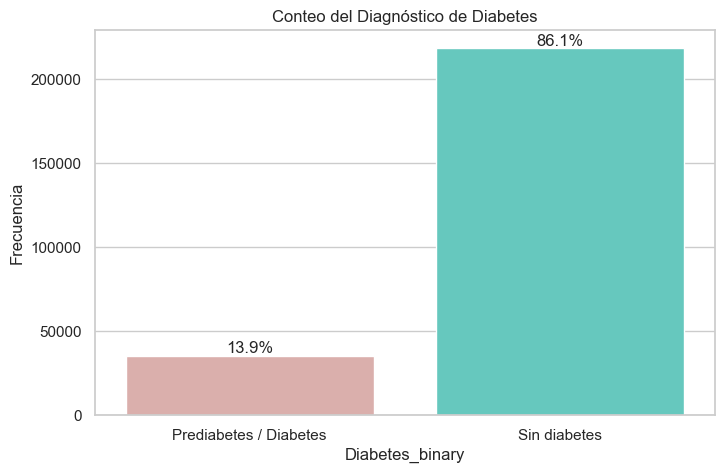

In [210]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='Diabetes_binary',
    data=df_viz,
    palette=["#E2A8A4","#56D8CB"]
)

total = len(df_viz)

for p in ax.patches:
    percentage = f'{100 * p.get_height()/total:.1f}%'
    ax.annotate(
        percentage,
        (p.get_x()+p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title("Conteo del Diagnóstico de Diabetes")
plt.xlabel("Diabetes_binary")
plt.ylabel("Frecuencia")

plt.show()

La variable Diagnóstico de Diabetes, que constituye el desenlace principal del estudio, muestra que el 13.93% (n = 35,346) de los individuos presenta diagnóstico de diabetes, mientras que el 86.07% (n = 218,334) no reporta esta condición.

Desde una perspectiva epidemiológica, la prevalencia observada resulta consistente con patrones poblacionales de diabetes mellitus tipo 2 en población adulta, especialmente en contextos donde predominan grupos etarios intermedios y avanzados, como se evidenció previamente en la distribución por edad del dataset.

## **10. Análisis univariado**

El análisis univariado tiene como objetivo examinar cada variable de manera individual para comprender su distribución, comportamiento y características principales. En esta sección se describen medidas de tendencia central, dispersión y forma en variables numéricas, así como frecuencias y proporciones en variables categóricas. Este análisis permite identificar posibles valores atípicos, asimetrías, patrones dominantes y calidad de los datos, constituyendo la base para interpretaciones posteriores y para la construcción del análisis bivariado y multivariado.

### **10.1. Variables demográficas**

#### **10.1.1. Sexo**

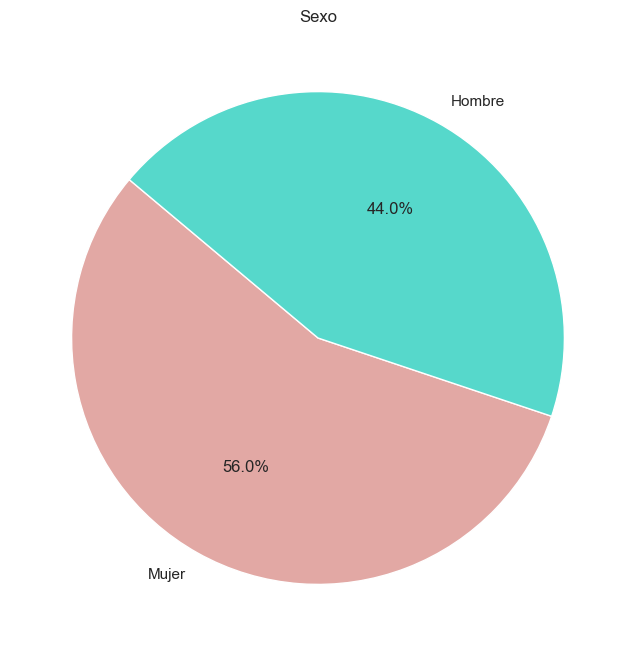

In [211]:
# Conteo de la variable Sex
sex_counts = df['Sex'].value_counts()

# Gráfico circular
plt.figure(figsize=(8,8))
plt.pie(sex_counts, labels=["Mujer", "Hombre"], autopct='%1.1f%%', startangle=140, colors=["#E2A8A4","#56D8CB"])
plt.title("Sexo")

plt.show()

La tabla de frecuencias muestra la distribución de la variable Sex en la población analizada. Se observa que el 55.97% (n = 14,197) de los registros corresponde a mujeres, mientras que el 44.03% (n = 11,706) pertenece a hombres.

Estos resultados indican que la muestra presenta una ligera mayor representación de mujeres frente a los hombres. En términos generales, la distribución no es extremadamente desbalanceada, aunque sí existe una diferencia aproximada de 12 puntos porcentuales entre ambas categorías.

#### **10.1.2. Edad**

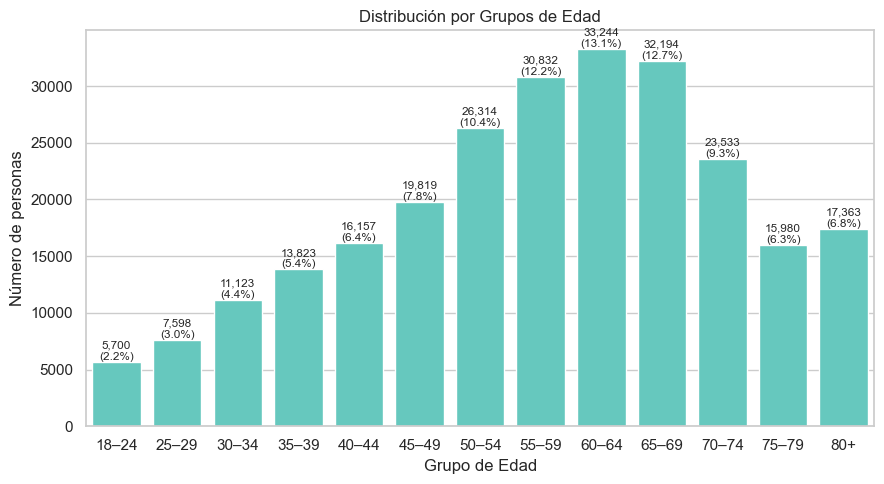

In [212]:
plt.figure(figsize=(9, 5))

ax = sns.countplot(x='Age', data=df_viz, color="#56D8CB", 
                   order=sorted(df_viz['Age'].unique()))

total = len(df_viz)

for p in ax.patches:
    count = int(p.get_height())
    percentage = f'{100 * count / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(
        f'{count:,}\n({percentage})',  # conteo arriba, porcentaje abajo
        (x, y),
        ha='center',
        va='bottom',
        fontsize=8.5
    )

plt.title("Distribución por Grupos de Edad")
plt.xlabel("Grupo de Edad")
plt.ylabel("Número de personas")

plt.tight_layout()
plt.show()

La distribución etaria evidencia una concentración progresiva de la muestra en los grupos de edad media y tardía. Se observa que los intervalos comprendidos entre 50 y 69 años (códigos 7 a 10) acumulan aproximadamente el 48.31% del total de observaciones, equivalente a 122,584 personas, 
con un pico específico en el grupo 60–64 años con 33,244 personas, 13.10%, seguido por el grupo 65–69 años 32,194 personas, 12.69% y 55–59 años con 30,822 personas, 12.15%.

Este patrón indica una clara sobrerrepresentación de población en etapas de madurez y transición hacia la vejez, mientras que los grupos jóvenes (18–34 años) presentan una participación relativa considerablemente menor, con aproximadamente 24,421 personas en total (9.63% acumulado).

### **10.2. Variables socioeconómicas y acceso a la salud**

#### **10.2.1. Educación**

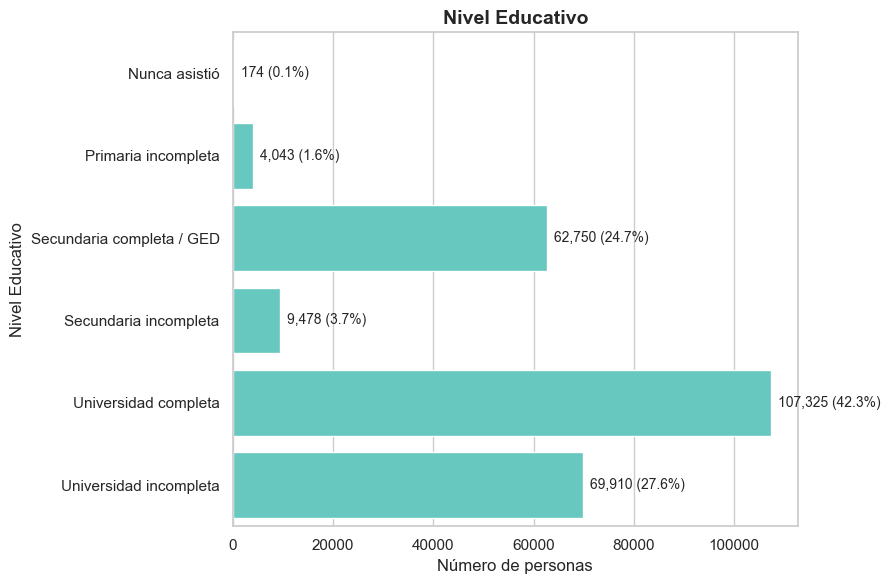

: 

In [ ]:
plt.figure(figsize=(9,6))

ax = sns.countplot(
    y='Education',  
    data=df_viz,
    color="#56D8CB",
    order=sorted(df_viz['Education'].unique())
)

total = len(df_viz)

for p in ax.patches:
    count = int(p.get_width())
    percentage = f'{100 * count / total:.1f}%'
    x = p.get_width()
    y = p.get_y() + p.get_height() / 2
    
    ax.annotate(
        f'{count:,} ({percentage})',
        (x, y),
        ha='left',
        va='center',
        fontsize=10,
        xytext=(5, 0),
        textcoords='offset points'
    )

plt.title("Nivel Educativo", fontsize=14, fontweight="bold")
plt.ylabel("Nivel Educativo")
plt.xlabel("Número de personas")

plt.tight_layout()
plt.show()

La distribución del nivel educativo evidencia una marcada concentración de la población en niveles de escolaridad media y superior. El grupo con mayor representación corresponde a los graduados universitarios, que constituyen el 42.31% (n = 107,325) de la muestra, seguido por quienes reportan algo de educación universitaria o formación técnica, con un 27.56% (n = 69,910). En conjunto, estas dos categorías agrupan cerca del 70% de los individuos, lo que indica un perfil educativo predominantemente alto dentro del dataset.

El nivel de graduado de secundaria representa el 24.74%, consolidando la mayor parte de la población en niveles educativos al menos completos en educación media. En contraste, los niveles educativos bajos presentan una participación marginal: los individuos con escolaridad inferior a secundaria (categorías 1 a 3) suman menos del 6% del total, evidenciando una subrepresentación relativa de poblaciones con baja escolaridad.

#### **10.2.2. Ingresos**

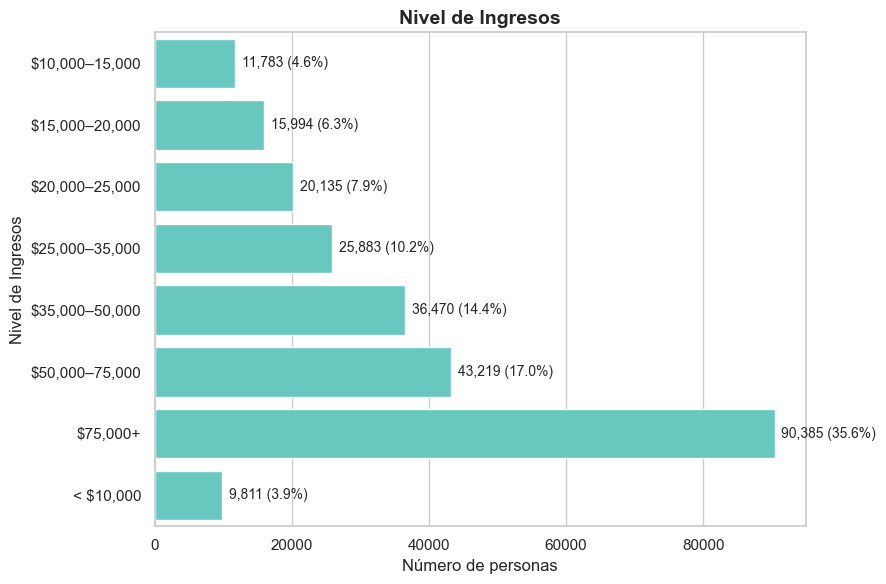

: 

In [ ]:
plt.figure(figsize=(9,6))

ax = sns.countplot(
    y='Income',
    data=df_viz,
    color="#56D8CB",
    order=sorted(df_viz['Income'].unique())
)

total = len(df_viz)

for p in ax.patches:
    count = int(p.get_width())
    percentage = f'{100 * count / total:.1f}%'
    x = p.get_width()
    y = p.get_y() + p.get_height() / 2
    
    ax.annotate(
        f'{count:,} ({percentage})',
        (x, y),
        ha='left',
        va='center',
        fontsize=10,
        xytext=(5, 0),
        textcoords='offset points'
    )

plt.title("Nivel de Ingresos", fontsize=14, fontweight="bold")
plt.xlabel("Número de personas")
plt.ylabel("Nivel de Ingresos")

plt.tight_layout()
plt.show()

La distribución del nivel de ingresos evidencia una clara concentración de la población en los estratos económicos medios y altos. El grupo más representativo corresponde a individuos con ingresos anuales de $75,000 o más, que constituyen el 35.63% (n = 90,385) del total de la muestra, seguido por el rango de $50,000–$74,999, con un 17.04%. En conjunto, estos dos niveles agrupan más de la mitad de las observaciones, indicando una predominancia de hogares con ingresos relativamente elevados dentro del dataset.

Los niveles intermedios de ingreso ($25,000–$49,999) presentan participaciones moderadas, mientras que los estratos de ingresos bajos (menos de $20,000 anuales) representan una proporción considerablemente menor, acumulando menos del 13% de la muestra. Este patrón sugiere una distribución socioeconómica desplazada hacia niveles superiores de ingreso, evidenciando una posible subrepresentación relativa de poblaciones económicamente vulnerables.

#### **10.2.3. Acceso a servicios de salud**

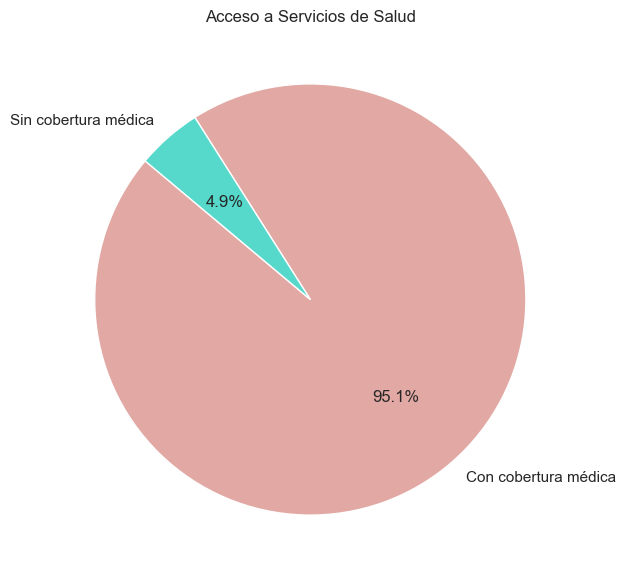

: 

In [ ]:
healthcare_counts = df_viz['AnyHealthcare'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    healthcare_counts,
    labels=["Con cobertura médica", "Sin cobertura médica"],
    autopct='%1.1f%%',
    startangle=140,
    colors=["#E2A8A4","#56D8CB"],
)

plt.title("Acceso a Servicios de Salud")
plt.show()

La distribución del acceso a servicios de salud muestra una marcada predominancia de individuos que reportan contar con cobertura o acceso sanitario. En particular, el 95.11% (n = 241,263) de la población indica tener acceso a servicios de salud, mientras que únicamente el 4.89% (n = 12,417) manifiesta no disponer de dicho acceso.

Esta fuerte concentración en la categoría afirmativa evidencia una población ampliamente integrada al sistema de atención sanitaria, lo cual es consistente con el diseño de encuestas poblacionales enfocadas en monitoreo de condiciones de salud en adultos. Sin embargo, la baja proporción relativa del grupo sin acceso introduce un desbalance estructural que debe considerarse en análisis posteriores, especialmente en comparaciones entre grupos o en modelos predictivos, donde la menor representación puede afectar la estabilidad de estimaciones para esta categoría.

#### **10.2.4. Barrera económica**

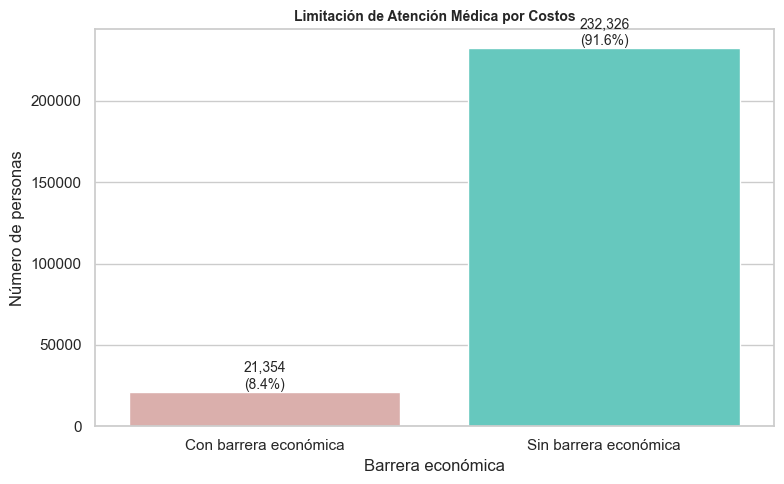

: 

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='NoDocbcCost',
    data=df_viz,
    palette=["#E2A8A4","#56D8CB"]
)

total = len(df_viz)

for p in ax.patches:
    count = int(p.get_height())
    percentage = f'{100 * count / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(
        f'{count:,}\n({percentage})',
        (x, y),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Limitación de Atención Médica por Costos", fontsize=10, fontweight="bold")
plt.xlabel("Barrera económica")
plt.ylabel("Número de personas")

plt.tight_layout()
plt.show()

La variable refleja la proporción de individuos que reportaron no haber acudido al médico en el último año debido a limitaciones económicas. Los resultados indican que el 91.58% (n = 232,326) de la muestra no experimentó barreras económicas para acceder a consulta médica, mientras que el 8.42% (n = 21,354) sí reportó haber pospuesto o evitado atención médica por motivos de costo.

Aunque la mayoría de la población no presenta esta limitación, el porcentaje cercano al 8% no es despreciable desde una perspectiva de salud pública, ya que representa un segmento vulnerable cuya condición económica puede incidir en diagnósticos tardíos, menor seguimiento clínico y potencial agravamiento de enfermedades crónicas.

### **10.3. Variables de conducta y estilo de vida**

#### **10.3.1. Fumador**

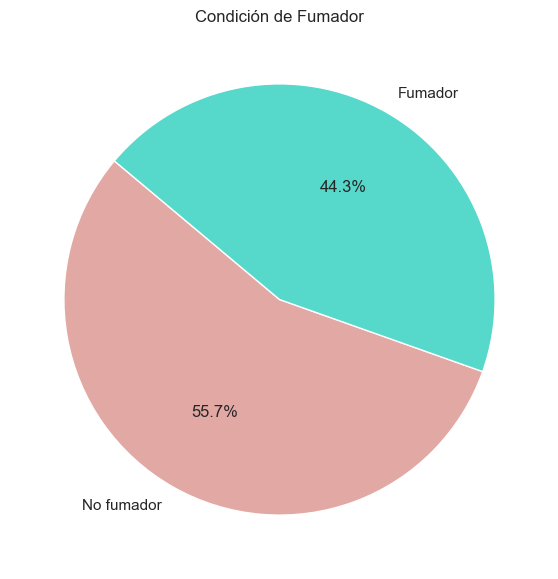

: 

In [ ]:
smoker_counts = df_viz['Smoker'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    smoker_counts,
    labels=["No fumador", "Fumador"],
    autopct='%1.1f%%',
    startangle=140,
    colors=["#E2A8A4","#56D8CB"],
)

plt.title("Condición de Fumador")
plt.show()

La distribución de la variable Smoker muestra que el 55.68% (n = 141,257) de la población reporta no ser fumador, mientras que el 44.32% (n = 112,423) corresponde a individuos que sí presentan antecedente de consumo de tabaco.

A diferencia de otras variables previamente analizadas, la proporción entre categorías no presenta un desbalance extremo, lo que indica una representación relativamente significativa del grupo fumador dentro del dataset. Este patrón sugiere que el consumo de tabaco constituye un comportamiento de riesgo ampliamente presente en la población estudiada, con una magnitud suficiente para permitir comparaciones robustas entre grupos.

#### **10.3.2. Actividad física**

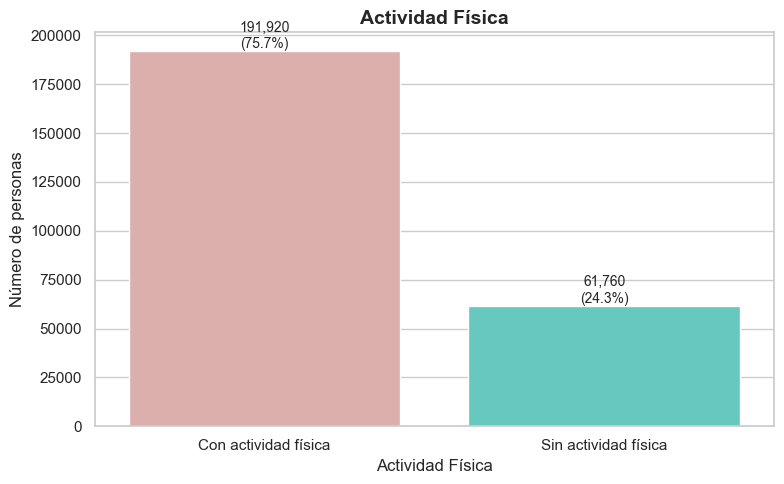

: 

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='PhysActivity',
    data=df_viz,
    palette=["#E2A8A4","#56D8CB"]
)

total = len(df_viz)

for p in ax.patches:
    count = int(p.get_height())
    percentage = f'{100 * count / total:.1f}%'
    ax.annotate(
        f'{count:,}\n({percentage})',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Actividad Física", fontsize=14, fontweight="bold")
plt.xlabel("Actividad Física")
plt.ylabel("Número de personas")

plt.tight_layout()
plt.show()

La distribución de la variable PhysActivity indica que el 75.65% (n = 191,920) de la población reporta haber realizado actividad física en los últimos 30 días, mientras que el 24.35% (n = 61,760) señala no haber realizado ningún tipo de actividad física durante ese periodo.

Esta estructura evidencia una clara predominancia de individuos con algún nivel de actividad física reciente, lo cual sugiere una muestra mayoritariamente activa desde el punto de vista conductual. Sin embargo, la proporción cercana a una cuarta parte de la población que reporta inactividad no es marginal desde una perspectiva epidemiológica, dado que el sedentarismo constituye un factor de riesgo relevante para enfermedades cardiovasculares, metabólicas y otras condiciones crónicas.

#### **10.3.3. Consumo de frutas**

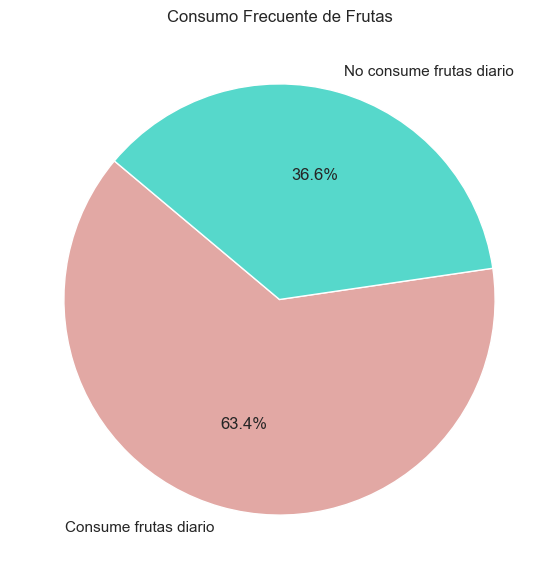

: 

In [ ]:
fruits_counts = df_viz['Fruits'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    fruits_counts,
    labels=["Consume frutas diario", "No consume frutas diario"],
    autopct='%1.1f%%',
    startangle=140,
    colors=["#E2A8A4","#56D8CB"]
)

plt.title("Consumo Frecuente de Frutas")
plt.show()

La distribución de la variable Fruits muestra que el 63.43% (n = 160,898) de los individuos reporta consumir frutas de manera regular, mientras que el 36.57% (n = 92,782) indica no mantener este hábito alimenticio.

Estos resultados evidencian una predominancia del consumo de frutas dentro de la población analizada; sin embargo, la proporción de individuos que no reporta consumo regular continúa siendo considerable, representando más de un tercio de la muestra. Desde una perspectiva de salud pública, esta distribución sugiere la coexistencia de comportamientos alimentarios saludables junto con un segmento relevante de la población potencialmente expuesto a factores dietarios de riesgo.

#### **10.3.4. Consumo de vegetales**

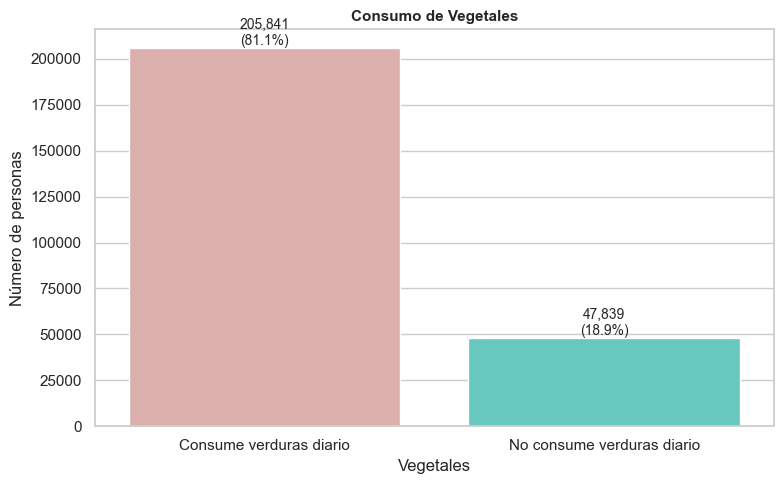

: 

In [ ]:
plt.figure(figsize=(8,5))

total = len(df_viz)

ax = sns.countplot(
    x='Veggies',
    data=df_viz,
    palette=["#E2A8A4","#56D8CB"]
)

for p in ax.patches:
    count = int(p.get_height())
    percentage = f'{100 * count / total:.1f}%'
    ax.annotate(
        f'{count:,}\n({percentage})',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Consumo de Vegetales", fontsize=11, fontweight="bold")
plt.xlabel("Vegetales")
plt.ylabel("Número de personas")

plt.tight_layout()
plt.show()

La distribución de la variable indica que el 81.14% (n = 205,841) de los individuos reporta consumir vegetales de manera regular, mientras que el 18.86% (n = 47,839) señala no incluir este tipo de alimentos en su consumo habitual.

Estos resultados evidencian una alta prevalencia de consumo de vegetales dentro de la población analizada, lo que sugiere la presencia generalizada de comportamientos alimentarios asociados a patrones nutricionales saludables. No obstante, la proporción cercana al 19% de individuos sin consumo regular continúa siendo relevante desde una perspectiva epidemiológica, dado que dietas bajas en vegetales se asocian con mayor riesgo de enfermedades crónicas no transmisibles.

#### **10.3.5. Consumo elevado de alcohol**

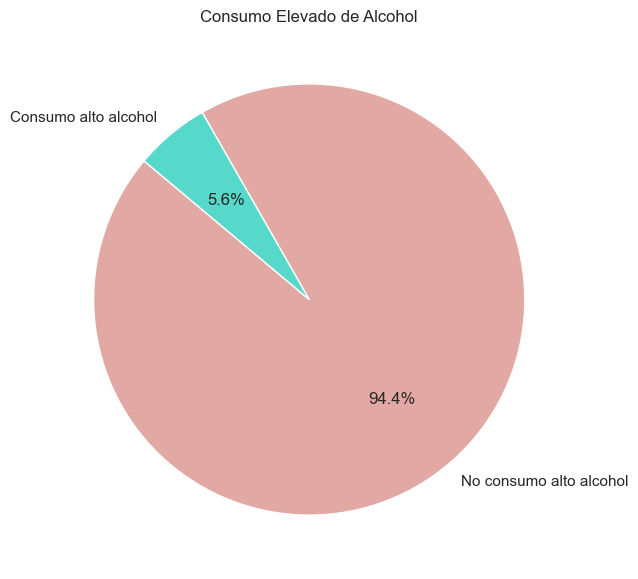

: 

In [ ]:
alcohol_counts = df['HvyAlcoholConsump'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    alcohol_counts,
    labels=["No consumo alto alcohol", "Consumo alto alcohol"],
    autopct='%1.1f%%',
    startangle=140,
    colors=["#E2A8A4","#56D8CB"],
)

plt.title("Consumo Elevado de Alcohol")
plt.show()

La distribución muestra que el 94.38% (n = 239,424) de los individuos no reporta consumo excesivo de alcohol, mientras que el 5.62% (n = 14,256) sí presenta patrones de consumo considerados elevados o de riesgo.

Esta marcada diferencia entre categorías indica que el consumo excesivo de alcohol constituye un comportamiento relativamente poco frecuente dentro de la población analizada. Sin embargo, aunque minoritario, el grupo que presenta este patrón mantiene una relevancia epidemiológica importante, dado que el consumo elevado de alcohol se asocia con múltiples efectos adversos sobre la salud, incluyendo enfermedades cardiovasculares, hepáticas y trastornos metabólicos.

#### **10.3.6. Chequeo de colesterol**

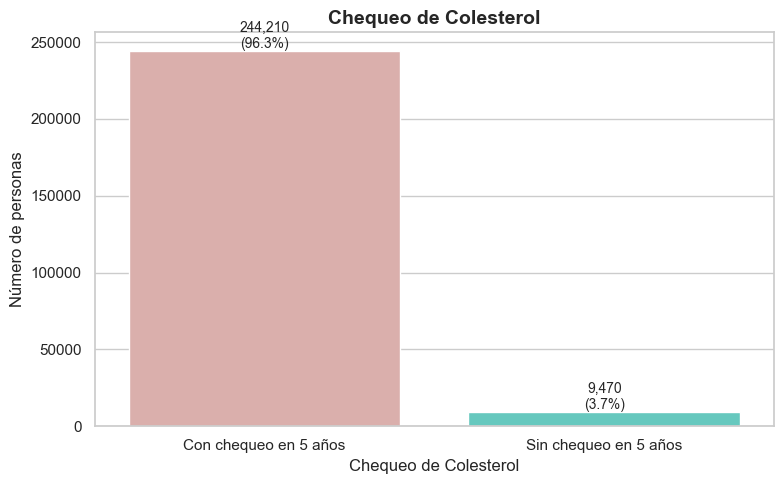

: 

In [ ]:
plt.figure(figsize=(8,5))

total = len(df_viz)

ax = sns.countplot(
    x='CholCheck',
    data=df_viz,
    palette=["#E2A8A4","#56D8CB"]
)

for p in ax.patches:
    count = int(p.get_height())
    percentage = f'{100 * count / total:.1f}%'
    ax.annotate(
        f'{count:,}\n({percentage})',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Chequeo de Colesterol", fontsize=14, fontweight="bold")
plt.xlabel("Chequeo de Colesterol")
plt.ylabel("Número de personas")

plt.tight_layout()
plt.show()

La distribución de la variable CholCheck indica que el 96.27% (n = 244,210) de los individuos reporta haberse realizado un control de colesterol en los últimos cinco años, mientras que únicamente el 3.73% (n = 9,470) señala no haber efectuado dicha evaluación en ese periodo.

Este patrón refleja una alta cobertura en prácticas preventivas relacionadas con monitoreo cardiovascular dentro de la población estudiada. La proporción mayoritaria sugiere una población ampliamente integrada a esquemas de seguimiento médico, particularmente en lo que respecta a factores de riesgo metabólico.

### **10.4. Variables de factores clínicos y metabólicos**

#### **10.4.1. Indice de Masa Corporal (BMI)**

In [ ]:
bmi_summary = df["BMI"].describe()  # incluye count, mean, std, min, 25%, 50%, 75%, max
bmi_summary_df = bmi_summary.to_frame(name="BMI").round(2)
bmi_summary_df

,BMI
count,253680.00
mean,28.38
std,6.61
min,12.00
25%,24.00
50%,27.00
75%,31.00
max,98.00


: 

El resumen estadístico del Índice de Masa Corporal (BMI) muestra un total de
**253,680 observaciones**, con un valor promedio de **28.38** y una mediana de
**27.00**, lo que indica que la mitad de los individuos presenta valores de BMI
iguales o inferiores a este punto central.

Los valores se distribuyen entre un mínimo de **12.00** y un máximo de
**98.00**, evidenciando un amplio rango dentro de la variable. El primer
cuartil (**Q1 = 24.00**) y el tercer cuartil (**Q3 = 31.00**) indican que el
50% central de las observaciones se concentra dentro de este intervalo.

La desviación estándar de **6.61** refleja la variabilidad presente en los
valores de BMI dentro del conjunto de datos analizado.

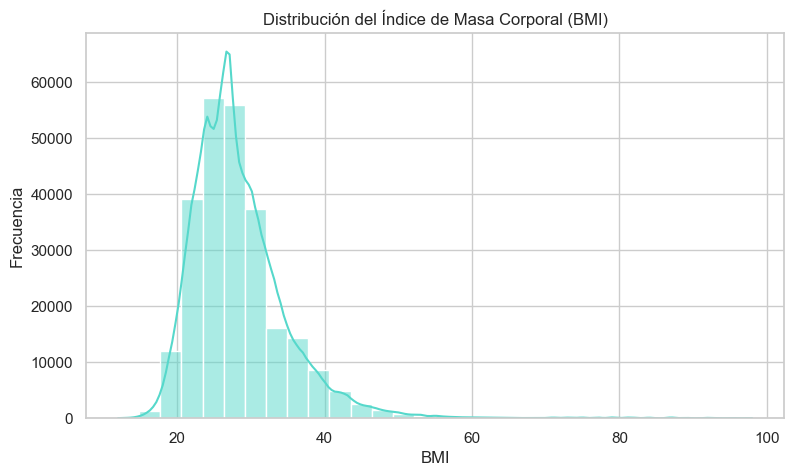

: 

In [ ]:
plt.figure(figsize=(9,5))

sns.histplot(
    df_viz["BMI"],
    kde=True,
    color="#56D8CB",
    bins=30
)

plt.title("Distribución del Índice de Masa Corporal (BMI)")
plt.xlabel("BMI")
plt.ylabel("Frecuencia")

plt.show()

La distribución del Índice de Masa Corporal (BMI) muestra una mayor
concentración de observaciones en valores intermedios, con una frecuencia más
alta alrededor del rango comprendido aproximadamente entre **24 y 31**, en
coherencia con los cuartiles observados previamente en el resumen estadístico.

Asimismo, la forma de la distribución presenta una extensión visible hacia
valores más altos de BMI, sugiriendo una **asimetría hacia la derecha**. Esta
característica podría indicar la presencia de valores extremos en la parte
superior de la distribución.


#### **10.4.2. Presión arterial alta**

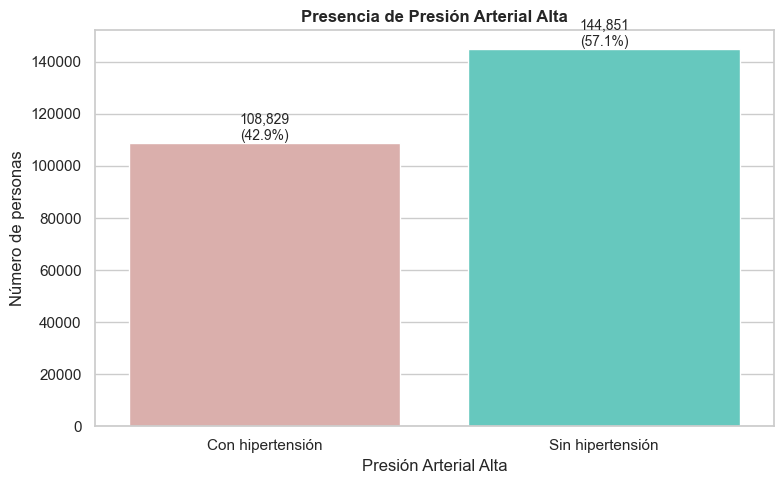

: 

In [ ]:
plt.figure(figsize=(8,5))

total = len(df_viz)

ax = sns.countplot(
    x='HighBP',
    data=df_viz,
    palette=["#E2A8A4","#56D8CB"]
)

for p in ax.patches:
    count = int(p.get_height())
    percentage = f'{100 * count / total:.1f}%'
    ax.annotate(
        f'{count:,}\n({percentage})',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Presencia de Presión Arterial Alta", fontsize=12, fontweight="bold")
plt.xlabel("Presión Arterial Alta")
plt.ylabel("Número de personas")

plt.tight_layout()
plt.show()

La distribución muestra que el 57.10% (n = 144,851) de los individuos no reporta diagnóstico de hipertensión arterial, mientras que el 42.90% (n = 108,829) sí presenta antecedentes de presión arterial alta.

A diferencia de otras variables relacionadas con conductas o acceso a servicios de salud, la proporción de individuos con hipertensión resulta considerablemente elevada, evidenciando una presencia sustancial de esta condición dentro de la población analizada. La cercanía relativa entre ambas categorías sugiere una distribución más equilibrada, lo que indica que la hipertensión constituye un fenómeno ampliamente representado en el dataset y no un evento marginal.

#### **10.4.3. Colesterol alto**

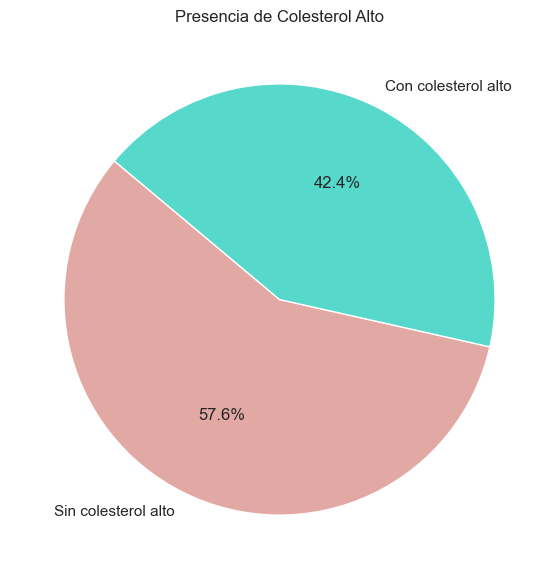

: 

In [ ]:
chol_counts = df_viz['HighChol'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    chol_counts,
    labels=["Sin colesterol alto","Con colesterol alto"],
    autopct='%1.1f%%',
    startangle=140,
    colors=["#E2A8A4","#56D8CB"],
)

plt.title("Presencia de Colesterol Alto")
plt.show()

La distribución de la variable HighChol indica que el 57.59% (n = 146,089) de los individuos no reporta niveles elevados de colesterol, mientras que el 42.41% (n = 107,591) sí presenta diagnóstico de hipercolesterolemia.

Al igual que en el caso de la hipertensión arterial, la proporción de individuos con colesterol alto es considerablemente elevada, representando más de dos quintas partes de la población analizada. Esta magnitud evidencia que las alteraciones metabólicas constituyen un componente sustancial dentro del perfil de salud del dataset y no un evento aislado o marginal.

### **10.5. Variables de estado funcional y percepción de la salud**

#### **10.5.1. Percepción del estado de salud**

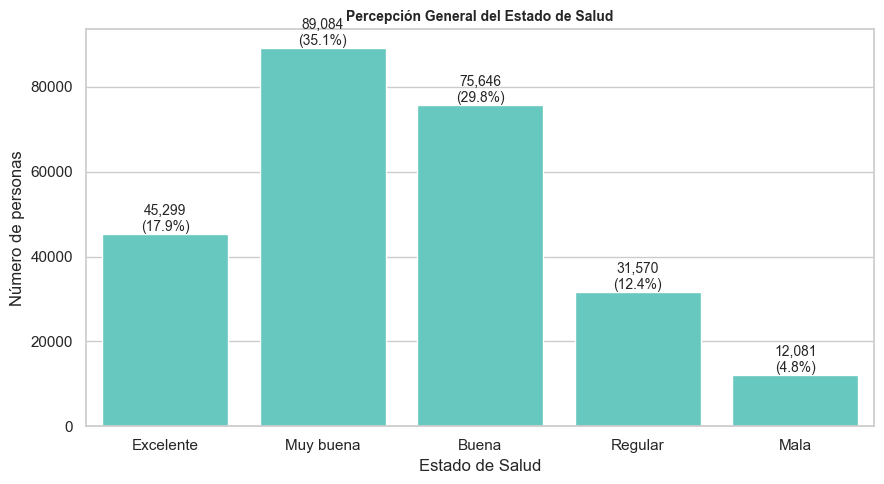

: 

In [ ]:
plt.figure(figsize=(9,5))

orden_salud = [
    "Excelente",
    "Muy buena",
    "Buena",
    "Regular",
    "Mala"
]

total = len(df_viz)

ax = sns.countplot(
    x='GenHlth',
    data=df_viz,
    color="#56D8CB",
    order=orden_salud   
)

for p in ax.patches:
    count = int(p.get_height())
    percentage = f'{100 * count / total:.1f}%'
    ax.annotate(
        f'{count:,}\n({percentage})',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Percepción General del Estado de Salud", fontsize=10, fontweight="bold")
plt.xlabel("Estado de Salud")
plt.ylabel("Número de personas")

plt.tight_layout()
plt.show()

La percepción general del estado de salud, presenta una distribución predominantemente concentrada en valoraciones positivas o intermedias. La categoría más frecuente corresponde a “Buena”, con el 29.82% (n = 75,646) de las observaciones, seguida por “Muy buena” (35.12%) y “Excelente” (17.86%). En conjunto, estas tres categorías agrupan más del 80% de la población, indicando una percepción global favorable del estado de salud entre los individuos analizados.

Por otro lado, las categorías asociadas a percepciones menos favorables, “Regular” (12.44%) y “Mala” (4.76%), representan una proporción considerablemente menor, aunque epidemiológicamente relevante, ya que suelen asociarse con mayor carga de enfermedad crónica, limitaciones funcionales y mayor utilización de servicios sanitarios.

#### **10.5.2. Días con mala salud física**

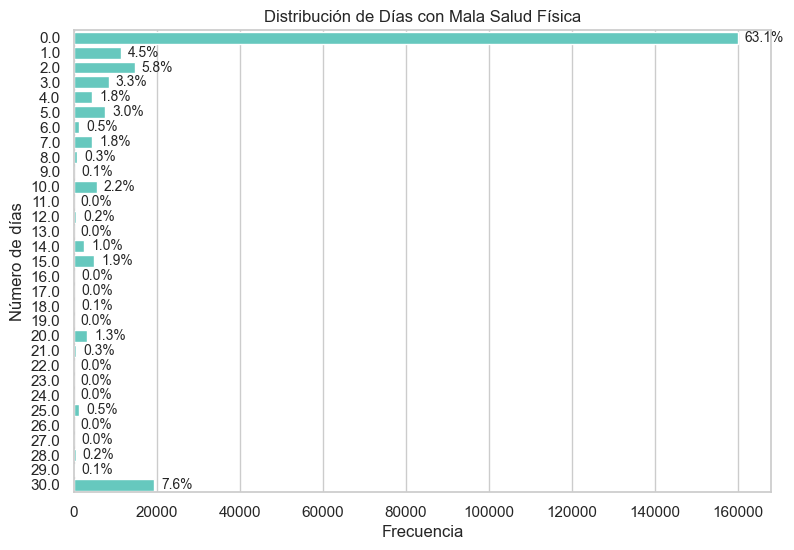

: 

In [ ]:
plt.figure(figsize=(9,6))

ax = sns.countplot(
    y='PhysHlth',
    data=df_viz,
    color="#56D8CB",
    order=sorted(df_viz['PhysHlth'].unique())
)

# Total de observaciones
total = len(df_viz)

# Agregar porcentajes
for p in ax.patches:
    percentage = f'{100 * p.get_width() / total:.1f}%'
    x = p.get_width()
    y = p.get_y() + p.get_height() / 2
    
    ax.annotate(
        percentage,
        (x, y),
        ha='left',
        va='center',
        fontsize=10,
        xytext=(5, 0),
        textcoords='offset points'
    )

plt.title("Distribución de Días con Mala Salud Física")
plt.xlabel("Frecuencia")
plt.ylabel("Número de días")

plt.show()

La gráfica muestra la distribución del número de días en los que los encuestados reportaron haber tenido mala salud física durante los últimos 30 días. Se observa una marcada concentración en el valor 0 días, que representa aproximadamente el 63.1% de la muestra, lo que indica que la mayoría de los participantes no experimentó días de mala salud física en el último mes. A medida que aumenta el número de días reportados, la frecuencia disminuye considerablemente, evidenciando una distribución fuertemente asimétrica hacia la derecha. Sin embargo, destaca un pequeño grupo (7.6%) que reporta 30 días de mala salud física, lo que sugiere la presencia de un segmento con afectación persistente. 

#### **10.5.3. Días con mala salud mental**

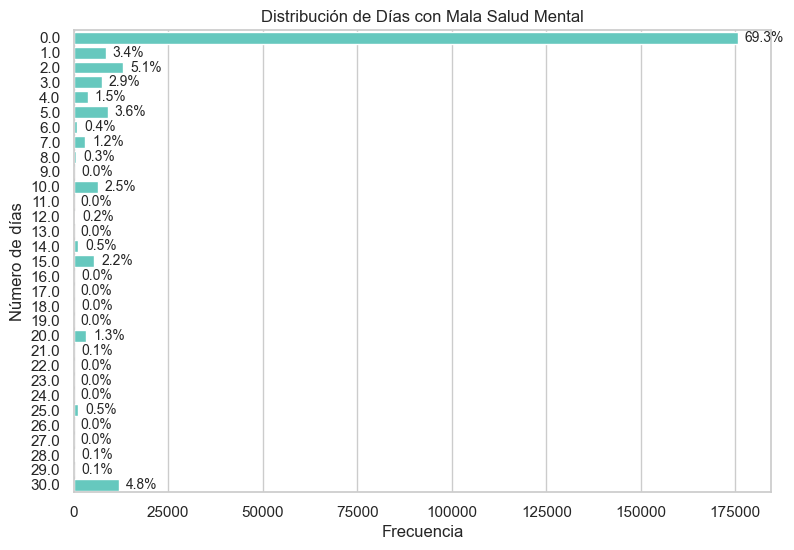

: 

In [ ]:
plt.figure(figsize=(9,6))

ax = sns.countplot(
    y='MentHlth',
    data=df_viz,
    color="#56D8CB",
    order=sorted(df_viz['MentHlth'].unique())
)

# Total de observaciones
total = len(df_viz)

# Agregar porcentajes
for p in ax.patches:
    percentage = f'{100 * p.get_width() / total:.1f}%'
    x = p.get_width()
    y = p.get_y() + p.get_height() / 2
    
    ax.annotate(
        percentage,
        (x, y),
        ha='left',
        va='center',
        fontsize=10,
        xytext=(5, 0),
        textcoords='offset points'
    )

plt.title("Distribución de Días con Mala Salud Mental")
plt.xlabel("Frecuencia")
plt.ylabel("Número de días")

plt.show()

La gráfica presenta la distribución del número de días en los que los encuestados reportaron haber tenido mala salud mental durante los últimos 30 días. Se observa que el 69.3% de la muestra indicó no haber experimentado ningún día de mala salud mental (0 días), lo que evidencia una fuerte concentración en el valor mínimo. A medida que aumenta el número de días reportados, la frecuencia disminuye considerablemente, mostrando una distribución altamente asimétrica hacia la derecha. No obstante, se identifica un grupo relevante (4.8%) que reporta 30 días de mala salud mental, lo cual sugiere la existencia de un segmento con afectación continua durante todo el mes.

#### **10.5.4. Dificultad para caminar**

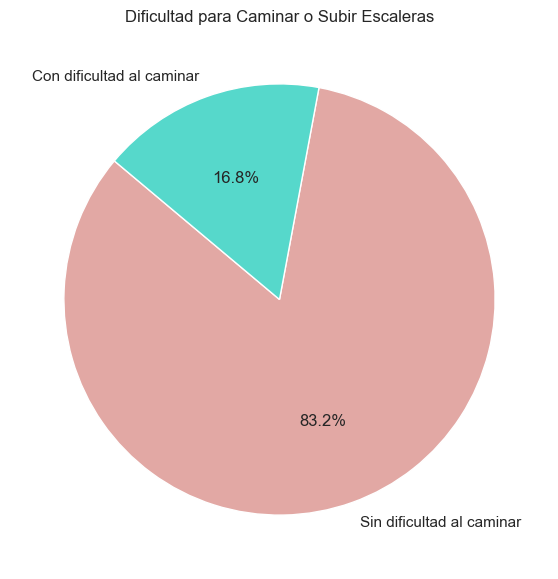

: 

In [ ]:
diffwalk_counts = df_viz['DiffWalk'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    diffwalk_counts,
    labels=["Sin dificultad al caminar","Con dificultad al caminar"],
    autopct='%1.1f%%',
    startangle=140,
    colors=["#E2A8A4","#56D8CB"],
)

plt.title("Dificultad para Caminar o Subir Escaleras")
plt.show()

La distribución de la variable DiffWalk, que evalúa la presencia de dificultades para caminar o subir escaleras, indica que el 83.18% (n = 211,005) de los individuos no reporta limitaciones funcionales de movilidad, mientras que el 16.82% (n = 42,675) sí manifiesta algún grado de dificultad en estas actividades.

Aunque la mayoría de la población no presenta restricciones de movilidad, la proporción cercana al 17% resulta significativa desde una perspectiva de salud pública, ya que las limitaciones funcionales suelen asociarse con envejecimiento, presencia de enfermedades crónicas y determioro del estado general de salud. Este grupo puede representar individuos con mayor vulnerabilidad física y mayor probabilidad de requerir atención médica continua.

### **10.6. Eventos cardiovasculares mayores**

#### **10.6.1. Antecedente de Accidente Cerebrovascular**

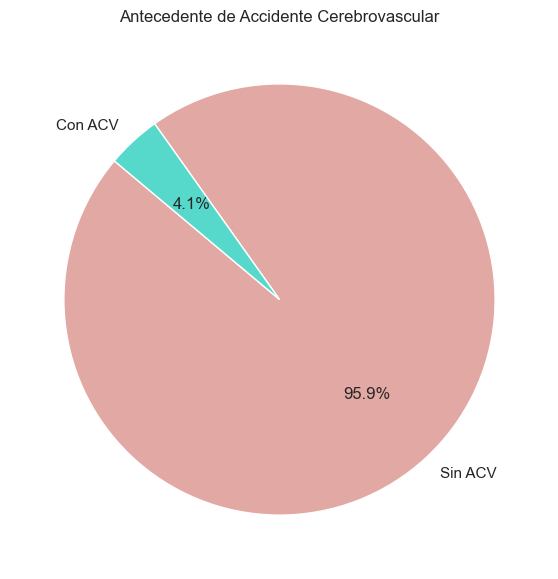

: 

In [ ]:
stroke_counts = df_viz['Stroke'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    stroke_counts,
    labels=["Sin ACV", "Con ACV"],
    autopct='%1.1f%%',
    startangle=140,
    colors=["#E2A8A4","#56D8CB"],
)

plt.title("Antecedente de Accidente Cerebrovascular")
plt.show()

La distribución de la variable Stroke indica que el 95.94% (n = 243,388) de los individuos no reporta antecedente de accidente cerebrovascular, mientras que el 4.06% (n = 10,292) sí presenta historial de esta condición.

Aunque la proporción de casos es relativamente baja en términos absolutos, su relevancia clínica es significativa, dado que el accidente cerebrovascular constituye un evento de alta gravedad, asociado a morbilidad sustancial, discapacidad funcional y aumento del riesgo de mortalidad. La baja prevalencia observada es consistente con la naturaleza de esta condición en población general, donde, a pesar de su impacto severo, su frecuencia es menor en comparación con otros factores de riesgo cardiovascular como hipertensión o colesterol elevado.

#### **10.6.2. Enfermedad/ateque cardíaco**

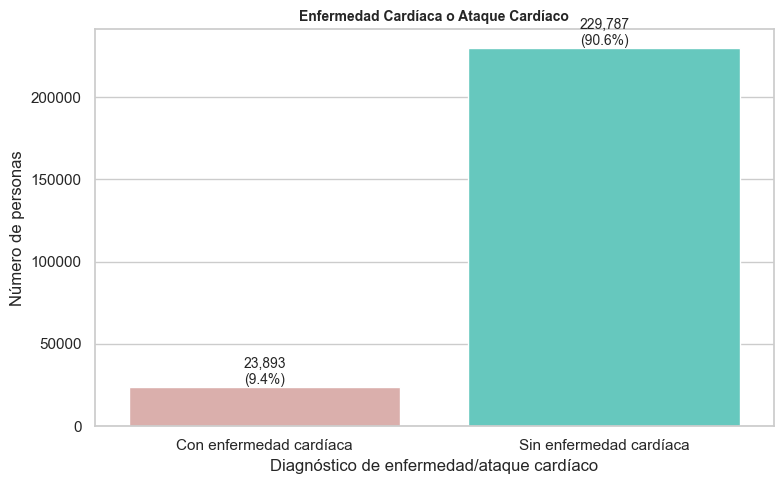

: 

In [ ]:
plt.figure(figsize=(8,5))

total = len(df_viz)

ax = sns.countplot(
    x='HeartDiseaseorAttack',
    data=df_viz,
    palette=["#E2A8A4","#56D8CB"]
)

for p in ax.patches:
    count = int(p.get_height())
    percentage = f'{100 * count / total:.1f}%'
    ax.annotate(
        f'{count:,}\n({percentage})',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Enfermedad Cardíaca o Ataque Cardíaco", fontsize=10, fontweight="bold")
plt.xlabel("Diagnóstico de enfermedad/ataque cardíaco")
plt.ylabel("Número de personas")

plt.tight_layout()
plt.show()

La distribución muestra que el 90.58% (n = 229,787) de los individuos no reporta antecedente de enfermedad cardíaca o infarto de miocardio, mientras que el 9.42% (n = 23,893) sí presenta historial de este tipo de evento cardiovascular.

Aunque la mayoría de la población no reporta diagnóstico previo, la proporción cercana al 9.5% resulta epidemiológicamente significativa, ya que las enfermedades cardiovasculares constituyen una de las principales causas de morbilidad y mortalidad a nivel poblacional. En comparación con la variable Stroke, la prevalencia observada es más elevada, lo cual es consistente con la mayor frecuencia relativa de eventos coronarios frente a accidentes cerebrovasculares en población adulta.

## **11. Análisis bivariado**

El análisis bivariado busca explorar la relación entre dos variables con el fin de identificar asociaciones, diferencias significativas o patrones conjuntos de comportamiento. Dependiendo del tipo de variables (numéricas o categóricas), se emplean herramientas como gráficos comparativos, medidas de correlación o pruebas estadísticas. Esta etapa permite evaluar posibles relaciones relevantes para el fenómeno estudiado y aporta evidencia preliminar sobre vínculos que podrían ser profundizados en modelos explicativos posteriores.

### **11.1 Variable objetivo vs variables categóricas (binarias)**

#### **11.1.1 Objetivo vs HighBP**

In [72]:
from scipy.stats import chi2_contingency

# Crear tabla de contingencia
variable = 'HighBP'
tabla_abs = pd.crosstab(df_viz[variable], df_viz[Objetivo], margins=True)
print("Tabla de contingencia:")
print(tabla_abs)
print("\n")

# Prueba chi-cuadrado
chi2, p, dof, expected = chi2_contingency(tabla_abs.iloc[:-1, :-1])

print("Chi-cuadrado:", round(chi2, 2))
print("Grados de libertad:", dof)
print("p-valor:", p)

# Odds Ratio
# Calcular Odds Ratio solo si es tabla 2x2
if tabla_abs.iloc[:-1, :-1].shape == (2, 2):
    
    a = tabla_abs.iloc[0, 0]
    b = tabla_abs.iloc[0, 1]
    c = tabla_abs.iloc[1, 0]
    d = tabla_abs.iloc[1, 1]
    
    odds_ratio = (a * d) / (b * c)
    print("Odds Ratio (OR):", round(odds_ratio, 2))
    
else:
    print("Odds Ratio no aplica (tabla mayor a 2x2)")

Tabla de contingencia:
Diabetes_binary   Prediabetes / Diabetes  Sin diabetes     All
HighBP                                                        
Con hipertensión                   26604         82225  108829
Sin hipertensión                    8742        136109  144851
All                                35346        218334  253680


Chi-cuadrado: 17562.45
Grados de libertad: 1
p-valor: 0.0
Odds Ratio (OR): 5.04


La tabla de contingencia evidencia una asociación clara entre la presencia de hipertensión y el diagnóstico de prediabetes/diabetes. En el grupo con **Prediabetes / Diabetes**, el 75.27% presenta hipertensión, mientras que solo el 24.73% no la presenta. En contraste, dentro del grupo **Sin diabetes**, el porcentaje con hipertensión disminuye considerablemente al 37.66%, siendo mayoritario el grupo sin hipertensión (62.34%).

Desde el punto de vista estadístico, la prueba de independencia Chi-cuadrado arroja un estadístico de **χ² = 17562.45** con un p-valor < 0.001 (reportado como 0.0 por redondeo computacional), lo que indica que existe evidencia estadísticamente significativa para rechazar la hipótesis nula de independencia entre las variables. En consecuencia, se concluye que la presencia de hipertensión está significativamente asociada con el diagnóstico de prediabetes/diabetes en la muestra analizada.

Adicionalmente, el Odds Ratio **(OR = 5.04)** indica que las probabilidades de presentar prediabetes/diabetes son aproximadamente cinco veces mayores en individuos con hipertensión en comparación con aquellos sin hipertensión. Este valor cuantifica la magnitud de la asociación y confirma que no solo existe significancia estadística, esperable dada la gran muestra, sino también una relación fuerte desde el punto de vista epidemiológico.

En consecuencia, se concluye que la hipertensión constituye un factor significativamente asociado al estado diabético en la muestra analizada, consolidándose como una condición estrechamente vinculada al riesgo metabólico.

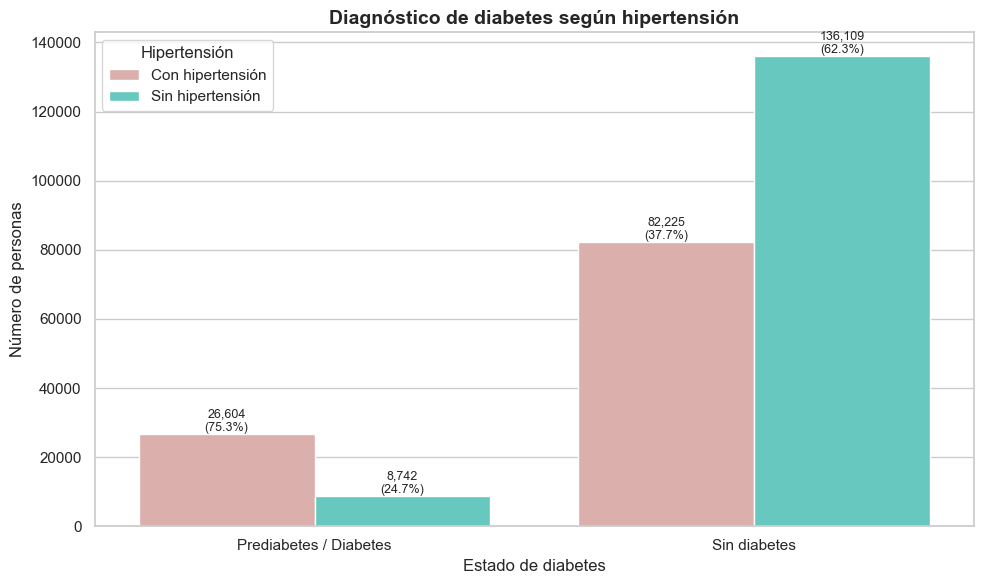

In [214]:
# Tabla porcentual por fila
tabla_pct = pd.crosstab(
    df_viz["Diabetes_binary"],
    df_viz["HighBP"],
    normalize="index"
) * 100

# Tabla absoluta
tabla_abs = pd.crosstab(df_viz["Diabetes_binary"], df_viz["HighBP"])

# Formato largo
plot_pct = (
    tabla_pct
    .reset_index()
    .melt(id_vars="Diabetes_binary",
          var_name="Hipertensión",
          value_name="Porcentaje")
)

plot_abs = (
    tabla_abs
    .reset_index()
    .melt(id_vars="Diabetes_binary",
          var_name="Hipertensión",
          value_name="Frecuencia")
)

# Merge para tener conteo y porcentaje juntos
plot_merged = plot_abs.merge(plot_pct, on=["Diabetes_binary", "Hipertensión"])

fig, ax = plt.subplots(figsize=(10, 6))

ax = sns.barplot(
    data=plot_abs,
    x="Diabetes_binary",
    y="Frecuencia",
    hue="Hipertensión",
    palette=["#E2A8A4", "#56D8CB"]
)

# Agregar conteo y porcentaje sobre cada barra
for bar, (_, row) in zip(ax.patches, plot_merged.iterrows()):
    count = int(bar.get_height())
    pct = row["Porcentaje"]
    ax.annotate(
        f'{count:,}\n({pct:.1f}%)',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

ax.set_title("Diagnóstico de diabetes según hipertensión", fontsize=14, fontweight="bold")
ax.set_xlabel("Estado de diabetes")
ax.set_ylabel("Número de personas")

plt.tight_layout()
plt.show()

#### **11.1.2 Objetivo vs HighChol**

In [73]:
from scipy.stats import chi2_contingency

# Crear tabla de contingencia
variable = 'HighChol'
tabla_abs = pd.crosstab(df_viz[variable], df_viz[Objetivo], margins=True)
print("Tabla de contingencia:")
print(tabla_abs)
print("\n")

# Prueba chi-cuadrado
chi2, p, dof, expected = chi2_contingency(tabla_abs.iloc[:, :-1])

print("Chi-cuadrado:", round(chi2, 2))
print("Grados de libertad:", dof)
print("p-valor:", p)

# Odds Ratio
# Calcular Odds Ratio solo si es tabla 2x2
if tabla_abs.iloc[:, :-1].shape == (2, 2):
    
    a = tabla_abs.iloc[0, 0]
    b = tabla_abs.iloc[0, 1]
    c = tabla_abs.iloc[1, 0]
    d = tabla_abs.iloc[1, 1]
    
    odds_ratio = (a * d) / (b * c)
    print("Odds Ratio (OR):", round(odds_ratio, 2))
    
else:
    print("Odds Ratio no aplica (tabla mayor a 2x2)")


Tabla de contingencia:
Diabetes_binary      Prediabetes / Diabetes  Sin diabetes     All
HighChol                                                         
Con colesterol alto                   23686         83905  107591
Sin colesterol alto                   11660        134429  146089
All                                   35346        218334  253680


Chi-cuadrado: 10175.25
Grados de libertad: 2
p-valor: 0.0
Odds Ratio no aplica (tabla mayor a 2x2)


La tabla de contingencia evidencia una diferencia sustancial en la distribución del colesterol alto según el estado diabético. Dentro del grupo con **Prediabetes / Diabetes**, el 67.01% presenta colesterol alto, mientras que el 32.99% no lo presenta. En contraste, en el grupo Sin **diabetes**, solo el 38.43% presenta colesterol alto y el 61.57% no lo presenta.

Esta diferencia porcentual sugiere una asociación relevante entre ambas condiciones metabólicas. La prueba Chi-cuadrado de independencia arroja un estadístico de **χ² = 10174.07**, con 1 grado de libertad y un p-valor < 0.001 (reportado como 0.0 por redondeo computacional). Dado que el p-valor es significativamente menor al nivel de significancia convencional (α = 0.05), se rechaza la hipótesis nula de independencia.

Adicionalmente, el Odds Ratio **(OR = 3.25)** indica que las probabilidades de presentar prediabetes/diabetes son aproximadamente 3.25 veces mayores en individuos con colesterol alto en comparación con aquellos sin colesterol alto. Este valor cuantifica la magnitud de la asociación y evidencia que no solo existe significancia estadística, esperable dada la gran muestra, sino también una relación de magnitud moderada a fuerte desde el punto de vista epidemiológico.

En consecuencia, se concluye que el colesterol alto se encuentra significativamente asociado con la presencia de prediabetes/diabetes en la muestra analizada, en línea con la evidencia epidemiológica que vincula dislipidemias y trastornos metabólicos.



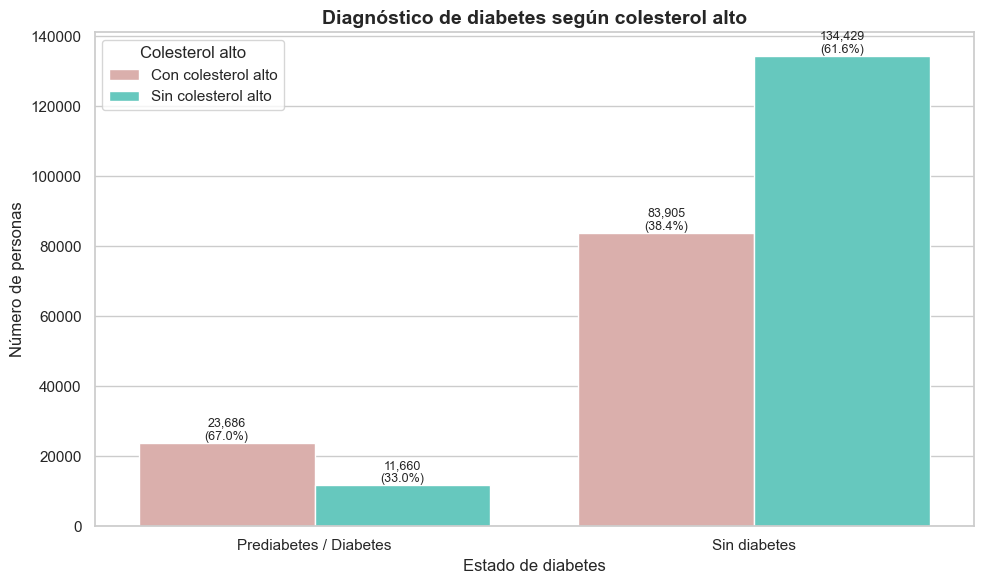

: 

In [ ]:
tabla_pct = pd.crosstab(
    df_viz["Diabetes_binary"],
    df_viz["HighChol"],
    normalize="index"
) * 100

tabla_abs = pd.crosstab(df_viz["Diabetes_binary"], df_viz["HighChol"])

plot_pct = (
    tabla_pct
    .reset_index()
    .melt(id_vars="Diabetes_binary",
          var_name="Colesterol alto",
          value_name="Porcentaje")
)

plot_abs = (
    tabla_abs
    .reset_index()
    .melt(id_vars="Diabetes_binary",
          var_name="Colesterol alto",
          value_name="Frecuencia")
)

plot_merged = plot_abs.merge(plot_pct, on=["Diabetes_binary", "Colesterol alto"])

fig, ax = plt.subplots(figsize=(10, 6))

ax = sns.barplot(
    data=plot_abs,
    x="Diabetes_binary",
    y="Frecuencia",
    hue="Colesterol alto",
    palette=["#E2A8A4", "#56D8CB"]
)

for bar, (_, row) in zip(ax.patches, plot_merged.iterrows()):
    count = int(bar.get_height())
    pct = row["Porcentaje"]
    ax.annotate(
        f'{count:,}\n({pct:.1f}%)',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

ax.set_title("Diagnóstico de diabetes según colesterol alto", fontsize=14, fontweight="bold")
ax.set_xlabel("Estado de diabetes")
ax.set_ylabel("Número de personas")

plt.tight_layout()
plt.show()

#### **11.1.3 Objetivo vs CholCheck**

In [74]:
from scipy.stats import chi2_contingency

# Crear tabla de contingencia
variable = 'CholCheck'
tabla_abs = pd.crosstab(df_viz[variable], df_viz[Objetivo], margins=True)
print("Tabla de contingencia:")
print(tabla_abs)
print("\n")

chi2, p, dof, expected = chi2_contingency(tabla_abs.iloc[:, :-1])

print("\nChi-cuadrado:", round(chi2, 2))
print("Grados de libertad:", dof)
print("p-valor:", p)

# Calcular Odds Ratio solo si es tabla 2x2
if tabla_abs.iloc[:, :-1].shape == (2, 2):
    
    a = tabla_abs.iloc[0, 0]
    b = tabla_abs.iloc[0, 1]
    c = tabla_abs.iloc[1, 0]
    d = tabla_abs.iloc[1, 1]
    
    odds_ratio = (a * d) / (b * c)
    print("Odds Ratio (OR):", round(odds_ratio, 2))
    
else:
    print("Odds Ratio no aplica (tabla mayor a 2x2)")



Tabla de contingencia:
Diabetes_binary        Prediabetes / Diabetes  Sin diabetes     All
CholCheck                                                          
Con chequeo en 5 años                   35105        209105  244210
Sin chequeo en 5 años                     241          9229    9470
All                                     35346        218334  253680



Chi-cuadrado: 1063.92
Grados de libertad: 2
p-valor: 9.370195492581739e-232
Odds Ratio no aplica (tabla mayor a 2x2)


La tabla de contingencia evidencia diferencias claras en la realización del **chequeo de colesterol** en los últimos cinco años según el estado diabético. En el grupo con **Prediabetes / Diabetes**, el 99.32% reporta haberse realizado un chequeo de colesterol, mientras que solo el 0.68% no lo ha hecho. En contraste, dentro del grupo **Sin diabetes**, el 95.77% se ha realizado el chequeo y el 4.23% no lo ha hecho.

Aunque en ambos grupos el porcentaje de chequeo es alto, la diferencia relativa entre quienes no se realizan el examen es notablemente mayor en el grupo sin diabetes. Desde el punto de vista estadístico, la prueba de independencia Chi-cuadrado arroja un estadístico de **χ² = 1062.94**, con 1 grado de libertad y un p-valor < 0.001, lo que indica evidencia estadísticamente significativa para rechazar la hipótesis nula de independencia entre las variables.

Adicionalmente, el Odds Ratio **(OR = 6.43)** indica que las probabilidades relativas de pertenecer al grupo con prediabetes/diabetes son aproximadamente 6.4 veces mayores en quienes se han realizado un chequeo de colesterol en comparación con quienes no lo han hecho. Este resultado no implica causalidad, sino que probablemente refleja un mayor contacto con el sistema de salud y mayor vigilancia clínica en personas ya diagnosticadas o en riesgo metabólico.

En consecuencia, se concluye que existe una asociación estadísticamente significativa entre la realización del chequeo de colesterol y el estado diabético en la muestra analizada. No obstante, la interpretación debe hacerse con cautela, dado que el chequeo es una conducta preventiva influenciada por diagnóstico previo y seguimiento médico, más que un factor de riesgo en sí mismo.

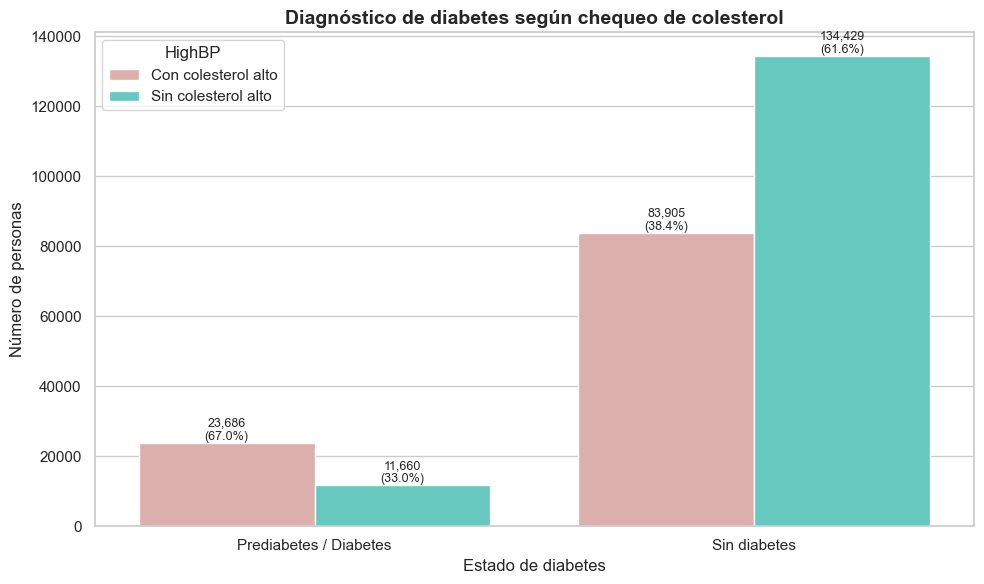

: 

In [ ]:
plot_pct = (
    tabla_pct
    .reset_index()
    .melt(id_vars="Diabetes_binary",
          var_name=variable,
          value_name="Porcentaje")
)

plot_abs = (
    tabla_abs
    .reset_index()
    .melt(id_vars="Diabetes_binary",
          var_name=variable,
          value_name="Frecuencia")
)

plot_merged = plot_abs.merge(plot_pct, on=["Diabetes_binary", variable])

fig, ax = plt.subplots(figsize=(10, 6))

ax = sns.barplot(
    data=plot_abs,
    x="Diabetes_binary",
    y="Frecuencia",
    hue=variable,
    palette=["#E2A8A4", "#56D8CB"]
)

for bar, (_, row) in zip(ax.patches, plot_merged.iterrows()):
    count = int(bar.get_height())
    pct = row["Porcentaje"]
    ax.annotate(
        f'{count:,}\n({pct:.1f}%)',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

ax.set_title(f"Diagnóstico de diabetes según chequeo de colesterol",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Estado de diabetes")
ax.set_ylabel("Número de personas")

plt.tight_layout()
plt.show()

#### **11.1.4 Objetivo vs Smoker**

In [75]:
from scipy.stats import chi2_contingency

# Crear tabla de contingencia
variable = 'Smoker'
tabla_abs = pd.crosstab(df_viz[variable], df_viz[Objetivo], margins=True)
print("Tabla de contingencia:")
print(tabla_abs)
print("\n")
# Prueba chi-cuadrado
chi2, p, dof, expected = chi2_contingency(tabla_abs.iloc[:, :-1])

print("Chi-cuadrado:", round(chi2, 2))
print("Grados de libertad:", dof)
print("p-valor:", p)

# Odds Ratio
# Calcular Odds Ratio solo si es tabla 2x2
if tabla_abs.iloc[:, :-1].shape == (2, 2):
    
    a = tabla_abs.iloc[0, 0]
    b = tabla_abs.iloc[0, 1]
    c = tabla_abs.iloc[1, 0]
    d = tabla_abs.iloc[1, 1]
    
    odds_ratio = (a * d) / (b * c)
    print("Odds Ratio (OR):", round(odds_ratio, 2))
    
else:
    print("Odds Ratio no aplica (tabla mayor a 2x2)")

Tabla de contingencia:
Diabetes_binary  Prediabetes / Diabetes  Sin diabetes     All
Smoker                                                       
Fumador                           18317         94106  112423
No fumador                        17029        124228  141257
All                               35346        218334  253680


Chi-cuadrado: 937.41
Grados de libertad: 2
p-valor: 2.781000273150939e-204
Odds Ratio no aplica (tabla mayor a 2x2)


La tabla de contingencia muestra diferencias en la distribución del hábito de fumar según el estado diabético. En el grupo con **Prediabetes / Diabetes**, el 51.82% reporta ser fumador, mientras que el 48.18% no fuma. En contraste, en el grupo **Sin diabetes**, el 43.10% es fumador y el 56.90% no lo es.

Esta diferencia porcentual sugiere una mayor proporción de fumadores dentro del grupo con alteraciones metabólicas. Desde el punto de vista estadístico, la prueba de independencia Chi-cuadrado arroja un estadístico de **χ² =** 937.06, con 1 grado de libertad y un p-valor < 0.001, lo que indica evidencia estadísticamente significativa para rechazar la hipótesis nula de independencia entre el hábito de fumar y el estado diabético.

Adicionalmente, el Odds Ratio **(OR = 1.42)** indica que las probabilidades de presentar prediabetes/diabetes son aproximadamente 1.42 veces mayores en fumadores en comparación con no fumadores. Aunque la magnitud del efecto es moderada, la asociación es consistente y estadísticamente robusta, lo cual es esperable dada la gran muestra analizada.

En consecuencia, se concluye que existe una asociación estadísticamente significativa entre el hábito de fumar y la presencia de prediabetes/diabetes en la muestra. Desde una perspectiva epidemiológica, este resultado es coherente con la literatura que vincula el tabaquismo con alteraciones metabólicas, inflamación sistémica y mayor riesgo de enfermedades crónicas.

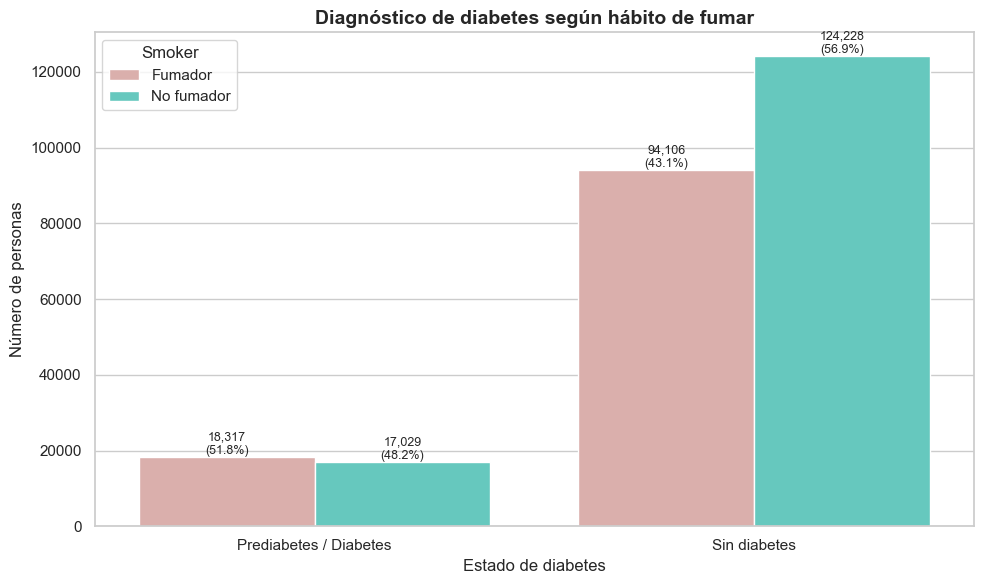

: 

In [ ]:
variable = "Smoker"

tabla_pct = pd.crosstab(
    df_viz["Diabetes_binary"],
    df_viz[variable],
    normalize="index"
) * 100

tabla_abs = pd.crosstab(
    df_viz["Diabetes_binary"],
    df_viz[variable]
)

plot_pct = (
    tabla_pct
    .reset_index()
    .melt(id_vars="Diabetes_binary",
          var_name=variable,
          value_name="Porcentaje")
)

plot_abs = (
    tabla_abs
    .reset_index()
    .melt(id_vars="Diabetes_binary",
          var_name=variable,
          value_name="Frecuencia")
)

plot_merged = plot_abs.merge(plot_pct, on=["Diabetes_binary", variable])

fig, ax = plt.subplots(figsize=(10, 6))

ax = sns.barplot(
    data=plot_abs,
    x="Diabetes_binary",
    y="Frecuencia",
    hue=variable,
    palette=["#E2A8A4", "#56D8CB"]
)

for bar, (_, row) in zip(ax.patches, plot_merged.iterrows()):
    count = int(bar.get_height())
    pct = row["Porcentaje"]
    ax.annotate(
        f'{count:,}\n({pct:.1f}%)',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

ax.set_title("Diagnóstico de diabetes según hábito de fumar",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Estado de diabetes")
ax.set_ylabel("Número de personas")

plt.tight_layout()
plt.show()

#### **11.1.5 Objetivo vs HeartDiseaseorAttack**

In [76]:
from scipy.stats import chi2_contingency

# Crear tabla de contingencia
variable = 'HeartDiseaseorAttack'
tabla_abs = pd.crosstab(df_viz[variable], df_viz[Objetivo], margins=True)
print("Tabla de contingencia:")
print(tabla_abs)
print("\n")
# Prueba chi-cuadrado
chi2, p, dof, expected = chi2_contingency(tabla_abs.iloc[:, :-1])

print("Chi-cuadrado:", round(chi2, 2))
print("Grados de libertad:", dof)
print("p-valor:", p)

# Odds Ratio
# Calcular Odds Ratio solo si es tabla 2x2
if tabla_abs.iloc[:, :-1].shape == (2, 2):
    
    a = tabla_abs.iloc[0, 0]
    b = tabla_abs.iloc[0, 1]
    c = tabla_abs.iloc[1, 0]
    d = tabla_abs.iloc[1, 1]
    
    odds_ratio = (a * d) / (b * c)
    print("Odds Ratio (OR):", round(odds_ratio, 2))
    
else:
    print("Odds Ratio no aplica (tabla mayor a 2x2)")

Tabla de contingencia:
Diabetes_binary          Prediabetes / Diabetes  Sin diabetes     All
HeartDiseaseorAttack                                                 
Con enfermedad cardíaca                    7878         16015   23893
Sin enfermedad cardíaca                   27468        202319  229787
All                                       35346        218334  253680


Chi-cuadrado: 7972.91
Grados de libertad: 2
p-valor: 0.0
Odds Ratio no aplica (tabla mayor a 2x2)


La tabla de contingencia evidencia una diferencia marcada en la prevalencia de enfermedad cardíaca o antecedente de infarto según el estado diabético. En el grupo con **Prediabetes / Diabetes**, el 22.29% reporta presentar enfermedad cardíaca, mientras que el 77.71% no la presenta. En contraste, dentro del grupo **Sin diabetes**, solo el 7.34% presenta enfermedad cardíaca y el 92.66% no la presenta.

Esta diferencia porcentual es sustancial y sugiere una fuerte asociación entre ambas condiciones. Desde el punto de vista estadístico, la prueba de independencia Chi-cuadrado arroja un estadístico de **χ² = 7971.16**, con 1 grado de libertad y un p-valor < 0.001, lo que proporciona evidencia contundente para rechazar la hipótesis nula de independencia entre la presencia de enfermedad cardíaca y el estado diabético.

Adicionalmente, el Odds Ratio **(OR = 3.62)** indica que las probabilidades de presentar prediabetes/diabetes son aproximadamente 3.6 veces mayores en individuos con enfermedad cardíaca o antecedente de infarto en comparación con aquellos sin esta condición. Este valor refleja una asociación de magnitud moderada a fuerte desde el punto de vista epidemiológico.

En consecuencia, se concluye que existe una asociación estadísticamente significativa y clínicamente relevante entre la presencia de enfermedad cardiovascular y el diagnóstico de prediabetes/diabetes en la muestra analizada. Este resultado es coherente con la literatura médica, que reconoce la diabetes como un factor de riesgo mayor para enfermedad cardiovascular y, a su vez, la coexistencia frecuente de ambas condiciones dentro del síndrome metabólico.

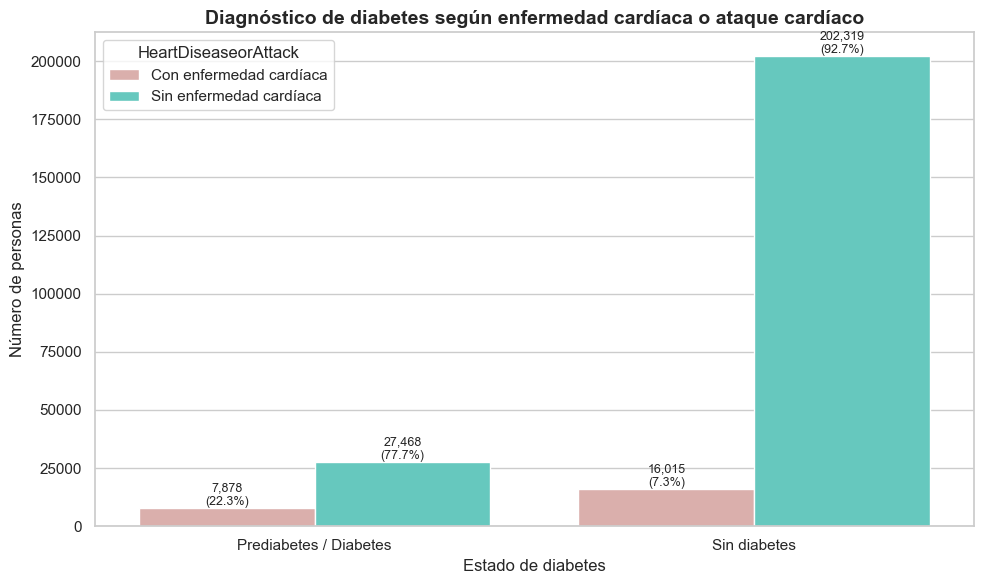

: 

In [ ]:
variable = "HeartDiseaseorAttack"

tabla_pct = pd.crosstab(
    df_viz["Diabetes_binary"],
    df_viz[variable],
    normalize="index"
) * 100

tabla_abs = pd.crosstab(
    df_viz["Diabetes_binary"],
    df_viz[variable]
)

plot_pct = (
    tabla_pct
    .reset_index()
    .melt(id_vars="Diabetes_binary",
          var_name=variable,
          value_name="Porcentaje")
)

plot_abs = (
    tabla_abs
    .reset_index()
    .melt(id_vars="Diabetes_binary",
          var_name=variable,
          value_name="Frecuencia")
)

plot_merged = plot_abs.merge(plot_pct, on=["Diabetes_binary", variable])

fig, ax = plt.subplots(figsize=(10, 6))

ax = sns.barplot(
    data=plot_abs,
    x="Diabetes_binary",
    y="Frecuencia",
    hue=variable,
    palette=["#E2A8A4", "#56D8CB"]
)

for bar, (_, row) in zip(ax.patches, plot_merged.iterrows()):
    count = int(bar.get_height())
    pct = row["Porcentaje"]
    ax.annotate(
        f'{count:,}\n({pct:.1f}%)',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

ax.set_title("Diagnóstico de diabetes según enfermedad cardíaca o ataque cardíaco",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Estado de diabetes")
ax.set_ylabel("Número de personas")

plt.tight_layout()
plt.show()

#### **11.1.6 Objetivo vs PhysActivity**

In [77]:
from scipy.stats import chi2_contingency

# Crear tabla de contingencia
variable = 'PhysActivity'
tabla_abs = pd.crosstab(df_viz[variable], df_viz[Objetivo], margins=True)
print("Tabla de contingencia:")
print(tabla_abs)
print("\n")
# Prueba chi-cuadrado
chi2, p, dof, expected = chi2_contingency(tabla_abs.iloc[:, :-1])

print("Chi-cuadrado:", round(chi2, 2))
print("Grados de libertad:", dof)
print("p-valor:", p)

# Odds Ratio
# Calcular Odds Ratio solo si es tabla 2x2
if tabla_abs.iloc[:, :-1].shape == (2, 2):
    
    a = tabla_abs.iloc[0, 0]
    b = tabla_abs.iloc[0, 1]
    c = tabla_abs.iloc[1, 0]
    d = tabla_abs.iloc[1, 1]
    
    odds_ratio = (a * d) / (b * c)
    print("Odds Ratio (OR):", round(odds_ratio, 2))
    
else:
    print("Odds Ratio no aplica (tabla mayor a 2x2)")

Tabla de contingencia:
Diabetes_binary       Prediabetes / Diabetes  Sin diabetes     All
PhysActivity                                                      
Con actividad física                   22287        169633  191920
Sin actividad física                   13059         48701   61760
All                                    35346        218334  253680


Chi-cuadrado: 3540.21
Grados de libertad: 2
p-valor: 0.0
Odds Ratio no aplica (tabla mayor a 2x2)


La tabla de contingencia muestra diferencias claras en la práctica de actividad física según el estado diabético. En el grupo con **Prediabetes / Diabetes**, el 63.05% reporta realizar actividad física, mientras que el 36.95% no la realiza. En contraste, dentro del grupo **Sin diabetes**, el 77.69% realiza actividad física y el 22.31% no lo hace.

Estas diferencias porcentuales sugieren que la inactividad física es más frecuente en el grupo con alteraciones metabólicas. Desde el punto de vista estadístico, la prueba de independencia Chi-cuadrado arroja un estadístico de **χ² = 3539.42**, con 1 grado de libertad y un p-valor < 0.001, lo que proporciona evidencia suficiente para rechazar la hipótesis nula de independencia entre la actividad física y el estado diabético.

Adicionalmente, el Odds Ratio **(OR = 0.49)** indica que las probabilidades de presentar prediabetes/diabetes son aproximadamente 51% menores en individuos que realizan actividad física en comparación con aquellos que no la realizan. Un OR menor que 1 sugiere un efecto protector de la actividad física frente a la presencia de alteraciones metabólicas.

En consecuencia, se concluye que existe una asociación estadísticamente significativa y clínicamente relevante entre la práctica de actividad física y el estado diabético en la muestra analizada. Este hallazgo es consistente con la evidencia epidemiológica, que reconoce la actividad física como un factor protector frente al desarrollo de diabetes tipo 2 y otras alteraciones metabólicas.

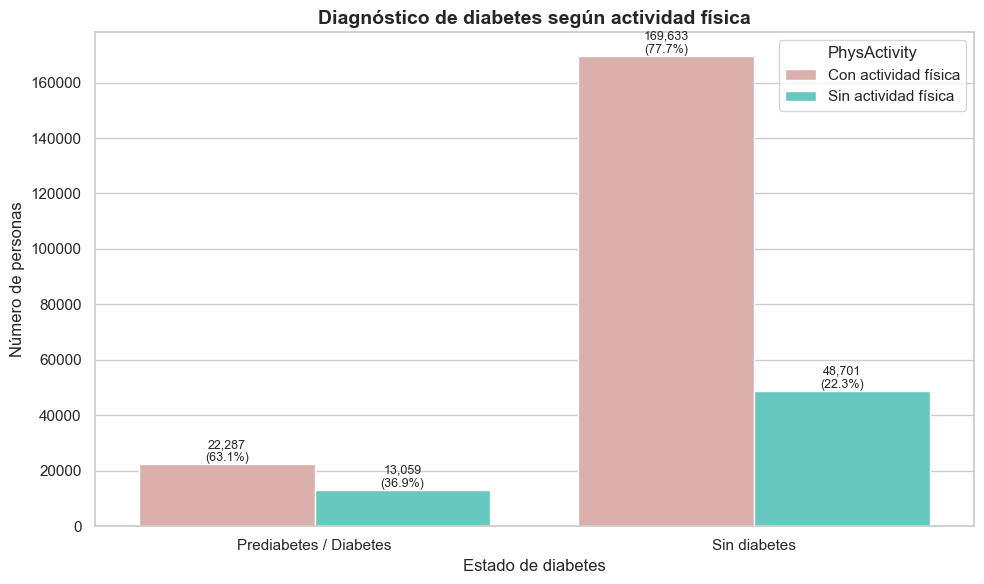

: 

In [ ]:
variable = "PhysActivity"

tabla_pct = pd.crosstab(
    df_viz["Diabetes_binary"],
    df_viz[variable],
    normalize="index"
) * 100

tabla_abs = pd.crosstab(
    df_viz["Diabetes_binary"],
    df_viz[variable]
)

plot_pct = (
    tabla_pct
    .reset_index()
    .melt(id_vars="Diabetes_binary",
          var_name=variable,
          value_name="Porcentaje")
)

plot_abs = (
    tabla_abs
    .reset_index()
    .melt(id_vars="Diabetes_binary",
          var_name=variable,
          value_name="Frecuencia")
)

plot_merged = plot_abs.merge(plot_pct, on=["Diabetes_binary", variable])

fig, ax = plt.subplots(figsize=(10, 6))

ax = sns.barplot(
    data=plot_abs,
    x="Diabetes_binary",
    y="Frecuencia",
    hue=variable,
    palette=["#E2A8A4", "#56D8CB"]
)

for bar, (_, row) in zip(ax.patches, plot_merged.iterrows()):
    count = int(bar.get_height())
    pct = row["Porcentaje"]
    ax.annotate(
        f'{count:,}\n({pct:.1f}%)',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

ax.set_title("Diagnóstico de diabetes según actividad física",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Estado de diabetes")
ax.set_ylabel("Número de personas")

plt.tight_layout()
plt.show()

#### **11.1.7 Objetivo vs Fruits**

In [78]:
from scipy.stats import chi2_contingency

# Crear tabla de contingencia
variable = 'Fruits'
tabla_abs = pd.crosstab(df_viz[variable], df_viz[Objetivo], margins=True)
print("Tabla de contingencia:")
print(tabla_abs)
print("\n")
# Prueba chi-cuadrado
chi2, p, dof, expected = chi2_contingency(tabla_abs.iloc[:, :-1])

print("Chi-cuadrado:", round(chi2, 2))
print("Grados de libertad:", dof)
print("p-valor:", p)

# Odds Ratio
# Calcular Odds Ratio solo si es tabla 2x2
if tabla_abs.iloc[:, :-1].shape == (2, 2):
    
    a = tabla_abs.iloc[0, 0]
    b = tabla_abs.iloc[0, 1]
    c = tabla_abs.iloc[1, 0]
    d = tabla_abs.iloc[1, 1]
    
    odds_ratio = (a * d) / (b * c)
    print("Odds Ratio (OR):", round(odds_ratio, 2))
    
else:
    print("Odds Ratio no aplica (tabla mayor a 2x2)")

Tabla de contingencia:
Diabetes_binary           Prediabetes / Diabetes  Sin diabetes     All
Fruits                                                                
Consume frutas diario                      20693        140205  160898
No consume frutas diario                   14653         78129   92782
All                                        35346        218334  253680


Chi-cuadrado: 421.86
Grados de libertad: 2
p-valor: 2.4838961153120513e-92
Odds Ratio no aplica (tabla mayor a 2x2)


La tabla de contingencia muestra diferencias en el consumo diario de frutas según el estado diabético. En el grupo con **Prediabetes / Diabetes**, el 58.54% reporta consumir frutas diariamente, mientras que el 41.46% no lo hace. En contraste, en el grupo **Sin diabetes**, el 64.22% consume frutas diariamente y el 35.78% no lo hace.

Estas diferencias sugieren que el no consumo diario de frutas es ligeramente más frecuente en el grupo con alteraciones metabólicas. Desde el punto de vista estadístico, la prueba de independencia Chi-cuadrado arroja un estadístico de **χ² = 421.61**, con 1 grado de libertad y un p-valor < 0.001, lo que indica que existe evidencia estadísticamente significativa para rechazar la hipótesis nula de independencia entre el consumo de frutas y el estado diabético.

Adicionalmente, el Odds Ratio **(OR = 0.79)** indica que las probabilidades de presentar prediabetes/diabetes son aproximadamente 21% menores en individuos que consumen frutas diariamente en comparación con quienes no lo hacen. Al ser un OR menor que 1, sugiere un posible efecto protector leve asociado al consumo regular de frutas.

Sin embargo, aunque la asociación es estadísticamente significativa, la magnitud del efecto es moderada a baja en comparación con otras variables analizadas (como hipertensión o enfermedad cardíaca). En consecuencia, el consumo diario de frutas parece estar asociado con menor presencia de alteraciones metabólicas, pero su impacto relativo es menos fuerte que otros factores cardiometabólicos evaluados.

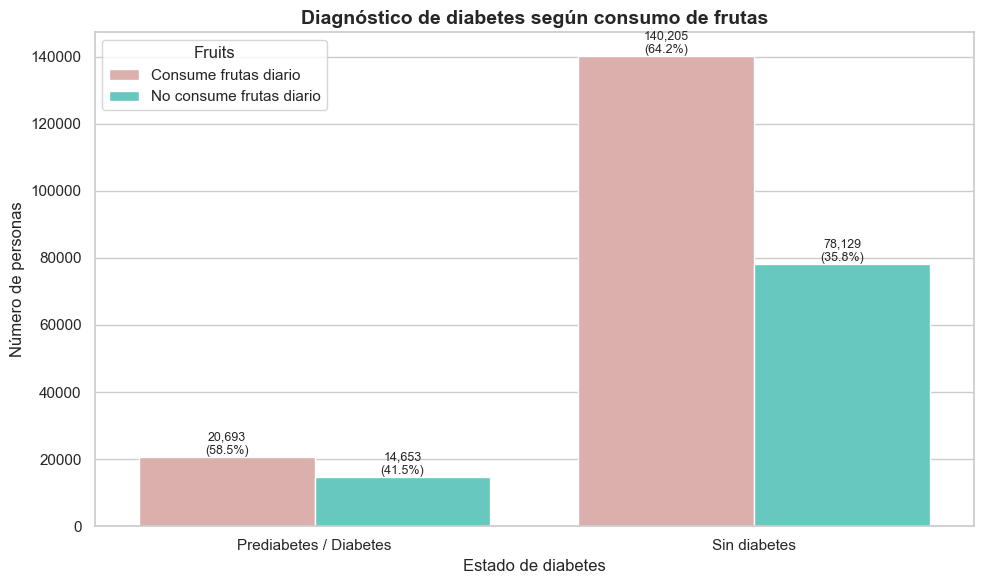

: 

In [ ]:


variable = "Fruits"

tabla_pct = pd.crosstab(
    df_viz["Diabetes_binary"],
    df_viz[variable],
    normalize="index"
) * 100

tabla_abs = pd.crosstab(
    df_viz["Diabetes_binary"],
    df_viz[variable]
)

plot_pct = (
    tabla_pct
    .reset_index()
    .melt(id_vars="Diabetes_binary",
          var_name=variable,
          value_name="Porcentaje")
)

plot_abs = (
    tabla_abs
    .reset_index()
    .melt(id_vars="Diabetes_binary",
          var_name=variable,
          value_name="Frecuencia")
)

plot_merged = plot_abs.merge(plot_pct, on=["Diabetes_binary", variable])

fig, ax = plt.subplots(figsize=(10, 6))

ax = sns.barplot(
    data=plot_abs,
    x="Diabetes_binary",
    y="Frecuencia",
    hue=variable,
    palette=["#E2A8A4", "#56D8CB"]
)

for bar, (_, row) in zip(ax.patches, plot_merged.iterrows()):
    count = int(bar.get_height())
    pct = row["Porcentaje"]
    ax.annotate(
        f'{count:,}\n({pct:.1f}%)',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

ax.set_title("Diagnóstico de diabetes según consumo de frutas",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Estado de diabetes")
ax.set_ylabel("Número de personas")

plt.tight_layout()
plt.show()

#### **11.1.8 Objetivo vs Veggies**

In [79]:
from scipy.stats import chi2_contingency

# Crear tabla de contingencia
variable = 'Veggies'
tabla_abs = pd.crosstab(df_viz[variable], df_viz[Objetivo], margins=True)
print("Tabla de contingencia:")
print(tabla_abs)
print("\n")
# Prueba chi-cuadrado
chi2, p, dof, expected = chi2_contingency(tabla_abs.iloc[:, :-1])

print("Chi-cuadrado:", round(chi2, 2))
print("Grados de libertad:", dof)
print("p-valor:", p)

# Odds Ratio
# Calcular Odds Ratio solo si es tabla 2x2
if tabla_abs.iloc[:, :-1].shape == (2, 2):
    
    a = tabla_abs.iloc[0, 0]
    b = tabla_abs.iloc[0, 1]
    c = tabla_abs.iloc[1, 0]
    d = tabla_abs.iloc[1, 1]
    
    odds_ratio = (a * d) / (b * c)
    print("Odds Ratio (OR):", round(odds_ratio, 2))
    
else:
    print("Odds Ratio no aplica (tabla mayor a 2x2)")

Tabla de contingencia:
Diabetes_binary             Prediabetes / Diabetes  Sin diabetes     All
Veggies                                                                 
Consume verduras diario                      26736        179105  205841
No consume verduras diario                    8610         39229   47839
All                                          35346        218334  253680


Chi-cuadrado: 812.22
Grados de libertad: 2
p-valor: 4.245008168942297e-177
Odds Ratio no aplica (tabla mayor a 2x2)


La tabla de contingencia muestra diferencias en el consumo diario de verduras según el estado diabético. En el grupo con **Prediabetes / Diabetes**, el 75.64% reporta consumir verduras diariamente, mientras que el 24.36% no lo hace. En contraste, dentro del grupo Sin diabetes, el 82.03% consume verduras diariamente y el 17.97% no lo hace.

Estas diferencias sugieren que el no consumo diario de verduras es más frecuente en el grupo con alteraciones metabólicas. Desde el punto de vista estadístico, la prueba de independencia Chi-cuadrado arroja un estadístico de **χ² = 811.81**, con 1 grado de libertad y un p-valor < 0.001, lo que indica evidencia estadísticamente significativa para rechazar la hipótesis nula de independencia entre el consumo de verduras y el estado diabético.

Adicionalmente, el Odds Ratio **(OR = 0.68)** indica que las probabilidades de presentar prediabetes/diabetes son aproximadamente 32% menores en individuos que consumen verduras diariamente en comparación con quienes no lo hacen. Al ser un OR menor que 1, este resultado sugiere un efecto protector moderado asociado al consumo regular de verduras.

En consecuencia, se concluye que existe una asociación estadísticamente significativa y epidemiológicamente relevante entre el consumo diario de verduras y la presencia de prediabetes/diabetes en la muestra analizada. Este hallazgo es coherente con la evidencia científica que vincula dietas ricas en vegetales con menor riesgo de alteraciones metabólicas y enfermedades crónicas.

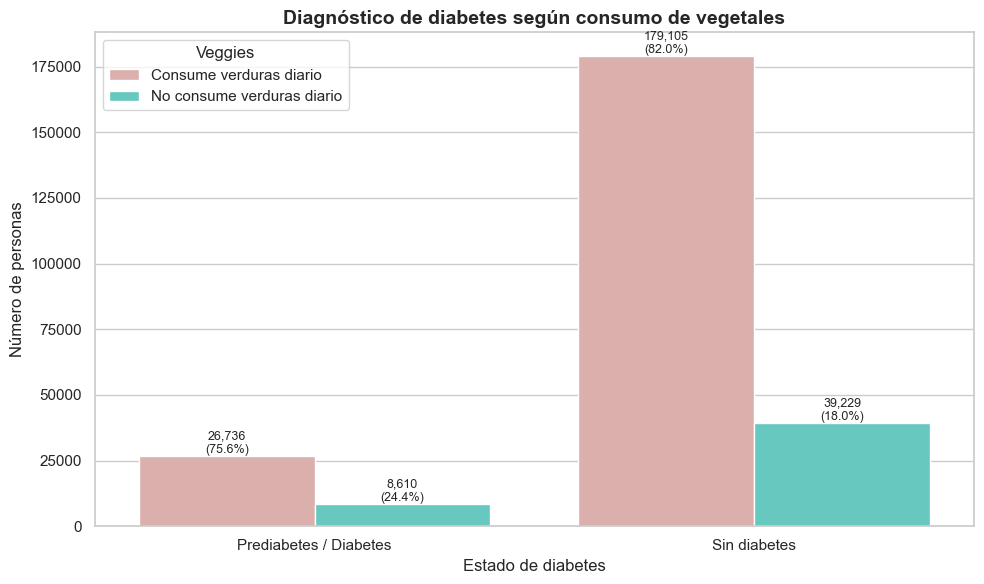

: 

In [ ]:

variable = "Veggies"

tabla_pct = pd.crosstab(
    df_viz["Diabetes_binary"],
    df_viz[variable],
    normalize="index"
) * 100

tabla_abs = pd.crosstab(
    df_viz["Diabetes_binary"],
    df_viz[variable]
)

plot_pct = (
    tabla_pct
    .reset_index()
    .melt(id_vars="Diabetes_binary",
          var_name=variable,
          value_name="Porcentaje")
)

plot_abs = (
    tabla_abs
    .reset_index()
    .melt(id_vars="Diabetes_binary",
          var_name=variable,
          value_name="Frecuencia")
)

plot_merged = plot_abs.merge(plot_pct, on=["Diabetes_binary", variable])

fig, ax = plt.subplots(figsize=(10, 6))

ax = sns.barplot(
    data=plot_abs,
    x="Diabetes_binary",
    y="Frecuencia",
    hue=variable,
    palette=["#E2A8A4", "#56D8CB"]
)

for bar, (_, row) in zip(ax.patches, plot_merged.iterrows()):
    count = int(bar.get_height())
    pct = row["Porcentaje"]
    ax.annotate(
        f'{count:,}\n({pct:.1f}%)',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

ax.set_title("Diagnóstico de diabetes según consumo de vegetales",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Estado de diabetes")
ax.set_ylabel("Número de personas")

plt.tight_layout()
plt.show()

#### **11.1.9 Objetivo vs HvyAlcoholConsump**

In [80]:
from scipy.stats import chi2_contingency

# Crear tabla de contingencia
variable = 'HvyAlcoholConsump'
tabla_abs = pd.crosstab(df_viz[variable], df_viz[Objetivo], margins=True)
print("Tabla de contingencia:")
print(tabla_abs)
print("\n")
# Prueba chi-cuadrado
chi2, p, dof, expected = chi2_contingency(tabla_abs.iloc[:, :-1])

print("Chi-cuadrado:", round(chi2, 2))
print("Grados de libertad:", dof)
print("p-valor:", p)

# Odds Ratio
# Calcular Odds Ratio solo si es tabla 2x2
if tabla_abs.iloc[:, :-1].shape == (2, 2):
    
    a = tabla_abs.iloc[0, 0]
    b = tabla_abs.iloc[0, 1]
    c = tabla_abs.iloc[1, 0]
    d = tabla_abs.iloc[1, 1]
    
    odds_ratio = (a * d) / (b * c)
    print("Odds Ratio (OR):", round(odds_ratio, 2))
    
else:
    print("Odds Ratio no aplica (tabla mayor a 2x2)")

Tabla de contingencia:
Diabetes_binary          Prediabetes / Diabetes  Sin diabetes     All
HvyAlcoholConsump                                                    
Consumo alto alcohol                        832         13424   14256
No consumo alto alcohol                   34514        204910  239424
All                                       35346        218334  253680


Chi-cuadrado: 825.83
Grados de libertad: 2
p-valor: 4.703492433932001e-180
Odds Ratio no aplica (tabla mayor a 2x2)


La tabla de contingencia muestra diferencias en el consumo alto de alcohol según el estado diabético. En el grupo con **Prediabetes / Diabetes**, el 2.35% reporta consumo alto de alcohol, mientras que el 97.65% no presenta este patrón de consumo. En contraste, en el grupo Sin diabetes, el 6.15% reporta consumo alto de alcohol y el 93.85% no lo presenta.

A simple vista, el consumo alto de alcohol parece ser menos frecuente en el grupo con alteraciones metabólicas. Desde el punto de vista estadístico, la prueba de independencia Chi-cuadrado arroja un estadístico de **χ² = 825.12**, con 1 grado de libertad y un p-valor < 0.001, lo que indica evidencia estadísticamente significativa para rechazar la hipótesis nula de independencia entre el consumo alto de alcohol y el estado diabético.

Adicionalmente, el Odds Ratio **(OR = 0.37)**indica que las probabilidades de presentar prediabetes/diabetes son aproximadamente 63% menores en individuos con consumo alto de alcohol en comparación con aquellos que no presentan este patrón de consumo. Sin embargo, este resultado debe interpretarse con cautela. Un OR menor que 1 no implica necesariamente que el consumo alto de alcohol sea protector; más bien, podría reflejar factores de confusión, cambios en el comportamiento tras el diagnóstico (reducción del consumo después de ser diagnosticado) o sesgos asociados al autorreporte.

En consecuencia, aunque existe una asociación estadísticamente significativa entre el consumo alto de alcohol y el estado diabético en la muestra analizada, la dirección aparente del efecto debe analizarse con prudencia desde el punto de vista epidemiológico y no debe interpretarse como un efecto protector causal.

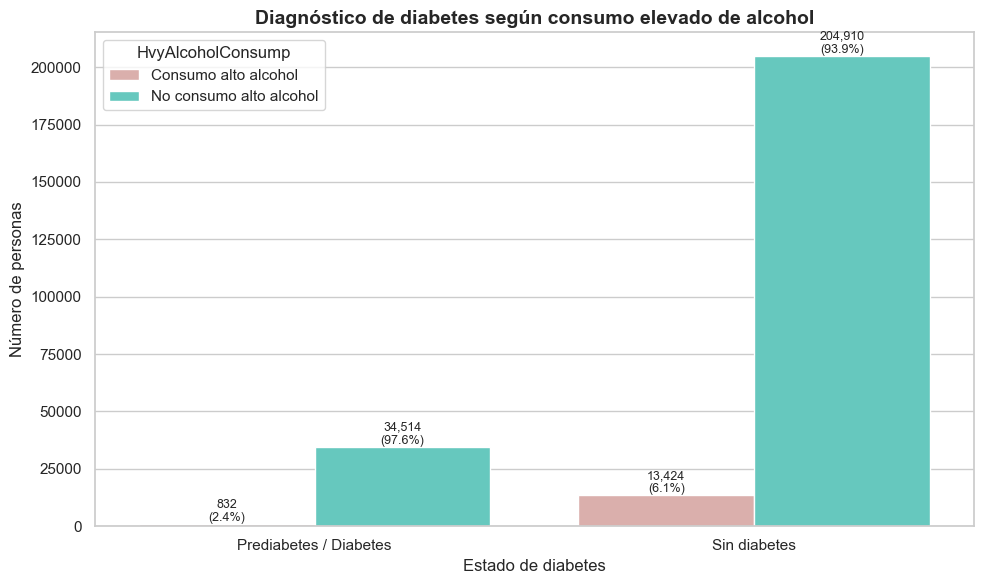

: 

In [ ]:
variable = "HvyAlcoholConsump"

tabla_pct = pd.crosstab(
    df_viz["Diabetes_binary"],
    df_viz[variable],
    normalize="index"
) * 100

tabla_abs = pd.crosstab(
    df_viz["Diabetes_binary"],
    df_viz[variable]
)

plot_pct = (
    tabla_pct
    .reset_index()
    .melt(id_vars="Diabetes_binary",
          var_name=variable,
          value_name="Porcentaje")
)

plot_abs = (
    tabla_abs
    .reset_index()
    .melt(id_vars="Diabetes_binary",
          var_name=variable,
          value_name="Frecuencia")
)

plot_merged = plot_abs.merge(plot_pct, on=["Diabetes_binary", variable])

fig, ax = plt.subplots(figsize=(10, 6))

ax = sns.barplot(
    data=plot_abs,
    x="Diabetes_binary",
    y="Frecuencia",
    hue=variable,
    palette=["#E2A8A4", "#56D8CB"]
)

for bar, (_, row) in zip(ax.patches, plot_merged.iterrows()):
    count = int(bar.get_height())
    pct = row["Porcentaje"]
    ax.annotate(
        f'{count:,}\n({pct:.1f}%)',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

ax.set_title("Diagnóstico de diabetes según consumo elevado de alcohol",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Estado de diabetes")
ax.set_ylabel("Número de personas")

plt.tight_layout()
plt.show()

#### **11.1.10 Objetivo vs AnyHealthcare**

In [82]:
from scipy.stats import chi2_contingency

# Crear tabla de contingencia
variable = 'AnyHealthcare'
tabla_abs = pd.crosstab(df_viz[variable], df_viz[Objetivo], margins=True)
print("Tabla de contingencia:")
print(tabla_abs)
print("\n")
# Prueba chi-cuadrado
chi2, p, dof, expected = chi2_contingency(tabla_abs.iloc[:, :-1])

print("Chi-cuadrado:", round(chi2, 2))
print("Grados de libertad:", dof)
print("p-valor:", p)

# Odds Ratio
# Calcular Odds Ratio solo si es tabla 2x2
if tabla_abs.iloc[:, :-1].shape == (2, 2):
    
    a = tabla_abs.iloc[0, 0]
    b = tabla_abs.iloc[0, 1]
    c = tabla_abs.iloc[1, 0]
    d = tabla_abs.iloc[1, 1]
    
    odds_ratio = (a * d) / (b * c)
    print("Odds Ratio (OR):", round(odds_ratio, 2))
    
else:
    print("Odds Ratio no aplica (tabla mayor a 2x2)")

Tabla de contingencia:
Diabetes_binary       Prediabetes / Diabetes  Sin diabetes     All
AnyHealthcare                                                     
Con cobertura médica                   33924        207339  241263
Sin cobertura médica                    1422         10995   12417
All                                    35346        218334  253680


Chi-cuadrado: 67.03
Grados de libertad: 2
p-valor: 2.784027985036628e-15
Odds Ratio no aplica (tabla mayor a 2x2)


La tabla de contingencia muestra diferencias leves en la cobertura médica según el estado diabético. En el grupo con **Prediabetes / Diabetes**, el 95.98% reporta contar con cobertura médica, mientras que el 4.02% no la tiene. En contraste, dentro del grupo **Sin diabetes**, el 94.96% tiene cobertura y el 5.04% no la tiene.

Aunque la diferencia porcentual es pequeña (aproximadamente 1 punto porcentual), la prueba de independencia Chi-cuadrado arroja un estadístico de **χ² = 66.81**, con 1 grado de libertad y un p-valor < 0.001, lo que indica que la asociación es estadísticamente significativa. Sin embargo, dado el gran tamaño muestral, incluso diferencias pequeñas pueden resultar significativas desde el punto de vista estadístico.

El Odds Ratio **(OR = 1.27)** indica que las probabilidades de presentar prediabetes/diabetes son aproximadamente 27% mayores en individuos con cobertura médica en comparación con quienes no la tienen. Este resultado no debe interpretarse como que la cobertura médica aumente el riesgo; más bien, probablemente refleja un mayor acceso al diagnóstico y al sistema de salud en personas que cuentan con cobertura, lo que incrementa la probabilidad de detección de la enfermedad.

En consecuencia, aunque existe una asociación estadísticamente significativa entre la cobertura médica y el estado diabético en la muestra analizada, la magnitud del efecto es baja y su interpretación debe contextualizarse en términos de acceso a servicios de salud y detección oportuna, más que como un factor de riesgo causal.

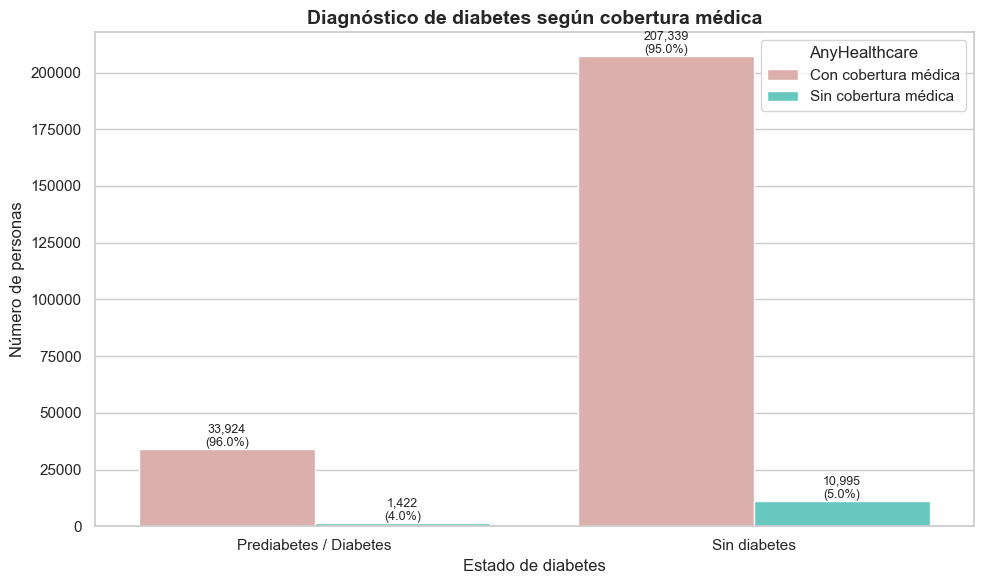

: 

In [ ]:
variable = "AnyHealthcare"

tabla_pct = pd.crosstab(
    df_viz["Diabetes_binary"],
    df_viz[variable],
    normalize="index"
) * 100

tabla_abs = pd.crosstab(
    df_viz["Diabetes_binary"],
    df_viz[variable]
)

plot_pct = (
    tabla_pct
    .reset_index()
    .melt(id_vars="Diabetes_binary",
          var_name=variable,
          value_name="Porcentaje")
)

plot_abs = (
    tabla_abs
    .reset_index()
    .melt(id_vars="Diabetes_binary",
          var_name=variable,
          value_name="Frecuencia")
)

plot_merged = plot_abs.merge(plot_pct, on=["Diabetes_binary", variable])

fig, ax = plt.subplots(figsize=(10, 6))

ax = sns.barplot(
    data=plot_abs,
    x="Diabetes_binary",
    y="Frecuencia",
    hue=variable,
    palette=["#E2A8A4", "#56D8CB"]
)

for bar, (_, row) in zip(ax.patches, plot_merged.iterrows()):
    count = int(bar.get_height())
    pct = row["Porcentaje"]
    ax.annotate(
        f'{count:,}\n({pct:.1f}%)',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

ax.set_title("Diagnóstico de diabetes según cobertura médica",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Estado de diabetes")
ax.set_ylabel("Número de personas")

plt.tight_layout()
plt.show()

#### **11.1.11 Objetivo vs NoDocbcCost**

In [83]:
from scipy.stats import chi2_contingency

# Crear tabla de contingencia
variable = 'NoDocbcCost'
tabla_abs = pd.crosstab(df_viz[variable], df_viz[Objetivo], margins=True)
print("Tabla de contingencia:")
print(tabla_abs)
print("\n")
# Prueba chi-cuadrado
chi2, p, dof, expected = chi2_contingency(tabla_abs.iloc[:, :-1])

print("Chi-cuadrado:", round(chi2, 2))
print("Grados de libertad:", dof)
print("p-valor:", p)

# Odds Ratio
# Calcular Odds Ratio solo si es tabla 2x2
if tabla_abs.iloc[:, :-1].shape == (2, 2):
    
    a = tabla_abs.iloc[0, 0]
    b = tabla_abs.iloc[0, 1]
    c = tabla_abs.iloc[1, 0]
    d = tabla_abs.iloc[1, 1]
    
    odds_ratio = (a * d) / (b * c)
    print("Odds Ratio (OR):", round(odds_ratio, 2))
    
else:
    print("Odds Ratio no aplica (tabla mayor a 2x2)")

Tabla de contingencia:
Diabetes_binary        Prediabetes / Diabetes  Sin diabetes     All
NoDocbcCost                                                        
Con barrera económica                    3742         17612   21354
Sin barrera económica                   31604        200722  232326
All                                     35346        218334  253680


Chi-cuadrado: 250.64
Grados de libertad: 2
p-valor: 3.7505380810197325e-55
Odds Ratio no aplica (tabla mayor a 2x2)


La tabla de contingencia muestra diferencias en la presencia de barreras económicas para acceder a servicios médicos según el estado diabético. En el grupo con **Prediabetes / Diabetes**, el 10.59% reporta haber tenido una barrera económica para consultar al médico, mientras que el 89.41% no la reporta. En contraste, en el grupo **Sin diabetes**, el 8.07% presenta esta barrera y el 91.93% no la presenta.

Estas diferencias sugieren que las barreras económicas para el acceso a la atención médica son ligeramente más frecuentes en el grupo con alteraciones metabólicas. Desde el punto de vista estadístico, la prueba de independencia Chi-cuadrado arroja un estadístico de **χ² = 250.31**, con 1 grado de libertad y un p-valor < 0.001, lo que indica que existe evidencia estadísticamente significativa para rechazar la hipótesis nula de independencia entre la presencia de barreras económicas y el estado diabético.

El Odds Ratio **(OR = 1.35)** indica que las probabilidades de presentar prediabetes/diabetes son aproximadamente 35% mayores en individuos que reportan barreras económicas para acceder al médico, en comparación con aquellos que no las reportan. Aunque la magnitud del efecto es moderada, el resultado sugiere una asociación relevante desde el punto de vista social y estructural.

En consecuencia, se concluye que existe una asociación estadísticamente significativa entre las barreras económicas en el acceso a la atención médica y el estado diabético en la muestra analizada. Este hallazgo puede reflejar desigualdades en el acceso a servicios preventivos y de control, lo que podría influir tanto en el diagnóstico oportuno como en el manejo adecuado de la enfermedad.

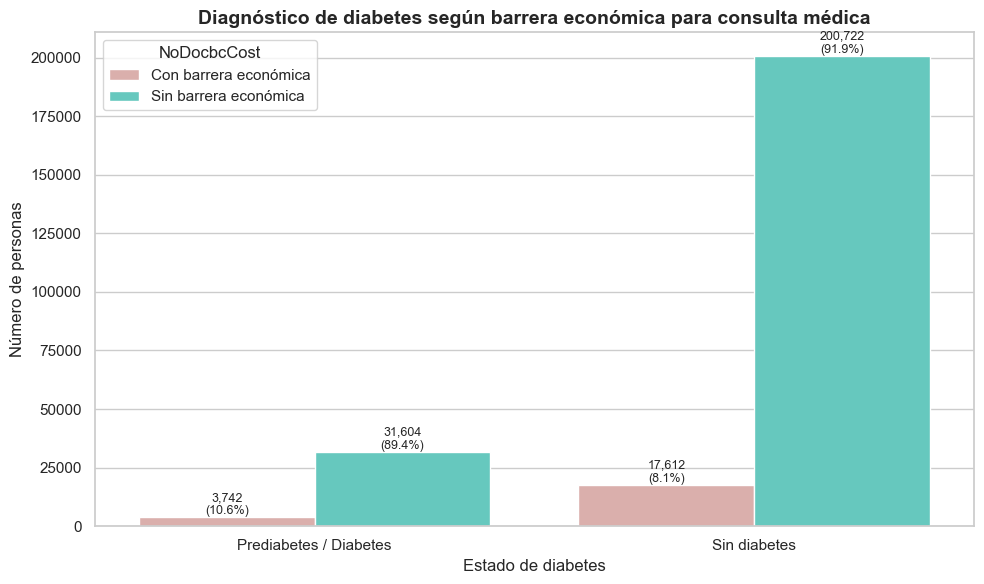

: 

In [ ]:
variable = "NoDocbcCost"

tabla_pct = pd.crosstab(
    df_viz["Diabetes_binary"],
    df_viz[variable],
    normalize="index"
) * 100

tabla_abs = pd.crosstab(
    df_viz["Diabetes_binary"],
    df_viz[variable]
)

plot_pct = (
    tabla_pct
    .reset_index()
    .melt(id_vars="Diabetes_binary",
          var_name=variable,
          value_name="Porcentaje")
)

plot_abs = (
    tabla_abs
    .reset_index()
    .melt(id_vars="Diabetes_binary",
          var_name=variable,
          value_name="Frecuencia")
)

plot_merged = plot_abs.merge(plot_pct, on=["Diabetes_binary", variable])

fig, ax = plt.subplots(figsize=(10, 6))

ax = sns.barplot(
    data=plot_abs,
    x="Diabetes_binary",
    y="Frecuencia",
    hue=variable,
    palette=["#E2A8A4", "#56D8CB"]
)

for bar, (_, row) in zip(ax.patches, plot_merged.iterrows()):
    count = int(bar.get_height())
    pct = row["Porcentaje"]
    ax.annotate(
        f'{count:,}\n({pct:.1f}%)',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

ax.set_title("Diagnóstico de diabetes según barrera económica para consulta médica",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Estado de diabetes")
ax.set_ylabel("Número de personas")

plt.tight_layout()
plt.show()

#### **11.1.12 Objetivo vs DiffWalk**

In [84]:
from scipy.stats import chi2_contingency

# Crear tabla de contingencia
variable = 'DiffWalk'
tabla_abs = pd.crosstab(df_viz[variable], df_viz[Objetivo], margins=True)
print("Tabla de contingencia:")
print(tabla_abs)
print("\n")
# Prueba chi-cuadrado
chi2, p, dof, expected = chi2_contingency(tabla_abs.iloc[:, :-1])

print("Chi-cuadrado:", round(chi2, 2))
print("Grados de libertad:", dof)
print("p-valor:", p)

# Odds Ratio
# Calcular Odds Ratio solo si es tabla 2x2
if tabla_abs.iloc[:, :-1].shape == (2, 2):
    
    a = tabla_abs.iloc[0, 0]
    b = tabla_abs.iloc[0, 1]
    c = tabla_abs.iloc[1, 0]
    d = tabla_abs.iloc[1, 1]
    
    odds_ratio = (a * d) / (b * c)
    print("Odds Ratio (OR):", round(odds_ratio, 2))
    
else:
    print("Odds Ratio no aplica (tabla mayor a 2x2)")

Tabla de contingencia:
Diabetes_binary            Prediabetes / Diabetes  Sin diabetes     All
DiffWalk                                                               
Con dificultad al caminar                   13121         29554   42675
Sin dificultad al caminar                   22225        188780  211005
All                                         35346        218334  253680


Chi-cuadrado: 12094.01
Grados de libertad: 2
p-valor: 0.0
Odds Ratio no aplica (tabla mayor a 2x2)


La tabla de contingencia evidencia una diferencia marcada en la presencia de dificultad para caminar según el estado diabético. En el grupo con **Prediabetes / Diabetes**, el 37.12% reporta presentar dificultad al caminar, mientras que el 62.88% no la presenta. En contraste, dentro del grupo Sin diabetes, solo el 13.54% reporta dificultad al caminar y el 86.46% no presenta esta condición.

La diferencia porcentual es considerable (más de 23 puntos porcentuales), lo que sugiere una asociación fuerte entre ambas variables. Desde el punto de vista estadístico, la prueba de independencia Chi-cuadrado arroja un estadístico de **χ² = 12092.32**, con 1 grado de libertad y un p-valor < 0.001, lo que indica evidencia altamente significativa para rechazar la hipótesis nula de independencia entre la dificultad para caminar y el estado diabético.

Adicionalmente, el Odds Ratio **(OR = 3.77)** indica que las probabilidades de presentar prediabetes/diabetes son aproximadamente 3.8 veces mayores en individuos que reportan dificultad para caminar en comparación con quienes no la presentan. Este valor refleja una asociación de magnitud fuerte desde el punto de vista epidemiológico.

En consecuencia, se concluye que existe una asociación estadísticamente significativa y clínicamente relevante entre la dificultad para caminar y el diagnóstico de prediabetes/diabetes en la muestra analizada. Este hallazgo es coherente con la literatura, ya que la diabetes se asocia frecuentemente con complicaciones como neuropatía periférica, alteraciones vasculares y limitaciones funcionales que pueden afectar la movilidad.

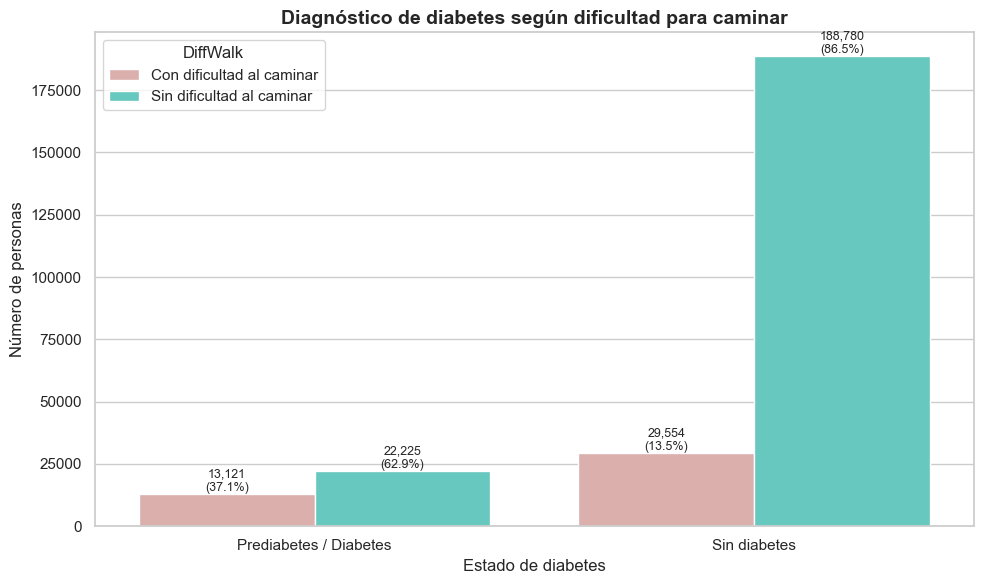

: 

In [ ]:
variable = "DiffWalk"

tabla_pct = pd.crosstab(
    df_viz["Diabetes_binary"],
    df_viz[variable],
    normalize="index"
) * 100

tabla_abs = pd.crosstab(
    df_viz["Diabetes_binary"],
    df_viz[variable]
)

plot_pct = (
    tabla_pct
    .reset_index()
    .melt(id_vars="Diabetes_binary",
          var_name=variable,
          value_name="Porcentaje")
)

plot_abs = (
    tabla_abs
    .reset_index()
    .melt(id_vars="Diabetes_binary",
          var_name=variable,
          value_name="Frecuencia")
)

plot_merged = plot_abs.merge(plot_pct, on=["Diabetes_binary", variable])

fig, ax = plt.subplots(figsize=(10, 6))

ax = sns.barplot(
    data=plot_abs,
    x="Diabetes_binary",
    y="Frecuencia",
    hue=variable,
    palette=["#E2A8A4", "#56D8CB"]
)

for bar, (_, row) in zip(ax.patches, plot_merged.iterrows()):
    count = int(bar.get_height())
    pct = row["Porcentaje"]
    ax.annotate(
        f'{count:,}\n({pct:.1f}%)',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

ax.set_title("Diagnóstico de diabetes según dificultad para caminar",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Estado de diabetes")
ax.set_ylabel("Número de personas")

plt.tight_layout()
plt.show()

### **11.2 Variable objetivo vs variables categóricas ordinales**

#### **11.2.1 Objetivo vs GenHlth**

In [ ]:


genhlth_labels = {
    1: "Excelente",
    2: "Muy buena",
    3: "Buena",
    4: "Regular",
    5: "Mala"
}

# Asegurar códigos 1-5
inv_genhlth = {v: k for k, v in genhlth_labels.items()}

gen = df_viz["GenHlth"]

if gen.dtype.name == "category" or gen.dtype == object:
    gen_codes = gen.map(inv_genhlth)
else:
    gen_codes = gen

# Tabla absoluta
tabla_abs = pd.crosstab(gen_codes, df_viz["Diabetes_binary"])
tabla_abs = tabla_abs.reindex([1,2,3,4,5])

# Totales
total_general = tabla_abs.sum(axis=1)
n_total = total_general.sum()

# Porcentajes por grupo
tabla_pct_col = tabla_abs.div(tabla_abs.sum(axis=0), axis=1) * 100

# Porcentaje total
pct_total = (total_general / n_total) * 100

# Asegurar nombres correctos (orden fijo)
no_col = "Sin diabetes"
si_col = "Prediabetes / Diabetes"

# Construir tabla final
tabla_genhlth_final = pd.DataFrame({
    "Código": [1,2,3,4,5],
    "Descripción": [genhlth_labels[i] for i in [1,2,3,4,5]],
    "Sin diabetes (N)": tabla_abs[no_col].values,
    "Sin diabetes (%)": tabla_pct_col[no_col].round(2).values,
    "Prediabetes/Diabetes (N)": tabla_abs[si_col].values,
    "Prediabetes/Diabetes (%)": tabla_pct_col[si_col].round(2).values,
    "Total (N)": total_general.values,
    "Total (%)": pct_total.round(2).values
})

display(tabla_genhlth_final.style.hide(axis="index"))

Código,Descripción,Sin diabetes (N),Sin diabetes (%),Prediabetes/Diabetes (N),Prediabetes/Diabetes (%),Total (N),Total (%)
1,Excelente,44159,20.230000,1140,3.230000,45299,17.860000
2,Muy buena,82703,37.880000,6381,18.050000,89084,35.120000
3,Buena,62189,28.480000,13457,38.070000,75646,29.820000
4,Regular,21780,9.980000,9790,27.700000,31570,12.440000
5,Mala,7503,3.440000,4578,12.950000,12081,4.760000


: 

In [ ]:


# Tabla absoluta 
tabla_chi = pd.crosstab(gen_codes, df_viz["Diabetes_binary"])

chi2, p, dof, expected = chi2_contingency(tabla_chi)

print("Chi-cuadrado:", round(chi2,2))
print("Grados de libertad:", dof)
print("p-valor:", p)

n = tabla_chi.sum().sum()

cramers_v = np.sqrt(chi2 / (n * (min(tabla_chi.shape)-1)))

print("Cramér's V:", round(cramers_v,3))

Chi-cuadrado: 22728.07
Grados de libertad: 4
p-valor: 0.0
Cramér's V: 0.299


: 

En ``GenHlth``, la distribución cambia fuerte entre grupos. En el grupo Sin diabetes, la mayor parte se concentra en categorías favorables: “Muy buena” (37.88%) y “Excelente” (20.23%), mientras que “Mala” representa solo 3.44%. En contraste, en Prediabetes/Diabetes la categoría más frecuente es “Buena” (38.07%), y aparecen proporciones mucho más altas en estados menos favorables: “Regular” (27.70%) y “Mala” (12.95%), mientras que “Excelente” baja a 3.23%. Esto evidencia un desplazamiento desde categorías “mejores” hacia categorías “peores” en quienes tienen prediabetes/diabetes.

La prueba Chi-cuadrado de independencia arroja un estadístico ``χ² = 22 728.07`` con 4 grados de libertad y un p-valor < 0.001, lo que indica que existe una asociación estadísticamente significativa entre el estado de salud general (GenHlth) y la presencia de prediabetes/diabetes. En consecuencia, se rechaza la hipótesis nula de independencia entre las variables.

El tamaño del efecto, medido mediante Cramér’s ``V = 0.299``, sugiere una asociación de magnitud moderada. Esto implica que la relación no solo es significativa por el gran tamaño muestral, sino que también presenta relevancia práctica.

En términos sustantivos, la distribución muestra un desplazamiento claro: las personas con prediabetes/diabetes se concentran en mayor proporción en las categorías “Regular” y “Mala”, mientras que el grupo sin diabetes presenta mayor frecuencia en “Excelente” y “Muy buena”. En conjunto, la evidencia respalda que un peor estado de salud general se asocia de manera consistente con el estado diabético.

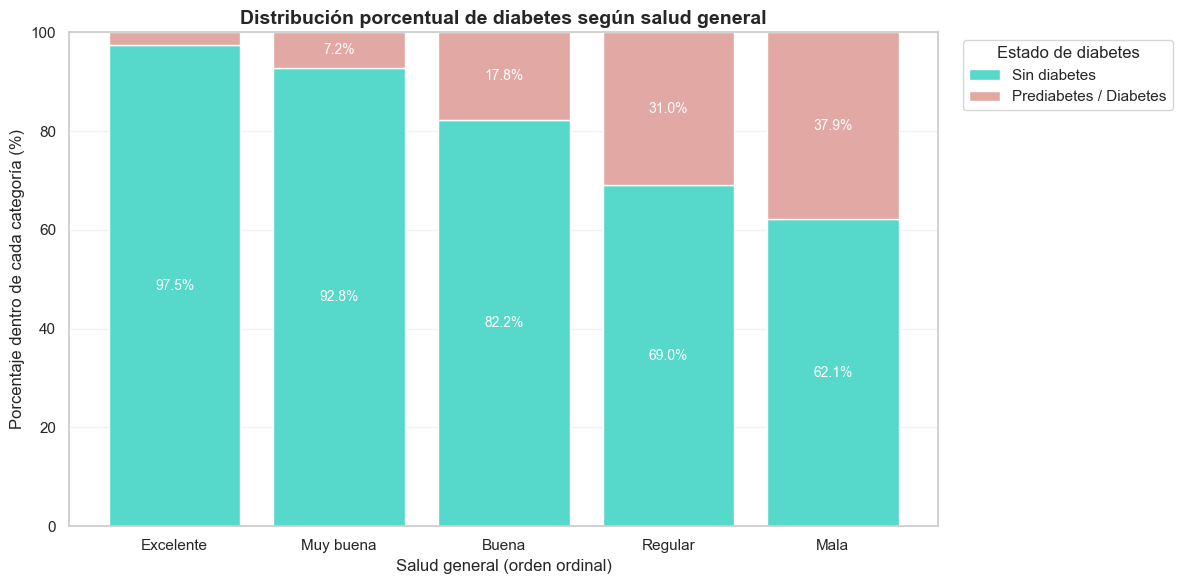

: 

In [ ]:


# Orden correcto
orden_gen = ["Excelente", "Muy buena", "Buena", "Regular", "Mala"]

map_gen = {1:"Excelente", 2:"Muy buena", 3:"Buena", 4:"Regular", 5:"Mala"}

gen = df_viz["GenHlth"].copy()

# Si viene numérica, convertir a etiquetas
gen_num = pd.to_numeric(gen, errors="coerce")
if gen_num.notna().any():
    gen = gen_num.map(map_gen).fillna(gen)


tabla_pct = pd.crosstab(
    gen,
    df_viz["Diabetes_binary"],
    normalize="index"
) * 100

tabla_pct = tabla_pct.reindex(orden_gen)

cols_order = [c for c in ["Sin diabetes", "Prediabetes / Diabetes"] if c in tabla_pct.columns]
if len(cols_order) == 0:
    cols_order = tabla_pct.columns.tolist()

tabla_pct = tabla_pct[cols_order]

# ====== Gráfico ======
fig, ax = plt.subplots(figsize=(12, 6))

bottom = np.zeros(len(tabla_pct))
x = np.arange(len(tabla_pct.index))

coral = "#E2A8A4"
aqua = "#56D8CB"

colors = {
    "Sin diabetes": aqua,
    "Prediabetes / Diabetes": coral
}

for col in tabla_pct.columns:
    bars = ax.bar(
        tabla_pct.index,
        tabla_pct[col],
        bottom=bottom,
        label=col,
        color=colors.get(col, "#999999")  # por si el nombre cambia
    )

    # Etiquetas
    for i, b in enumerate(bars):
        val = tabla_pct[col].iloc[i]
        if val >= 3:
            ax.text(
                b.get_x() + b.get_width()/2,
                bottom[i] + val/2,
                f"{val:.1f}%",
                ha="center",
                va="center",
                fontsize=10,
                color="white"  # se ve mejor sobre coral
            )
    bottom += tabla_pct[col].values

ax.set_title("Distribución porcentual de diabetes según salud general",
             fontsize=14, fontweight="bold")

ax.set_ylabel("Porcentaje dentro de cada categoría (%)")
ax.set_xlabel("Salud general (orden ordinal)")
ax.set_ylim(0, 100)

ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

ax.legend(title="Estado de diabetes", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

#### **11.2.2 Objetivo vs Age**

In [ ]:


# 1) Mapeo oficial (código -> descripción)
age_labels = {
    1: "18–24", 2: "25–29", 3: "30–34", 4: "35–39",
    5: "40–44", 6: "45–49", 7: "50–54", 8: "55–59",
    9: "60–64", 10: "65–69", 11: "70–74", 12: "75–79", 13: "80+"
}

# 2) Normalizar Age a código 1..13 en una columna auxiliar
#    - si ya viene numérica 1..13: se queda igual
#    - si viene como texto ("18-24", "18–24", "80+"): se convierte usando mapeo inverso
age_inverse = {v.replace("–", "-"): k for k, v in age_labels.items()}
age_inverse.update({v: k for k, v in age_labels.items()})  # por si ya trae “–”

# Crear Age_code robusto
if pd.api.types.is_numeric_dtype(df_viz["Age"]):
    df_viz["Age_code"] = df_viz["Age"].astype(int)
else:
    df_viz["Age_code"] = (
        df_viz["Age"]
        .astype(str)
        .str.strip()
        .str.replace("–", "-", regex=False)   # normaliza guion
        .map(age_inverse)
    )

# (Opcional) si quieres ver si hay valores sin mapear:
# print("No mapeados:", df_viz["Age_code"].isna().sum())

# 3) Tabla absoluta (por código)
tabla_abs = pd.crosstab(df_viz["Age_code"], df_viz["Diabetes_binary"]).sort_index()

# 4) Porcentajes por columna (distribución dentro de cada grupo)
tabla_pct = pd.crosstab(df_viz["Age_code"], df_viz["Diabetes_binary"], normalize="columns") * 100
tabla_pct = tabla_pct.reindex(tabla_abs.index)

# 5) Totales
total_abs = tabla_abs.sum(axis=1)
total_pct = (total_abs / total_abs.sum()) * 100

# 6) Armar salida final
col_no = "Sin diabetes"
col_si = "Prediabetes / Diabetes"

salida = pd.DataFrame({
    "Código": tabla_abs.index.astype(int),
    "Descripción": tabla_abs.index.astype(int).map(age_labels),

    "Sin diabetes (N)": tabla_abs.get(col_no, 0).values,
    "Sin diabetes (%)": tabla_pct.get(col_no, 0).round(2).values,

    "Prediabetes/Diabetes (N)": tabla_abs.get(col_si, 0).values,
    "Prediabetes/Diabetes (%)": tabla_pct.get(col_si, 0).round(2).values,

    "Total (N)": total_abs.values,
    "Total (%)": total_pct.round(2).values
}).reset_index(drop=True)

# 7) Mostrar sin el index de la izquierda (visual)
display(salida.style.hide(axis="index"))

Código,Descripción,Sin diabetes (N),Sin diabetes (%),Prediabetes/Diabetes (N),Prediabetes/Diabetes (%),Total (N),Total (%)
1,18–24,5622,2.570000,78,0.220000,5700,2.250000
2,25–29,7458,3.420000,140,0.400000,7598,3.000000
3,30–34,10809,4.950000,314,0.890000,11123,4.380000
4,35–39,13197,6.040000,626,1.770000,13823,5.450000
5,40–44,15106,6.920000,1051,2.970000,16157,6.370000
6,45–49,18077,8.280000,1742,4.930000,19819,7.810000
7,50–54,23226,10.640000,3088,8.740000,26314,10.370000
8,55–59,26569,12.170000,4263,12.060000,30832,12.150000
9,60–64,27511,12.600000,5733,16.220000,33244,13.100000
10,65–69,25636,11.740000,6558,18.550000,32194,12.690000


: 

In [ ]:

tabla_chi = pd.crosstab(df_viz["Age_code"], df_viz["Diabetes_binary"]).sort_index()

chi2, p, dof, expected = chi2_contingency(tabla_chi)

print("Chi-cuadrado:", round(chi2, 2))
print("Grados de libertad:", dof)
print("p-valor:", p)

# Tamaño del efecto: Cramér's V
n = tabla_chi.to_numpy().sum()
k = min(tabla_chi.shape) - 1  # min(r-1, c-1) para Cramér
cramers_v = np.sqrt(chi2 / (n * k)) if k > 0 else np.nan

print("Cramér's V:", round(cramers_v, 3))

Chi-cuadrado: 8795.05
Grados de libertad: 12
p-valor: 0.0
Cramér's V: 0.186


: 

En relación con la variable grupo de ``edad``, la distribución descriptiva evidencia un incremento progresivo en la proporción de individuos con prediabetes/diabetes a medida que aumenta la edad. Mientras que en los grupos más jóvenes (18–24 y 25–29) la frecuencia de casos es considerablemente baja, a partir de los 45 años se observa un aumento sostenido, alcanzando sus valores más elevados entre los 60 y 74 años, donde la proporción de individuos con condición diabética supera ampliamente la observada en edades tempranas. 

La prueba de independencia Chi-cuadrado confirmó que esta asociación es estadísticamente significativa ``(χ²=8795.05; gl=12; p<0.001)``. Asimismo, el tamaño del efecto medido mediante Cramér’s V ``(V=0.186)`` indica una asociación de magnitud pequeña a moderada, lo que sugiere que, aunque la edad no determina por sí sola el estado diabético, sí constituye un factor estructural relevante en su distribución poblacional.
 
Estos resultados son coherentes con la evidencia epidemiológica que identifica el envejecimiento como un determinante importante del riesgo de diabetes tipo 2.

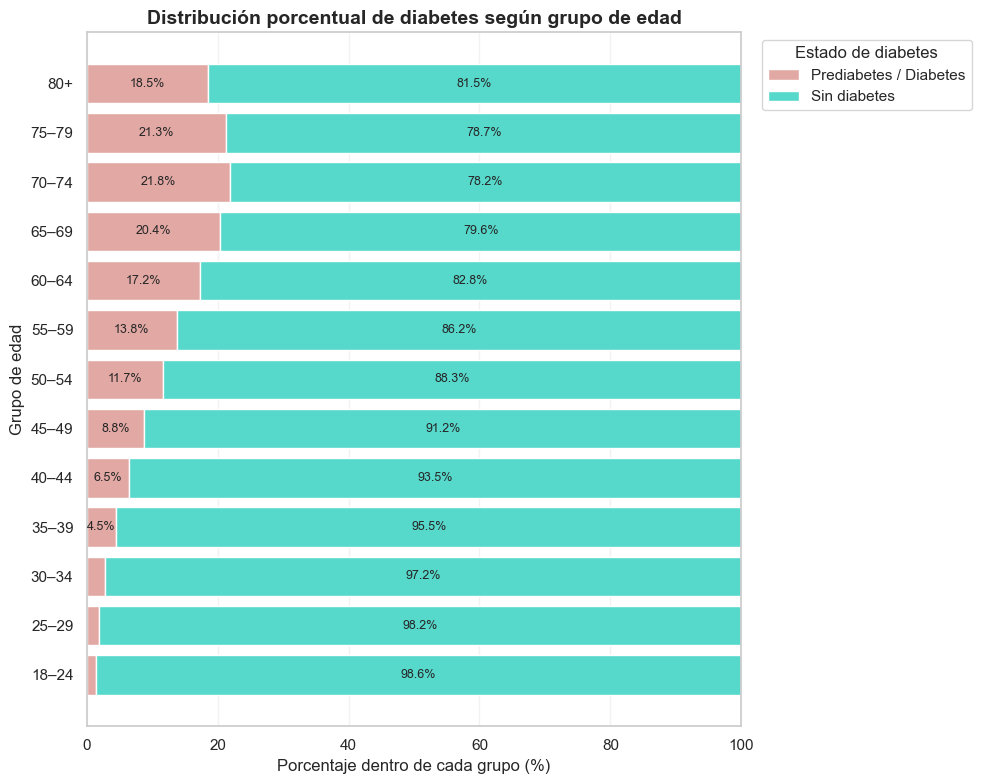

: 

In [ ]:

# Mapeo códigos -> etiqueta
age_labels = {
    1: "18–24", 2: "25–29", 3: "30–34", 4: "35–39",
    5: "40–44", 6: "45–49", 7: "50–54", 8: "55–59",
    9: "60–64", 10: "65–69", 11: "70–74",
    12: "75–79", 13: "80+"
}

# Tabla porcentual por edad (cada fila suma 100%)
tabla_pct = pd.crosstab(
    df_viz["Age_code"],
    df_viz["Diabetes_binary"],
    normalize="index"
) * 100

tabla_pct = tabla_pct.sort_index()

# Convertir índice a etiquetas
tabla_pct.index = tabla_pct.index.map(age_labels)

# ===== Gráfico horizontal =====
fig, ax = plt.subplots(figsize=(10, 8))

left = np.zeros(len(tabla_pct))

coral = "#E2A8A4"
aqua = "#56D8CB"

colors = {
    "Sin diabetes": aqua,
    "Prediabetes / Diabetes": coral
}

for col in tabla_pct.columns:
    bars = ax.barh(
        tabla_pct.index,
        tabla_pct[col],
        left=left,
        label=col,
        color=colors.get(col, "#999999")
    )
    
    # Etiquetas porcentuales dentro de cada segmento
    for i, val in enumerate(tabla_pct[col]):
        if val > 3:  # evita etiquetas muy pequeñas
            ax.text(
                left[i] + val / 2,
                i,
                f"{val:.1f}%",
                va="center",
                ha="center",
                fontsize=9
            )
    
    left += tabla_pct[col].values

ax.set_title("Distribución porcentual de diabetes según grupo de edad",
             fontsize=14, fontweight="bold")

ax.set_xlabel("Porcentaje dentro de cada grupo (%)")
ax.set_ylabel("Grupo de edad")
ax.set_xlim(0, 100)

ax.legend(title="Estado de diabetes", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

#### **11.2.3 Objetivo vs Education**

In [ ]:

# 1) Asegurar orden correcto (según TU mapping)
education_order = [
    "Nunca asistió",
    "Primaria incompleta",
    "Secundaria incompleta",
    "Secundaria completa / GED",
    "Universidad incompleta",
    "Universidad completa"
]

# 2) Tomar la variable ya categórica (texto)
edu = df_viz["Education"].astype("category")

# (opcional pero recomendado) forzar el orden
edu = edu.cat.reorder_categories(education_order, ordered=True)

# 3) Tabla absoluta (con labels)
tabla_abs = pd.crosstab(edu, df_viz["Diabetes_binary"]).reindex(education_order)

# 4) Totales
total_general = tabla_abs.sum(axis=1)
n_total = total_general.sum()

# 5) % por grupo (dentro de cada columna)
tabla_pct_col = tabla_abs.div(tabla_abs.sum(axis=0), axis=1) * 100

# 6) % del total (muestra completa)
pct_total = (total_general / n_total) * 100

# 7) Nombres de columnas (los tuyos)
no_col = "Sin diabetes"
si_col = "Prediabetes / Diabetes"

# 8) Código 1–6 según el orden
codigos = list(range(1, len(education_order) + 1))

# 9) Tabla final
tabla_edu_final = pd.DataFrame({
    "Código": codigos,
    "Descripción": education_order,
    "Sin diabetes (N)": tabla_abs[no_col].values,
    "Sin diabetes (%)": tabla_pct_col[no_col].round(2).values,
    "Prediabetes/Diabetes (N)": tabla_abs[si_col].values,
    "Prediabetes/Diabetes (%)": tabla_pct_col[si_col].round(2).values,
    "Total (N)": total_general.values,
    "Total (%)": pct_total.round(2).values
})

display(tabla_edu_final.style.hide(axis="index"))

Código,Descripción,Sin diabetes (N),Sin diabetes (%),Prediabetes/Diabetes (N),Prediabetes/Diabetes (%),Total (N),Total (%)
1,Nunca asistió,127,0.060000,47,0.130000,174,0.070000
2,Primaria incompleta,2860,1.310000,1183,3.350000,4043,1.590000
3,Secundaria incompleta,7182,3.290000,2296,6.500000,9478,3.740000
4,Secundaria completa / GED,51684,23.670000,11066,31.310000,62750,24.740000
5,Universidad incompleta,59556,27.280000,10354,29.290000,69910,27.560000
6,Universidad completa,96925,44.390000,10400,29.420000,107325,42.310000


: 

In [ ]:


# Tabla de contingencia (N absolutos)
tabla_chi = pd.crosstab(df_viz["Education"], df_viz["Diabetes_binary"])

# Chi-cuadrado
chi2, p, dof, expected = chi2_contingency(tabla_chi)

print("Chi-cuadrado:", round(chi2, 2))
print("Grados de libertad:", dof)
print("p-valor:", p)

n = tabla_chi.sum().sum()

cramers_v = np.sqrt(chi2 / (n * (min(tabla_chi.shape) - 1)))

print("Cramér's V:", round(cramers_v, 3))

Chi-cuadrado: 4027.11
Grados de libertad: 5
p-valor: 0.0
Cramér's V: 0.126


: 

En cuanto al ``nivel educativo``, la distribución descriptiva muestra un gradiente claro en la proporción de prediabetes/diabetes según el nivel de formación. Aunque la mayoría de los casos absolutos se concentran en los niveles de secundaria completa/GED, universidad incompleta y universidad completa, lo cual es consistente con la mayor representación poblacional de estos grupos, al observar las proporciones se evidencia que los niveles educativos más bajos presentan una mayor carga relativa de enfermedad en comparación con los niveles superiores. 

La prueba de independencia Chi-cuadrado confirmó que existe una asociación estadísticamente significativa entre nivel educativo y estado diabético ``(χ² = 4027.11; gl = 5; p < 0.001)``. No obstante, el tamaño del efecto medido mediante Cramér’s V ``(V = 0.126)`` indica una asociación de magnitud pequeña, lo que sugiere que, si bien la educación está relacionada con la distribución de la diabetes en la población, su influencia es moderada y probablemente interactúa con otros determinantes socioeconómicos y conductuales. Estos resultados son coherentes con la evidencia que señala la educación como un determinante social de la salud, asociado indirectamente a mejores ingresos, acceso a servicios sanitarios y estilos de vida más saludables.

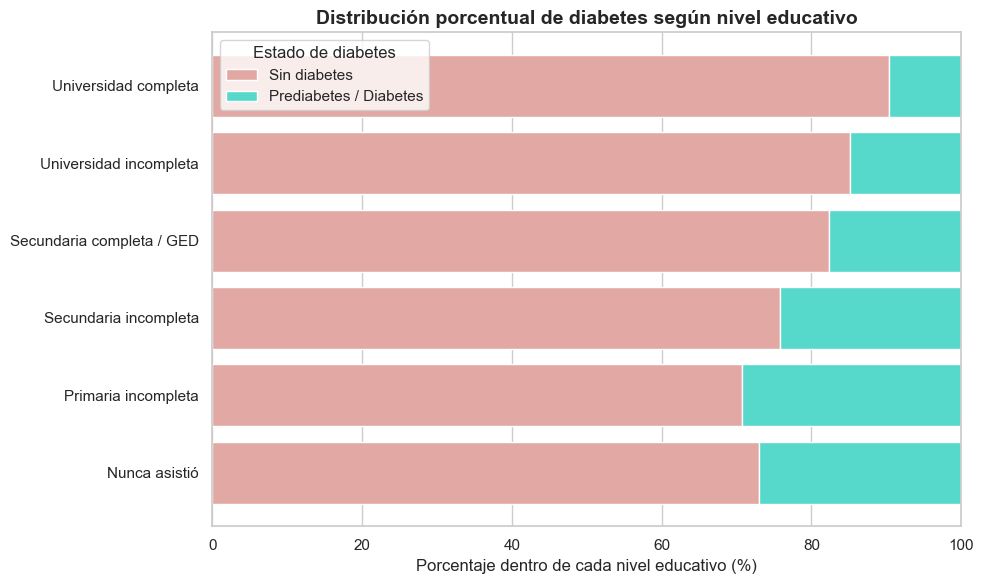

: 

In [ ]:

education_order = [
    "Nunca asistió",
    "Primaria incompleta",
    "Secundaria incompleta",
    "Secundaria completa / GED",
    "Universidad incompleta",
    "Universidad completa"
]

tabla_pct = pd.crosstab(
    df_viz["Education"],
    df_viz["Diabetes_binary"],
    normalize="index"
) * 100

tabla_pct = tabla_pct.reindex(education_order)

no_col = "Sin diabetes"
si_col = "Prediabetes / Diabetes"

sin = tabla_pct[no_col]
con = tabla_pct[si_col]

plt.figure(figsize=(10,6))

plt.barh(education_order, sin, label="Sin diabetes", color= "#E2A8A4")
plt.barh(education_order, con, left=sin, label="Prediabetes / Diabetes", color= "#56D8CB")

plt.title("Distribución porcentual de diabetes según nivel educativo",
          fontsize=14, fontweight="bold")

plt.xlabel("Porcentaje dentro de cada nivel educativo (%)")
plt.xlim(0,100)

plt.legend(title="Estado de diabetes")
plt.tight_layout()
plt.show()

#### **11.2.4 Objetivo vs Income**

In [ ]:

income_order = [
    "< $10,000",
    "$10,000–15,000",
    "$15,000–20,000",
    "$20,000–25,000",
    "$25,000–35,000",
    "$35,000–50,000",
    "$50,000–75,000",
    "$75,000+"
]

# Variable ya categórica
inc = df_viz["Income"].astype("category")

# Forzar orden correcto
inc = inc.cat.reorder_categories(income_order, ordered=True)

# Tabla absoluta
tabla_abs = pd.crosstab(inc, df_viz["Diabetes_binary"]).reindex(income_order)

# Totales
total_general = tabla_abs.sum(axis=1)
n_total = total_general.sum()

# % dentro de cada grupo (columna)
tabla_pct_col = tabla_abs.div(tabla_abs.sum(axis=0), axis=1) * 100

# % del total general
pct_total = (total_general / n_total) * 100

# Nombres de columnas
no_col = "Sin diabetes"
si_col = "Prediabetes / Diabetes"

# Códigos 1–8
codigos = list(range(1, len(income_order) + 1))

# Construir tabla final
tabla_income_final = pd.DataFrame({
    "Código": codigos,
    "Descripción": income_order,
    "Sin diabetes (N)": tabla_abs[no_col].values,
    "Sin diabetes (%)": tabla_pct_col[no_col].round(2).values,
    "Prediabetes/Diabetes (N)": tabla_abs[si_col].values,
    "Prediabetes/Diabetes (%)": tabla_pct_col[si_col].round(2).values,
    "Total (N)": total_general.values,
    "Total (%)": pct_total.round(2).values
})

display(tabla_income_final.style.hide(axis="index"))

Código,Descripción,Sin diabetes (N),Sin diabetes (%),Prediabetes/Diabetes (N),Prediabetes/Diabetes (%),Total (N),Total (%)
1,"< $10,000",7428,3.400000,2383,6.740000,9811,3.870000
2,"$10,000–15,000",8697,3.980000,3086,8.730000,11783,4.640000
3,"$15,000–20,000",12426,5.690000,3568,10.090000,15994,6.300000
4,"$20,000–25,000",16081,7.370000,4054,11.470000,20135,7.940000
5,"$25,000–35,000",21379,9.790000,4504,12.740000,25883,10.200000
6,"$35,000–50,000",31179,14.280000,5291,14.970000,36470,14.380000
7,"$50,000–75,000",37954,17.380000,5265,14.900000,43219,17.040000
8,"$75,000+",83190,38.100000,7195,20.360000,90385,35.630000


: 

In [ ]:

# Tabla de contingencia (N absolutos)
tabla_chi_income = pd.crosstab(
    df_viz["Income"],
    df_viz["Diabetes_binary"]
)

# Chi-cuadrado
chi2, p, dof, expected = chi2_contingency(tabla_chi_income)

print("Chi-cuadrado:", round(chi2, 2))
print("Grados de libertad:", dof)
print("p-valor:", p)

n = tabla_chi_income.sum().sum()

cramers_v = np.sqrt(chi2 / (n * (min(tabla_chi_income.shape) - 1)))

print("Cramér's V:", round(cramers_v, 3))

Chi-cuadrado: 7003.72
Grados de libertad: 7
p-valor: 0.0
Cramér's V: 0.166


: 

En relación con el ``nivel de ingreso``, la distribución descriptiva evidencia un patrón consistente con un gradiente socioeconómico en la prevalencia de prediabetes/diabetes. Aunque los mayores números absolutos de casos se concentran en los grupos de ingresos medios y altos, debido a su mayor representación dentro de la muestra, al analizar las proporciones se observa que los niveles de ingreso más bajos presentan una mayor carga relativa de enfermedad en comparación con los niveles más altos. Esta tendencia sugiere que a medida que aumenta el ingreso, la proporción de individuos con condición diabética tiende a disminuir. 

La prueba de independencia Chi-cuadrado confirmó que existe una asociación estadísticamente significativa entre nivel de ingreso y estado diabético ``(χ² = 7003.72; gl = 7; p < 0.001)``. Asimismo, el tamaño del efecto medido mediante Cramér’s V ``(V = 0.166)`` indica una asociación de magnitud pequeña a moderada, lo que sugiere que el ingreso constituye un determinante relevante, aunque no exclusivo, en la distribución poblacional de la diabetes. Estos resultados son coherentes con la literatura que identifica el nivel socioeconómico como un determinante estructural de la salud, vinculado a acceso a servicios sanitarios, calidad de la alimentación y oportunidades de actividad física.

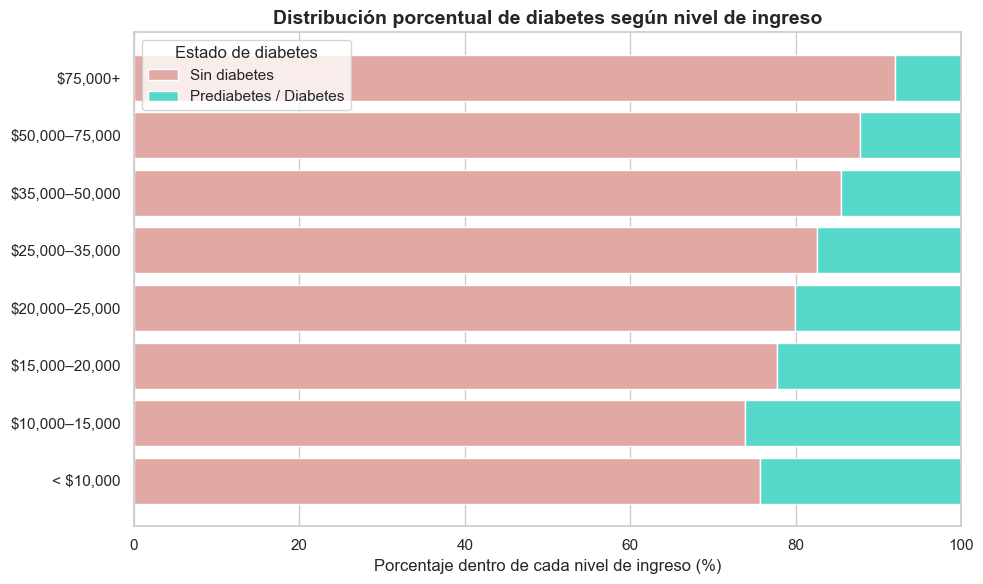

: 

In [ ]:

income_order = [
    "< $10,000",
    "$10,000–15,000",
    "$15,000–20,000",
    "$20,000–25,000",
    "$25,000–35,000",
    "$35,000–50,000",
    "$50,000–75,000",
    "$75,000+"
]

# Tabla porcentual dentro de cada nivel de ingreso
tabla_pct = pd.crosstab(
    df_viz["Income"],
    df_viz["Diabetes_binary"],
    normalize="index"
) * 100

tabla_pct = tabla_pct.reindex(income_order)

no_col = "Sin diabetes"
si_col = "Prediabetes / Diabetes"

sin = tabla_pct[no_col]
con = tabla_pct[si_col]

plt.figure(figsize=(10,6))

plt.barh(income_order, sin, label="Sin diabetes", color= "#E2A8A4")
plt.barh(income_order, con, left=sin, label="Prediabetes / Diabetes", color= "#56D8CB")

plt.title("Distribución porcentual de diabetes según nivel de ingreso",
          fontsize=14, fontweight="bold")

plt.xlabel("Porcentaje dentro de cada nivel de ingreso (%)")
plt.xlim(0, 100)

plt.legend(title="Estado de diabetes")
plt.tight_layout()
plt.show()

### **11.3 Variable objetivo vs variables numéricas**

Con el fin de evaluar la relación entre el estado de prediabetes/diabetes y las variables numéricas del estudio (BMI, MentHlth y PhysHlth), se realizó un análisis bivariado orientado a comparar la distribución y las medias de dichas variables entre los dos grupos definidos por la variable objetivo: Prediabetes/Diabetes y Sin diabetes.

Dado que la variable dependiente es categórica binaria y las variables explicativas son continuas, el análisis se estructuró a partir de la comparación de medias entre grupos independientes. Para ello, se utilizó la prueba t de Welch, la cual no asume igualdad de varianzas entre grupos y resulta apropiada en contextos donde los tamaños muestrales son desiguales.

Si bien algunas de las variables presentan asimetría en su distribución, el tamaño muestral elevado garantiza la robustez de la prueba t por efecto del Teorema del Límite Central, el cual establece que la distribución de la media muestral tiende a aproximarse a la normalidad cuando el número de observaciones es grande.

Adicionalmente, para complementar la significancia estadística, se calculó el tamaño del efecto mediante el estadístico Cohen’s d, con el objetivo de evaluar la magnitud práctica de las diferencias observadas entre grupos. Esta medida permite distinguir entre diferencias estadísticamente significativas y diferencias clínicamente relevantes.

Finalmente, el análisis se apoyó en representaciones gráficas (boxplots y curvas de densidad) que permiten visualizar la dispersión, la presencia de valores atípicos y la forma de la distribución en cada grupo, proporcionando una comprensión más completa del comportamiento de las variables numéricas según el estado diabético.m

#### **11.3.1 Objetivo vs BMI**

In [ ]:
def tabla_descriptiva(var):

    resumen = (
        df_viz
        .groupby("Diabetes_binary")[var]
        .agg([
            "count",
            "mean",
            "median",
            "std",
            "min",
            lambda x: x.quantile(0.25),
            lambda x: x.quantile(0.75),
            "max"
        ])
    )

    resumen.columns = [
        "N",
        "Media",
        "Mediana",
        "Desv. Estándar",
        "Mínimo",
        "Q1 (25%)",
        "Q3 (75%)",
        "Máximo"
    ]

    return resumen.round(2)

tabla_descriptiva("BMI")

,N,Media,Mediana,Desv. Estándar,Mínimo,Q1 (25%),Q3 (75%),Máximo
Diabetes_binary,,,,,,,,
Prediabetes / Diabetes,35346,31.94,31.0,7.36,13.0,27.0,35.0,98.0
Sin diabetes,218334,27.81,27.0,6.29,12.0,24.0,31.0,98.0


: 

In [ ]:
import scipy.stats as stats
import numpy as np

grupo1 = df_viz[df_viz["Diabetes_binary"]=="Prediabetes / Diabetes"]["BMI"]
grupo0 = df_viz[df_viz["Diabetes_binary"]=="Sin diabetes"]["BMI"]

t_stat, p_val = stats.ttest_ind(grupo1, grupo0, equal_var=False)

pooled_sd = np.sqrt((grupo1.std()**2 + grupo0.std()**2)/2)
cohens_d = (grupo1.mean() - grupo0.mean())/pooled_sd

print("t:", round(t_stat,2))
print("p-valor:", p_val)
print("Cohen's d:", round(cohens_d,2))

t: 99.92
p-valor: 0.0
Cohen's d: 0.6


: 

El índice de masa corporal `(BMI)` es mayor en el grupo con Prediabetes / Diabetes (Media = 31.94; Mediana = 31) en comparación con el grupo Sin diabetes (Media = 27.81; Mediana = 27). Además, los cuartiles muestran que toda la distribución del grupo diabético está desplazada hacia valores más altos.

La prueba t de Welch arroja un estadístico `t = 99.92` con p < 0.001, lo que indica que la diferencia de medias es estadísticamente significativa.

El tamaño del efecto ``(Cohen’s d = 0.60)`` sugiere una diferencia de magnitud moderada, lo que implica que la asociación no solo es significativa por el gran tamaño muestral, sino también relevante desde el punto de vista práctico.

En consecuencia, el BMI presenta una diferencia clara y sustantiva entre ambos grupos, consolidándose como una variable fuertemente asociada al estado diabético.

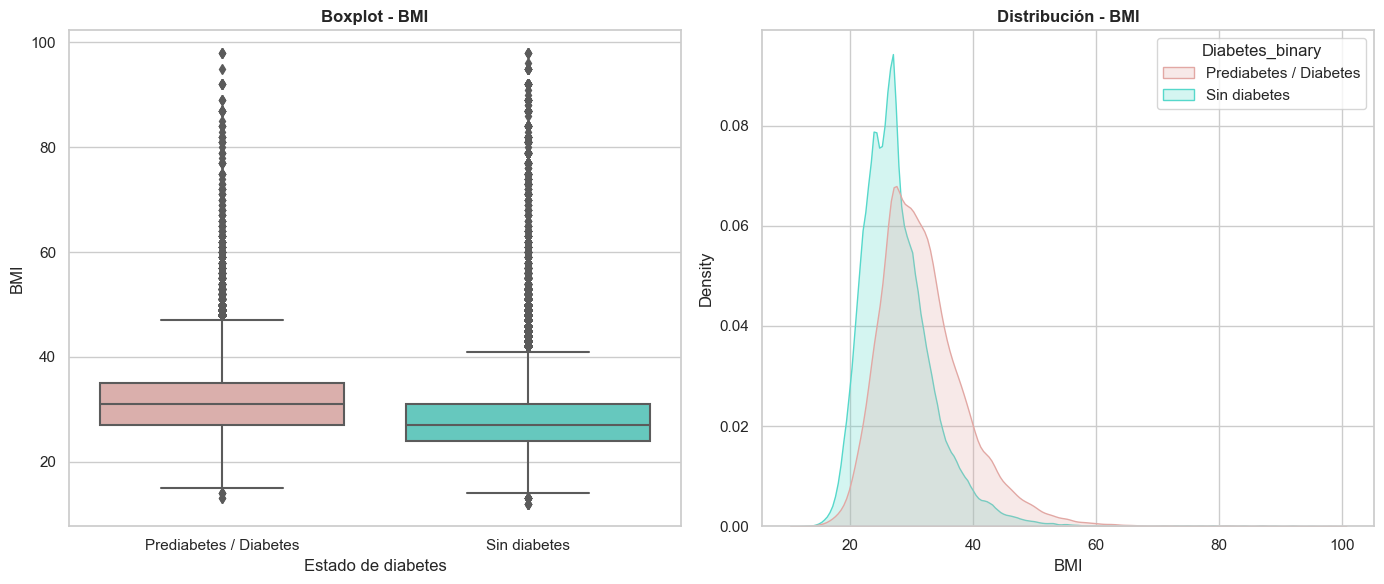

: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# -------- Boxplot --------
sns.boxplot(
    data=df_viz,
    x="Diabetes_binary",
    y="BMI",
    ax=axes[0],
    palette= colors
    
)

axes[0].set_title("Boxplot - BMI", fontweight="bold")
axes[0].set_xlabel("Estado de diabetes")
axes[0].set_ylabel("BMI")

# -------- Distribución --------
sns.kdeplot(
    data=df_viz,
    x="BMI",
    hue="Diabetes_binary",
    fill=True,
    common_norm=False,
    ax=axes[1],
    palette= colors
)

axes[1].set_title("Distribución - BMI", fontweight="bold")
axes[1].set_xlabel("BMI")

plt.tight_layout()
plt.show()

El boxplot muestra que el grupo con Prediabetes / Diabetes presenta una mediana de BMI claramente superior al grupo Sin diabetes. Además: el rango intercuartílico (Q1–Q3) está desplazado hacia valores más altos; se observa también mayor concentración de valores elevados. Ambos grupos presentan outliers altos, pero en el grupo diabético la distribución central ya se encuentra en un rango de sobrepeso/obesidad. Esto indica una diferencia estructural en la distribución, no solo en valores extremos.

La curva de densidad confirma visualmente el desplazamiento hacia la derecha del grupo con Prediabetes / Diabetes. La distribución azul (diabéticos) está centrada en valores más altos. Existe solapamiento entre grupos, pero el pico principal del grupo diabético se ubica aproximadamente 3–4 puntos de BMI por encima. De igual forma, se observa una cola derecha más pronunciada en el grupo diabético, indicando mayor proporción de IMC elevados.

Ambos gráficos evidencian que el BMI no solo difiere en promedio, sino que toda la distribución del grupo con prediabetes/diabetes está desplazada hacia valores mayores. Esto refuerza la evidencia estadística previa (t-test y Cohen’s d) y confirma que el BMI es una variable fuertemente asociada al estado diabético tanto en términos estadísticos como clínicos.

#### **11.3.2 Objetivo vs MentHlth**

In [ ]:
tabla_descriptiva("MentHlth")

,N,Media,Mediana,Desv. Estándar,Mínimo,Q1 (25%),Q3 (75%),Máximo
Diabetes_binary,,,,,,,,
Prediabetes / Diabetes,35346,4.46,0.0,8.95,0.0,0.0,3.0,30.0
Sin diabetes,218334,2.98,0.0,7.11,0.0,0.0,2.0,30.0


: 

In [ ]:
grupo1 = df_viz[df_viz["Diabetes_binary"]=="Prediabetes / Diabetes"]["MentHlth"]
grupo0 = df_viz[df_viz["Diabetes_binary"]=="Sin diabetes"]["MentHlth"]

t_stat, p_val = stats.ttest_ind(grupo1, grupo0, equal_var=False)

pooled_sd = np.sqrt((grupo1.std()**2 + grupo0.std()**2)/2)
cohens_d = (grupo1.mean() - grupo0.mean())/pooled_sd

print("t:", round(t_stat,2))
print("p-valor:", p_val)
print("Cohen's d:", round(cohens_d,2))

t: 29.69
p-valor: 7.929124395108997e-192
Cohen's d: 0.18


: 

El número promedio de días con ``mala salud mental`` en los últimos 30 días es mayor en el grupo con Prediabetes / Diabetes (Media = 4.46) en comparación con el grupo Sin diabetes (Media = 2.98). Sin embargo, la mediana en ambos grupos es 0 días, lo que indica que más de la mitad de los individuos en cada grupo no reportó días de mala salud mental, evidenciando una distribución fuertemente asimétrica hacia la derecha.

Desde el punto de vista estadístico, la prueba t arroja ``t = 29.69`` con p < 0.001, lo que indica que la diferencia de medias es estadísticamente significativa. No obstante, el tamaño del efecto es pequeño ``(Cohen’s d = 0.18)``, lo que sugiere que, aunque la diferencia existe y es estadísticamente robusta (probablemente influenciada por el gran tamaño muestral), la magnitud práctica de la diferencia entre grupos es baja.

En conclusión, existe una asociación estadísticamente significativa entre salud mental y estado diabético, pero su impacto en términos de magnitud es limitado.

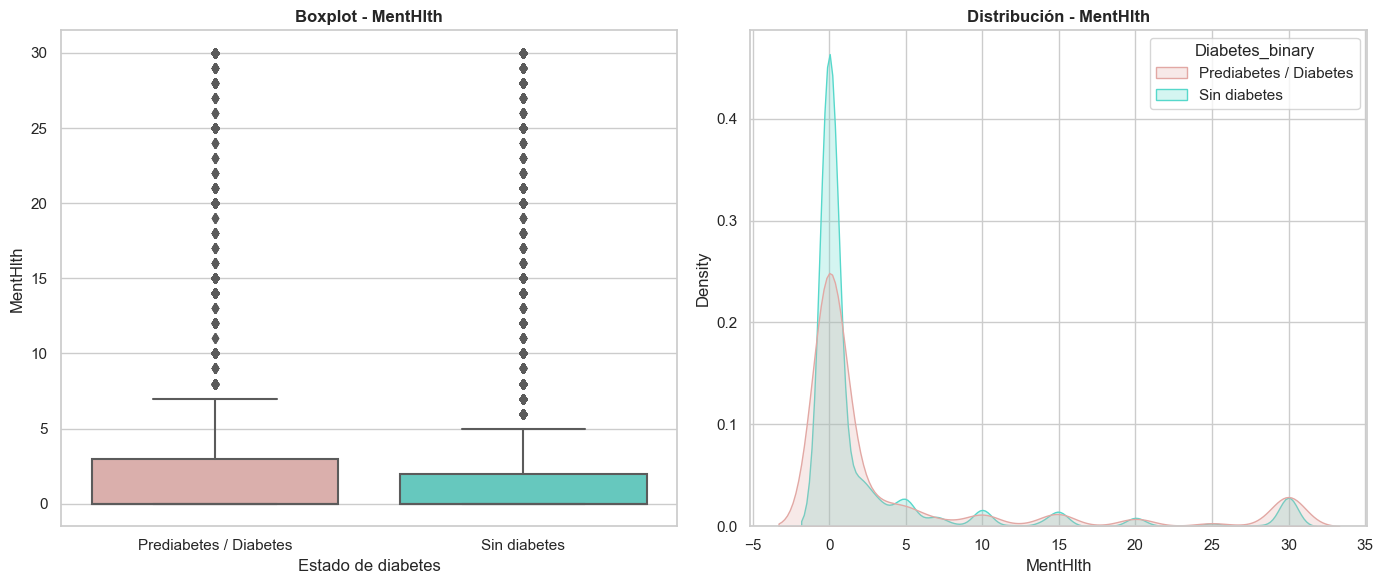

: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# -------- Boxplot --------
sns.boxplot(
    data=df_viz,
    x="Diabetes_binary",
    y="MentHlth",
    ax=axes[0],
    palette= colors
)

axes[0].set_title("Boxplot - MentHlth", fontweight="bold")
axes[0].set_xlabel("Estado de diabetes")
axes[0].set_ylabel("MentHlth")

# -------- Distribución --------
sns.kdeplot(
    data=df_viz,
    x="MentHlth",
    hue="Diabetes_binary",
    fill=True,
    common_norm=False,
    ax=axes[1],
    palette= colors
)

axes[1].set_title("Distribución - MentHlth", fontweight="bold")
axes[1].set_xlabel("MentHlth")

plt.tight_layout()
plt.show()

Las gráficas muestran que la mayoría de las personas en ambos grupos reporta 0 días de mala salud mental, lo que explica que la mediana sea 0 y que la distribución esté fuertemente concentrada en ese valor. Sin embargo, el grupo con Prediabetes / Diabetes presenta una ligera mayor dispersión y una cola derecha más extendida, reflejando que una proporción mayor acumula más días con afectación mental.

El boxplot confirma que, aunque las diferencias centrales no son muy amplias, el grupo diabético tiene un rango intercuartílico ligeramente superior y mayor presencia de valores altos. La curva de densidad muestra un desplazamiento leve hacia la derecha en este grupo, pero con amplio solapamiento entre distribuciones.

En conjunto, visualmente se aprecia una diferencia existente pero pequeña en magnitud, coherente con el tamaño de efecto bajo observado en el análisis estadístico.m

#### **11.3.3 Objetivo vs PhysHlth**

In [ ]:
tabla_descriptiva("PhysHlth")

,N,Media,Mediana,Desv. Estándar,Mínimo,Q1 (25%),Q3 (75%),Máximo
Diabetes_binary,,,,,,,,
Prediabetes / Diabetes,35346,7.95,1.0,11.30,0.0,0.0,15.0,30.0
Sin diabetes,218334,3.64,0.0,8.06,0.0,0.0,2.0,30.0


: 

In [ ]:
grupo1 = df_viz[df_viz["Diabetes_binary"]=="Prediabetes / Diabetes"]["PhysHlth"]
grupo0 = df_viz[df_viz["Diabetes_binary"]=="Sin diabetes"]["PhysHlth"]

t_stat, p_val = stats.ttest_ind(grupo1, grupo0, equal_var=False)

pooled_sd = np.sqrt((grupo1.std()**2 + grupo0.std()**2)/2)
cohens_d = (grupo1.mean() - grupo0.mean())/pooled_sd

print("t:", round(t_stat,2))
print("p-valor:", p_val)
print("Cohen's d:", round(cohens_d,2))

t: 68.97
p-valor: 0.0
Cohen's d: 0.44


: 

El número promedio de días con ``mala salud física`` en los últimos 30 días es considerablemente mayor en el grupo con Prediabetes / Diabetes (Media = 7.95; Mediana = 1) frente al grupo Sin diabetes (Media = 3.64; Mediana = 0). Además, el tercer cuartil es mucho más alto en el grupo diabético (Q3 = 15 vs 2), lo que indica que una proporción importante reporta múltiples días con afectación física.

La prueba t de Welch arroja ``t = 68.97`` con p < 0.001, evidenciando una diferencia estadísticamente significativa entre grupos. El tamaño del efecto ``(Cohen’s d = 0.44)`` es moderado, lo que sugiere que la diferencia no solo es significativa por el gran tamaño muestral, sino también relevante en términos prácticos.

En conjunto, la mala salud física muestra una asociación clara y sustantiva con el estado diabético, con una magnitud mayor que la observada previamente para salud mental.

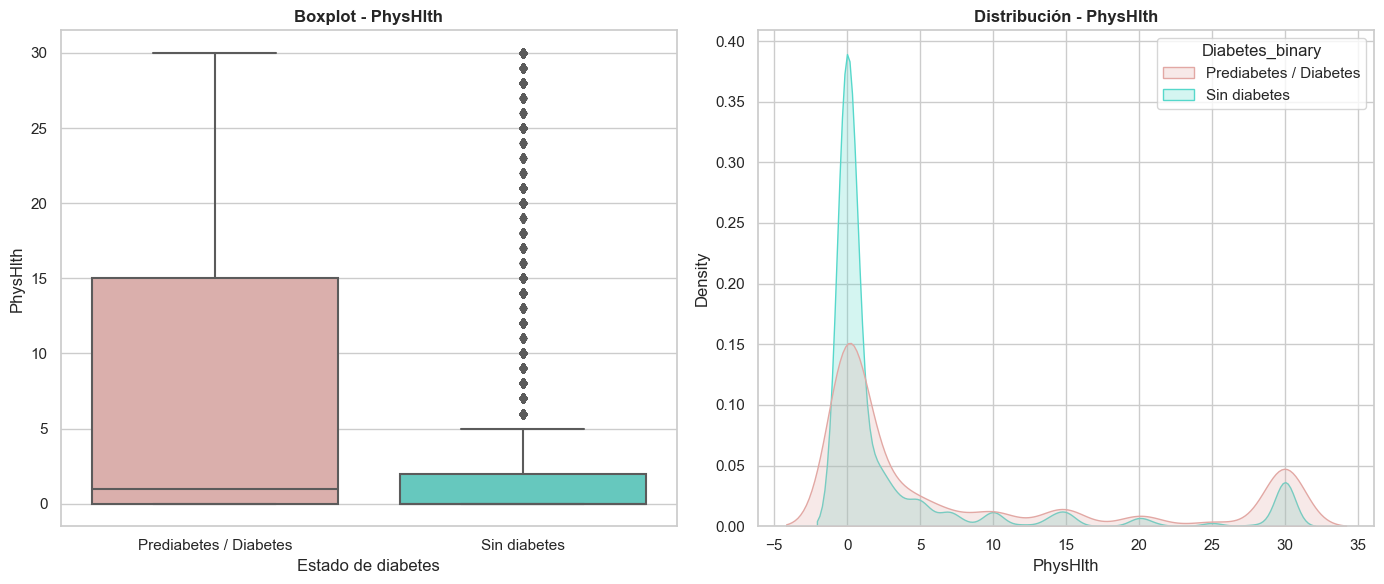

: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# -------- Boxplot --------
sns.boxplot(
    data=df_viz,
    x="Diabetes_binary",
    y="PhysHlth",
    ax=axes[0],
    palette= colors
)

axes[0].set_title("Boxplot - PhysHlth", fontweight="bold")
axes[0].set_xlabel("Estado de diabetes")
axes[0].set_ylabel("PhysHlth")

# -------- Distribución --------
sns.kdeplot(
    data=df_viz,
    x="PhysHlth",
    hue="Diabetes_binary",
    fill=True,
    common_norm=False,
    ax=axes[1],
    palette= colors
)

axes[1].set_title("Distribución - PhysHlth", fontweight="bold")
axes[1].set_xlabel("PhysHlth")

plt.tight_layout()
plt.show()

Las gráficas muestran una diferencia más marcada que en salud mental. Aunque en ambos grupos la mediana se mantiene cerca de 0 días, el boxplot evidencia que el grupo con Prediabetes / Diabetes tiene un rango intercuartílico mucho más amplio y valores centrales más elevados. El tercer cuartil alcanza 15 días en el grupo diabético frente a solo 2 días en el grupo sin diabetes, lo que indica que una proporción considerable reporta múltiples días con mala salud física.

La distribución confirma este patrón: la curva del grupo diabético está más extendida hacia la derecha y presenta una cola más pesada, reflejando mayor frecuencia de valores altos (incluyendo el límite de 30 días). Aunque existe solapamiento entre grupos, el desplazamiento es visualmente claro.

En conjunto, las gráficas refuerzan que la afectación física es sustancialmente mayor en personas con prediabetes/diabetes, coherente con el tamaño de efecto moderado observado en el análisis estadístico.

## **12. Análisis de correlación entre la variable objetivo y factores asociados**

In [216]:
df_corr = pd.DataFrame()

# Continuas
df_corr["BMI"] = df_viz["BMI"]
df_corr["MentHlth"] = df_viz["MentHlth"]
df_corr["PhysHlth"] = df_viz["PhysHlth"]

# Ordinales
df_corr["GenHlth"] = df_viz["GenHlth"].cat.codes + 1
df_corr["Education"] = df_viz["Education"].cat.codes + 1
df_corr["Income"] = df_viz["Income"].cat.codes + 1
df_corr["Age"] = df_viz["Age"].cat.codes + 1

df_corr = df_corr.dropna()

# Pearson
corr_matrix = df_corr.corr(method="pearson")

corr_matrix.round(2)

,BMI,MentHlth,PhysHlth,GenHlth,Education,Income,Age
BMI,1.00,0.09,0.12,0.24,-0.10,-0.10,-0.04
MentHlth,0.09,1.00,0.35,0.30,-0.10,-0.21,-0.09
PhysHlth,0.12,0.35,1.00,0.52,-0.16,-0.27,0.10
GenHlth,0.24,0.30,0.52,1.00,-0.28,-0.37,0.15
Education,-0.10,-0.10,-0.16,-0.28,1.00,0.45,-0.10
Income,-0.10,-0.21,-0.27,-0.37,0.45,1.00,-0.13
Age,-0.04,-0.09,0.10,0.15,-0.10,-0.13,1.00


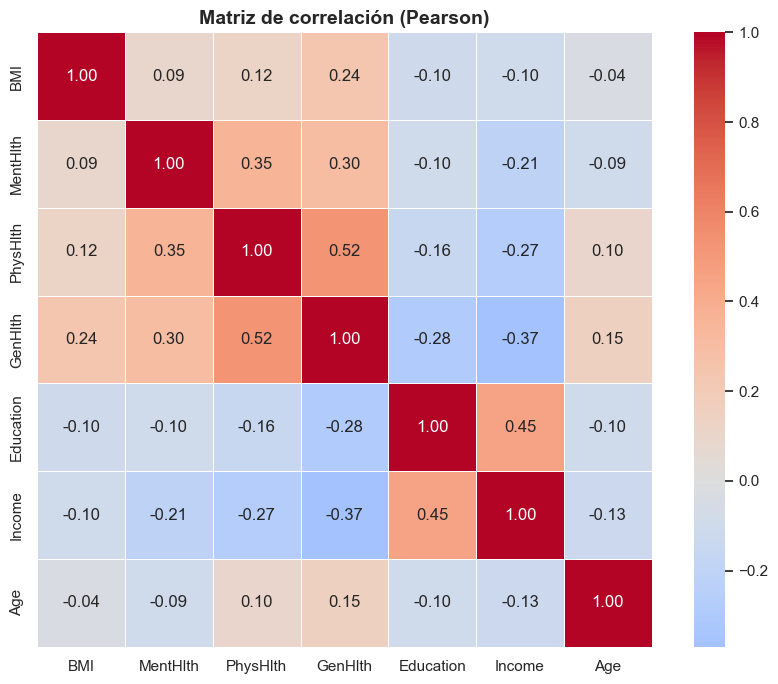

In [217]:
plt.figure(figsize=(9,7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Matriz de correlación (Pearson)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

La matriz de correlación de Pearson revela que las correlaciones entre las variables 
numéricas y ordinales del dataset son en general débiles a moderadas, sin evidencia 
de multicolinealidad problemática entre los predictores.

Las asociaciones más relevantes son:

- **PhysHlth y GenHlth (0.52):** es la correlación más fuerte del conjunto. Una peor 
salud física se asocia consistentemente con una peor percepción general de salud.

- **MentHlth y PhysHlth (0.35):** relación moderada entre días de mala salud mental 
y física, sugiriendo que ambas dimensiones tienden a deteriorarse de forma conjunta.

- **Education e Income (0.45):** a mayor nivel educativo, mayor nivel de ingresos, 
relación esperada y consistente con la literatura socioeconómica.

- **GenHlth e Income (-0.37) y GenHlth y Education (-0.28):** personas con menores 
ingresos y menor nivel educativo tienden a reportar peor estado de salud general.

- **BMI y GenHlth (0.24):** un mayor índice de masa corporal se asocia moderadamente 
con una peor percepción del estado de salud.

Solo PhysHlth y GenHlth superan el umbral de 0.5.

## **13. Modelo baseline/Prueba de viabilidad**


Mejores parámetros encontrados:
{'model__C': 10, 'model__class_weight': 'balanced'}

Mejor score promedio en validación cruzada:
0.443253659364507

Score F1 en test:
0.44136346855900566

Accuracy en test:
0.731571270892463

Classification report:
              precision    recall  f1-score   support

         0.0       0.95      0.73      0.82     43667
         1.0       0.31      0.76      0.44      7069

    accuracy                           0.73     50736
   macro avg       0.63      0.74      0.63     50736
weighted avg       0.86      0.73      0.77     50736



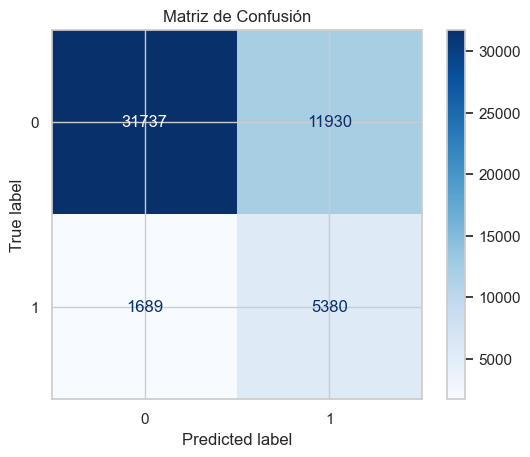

In [12]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    roc_auc_score,
    roc_curve
)
import matplotlib.pyplot as plt

# 1. Cargar dataset
ruta = r"C:\Users\MSI TRUE GAMING\Desktop\Semestre 2026\machine\machineentrega2\diabetes_binary_health_indicators_BRFSS2015.csv"
df = pd.read_csv(ruta)

# 2. Separar variables predictoras y objetivo
X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

# 3. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 4. Definir validación cruzada estratificada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 5. Crear pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=100000))
])

# 6. Definir hiperparámetros
param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__class_weight": [None, "balanced"]
}

# 7. GridSearch con F1
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=skf,
    scoring="f1",
    n_jobs=-1
)

# 8. Entrenar
grid_search.fit(X_train, y_train)

# 9. Mostrar mejores resultados
print("Mejores parámetros encontrados:")
print(grid_search.best_params_)

print("\nMejor score promedio en validación cruzada:")
print(grid_search.best_score_)

# 10. Evaluar en test
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("\nScore F1 en test:")
print(f1_score(y_test, y_pred))

print("\nAccuracy en test:")
print(accuracy_score(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred))

# 11. Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión")
plt.show()



Antes de implementar modelos más complejos, se entrenó una línea base utilizando LogisticRegression con el objetivo de evaluar si el dataset contenía suficiente información predictiva para justificar el uso de técnicas de Machine Learning. Para ello, se empleó validación cruzada estratificada, optimización de hiperparámetros mediante GridSearchCV y un pipeline con escalado para evitar fuga de información.

Debido al desbalance existente entre individuos con y sin diabetes, se utilizó el F1-score como criterio principal de optimización, ya que esta métrica permite equilibrar precisión y sensibilidad. El proceso de búsqueda identificó como mejor configuración un valor de C = 10 y el uso de class_weight = "balanced", lo que permitió ajustar el modelo otorgando mayor relevancia a la clase minoritaria.

El mejor F1-score promedio obtenido durante la validación cruzada fue de 0.443, mientras que en el conjunto de prueba se obtuvo un valor de 0.441. La cercanía entre ambos resultados indica que el modelo presenta un comportamiento relativamente estable y no muestra señales evidentes de sobreajuste.

En términos generales, el modelo alcanzó una accuracy de 0.731. Sin embargo, esta métrica debe interpretarse con cautela debido al desbalance de clases, ya que un buen accuracy puede ocultar un mal desempeño sobre la clase minoritaria.

El análisis por clase muestra que para la clase 0 (no diabetes) el modelo obtiene un desempeño alto, con precisión de 0.95, recall de 0.73 y F1-score de 0.82. Para la clase 1 (diabetes), se obtiene una precisión de 0.31, un recall de 0.76 y un F1-score de 0.44. Esto indica que el modelo logra detectar aproximadamente tres de cada cuatro casos reales de diabetes, aunque a costa de generar un número considerable de falsos positivos.

La matriz de confusión confirma este comportamiento: el modelo detecta correctamente 5 380 casos de diabetes, pero también clasifica erróneamente como positivos a 11 930 individuos que no presentan la enfermedad. Aun así, solo deja sin detectar 1 689 casos reales de diabetes, lo cual resulta favorable en un contexto clínico donde los falsos negativos suelen ser más costosos que los falsos positivos.

Más que representar un modelo final, esta regresión logística funciona como una línea base o prueba de viabilidad. Si el modelo hubiese obtenido resultados cercanos al azar, ello habría sugerido que el dataset no contiene suficiente señal predictiva. Por el contrario, si hubiese alcanzado un desempeño casi perfecto, podría haberse sospechado fuga de información o una tarea excesivamente trivial. Los resultados obtenidos se sitúan en un punto intermedio: muestran que existen patrones relevantes en los datos, pero también evidencian que aún hay margen de mejora mediante modelos más complejos y técnicas de optimización más avanzadas.


In [13]:
#Organización de variables para modelado

#NOTA:
#Para la etapa de modelado se trabajará con `df` como base principal, ya que `df_viz` fue construido con fines de visualización y varias variables fueron recodificadas como categóricas para facilitar el EDA.
# Así: `df`  -> se usará para preprocesamiento y modelado
#`df_viz` -> se conserva únicamente para visualizaciones y análisis gráfico

df_model = df.copy()

#Variable objetivo ----------------------------------------------
#Ya habíamos definido la variable objetivo como "Diabetes_binary" en etapas anteriores, pero se reafirma aquí para mantener claridad y estructura en esta sección de modelado.
#Objetivo = "Diabetes_binary"

#Definición de grupos de variables -----------------------------
#Se clasifican las variables predictoras en grupos según su tipo, lo cual facilitará la selección de técnicas de preprocesamiento y modelado específicas para cada tipo de variable.
#Ya también se habían identificado estas variables en etapas anteriores.
#binary_feature_cols 
#numeric_cols
#ordinal_cols 

 
#En este dataset en particular no quedan variables nominales puras, porque la mayoría vienen ya codificadas como enteros. Se deja la lista definida para mantener una estructura reusable.
#categorical_cols = []


#Verificación básica----------------------------------------------

all_defined_cols = numeric_cols + ordinal_cols + binary_feature_cols + [Objetivo]

predictor_cols = [col for col in df_model.columns if col != Objetivo]

missing_in_definition = sorted(set(predictor_cols) - set(all_defined_cols))
duplicated_in_groups = sorted([col for col in all_defined_cols if all_defined_cols.count(col) > 1])
#missing_in_definition
#duplicated_in_groups

print("Variable objetivo:", Objetivo)
print("\nNúmero total de predictores en df_model:", len(predictor_cols))
print("Número total de variables clasificadas:", len(all_defined_cols))

print("\nResumen por grupo:")
print(f"- Numéricas continuas: {len(numeric_cols)}")
print(f"- Ordinales: {len(ordinal_cols)}")
print(f"- Binarias: {len(binary_feature_cols)}")

print("\nVariables numéricas continuas:", numeric_cols)
print("Variables ordinales:", ordinal_cols)
print("Variables binarias:", binary_feature_cols)


#Separación X e y---------------------------------------------------------------------------

X = df_model.drop(columns=[Objetivo])
y = df_model[Objetivo]

print("\nShape de X:", X.shape)
print("Shape de y:", y.shape)

print("\nDistribución de la variable objetivo:")
print(y.value_counts().sort_index())
print("\nProporción de la variable objetivo:")
print(y.value_counts(normalize=True).sort_index())

Variable objetivo: Diabetes_binary

Número total de predictores en df_model: 21
Número total de variables clasificadas: 22

Resumen por grupo:
- Numéricas continuas: 3
- Ordinales: 4
- Binarias: 14

Variables numéricas continuas: ['BMI', 'MentHlth', 'PhysHlth']
Variables ordinales: ['GenHlth', 'Age', 'Education', 'Income']
Variables binarias: ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']

Shape de X: (253680, 21)
Shape de y: (253680,)

Distribución de la variable objetivo:
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

Proporción de la variable objetivo:
Diabetes_binary
0.0    0.860667
1.0    0.139333
Name: proportion, dtype: float64


## **Análisis del desbalance de clases**

Antes de hacer el split es fundamental visualizar el desbalance, ya que determina:
- Qué métrica usar como criterio de optimización (F1 / AUC en lugar de Accuracy)
- Qué esquema de validación usar (StratifiedKFold)
- Si aplicar técnicas de balanceo (SMOTE, ADASYN, class_weight)

,Clase,Conteo,Porcentaje
0,Sin diabetes,218334,86.07
1,Prediabetes/Diabetes,35346,13.93



Ratio de desbalance (mayoritaria/minoritaria): 6.18:1


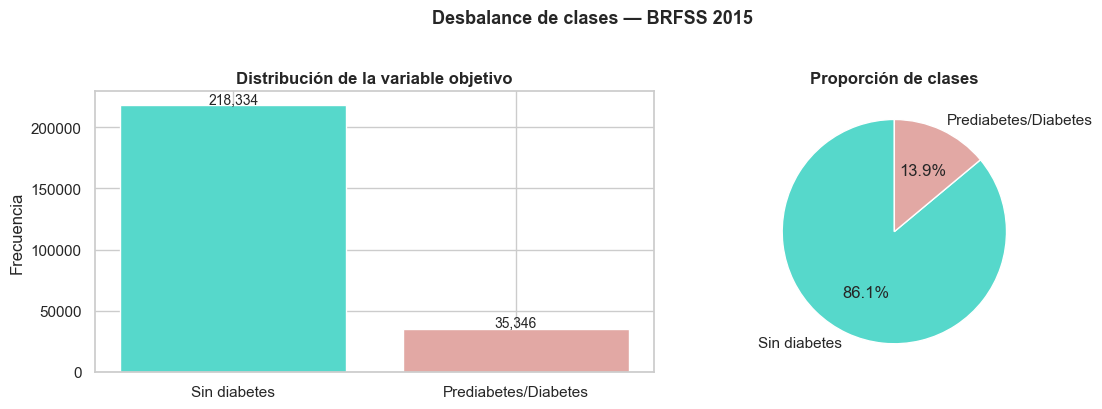

In [10]:
conteo = df[Objetivo].value_counts()
proporciones = df[Objetivo].value_counts(normalize=True) * 100

balance_df = pd.DataFrame({
    "Clase": ["Sin diabetes", "Prediabetes/Diabetes"],
    "Conteo": conteo.values,
    "Porcentaje": proporciones.values.round(2)
})
display(balance_df)

ratio = conteo[0] / conteo[1]
print(f"\nRatio de desbalance (mayoritaria/minoritaria): {ratio:.2f}:1")

#Gráfico
coral = "#E2A8A4"
aqua  = "#56D8CB"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(["Sin diabetes", "Prediabetes/Diabetes"],
            conteo.values, color=[aqua, coral], edgecolor="white")
axes[0].set_title("Distribución de la variable objetivo", fontweight="bold")
axes[0].set_ylabel("Frecuencia")
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 1000, f"{v:,}", ha="center", fontsize=10)

axes[1].pie(conteo.values,
            labels=["Sin diabetes", "Prediabetes/Diabetes"],
            colors=[aqua, coral],
            autopct="%1.1f%%",
            startangle=90)
axes[1].set_title("Proporción de clases", fontweight="bold")

plt.suptitle("Desbalance de clases — BRFSS 2015", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### **Interpretación** 

La variable objetivo presenta un desbalance importante entre las clases. Del total de observaciones, 218 334 corresponden a individuos sin diabetes, equivalentes al 86.07% del dataset, mientras que 35 346 observaciones corresponden a individuos con prediabetes o diabetes, representando únicamente el 13.93%.

Esto implica una razón de desbalance aproximada de 6.18:1, es decir, por cada individuo con diabetes existen más de seis individuos sin la enfermedad. Este nivel de desbalance puede inducir a que los modelos aprendan a favorecer la clase mayoritaria, obteniendo valores altos de accuracy incluso si identifican deficientemente los casos positivos.

Por esta razón, la accuracy no será utilizada como criterio principal de optimización. En su lugar, se priorizarán métricas como recall, F1-score y ROC AUC, ya que permiten evaluar de manera más adecuada la capacidad del modelo para detectar individuos con diabetes.

Además, este comportamiento justifica el uso de validación cruzada estratificada mediante StratifiedKFold, con el fin de preservar la proporción original de clases en cada partición de entrenamiento y validación.

Finalmente, el desbalance observado también respalda la necesidad de implementar posteriormente técnicas específicas para tratar clases desbalanceadas, como ``class_weight='balanced'``, SMOTE y ADASYN, las cuales serán comparadas para evaluar su impacto sobre el desempeño predictivo de los modelos.

## **Partición train/test** 

In [14]:
from operator import index

from sklearn.model_selection import train_test_split, StratifiedKFold

#Partición train/test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

split_summary = pd.DataFrame({
    "Conjunto": ["Train", "Test"],
    "Observaciones": [len(X_train), len(X_test)],
    "Porcentaje": [
        f"{len(X_train) / len(df_model) * 100:.1f}%",
        f"{len(X_test) / len(df_model) * 100:.1f}%"
    ],
    "Shape X": [str(X_train.shape), str(X_test.shape)],
    "Shape y": [str(y_train.shape), str(y_test.shape)]
})

display(split_summary.style.hide(axis="index"))

#Verificación de proporciones de clases

train_dist = y_train.value_counts(normalize=True).sort_index() * 100
test_dist = y_test.value_counts(normalize=True).sort_index() * 100

distribution_df = pd.DataFrame({
    "Clase": ["Sin diabetes", "Prediabetes/Diabetes"],
    "Train (%)": train_dist.values,
    "Test (%)": test_dist.values
})

display(distribution_df)

Conjunto,Observaciones,Porcentaje,Shape X,Shape y
Train,202944,80.0%,"(202944, 21)","(202944,)"
Test,50736,20.0%,"(50736, 21)","(50736,)"


,Clase,Train (%),Test (%)
0,Sin diabetes,86.0666,86.067092
1,Prediabetes/Diabetes,13.9334,13.932908


## **Validación cruzada estratificada** 

Se definió un esquema de validación cruzada estratificada de cinco pliegues mediante `StratifiedKFold`. Esta estrategia se seleccionó debido al desbalance observado en la variable objetivo, ya que permite preservar la proporción original de clases en cada subconjunto de entrenamiento y validación.

La tabla anterior confirma que todos los folds mantienen prácticamente la misma distribución de clases que el conjunto de entrenamiento global, con una proporción cercana al 86.07% para la clase 0 y 13.93% para la clase 1. En consecuencia, este esquema proporciona una base metodológicamente consistente para la comparación posterior de modelos y la optimización de hiperparámetros.

In [15]:
from sklearn.model_selection import StratifiedKFold

#Esquema de validación cruzada
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(cv_strategy)

#Verificación de la proporción de clases en cada fold

overall_dist = y_train.value_counts(normalize=True).sort_index() * 100

fold_summary = []

for fold, (train_idx, val_idx) in enumerate(cv_strategy.split(X_train, y_train), start=1):
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    train_dist = y_fold_train.value_counts(normalize=True).sort_index() * 100
    val_dist = y_fold_val.value_counts(normalize=True).sort_index() * 100

    fold_summary.append({
        "Fold": fold,
        "Train n": len(train_idx),
        "Val n": len(val_idx),
        "Train clase 0 (%)": round(train_dist.get(0, 0), 2),
        "Train clase 1 (%)": round(train_dist.get(1, 0), 2),
        "Val clase 0 (%)": round(val_dist.get(0, 0), 2),
        "Val clase 1 (%)": round(val_dist.get(1, 0), 2),
        "Global clase 0 (%)": round(overall_dist.get(0, 0), 2),
        "Global clase 1 (%)": round(overall_dist.get(1, 0), 2)
    })

fold_summary_df = pd.DataFrame(fold_summary)
display(fold_summary_df)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


,Fold,Train n,Val n,Train clase 0 (%),Train clase 1 (%),Val clase 0 (%),Val clase 1 (%),Global clase 0 (%),Global clase 1 (%)
0,1,162355,40589,86.07,13.93,86.07,13.93,86.07,13.93
1,2,162355,40589,86.07,13.93,86.07,13.93,86.07,13.93
2,3,162355,40589,86.07,13.93,86.07,13.93,86.07,13.93
3,4,162355,40589,86.07,13.93,86.07,13.93,86.07,13.93
4,5,162356,40588,86.07,13.93,86.07,13.93,86.07,13.93


## **Preprocesador**

In [16]:
#Función auxiliar para construir el preprocesador

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

def build_preprocessor(scale_numeric=True):
    """
    Construye un preprocesador según el tipo de variable.
    
    Parámetros
    ----------
    scale_numeric : bool
        Si True, escala variables numéricas continuas.
        Si False, solo imputa.
    """

    if scale_numeric:
        numeric_transformer_local = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])
    else:
        numeric_transformer_local = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median"))
        ])

    ordinal_transformer_local = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    binary_transformer_local = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent"))
    ])

    preprocessor_local = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer_local, numeric_cols),
            ("ord", ordinal_transformer_local, ordinal_cols),
            ("bin", binary_transformer_local, binary_feature_cols)
        ],
        remainder="drop"
    )

    return preprocessor_local

In [17]:
import pandas as pd
import numpy as np

#Construir preprocesador de inspección
preprocessor = build_preprocessor(scale_numeric=True)

print(preprocessor)

#Aplicar preprocesamiento únicamente sobre entrenamiento
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

#Obtener nombres finales de columnas
final_feature_names = numeric_cols + ordinal_cols + binary_feature_cols

X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=final_feature_names
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=final_feature_names
)

#Comparación de shapes
shape_summary = pd.DataFrame({
    "Conjunto": [
        "X_train original",
        "X_train transformado",
        "X_test original",
        "X_test transformado"
    ],
    "Shape": [
        str(X_train.shape),
        str(X_train_processed_df.shape),
        str(X_test.shape),
        str(X_test_processed_df.shape)
    ]
})

display(shape_summary)

#Verificación de escalado en variables numéricas
scaling_check = pd.DataFrame({
    "Variable": numeric_cols,
    "Media después de escalado": [
        X_train_processed_df[col].mean() for col in numeric_cols
    ],
    "Desv. estándar después de escalado": [
        X_train_processed_df[col].std() for col in numeric_cols
    ]
})

display(scaling_check.round(4))

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['BMI', 'MentHlth', 'PhysHlth']),
                                ('ord',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['GenHlth', 'Age', 'Education', 'Income']),
                                ('bin',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent'))]),
                                 ['HighBP', 'HighChol', 'CholCheck', 'Smoker',
                                  'Stroke', 'HeartDiseaseorAttack',
                                  'PhysActivity', 'Fruits',

,Conjunto,Shape
0,X_train original,"(202944, 21)"
1,X_train transformado,"(202944, 21)"
2,X_test original,"(50736, 21)"
3,X_test transformado,"(50736, 21)"


,Variable,Media después de escalado,Desv. estándar después de escalado
0,BMI,0.0,1.0
1,MentHlth,0.0,1.0
2,PhysHlth,-0.0,1.0


Aunque el dataset no presenta valores faltantes, se decidió conservar los imputadores dentro del pipeline por razones de robustez y reproducibilidad. Esto permite que el flujo de trabajo sea reutilizable en escenarios futuros donde puedan aparecer datos faltantes, sin necesidad de modificar la estructura del preprocesamiento.

Después de aplicar el preprocesador, se verifica que el número de observaciones permanezca igual y que únicamente se transformen las variables según su tipo. Adicionalmente, se comprueba que las variables numéricas escaladas presenten una media cercana a 0 y una desviación estándar cercana a 1, confirmando que el StandardScaler fue aplicado correctamente.

## **Función para los modelos benchmarks**

In [18]:
#Función general para benchmark de clasificadores

import time
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

def run_benchmark_classifier(
    model_name,
    estimator,
    scale_numeric=True,
    cv=None,
    n_jobs=-1
):
    """
    Ejecuta un benchmark de clasificación con hiperparámetros fijos.
    
    Parámetros
    ----------
    model_name : str
        Nombre del modelo.
    estimator : sklearn estimator
        Modelo ya configurado con hiperparámetros fijos.
    scale_numeric : bool
        Si True, escala variables numéricas.
    cv : cross-validator
        Esquema de validación cruzada.
    """

    if cv is None:
        cv = cv_strategy

    preprocessor_local = build_preprocessor(scale_numeric=scale_numeric)

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor_local),
        ("model", estimator)
    ])

    scoring_metrics = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "auc": "roc_auc"
    }

    start_time = time.time()

    cv_results = cross_validate(
        estimator=pipe,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring_metrics,
        return_train_score=False,
        n_jobs=n_jobs
    )

    pipe.fit(X_train, y_train)

    elapsed_time = time.time() - start_time

    y_pred = pipe.predict(X_test)

    if hasattr(pipe, "predict_proba"):
        y_score = pipe.predict_proba(X_test)[:, 1]
    elif hasattr(pipe, "decision_function"):
        y_score = pipe.decision_function(X_test)
    else:
        y_score = None

    results = {
        "Modelo": model_name,
        "CV Accuracy": np.mean(cv_results["test_accuracy"]),
        "CV Precision": np.mean(cv_results["test_precision"]),
        "CV Recall": np.mean(cv_results["test_recall"]),
        "CV F1": np.mean(cv_results["test_f1"]),
        "CV AUC": np.mean(cv_results["test_auc"]),
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred, zero_division=0),
        "Test Recall": recall_score(y_test, y_pred, zero_division=0),
        "Test F1": f1_score(y_test, y_pred, zero_division=0),
        "Test AUC": roc_auc_score(y_test, y_score) if y_score is not None else np.nan,
        "Tiempo (s)": elapsed_time,
        "Predicciones": y_pred,
        "Scores": y_score,
        "Pipeline": pipe,
        "Matriz Confusión": confusion_matrix(y_test, y_pred),
        "Reporte": classification_report(y_test, y_pred, output_dict=True)
    }

    return results

## **Funciones reutilizables**

En esta parte, se evaluarán todos los modelos relacionados a las tareas de clasificación, con el propósito de compararlos posteriormente cuando se maximice los hiperparámetros y el tiempo computacional.

In [89]:
def construir_pipeline_balanceo(modelo, nombre_tecnica, tecnica, escalado=True):
    """
    Construye un Pipeline (sklearn o imblearn) según la técnica de balanceo.
 
    Parámetros
    ----------
    modelo : estimator
        Modelo de clasificación ya instanciado.
    nombre_tecnica : str
        'Sin Balanceo' | 'SMOTE' | 'ADASYN' | 'Class Weight'
    tecnica : sampler o None
        Instancia SMOTE/ADASYN, o None para sin balanceo / class weight.
    escalado : bool
        Si True, aplica StandardScaler en el preprocesador.
 
    Retorna
    -------
    Pipeline listo para fit/predict.
 
    Notas
    -----
    KNN y Naive Bayes no aceptan class_weight; en ese caso se omite
    el parámetro y el pipeline se trata igual que 'Sin Balanceo'.
    XGBoost usa scale_pos_weight en lugar de class_weight.
    """
    from xgboost import XGBClassifier
 
    preprocesador = build_preprocessor(scale_numeric=escalado)
 
    if nombre_tecnica == "Class Weight":
        if isinstance(modelo, XGBClassifier):
            modelo.set_params(scale_pos_weight=218334 / 35346)
        else:
            try:
                modelo.set_params(class_weight="balanced")
            except (ValueError, TypeError):
                pass  # KNN, GaussianNB → no aplica, se ignora silenciosamente
 
        pipeline = Pipeline([
            ("preprocesador", preprocesador),
            ("modelo", modelo)
        ])
 
    elif tecnica is not None:          # SMOTE o ADASYN
        pipeline = ImbPipeline([
            ("preprocesador", preprocesador),
            ("balanceo", tecnica),
            ("modelo", modelo)
        ])
 
    else:                              # Sin Balanceo
        pipeline = Pipeline([
            ("preprocesador", preprocesador),
            ("modelo", modelo)
        ])
 
    return pipeline
 
 
def evaluar_modelo(nombre, pipeline, X_test, y_test):
    """
    Evalúa un pipeline ajustado sobre el conjunto de test.
 
    Parámetros
    ----------
    nombre : str
        Identificador del modelo.
    pipeline : Pipeline
        Pipeline ya ajustado (fit).
    X_test, y_test : array-like
        Datos de test.
 
    Retorna
    -------
    dict con métricas, predicciones, probabilidades, pipeline,
    matriz de confusión y reporte — misma estructura que run_benchmark_classifier.
    """
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
 
    return {
        "Modelo":                   nombre,
        "Test Accuracy":            accuracy_score(y_test, y_pred),
        "Test Precision":           precision_score(y_test, y_pred, zero_division=0),
        "Test Recall":              recall_score(y_test, y_pred, zero_division=0),
        "Test F1":                  f1_score(y_test, y_pred, zero_division=0),
        "Test ROC AUC":             roc_auc_score(y_test, y_prob),
        "Test Average Precision":   average_precision_score(y_test, y_prob),
        "Predicciones":             y_pred,
        "Probabilidades":           y_prob,
        "Pipeline":                 pipeline,
        "Matriz Confusión":         confusion_matrix(y_test, y_pred),
        "Reporte":                  classification_report(y_test, y_pred,
                                        zero_division=0, output_dict=True)
    }

Ahora que tenemos los Pipelines construimos una función que pruebe cada uno con cada técnica de optimización de hiperparámetros. Primero, hacemos una función reutilizable para evaluar todos los modelos con sus distintas configuraciones.

### **Grid Search**

In [87]:
def optimizar_gridsearch(modelo_nombre, estimator, param_grid, X_train, y_train,
                         cv, escalado=True, scoring="recall"):
   
    tecnicas = {
        "Sin Balanceo": None,
        "SMOTE":        SMOTE(random_state=RANDOM_STATE),
        "ADASYN":       ADASYN(random_state=RANDOM_STATE),
        "Class Weight": "balanced"
    }
 
    resultados_totales = {}
    os.makedirs(f"Modelos_Optimizados_No_Computacional/Grid_{modelo_nombre}",
                exist_ok=True)
 
    for nombre_tecnica, tecnica in tecnicas.items():
        print(f"Grid Search — {modelo_nombre} — {nombre_tecnica}\n")
 
        pipeline = construir_pipeline_balanceo(
            clone(estimator), nombre_tecnica, tecnica, escalado=escalado
        )
 
        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            scoring=scoring,
            cv=cv,
            n_jobs=-1,
            refit=True,
            verbose=1
        )
 
        inicio = time.time()
        grid_search.fit(X_train, y_train)
        tiempo = time.time() - inicio
 
        evaluacion = evaluar_modelo(
            f"Grid Search — {modelo_nombre} — {nombre_tecnica}",
            grid_search.best_estimator_,
            X_test,
            y_test
        )
 
        resultados_totales[nombre_tecnica] = {
            **evaluacion,
            "Mejores Hiperparámetros": grid_search.best_params_,
            f"Mejor {scoring} CV":     grid_search.best_score_,
            f"Std {scoring} CV":       grid_search.cv_results_["std_test_score"][
                                           grid_search.best_index_],
            "Tiempo (s)":              tiempo,
            "Iteraciones":             len(grid_search.cv_results_["params"])
        }
 
        joblib.dump(
            grid_search.best_estimator_,
            f"Modelos_Optimizados_No_Computacional/Grid_{modelo_nombre}/"
            f"grid_search_{modelo_nombre}_{nombre_tecnica}.joblib"
        )
        with open(
            f"Modelos_Optimizados_No_Computacional/Grid_{modelo_nombre}/"
            f"grid_{modelo_nombre}_resultados.pkl", "wb"
        ) as f:
            pickle.dump(resultados_totales, f)
 
        print(f"Tiempo: {tiempo:.2f}s | Mejor {scoring} CV: {grid_search.best_score_:.4f}")
        print(f"Mejores params: {grid_search.best_params_}\n")
 
    return resultados_totales

### **Random Search**

In [86]:
def optimizar_randomsearch(modelo_nombre, estimator, param_distributions,
                            X_train, y_train, cv, escalado=True,
                            scoring="recall", n_iter=50):
    
    tecnicas = {
        "Sin Balanceo": None,
        "SMOTE":        SMOTE(random_state=RANDOM_STATE),
        "ADASYN":       ADASYN(random_state=RANDOM_STATE),
        "Class Weight": "balanced"
    }
 
    resultados_totales = {}
    os.makedirs(f"Modelos_Optimizados_No_Computacional/Random_{modelo_nombre}",
                exist_ok=True)
 
    for nombre_tecnica, tecnica in tecnicas.items():
        print(f"Random Search — {modelo_nombre} — {nombre_tecnica}\n")
 
        pipeline = construir_pipeline_balanceo(
            clone(estimator), nombre_tecnica, tecnica, escalado=escalado
        )
 
        random_search = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=param_distributions,
            n_iter=n_iter,
            scoring=scoring,
            cv=cv,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            refit=True,
            verbose=1
        )
 
        inicio = time.time()
        random_search.fit(X_train, y_train)
        tiempo = time.time() - inicio
 
        evaluacion = evaluar_modelo(
            f"Random Search — {modelo_nombre} — {nombre_tecnica}",
            random_search.best_estimator_,
            X_test,
            y_test
        )
 
        resultados_totales[nombre_tecnica] = {
            **evaluacion,
            "Mejores Hiperparámetros": random_search.best_params_,
            f"Mejor {scoring} CV":     random_search.best_score_,
            f"Std {scoring} CV":       random_search.cv_results_["std_test_score"][
                                           random_search.best_index_],
            "Tiempo (s)":              tiempo,
            "Iteraciones":             n_iter
        }
 
        joblib.dump(
            random_search.best_estimator_,
            f"Modelos_Optimizados_No_Computacional/Random_{modelo_nombre}/"
            f"random_search_{modelo_nombre}_{nombre_tecnica}.joblib"
        )
        with open(
            f"Modelos_Optimizados_No_Computacional/Random_{modelo_nombre}/"
            f"random_{modelo_nombre}_resultados.pkl", "wb"
        ) as f:
            pickle.dump(resultados_totales, f)
 
        print(f"Tiempo: {tiempo:.2f}s | Mejor {scoring} CV: {random_search.best_score_:.4f}")
        print(f"Mejores params: {random_search.best_params_}\n")
 
    return resultados_totales

### **Optuna**

In [94]:
def definir_espacio_optuna(trial, estimator):

    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.naive_bayes import GaussianNB
    from xgboost import XGBClassifier
 
    if isinstance(estimator, KNeighborsClassifier):
        return {
            "n_neighbors": trial.suggest_int("n_neighbors", 3, 29, step=2),
            "weights":     trial.suggest_categorical("weights",
                               ["uniform", "distance"]),
            "metric":      trial.suggest_categorical("metric",
                               ["euclidean", "manhattan", "minkowski"])
        }
    elif isinstance(estimator, GaussianNB):
        return {
            "var_smoothing": trial.suggest_float("var_smoothing",
                                 1e-11, 1e-7, log=True)
        }
    elif isinstance(estimator, XGBClassifier):
        return {
            "n_estimators":     trial.suggest_int("n_estimators", 100, 500),
            "max_depth":        trial.suggest_int("max_depth", 3, 10),
            "learning_rate":    trial.suggest_float("learning_rate",
                                    0.01, 0.3, log=True),
            "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10)
        }
    elif isinstance(estimator, FAISSKNNClassifier):
        return {
        "n_neighbors": trial.suggest_int("n_neighbors", 3, 21, step=2),
        "weights":     trial.suggest_categorical("weights",
                           ["uniform", "distance"]),
        "metric":      "euclidean",
        }
    else:
        raise ValueError(f"Modelo no reconocido: {type(estimator)}")
    
 
 
def optimizar_optuna(modelo_nombre, estimator, model_factory, X_train, y_train,
                     cv, escalado=True, n_trials=30, scoring="recall"):
    
    tecnicas = {
        "Sin Balanceo": None,
        "SMOTE":        SMOTE(random_state=RANDOM_STATE),
        "ADASYN":       ADASYN(random_state=RANDOM_STATE),
        "Class Weight": "balanced"
    }
 
    resultados_totales = {}
    os.makedirs(f"Modelos_Optimizados_No_Computacional/Optuna_{modelo_nombre}",
                exist_ok=True)
 
    for nombre_tecnica, tecnica in tecnicas.items():
        print(f"\n{'='*60}")
        print(f"Optuna — {modelo_nombre} — {nombre_tecnica}")
        print(f"{'='*60}")
 
        def objective(trial):
            params   = definir_espacio_optuna(trial, estimator)
            modelo   = model_factory(params)
 
            # Pipeline completo dentro del trial → sin data leakage
            pipeline = construir_pipeline_balanceo(
                modelo, nombre_tecnica, tecnica, escalado=escalado
            )
            scores = cross_val_score(
                pipeline, X_train, y_train,
                cv=cv, scoring=scoring, n_jobs=-1
            )
            return scores.mean()
 
        study = optuna.create_study(
            direction="maximize",
            sampler=TPESampler(seed=RANDOM_STATE),
            study_name=f"{modelo_nombre}_{nombre_tecnica}"
        )
 
        inicio = time.time()
        study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
        tiempo = time.time() - inicio
 
        # Reentrenar con los mejores parámetros sobre todo X_train
        mejores_params = study.best_params
        pipeline_final = construir_pipeline_balanceo(
            model_factory(mejores_params), nombre_tecnica, tecnica, escalado=escalado
        )
        pipeline_final.fit(X_train, y_train)
 
        evaluacion = evaluar_modelo(
            f"Optuna — {modelo_nombre} — {nombre_tecnica}",
            pipeline_final,
            X_test,
            y_test
        )
 
        resultados_totales[nombre_tecnica] = {
            **evaluacion,
            "Mejores Hiperparámetros": mejores_params,
            f"Mejor {scoring} CV":     study.best_value,
            "Tiempo (s)":              tiempo,
            "Iteraciones":             n_trials
        }
 
        joblib.dump(
            pipeline_final,
            f"Modelos_Optimizados_No_Computacional/Optuna_{modelo_nombre}/"
            f"optuna_{modelo_nombre}_{nombre_tecnica}.joblib"
        )
        joblib.dump(
            study,
            f"Modelos_Optimizados_No_Computacional/Optuna_{modelo_nombre}/"
            f"optuna_{modelo_nombre}_{nombre_tecnica}_study.joblib"
        )
        with open(
            f"Modelos_Optimizados_No_Computacional/Optuna_{modelo_nombre}/"
            f"optuna_{modelo_nombre}_resultados.pkl", "wb"
        ) as f:
            pickle.dump(resultados_totales, f)
 
        print(f"\nTiempo: {tiempo:.2f}s | Mejor {scoring} CV: {study.best_value:.4f}")
        print(f"Mejores params: {mejores_params}\n")
 
    return resultados_totales
 

### **DEAP**

In [84]:
def optimizar_deap(modelo_nombre, estimator, model_factory, espacio,
                   X_train, y_train, cv, escalado=True,
                   n_generaciones=5, tam_poblacion=20, scoring="recall"):

    keys    = list(espacio.keys())
    valores = list(espacio.values())
 
    tecnicas = {
        "Sin Balanceo": None,
        "SMOTE":        SMOTE(random_state=RANDOM_STATE),
        "ADASYN":       ADASYN(random_state=RANDOM_STATE),
        "Class Weight": "balanced"
    }
 
    resultados_totales = {}
    os.makedirs(f"Modelos_Optimizados_No_Computacional/DEAP_{modelo_nombre}",
                exist_ok=True)
 
    for nombre_tecnica, tecnica in tecnicas.items():
        print(f"\n{'='*60}")
        print(f"DEAP — {modelo_nombre} — {nombre_tecnica}")
        print(f"{'='*60}")
 
        # Reiniciar clases DEAP (evita error en ejecuciones repetidas en notebook)
        for attr in ["FitnessMax", "Individual"]:
            if hasattr(creator, attr):
                delattr(creator, attr)
 
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
        creator.create("Individual", list, fitness=creator.FitnessMax)
 
        toolbox = base.Toolbox()
 
        def crear_individuo():
            return creator.Individual([
                random.randint(0, len(v) - 1) for v in valores
            ])
 
        toolbox.register("individual", crear_individuo)
        toolbox.register("population", tools.initRepeat, list, toolbox.individual)
 
        def evaluar_individuo(individuo):
            """
            Cada individuo construye su propio pipeline completo.
            cross_val_score ajusta el preprocesador solo sobre los datos
            de entrenamiento de cada fold → sin data leakage.
            """
            params = {
                keys[i]: valores[i][min(int(idx), len(valores[i]) - 1)]
                for i, idx in enumerate(individuo)
            }
            try:
                modelo   = model_factory(params)
                pipeline = construir_pipeline_balanceo(
                    modelo, nombre_tecnica, tecnica, escalado=escalado
                )
                scores = cross_val_score(
                    pipeline, X_train, y_train,
                    cv=cv, scoring=scoring, n_jobs=-1
                )
                return (scores.mean(),)
            except Exception as e:
                print(f"  Error en individuo {individuo}: {e}")
                return (0.0,)
 
        toolbox.register("evaluate", evaluar_individuo)
        toolbox.register("mate",   tools.cxUniform, indpb=0.5)
        toolbox.register("mutate", tools.mutUniformInt,
                         low=0,
                         up=[len(v) - 1 for v in valores],
                         indpb=0.2)
        toolbox.register("select", tools.selTournament, tournsize=3)
 
        random.seed(RANDOM_STATE)
        np.random.seed(RANDOM_STATE)
 
        poblacion    = toolbox.population(n=tam_poblacion)
        hall_of_fame = tools.HallOfFame(1)
        stats        = tools.Statistics(lambda ind: ind.fitness.values)
        stats.register("max",  np.max)
        stats.register("mean", np.mean)
        stats.register("min",  np.min)
        historia = []
 
        inicio = time.time()
 
        for gen in range(n_generaciones):
            fits = list(map(toolbox.evaluate, poblacion))
            for ind, fit in zip(poblacion, fits):
                ind.fitness.values = fit
 
            hall_of_fame.update(poblacion)
            record = stats.compile(poblacion)
            historia.append(record)
 
            print(f"  Gen {gen+1:02d}/{n_generaciones} | "
                  f"Max {scoring}: {record['max']:.4f} | "
                  f"Mean: {record['mean']:.4f} | "
                  f"Min: {record['min']:.4f}")
 
            offspring = algorithms.varAnd(
                toolbox.select(poblacion, len(poblacion)),
                toolbox, cxpb=0.5, mutpb=0.3
            )
            poblacion = offspring
 
        # Evaluar última generación
        fits = list(map(toolbox.evaluate, poblacion))
        for ind, fit in zip(poblacion, fits):
            ind.fitness.values = fit
        hall_of_fame.update(poblacion)
 
        tiempo = time.time() - inicio
 
        # Reentrenar con el mejor individuo sobre todo X_train
        mejores_params = {
            keys[i]: valores[i][min(int(idx), len(valores[i]) - 1)]
            for i, idx in enumerate(hall_of_fame[0])
        }
        pipeline_final = construir_pipeline_balanceo(
            model_factory(mejores_params), nombre_tecnica, tecnica, escalado=escalado
        )
        pipeline_final.fit(X_train, y_train)
 
        evaluacion = evaluar_modelo(
            f"DEAP — {modelo_nombre} — {nombre_tecnica}",
            pipeline_final,
            X_test,
            y_test
        )
 
        scores_historia = [g["max"] for g in historia]
 
        resultados_totales[nombre_tecnica] = {
            **evaluacion,
            "Mejores Hiperparámetros": mejores_params,
            f"Mejor {scoring} CV":     hall_of_fame[0].fitness.values[0],
            f"Std {scoring} CV":       float(np.std(scores_historia)),
            "Tiempo (s)":              tiempo,
            "Iteraciones":             n_generaciones * tam_poblacion,
            "Historia":                historia
        }
 
        joblib.dump(
            pipeline_final,
            f"Modelos_Optimizados_No_Computacional/DEAP_{modelo_nombre}/"
            f"deap_{modelo_nombre}_{nombre_tecnica}.joblib"
        )
        with open(
            f"Modelos_Optimizados_No_Computacional/DEAP_{modelo_nombre}/"
            f"deap_{modelo_nombre}_resultados.pkl", "wb"
        ) as f:
            pickle.dump(resultados_totales, f)
 
        print(f"\n  Tiempo: {tiempo:.2f}s | "
              f"Mejor {scoring} CV: {hall_of_fame[0].fitness.values[0]:.4f}")
        print(f"  Mejores params: {mejores_params}\n")
 
    return resultados_totales
 

# **Modelado benchmarks**

### **KNN**

In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

knn_k_results = []

for k in [3, 5, 7, 9, 11]:
    
    knn_pipe = Pipeline(steps=[
        ("preprocessor", build_preprocessor(scale_numeric=True)),
        ("model", KNeighborsClassifier(
            n_neighbors=k,
            weights="uniform",
            metric="euclidean"
        ))
    ])

    knn_pipe.fit(X_train, y_train)

    y_pred_k = knn_pipe.predict(X_test)
    y_score_k = knn_pipe.predict_proba(X_test)[:, 1]

    knn_k_results.append({
        "k": k,
        "Precision": precision_score(y_test, y_pred_k, zero_division=0),
        "Recall": recall_score(y_test, y_pred_k, zero_division=0),
        "F1": f1_score(y_test, y_pred_k, zero_division=0),
        "AUC": roc_auc_score(y_test, y_score_k)
    })

knn_k_summary = pd.DataFrame(knn_k_results)
display(knn_k_summary.round(4))

  File "c:\Users\MSI TRUE GAMING\miniconda3\envs\ml_venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\MSI TRUE GAMING\miniconda3\envs\ml_venv\lib\subprocess.py", line 505, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\MSI TRUE GAMING\miniconda3\envs\ml_venv\lib\subprocess.py", line 951, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\MSI TRUE GAMING\miniconda3\envs\ml_venv\lib\subprocess.py", line 1436, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


,k,Precision,Recall,F1,AUC
0,3,0.3705,0.2340,0.2868,0.6808
1,5,0.4104,0.2036,0.2722,0.7201
2,7,0.4350,0.1828,0.2574,0.7430
3,9,0.4548,0.1693,0.2468,0.7561
4,11,0.4608,0.1562,0.2333,0.7653


In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold

cv_knn = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

results_knn = run_benchmark_classifier(
    model_name="KNN",
    estimator=KNeighborsClassifier(
        n_neighbors=5,  
        weights="uniform",
        metric="euclidean"
    ),
    scale_numeric=True,
    cv=cv_knn
)

In [22]:
knn_summary = pd.DataFrame([{
    "Modelo": results_knn["Modelo"],
    "CV Accuracy": results_knn["CV Accuracy"],
    "CV Precision": results_knn["CV Precision"],
    "CV Recall": results_knn["CV Recall"],
    "CV F1": results_knn["CV F1"],
    "CV AUC": results_knn["CV AUC"],
    "Test Accuracy": results_knn["Test Accuracy"],
    "Test Precision": results_knn["Test Precision"],
    "Test Recall": results_knn["Test Recall"],
    "Test F1": results_knn["Test F1"],
    "Test AUC": results_knn["Test AUC"],
    "Tiempo (s)": results_knn["Tiempo (s)"]
}])

display(knn_summary.round(4))

,Modelo,CV Accuracy,CV Precision,CV Recall,CV F1,CV AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test AUC,Tiempo (s)
0,KNN,0.8492,0.4168,0.206,0.2757,0.7197,0.8483,0.4104,0.2036,0.2722,0.7201,92.7793


In [23]:
print("Reporte de clasificación - KNN")
print(classification_report(y_test, results_knn["Predicciones"], zero_division=0))

Reporte de clasificación - KNN
              precision    recall  f1-score   support

         0.0       0.88      0.95      0.92     43667
         1.0       0.41      0.20      0.27      7069

    accuracy                           0.85     50736
   macro avg       0.65      0.58      0.59     50736
weighted avg       0.82      0.85      0.83     50736



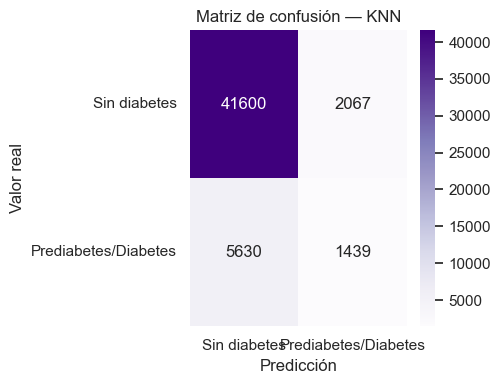

In [24]:
cm_knn = results_knn["Matriz Confusión"]

plt.figure(figsize=(5, 4))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Purples")
plt.title("Matriz de confusión — KNN")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks([0.5, 1.5], ["Sin diabetes", "Prediabetes/Diabetes"])
plt.yticks([0.5, 1.5], ["Sin diabetes", "Prediabetes/Diabetes"], rotation=0)
plt.tight_layout()
plt.show()

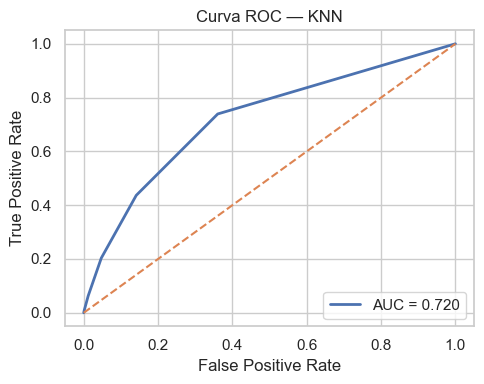

In [25]:
from sklearn.metrics import roc_curve

y_score_knn = results_knn["Scores"]
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_score_knn)

plt.figure(figsize=(5, 4))
plt.plot(
    fpr_knn,
    tpr_knn,
    label=f"AUC = {results_knn['Test AUC']:.3f}",
    linewidth=2
)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Curva ROC — KNN")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### **Regresión Logística L2**

In [243]:
from sklearn.linear_model import LogisticRegression

results_logreg_l2 = run_benchmark_classifier(
    model_name="Logistic Regression L2",
    estimator=LogisticRegression(
        penalty="l2",
        solver="liblinear",
        C=1.0,
        max_iter=1000,
        random_state=42
    ),
    scale_numeric=True,
    cv=cv_strategy
)

In [ ]:
logreg_l2_summary = pd.DataFrame([{
    "Modelo": results_logreg_l2["Modelo"],
    "CV Accuracy": results_logreg_l2["CV Accuracy"],
    "CV Precision": results_logreg_l2["CV Precision"],
    "CV Recall": results_logreg_l2["CV Recall"],
    "CV F1": results_logreg_l2["CV F1"],
    "CV AUC": results_logreg_l2["CV AUC"],
    "Test Accuracy": results_logreg_l2["Test Accuracy"],
    "Test Precision": results_logreg_l2["Test Precision"],
    "Test Recall": results_logreg_l2["Test Recall"],
    "Test F1": results_logreg_l2["Test F1"],
    "Test AUC": results_logreg_l2["Test AUC"],
    "Tiempo (s)": results_logreg_l2["Tiempo (s)"]
}])

display(logreg_l2_summary.round(4))

,Modelo,CV Accuracy,CV Precision,CV Recall,CV F1,CV AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test AUC,Tiempo (s)
0,Logistic Regression L2,0.8639,0.5391,0.1579,0.2443,0.8228,0.8622,0.5181,0.1583,0.2425,0.8192,7.2025


In [245]:
print("Reporte de clasificación - Logistic Regression L2")
print(classification_report(y_test, results_logreg_l2["Predicciones"], zero_division=0))

Reporte de clasificación - Logistic Regression L2
              precision    recall  f1-score   support

         0.0       0.88      0.98      0.92     43667
         1.0       0.52      0.16      0.24      7069

    accuracy                           0.86     50736
   macro avg       0.70      0.57      0.58     50736
weighted avg       0.83      0.86      0.83     50736



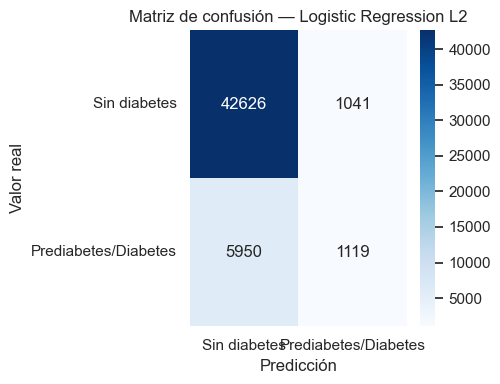

In [246]:
cm_logreg_l2 = results_logreg_l2["Matriz Confusión"]

plt.figure(figsize=(5, 4))
sns.heatmap(cm_logreg_l2, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión — Logistic Regression L2")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks([0.5, 1.5], ["Sin diabetes", "Prediabetes/Diabetes"])
plt.yticks([0.5, 1.5], ["Sin diabetes", "Prediabetes/Diabetes"], rotation=0)
plt.tight_layout()
plt.show()

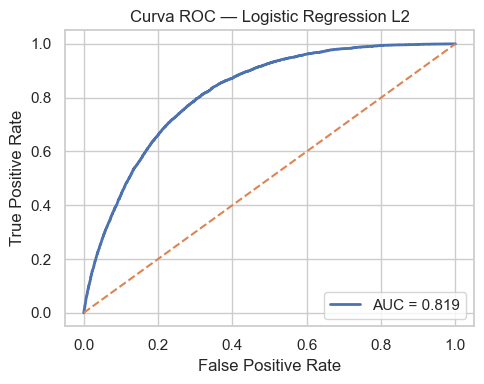

In [247]:
from sklearn.metrics import roc_curve

y_score_logreg_l2 = results_logreg_l2["Scores"]
fpr_logreg_l2, tpr_logreg_l2, _ = roc_curve(y_test, y_score_logreg_l2)

plt.figure(figsize=(5, 4))
plt.plot(
    fpr_logreg_l2,
    tpr_logreg_l2,
    label=f"AUC = {results_logreg_l2['Test AUC']:.3f}",
    linewidth=2
)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Curva ROC — Logistic Regression L2")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

---
### **Regresión Logística L1**

In [248]:
from sklearn.linear_model import LogisticRegression

results_logreg_l1 = run_benchmark_classifier(
    model_name="Logistic Regression L1",
    estimator=LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=1.0,
        max_iter=1000,
        random_state=42
    ),
    scale_numeric=True,
    cv=cv_strategy
)

In [249]:
logreg_l1_summary = pd.DataFrame([{
    "Modelo": results_logreg_l1["Modelo"],
    "CV Accuracy": results_logreg_l1["CV Accuracy"],
    "CV Precision": results_logreg_l1["CV Precision"],
    "CV Recall": results_logreg_l1["CV Recall"],
    "CV F1": results_logreg_l1["CV F1"],
    "CV AUC": results_logreg_l1["CV AUC"],
    "Test Accuracy": results_logreg_l1["Test Accuracy"],
    "Test Precision": results_logreg_l1["Test Precision"],
    "Test Recall": results_logreg_l1["Test Recall"],
    "Test F1": results_logreg_l1["Test F1"],
    "Test AUC": results_logreg_l1["Test AUC"],
    "Tiempo (s)": results_logreg_l1["Tiempo (s)"]
}])

display(logreg_l1_summary.round(4))

,Modelo,CV Accuracy,CV Precision,CV Recall,CV F1,CV AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test AUC,Tiempo (s)
0,Logistic Regression L1,0.8639,0.5392,0.158,0.2443,0.8228,0.8622,0.5178,0.1583,0.2425,0.8192,27.0798


In [250]:
print("Reporte de clasificación - Logistic Regression L1")
print(classification_report(y_test, results_logreg_l1["Predicciones"], zero_division=0))

Reporte de clasificación - Logistic Regression L1
              precision    recall  f1-score   support

         0.0       0.88      0.98      0.92     43667
         1.0       0.52      0.16      0.24      7069

    accuracy                           0.86     50736
   macro avg       0.70      0.57      0.58     50736
weighted avg       0.83      0.86      0.83     50736



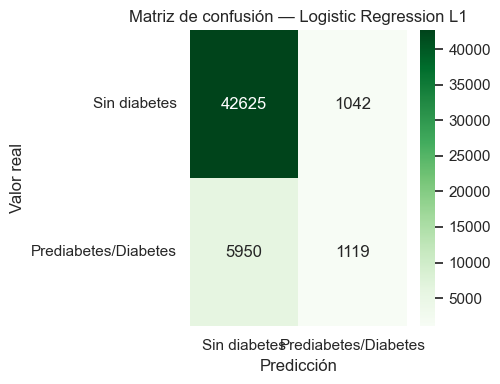

In [251]:
cm_logreg_l1 = results_logreg_l1["Matriz Confusión"]

plt.figure(figsize=(5, 4))
sns.heatmap(cm_logreg_l1, annot=True, fmt="d", cmap="Greens")
plt.title("Matriz de confusión — Logistic Regression L1")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks([0.5, 1.5], ["Sin diabetes", "Prediabetes/Diabetes"])
plt.yticks([0.5, 1.5], ["Sin diabetes", "Prediabetes/Diabetes"], rotation=0)
plt.tight_layout()
plt.show()

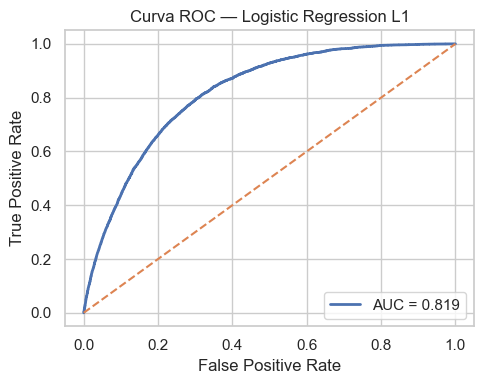

In [252]:
from sklearn.metrics import roc_curve

y_score_logreg_l1 = results_logreg_l1["Scores"]
fpr_logreg_l1, tpr_logreg_l1, _ = roc_curve(y_test, y_score_logreg_l1)

plt.figure(figsize=(5, 4))
plt.plot(
    fpr_logreg_l1,
    tpr_logreg_l1,
    label=f"AUC = {results_logreg_l1['Test AUC']:.3f}",
    linewidth=2
)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Curva ROC — Logistic Regression L1")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

---
### **Clasificación Naïve Bayes**

In [38]:
from sklearn.naive_bayes import GaussianNB

results_gnb = run_benchmark_classifier(
    model_name="Gaussian Naive Bayes",
    estimator=GaussianNB(),
    scale_numeric=True,
    cv=cv_strategy
)

In [39]:
gnb_summary = pd.DataFrame([{
    "Modelo": results_gnb["Modelo"],
    "CV Accuracy": results_gnb["CV Accuracy"],
    "CV Precision": results_gnb["CV Precision"],
    "CV Recall": results_gnb["CV Recall"],
    "CV F1": results_gnb["CV F1"],
    "CV AUC": results_gnb["CV AUC"],
    "Test Accuracy": results_gnb["Test Accuracy"],
    "Test Precision": results_gnb["Test Precision"],
    "Test Recall": results_gnb["Test Recall"],
    "Test F1": results_gnb["Test F1"],
    "Test AUC": results_gnb["Test AUC"],
    "Tiempo (s)": results_gnb["Tiempo (s)"]
}])

display(gnb_summary.round(4))

,Modelo,CV Accuracy,CV Precision,CV Recall,CV F1,CV AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test AUC,Tiempo (s)
0,Gaussian Naive Bayes,0.7736,0.3234,0.572,0.4132,0.7848,0.7722,0.3198,0.5639,0.4082,0.7803,5.7363


In [62]:
print("Reporte de clasificación - Gaussian Naive Bayes")
print(classification_report(y_test, results_gnb["Predicciones"], zero_division=0))

Reporte de clasificación - Gaussian Naive Bayes
              precision    recall  f1-score   support

         0.0       0.92      0.81      0.86     43667
         1.0       0.32      0.56      0.41      7069

    accuracy                           0.77     50736
   macro avg       0.62      0.68      0.63     50736
weighted avg       0.84      0.77      0.80     50736



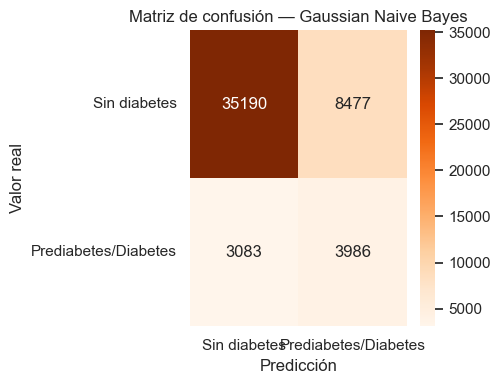

In [40]:
cm_gnb = results_gnb["Matriz Confusión"]

plt.figure(figsize=(5, 4))
sns.heatmap(cm_gnb, annot=True, fmt="d", cmap="Oranges")
plt.title("Matriz de confusión — Gaussian Naive Bayes")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks([0.5, 1.5], ["Sin diabetes", "Prediabetes/Diabetes"])
plt.yticks([0.5, 1.5], ["Sin diabetes", "Prediabetes/Diabetes"], rotation=0)
plt.tight_layout()
plt.show()

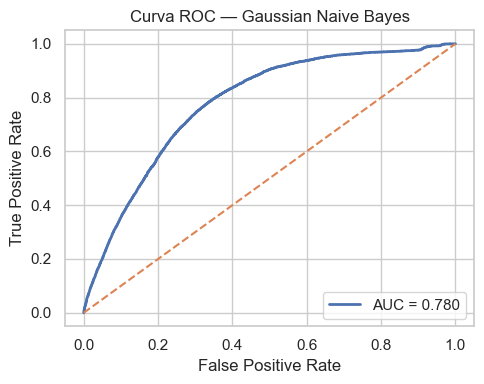

In [41]:
from sklearn.metrics import roc_curve

y_score_gnb = results_gnb["Scores"]
fpr_gnb, tpr_gnb, _ = roc_curve(y_test, y_score_gnb)

plt.figure(figsize=(5, 4))
plt.plot(
    fpr_gnb,
    tpr_gnb,
    label=f"AUC = {results_gnb['Test AUC']:.3f}",
    linewidth=2
)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Curva ROC — Gaussian Naive Bayes")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

---
### **Decision Tree**

In [258]:
from sklearn.tree import DecisionTreeClassifier

results_dt = run_benchmark_classifier(
    model_name="Decision Tree",
    estimator=DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ),
    scale_numeric=False,
    cv=cv_strategy
)

In [259]:
dt_summary = pd.DataFrame([{
    "Modelo": results_dt["Modelo"],
    "CV Accuracy": results_dt["CV Accuracy"],
    "CV Precision": results_dt["CV Precision"],
    "CV Recall": results_dt["CV Recall"],
    "CV F1": results_dt["CV F1"],
    "CV AUC": results_dt["CV AUC"],
    "Test Accuracy": results_dt["Test Accuracy"],
    "Test Precision": results_dt["Test Precision"],
    "Test Recall": results_dt["Test Recall"],
    "Test F1": results_dt["Test F1"],
    "Test AUC": results_dt["Test AUC"],
    "Tiempo (s)": results_dt["Tiempo (s)"]
}])

display(dt_summary.round(4))

,Modelo,CV Accuracy,CV Precision,CV Recall,CV F1,CV AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test AUC,Tiempo (s)
0,Decision Tree,0.8629,0.5258,0.1612,0.2461,0.8091,0.8627,0.5243,0.1587,0.2437,0.8074,2.6891


In [260]:
print("Reporte de clasificación - Decision Tree")
print(classification_report(y_test, results_dt["Predicciones"], zero_division=0))

Reporte de clasificación - Decision Tree
              precision    recall  f1-score   support

         0.0       0.88      0.98      0.92     43667
         1.0       0.52      0.16      0.24      7069

    accuracy                           0.86     50736
   macro avg       0.70      0.57      0.58     50736
weighted avg       0.83      0.86      0.83     50736



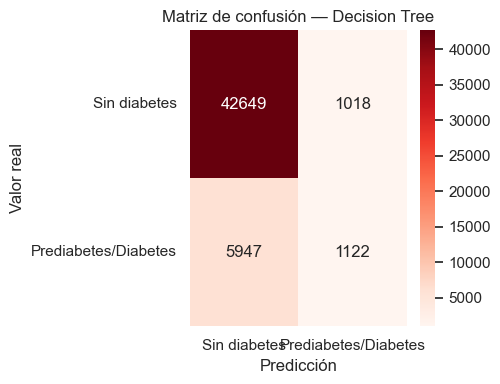

In [261]:
cm_dt = results_dt["Matriz Confusión"]

plt.figure(figsize=(5, 4))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Reds")
plt.title("Matriz de confusión — Decision Tree")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks([0.5, 1.5], ["Sin diabetes", "Prediabetes/Diabetes"])
plt.yticks([0.5, 1.5], ["Sin diabetes", "Prediabetes/Diabetes"], rotation=0)
plt.tight_layout()
plt.show()

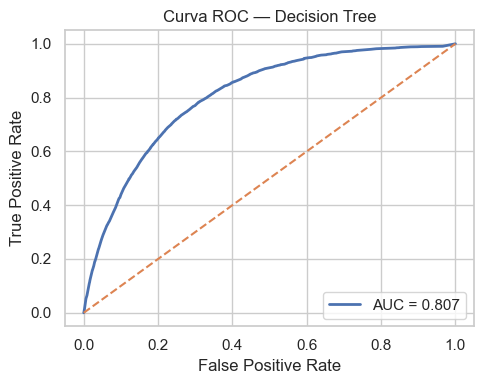

In [262]:
from sklearn.metrics import roc_curve

y_score_dt = results_dt["Scores"]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_score_dt)

plt.figure(figsize=(5, 4))
plt.plot(
    fpr_dt,
    tpr_dt,
    label=f"AUC = {results_dt['Test AUC']:.3f}",
    linewidth=2
)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Curva ROC — Decision Tree")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

---
### **Random Forest**

In [285]:
from sklearn.ensemble import RandomForestClassifier

results_rf = run_benchmark_classifier(
    model_name="Random Forest",
    estimator=RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),
    scale_numeric=False,
    cv=cv_strategy
)

In [286]:
rf_summary = pd.DataFrame([{
    "Modelo": results_rf["Modelo"],
    "CV Accuracy": results_rf["CV Accuracy"],
    "CV Precision": results_rf["CV Precision"],
    "CV Recall": results_rf["CV Recall"],
    "CV F1": results_rf["CV F1"],
    "CV AUC": results_rf["CV AUC"],
    "Test Accuracy": results_rf["Test Accuracy"],
    "Test Precision": results_rf["Test Precision"],
    "Test Recall": results_rf["Test Recall"],
    "Test F1": results_rf["Test F1"],
    "Test AUC": results_rf["Test AUC"],
    "Tiempo (s)": results_rf["Tiempo (s)"]
}])

display(rf_summary.round(4))

,Modelo,CV Accuracy,CV Precision,CV Recall,CV F1,CV AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test AUC,Tiempo (s)
0,Random Forest,0.866,0.6284,0.0937,0.163,0.8268,0.8648,0.6008,0.0873,0.1524,0.8223,29.7307


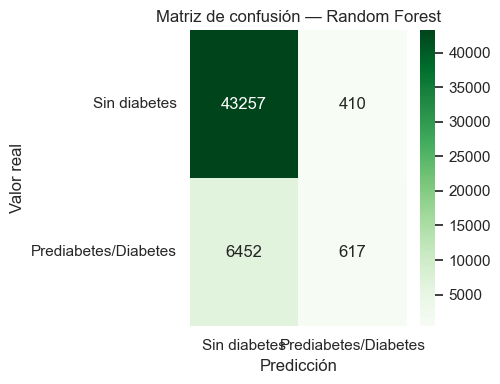

In [265]:
cm_rf = results_rf["Matriz Confusión"]

plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Matriz de confusión — Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks([0.5, 1.5], ["Sin diabetes", "Prediabetes/Diabetes"])
plt.yticks([0.5, 1.5], ["Sin diabetes", "Prediabetes/Diabetes"], rotation=0)
plt.tight_layout()
plt.show()

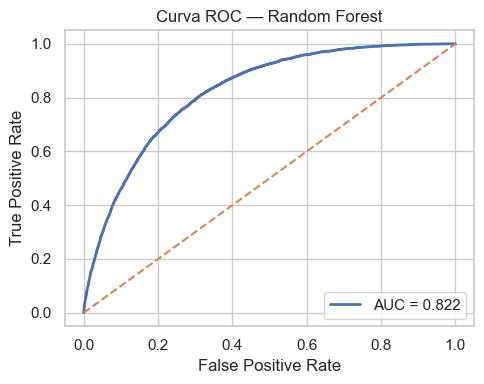

In [266]:
from sklearn.metrics import roc_curve

y_score_rf = results_rf["Scores"]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_score_rf)

plt.figure(figsize=(5, 4))
plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"AUC = {results_rf['Test AUC']:.3f}",
    linewidth=2
)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Curva ROC — Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

---
### **XGBoost + LIME**

In [273]:
!pip install xgboost

   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
    --------------------------------------- 2.4/124.9 MB 19.2 MB/s eta 0:00:07
   --- ------------------------------------ 10.2/124.9 MB 33.7 MB/s eta 0:00:04
   ----- ---------------------------------- 18.6/124.9 MB 36.7 MB/s eta 0:00:03
   ------- -------------------------------- 24.4/124.9 MB 33.6 MB/s eta 0:00:03
   ---------- ----------------------------- 32.8/124.9 MB 35.3 MB/s eta 0:00:03
   ------------- -------------------------- 40.9/124.9 MB 35.6 MB/s eta 0:00:03
   --------------- ------------------------ 49.0/124.9 MB 36.3 MB/s eta 0:00:03
   ------------------ --------------------- 57.1/124.9 MB 36.8 MB/s eta 0:00:02
   -------------------- ------------------- 65.5/124.9 MB 37.3 MB/s eta 0:00:02
   ----------------------- ---------------- 73.7/124.9 MB 37.6 MB/s eta 0:00:02
   -------------------------- ------------- 81.8/124.9 MB 37.6 MB/s eta 0:00:02
   ---------------------------- ----------- 89.7/1

In [49]:
from xgboost import XGBClassifier

results_xgb = run_benchmark_classifier(
    model_name="XGBoost",
    estimator=XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),
    scale_numeric=False,
    cv=cv_strategy
)

In [50]:
xgb_summary = pd.DataFrame([{
    "Modelo": results_xgb["Modelo"],
    "CV Accuracy": results_xgb["CV Accuracy"],
    "CV Precision": results_xgb["CV Precision"],
    "CV Recall": results_xgb["CV Recall"],
    "CV F1": results_xgb["CV F1"],
    "CV AUC": results_xgb["CV AUC"],
    "Test Accuracy": results_xgb["Test Accuracy"],
    "Test Precision": results_xgb["Test Precision"],
    "Test Recall": results_xgb["Test Recall"],
    "Test F1": results_xgb["Test F1"],
    "Test AUC": results_xgb["Test AUC"],
    "Tiempo (s)": results_xgb["Tiempo (s)"]
}])

display(xgb_summary.round(4))

,Modelo,CV Accuracy,CV Precision,CV Recall,CV F1,CV AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test AUC,Tiempo (s)
0,XGBoost,0.8672,0.5805,0.1685,0.2611,0.8312,0.8657,0.5607,0.1659,0.2561,0.8275,21.1109


In [51]:
print("Reporte de clasificación - XGBoost")
print(classification_report(y_test, results_xgb["Predicciones"], zero_division=0))

Reporte de clasificación - XGBoost
              precision    recall  f1-score   support

         0.0       0.88      0.98      0.93     43667
         1.0       0.56      0.17      0.26      7069

    accuracy                           0.87     50736
   macro avg       0.72      0.57      0.59     50736
weighted avg       0.83      0.87      0.83     50736



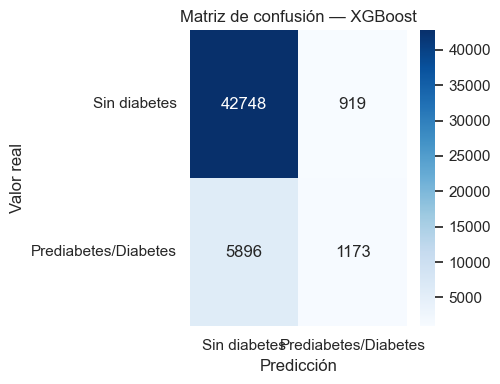

In [52]:
cm_xgb = results_xgb["Matriz Confusión"]

plt.figure(figsize=(5, 4))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión — XGBoost")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks([0.5, 1.5], ["Sin diabetes", "Prediabetes/Diabetes"])
plt.yticks([0.5, 1.5], ["Sin diabetes", "Prediabetes/Diabetes"], rotation=0)
plt.tight_layout()
plt.show()

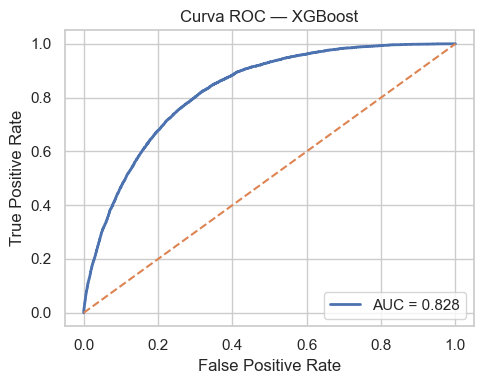

In [53]:
from sklearn.metrics import roc_curve

y_score_xgb = results_xgb["Scores"]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_score_xgb)

plt.figure(figsize=(5, 4))
plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"AUC = {results_xgb['Test AUC']:.3f}",
    linewidth=2
)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Curva ROC — XGBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [54]:
feature_importance_xgb = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": results_xgb["Pipeline"].named_steps["model"].feature_importances_
})

feature_importance_xgb = feature_importance_xgb.sort_values(
    by="Importancia",
    ascending=False
)

display(feature_importance_xgb.head(15))

,Variable,Importancia
7,PhysActivity,0.436736
3,BMI,0.145939
8,Fruits,0.092344
4,Smoker,0.048064
0,HighBP,0.045667
19,Education,0.044701
16,DiffWalk,0.036103
9,Veggies,0.033504
12,NoDocbcCost,0.031715
20,Income,0.016938


In [281]:
!pip install lime

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283917 sha256=f9994cc3a7dd3bd193392d1f81746d1e7aa7ca78013a4c942e780655ae279cec
  Stored in directory: c:\users\danih\appdata\local\pip\cache\wheels\ed\d7\c9\5a0130d06d6310bc6cbe55220e6e72dcb8c4eff9a478717066
Successfully built lime


In [55]:
from lime.lime_tabular import LimeTabularExplainer
import pandas as pd
import numpy as np

# Explainer con datos de entrenamiento en formato numpy
explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=["Sin diabetes", "Prediabetes/Diabetes"],
    mode="classification"
)

# Función wrapper para que LIME entregue un DataFrame al pipeline
def predict_proba_for_lime(x):
    x_df = pd.DataFrame(x, columns=X_train.columns)
    return results_xgb["Pipeline"].predict_proba(x_df)

# Elegir observación
instance_idx = 0

exp = explainer.explain_instance(
    data_row=X_test.iloc[instance_idx].values,
    predict_fn=predict_proba_for_lime,
    num_features=10
)

exp.show_in_notebook(show_table=True)

---
### **SVM**

In [287]:
from sklearn.svm import SVC

results_svm = run_benchmark_classifier(
    model_name="SVM",
    estimator=SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=True,
        random_state=42
    ),
    scale_numeric=True,
    cv=cv_strategy
)

KeyboardInterrupt: 

In [ ]:
svm_summary = pd.DataFrame([{
    "Modelo": results_svm["Modelo"],
    "CV Accuracy": results_svm["CV Accuracy"],
    "CV Precision": results_svm["CV Precision"],
    "CV Recall": results_svm["CV Recall"],
    "CV F1": results_svm["CV F1"],
    "CV AUC": results_svm["CV AUC"],
    "Test Accuracy": results_svm["Test Accuracy"],
    "Test Precision": results_svm["Test Precision"],
    "Test Recall": results_svm["Test Recall"],
    "Test F1": results_svm["Test F1"],
    "Test AUC": results_svm["Test AUC"],
    "Tiempo (s)": results_svm["Tiempo (s)"]
}])

display(svm_summary.round(4))

In [ ]:
print("Reporte de clasificación - SVM")
print(classification_report(y_test, results_svm["Predicciones"], zero_division=0))

In [ ]:
cm_svm = results_svm["Matriz Confusión"]

plt.figure(figsize=(5, 4))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="coolwarm")
plt.title("Matriz de confusión — SVM")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks([0.5, 1.5], ["Sin diabetes", "Prediabetes/Diabetes"])
plt.yticks([0.5, 1.5], ["Sin diabetes", "Prediabetes/Diabetes"], rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import roc_curve

y_score_svm = results_svm["Scores"]
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_score_svm)

plt.figure(figsize=(5, 4))
plt.plot(
    fpr_svm,
    tpr_svm,
    label=f"AUC = {results_svm['Test AUC']:.3f}",
    linewidth=2
)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Curva ROC — SVM")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# **Optimización Integrada**

### **Recall como métrica principal**

Se seleccionó el recall como métrica principal de optimización en todos los métodos de búsqueda de hiperparámetros. El recall mide la proporción de casos positivos reales que el modelo identifica correctamente, es decir, de todos los pacientes que efectivamente tienen diabetes, cuántos detecta el modelo. En el contexto de diagnóstico médico, un falso negativo — clasificar como sano a un paciente diabético — tiene consecuencias clínicas graves: el paciente no recibe tratamiento, la enfermedad avanza sin control y pueden surgir complicaciones severas como neuropatía, retinopatía o enfermedad cardiovascular. Este costo asimétrico entre errores justifica priorizar el recall sobre métricas como accuracy o F1.

## **KKN**

KNN es un algoritmo basado en distancias que no aprende un modelo explícito: en cada predicción recorre todo el conjunto de entrenamiento para encontrar los k vecinos más cercanos. Esto lo hace especialmente sensible al tamaño del dataset — con 202,944 filas, cada evaluación dentro de la validación cruzada puede tardar varios minutos, haciendo que métodos como Grid Search, Random Search, Optuna y DEAP sean computacionalmente prohibitivos en tiempo real. Para resolverlo, se construye una muestra estratificada del 30% del conjunto de entrenamiento, preservando exactamente la proporción original de clases (86% sin diabetes / 14% con diabetes). Esto garantiza que los hiperparámetros se optimicen sobre datos representativos del problema real, manteniendo la validez estadística de los resultados.

In [78]:
from sklearn.utils import resample
 
MUESTRA_PROP = 0.30
 
n_muestra = int(len(X_train) * MUESTRA_PROP)
 
X_train_knn, y_train_knn = resample(
    X_train, y_train,
    n_samples=n_muestra,
    stratify=y_train,
    random_state=RANDOM_STATE
)
 
# Verificación de proporciones
muestra_dist = y_train_knn.value_counts(normalize=True).sort_index() * 100
original_dist = y_train.value_counts(normalize=True).sort_index() * 100
 
resumen_muestra = pd.DataFrame({
    "Clase":          ["Sin diabetes", "Prediabetes/Diabetes"],
    "Original n":     y_train.value_counts().sort_index().values,
    "Original (%)":   original_dist.values.round(2),
    "Muestra n":      y_train_knn.value_counts().sort_index().values,
    "Muestra (%)":    muestra_dist.values.round(2),
})
 
print(f"Tamaño original del train:  {len(X_train):,}")
print(f"Tamaño de la muestra (30%): {len(X_train_knn):,}\n")
display(resumen_muestra)

Tamaño original del train:  202,944
Tamaño de la muestra (30%): 60,883



,Clase,Original n,Original (%),Muestra n,Muestra (%)
0,Sin diabetes,174667,86.07,52400,86.07
1,Prediabetes/Diabetes,28277,13.93,8483,13.93


### **Grid Search**

In [ ]:
resultados_gs_knn = optimizar_gridsearch(
    modelo_nombre="KNN",
    estimator=KNeighborsClassifier(n_jobs=-1),
    param_grid=param_grid_knn,
    X_train=X_train_knn,      
    y_train=y_train_knn,     
    cv=cv_knn,
    escalado=True,
    scoring="recall"
)

Grid Search — KNN — Sin Balanceo

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Tiempo: 266.68s | Mejor recall CV: 0.3885
Mejores params: {'modelo__metric': 'euclidean', 'modelo__n_neighbors': 3, 'modelo__weights': 'distance'}

Grid Search — KNN — SMOTE

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Tiempo: 476.46s | Mejor recall CV: 0.7893
Mejores params: {'modelo__metric': 'euclidean', 'modelo__n_neighbors': 15, 'modelo__weights': 'uniform'}

Grid Search — KNN — ADASYN

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Tiempo: 444.17s | Mejor recall CV: 0.8228
Mejores params: {'modelo__metric': 'euclidean', 'modelo__n_neighbors': 15, 'modelo__weights': 'uniform'}

Grid Search — KNN — Class Weight

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Tiempo: 206.32s | Mejor recall CV: 0.3885
Mejores params: {'modelo__metric': 'euclidean', 'modelo__n_neighbors': 3, 'modelo__weights': 'distance'}



In [49]:
gs_knn_df = pd.DataFrame([
    {
        "Balanceo":                round(res.get("Mejor recall CV", 0), 4),
        "Mejor Recall CV":         round(res.get("Mejor recall CV", 0), 4),
        "Std Recall CV":           round(res.get("Std recall CV", 0), 4),
        "Test Accuracy":           round(res["Test Accuracy"], 4),
        "Test Precision":          round(res["Test Precision"], 4),
        "Test Recall":             round(res["Test Recall"], 4),
        "Test F1":                 round(res["Test F1"], 4),
        "Test ROC AUC":            round(res["Test ROC AUC"], 4),
        "Tiempo (s)":              round(res["Tiempo (s)"], 2),
        "Iteraciones":             res["Iteraciones"],
        "Mejores Hiperparámetros": res["Mejores Hiperparámetros"]
    }
    for tecnica, res in resultados_gs_knn.items()
])
 
# Corregir columna Balanceo
gs_knn_df["Balanceo"] = list(resultados_gs_knn.keys())
 
print("── Resumen Grid Search — KNN ──")
display(gs_knn_df)
 
# Mejor técnica por Recall (prioridad) luego F1
mejor_tecnica_gs_knn = max(
    resultados_gs_knn.items(),
    key=lambda x: (x[1]["Test Recall"], x[1]["Test F1"])
)
 
print(f"\n  ★ Mejor balanceo:  {mejor_tecnica_gs_knn[0]}")
print(f"     Test Recall:    {mejor_tecnica_gs_knn[1]['Test Recall']:.4f}")
print(f"     Test F1:        {mejor_tecnica_gs_knn[1]['Test F1']:.4f}")
print(f"     Test ROC AUC:   {mejor_tecnica_gs_knn[1]['Test ROC AUC']:.4f}")
print(f"     Params:         {mejor_tecnica_gs_knn[1]['Mejores Hiperparámetros']}")

── Resumen Grid Search — KNN ──


,Balanceo,Mejor Recall CV,Std Recall CV,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC AUC,Tiempo (s),Iteraciones,Mejores Hiperparámetros
0,Sin Balanceo,0.3885,0.0020,0.8252,0.3313,0.2498,0.2849,0.6618,266.68,24,"{'modelo__metric': 'euclidean', 'modelo__n_nei..."
1,SMOTE,0.7893,0.0050,0.6805,0.2654,0.7314,0.3894,0.7607,476.46,24,"{'modelo__metric': 'euclidean', 'modelo__n_nei..."
2,ADASYN,0.8228,0.0035,0.6566,0.2542,0.7577,0.3807,0.7555,444.17,24,"{'modelo__metric': 'euclidean', 'modelo__n_nei..."
3,Class Weight,0.3885,0.0020,0.8252,0.3313,0.2498,0.2849,0.6618,206.32,24,"{'modelo__metric': 'euclidean', 'modelo__n_nei..."



  ★ Mejor balanceo:  ADASYN
     Test Recall:    0.7577
     Test F1:        0.3807
     Test ROC AUC:   0.7555
     Params:         {'modelo__metric': 'euclidean', 'modelo__n_neighbors': 15, 'modelo__weights': 'uniform'}


### **Random Search**

In [50]:
param_dist_knn = {
    "modelo__n_neighbors": list(range(3, 22, 2)),   
    "modelo__weights":     ["uniform", "distance"],
    "modelo__metric":      ["euclidean", "manhattan", "minkowski"]
}
 
resultados_rs_knn = optimizar_randomsearch(
    modelo_nombre="KNN",
    estimator=KNeighborsClassifier(n_jobs=-1),
    param_distributions=param_dist_knn,
    X_train=X_train_knn,      
    y_train=y_train_knn,      
    cv=cv_knn,
    escalado=True,
    scoring="recall",
    n_iter=30
)

Random Search — KNN — Sin Balanceo

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Tiempo: 235.53s | Mejor recall CV: 0.3618
Mejores params: {'modelo__weights': 'distance', 'modelo__n_neighbors': 5, 'modelo__metric': 'euclidean'}

Random Search — KNN — SMOTE

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Tiempo: 365.46s | Mejor recall CV: 0.8093
Mejores params: {'modelo__weights': 'distance', 'modelo__n_neighbors': 21, 'modelo__metric': 'euclidean'}

Random Search — KNN — ADASYN

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Tiempo: 519.63s | Mejor recall CV: 0.8389
Mejores params: {'modelo__weights': 'uniform', 'modelo__n_neighbors': 21, 'modelo__metric': 'minkowski'}

Random Search — KNN — Class Weight

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Tiempo: 177.47s | Mejor recall CV: 0.3618
Mejores params: {'modelo__weights': 'distance', 'modelo__n_neighbors': 5, 'modelo__metric': 'euclidean'}



In [51]:
rs_knn_df = pd.DataFrame([
    {
        "Balanceo":                tecnica,
        "Mejor Recall CV":         round(res["Mejor recall CV"], 4),
        "Std Recall CV":           round(res["Std recall CV"], 4),
        "Test Accuracy":           round(res["Test Accuracy"], 4),
        "Test Precision":          round(res["Test Precision"], 4),
        "Test Recall":             round(res["Test Recall"], 4),
        "Test F1":                 round(res["Test F1"], 4),
        "Test ROC AUC":            round(res["Test ROC AUC"], 4),
        "Tiempo (s)":              round(res["Tiempo (s)"], 2),
        "Iteraciones":             res["Iteraciones"],
        "Mejores Hiperparámetros": res["Mejores Hiperparámetros"]
    }
    for tecnica, res in resultados_rs_knn.items()
])
 
print("── Resumen Random Search — KNN ──")
display(rs_knn_df)
 
mejor_tecnica_rs_knn = max(
    resultados_rs_knn.items(),
    key=lambda x: (x[1]["Test Recall"], x[1]["Test F1"])
)
 
print(f"\n  ★ Mejor balanceo:  {mejor_tecnica_rs_knn[0]}")
print(f"     Test Recall:    {mejor_tecnica_rs_knn[1]['Test Recall']:.4f}")
print(f"     Test F1:        {mejor_tecnica_rs_knn[1]['Test F1']:.4f}")
print(f"     Test ROC AUC:   {mejor_tecnica_rs_knn[1]['Test ROC AUC']:.4f}")
print(f"     Params:         {mejor_tecnica_rs_knn[1]['Mejores Hiperparámetros']}")

── Resumen Random Search — KNN ──


,Balanceo,Mejor Recall CV,Std Recall CV,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC AUC,Tiempo (s),Iteraciones,Mejores Hiperparámetros
0,Sin Balanceo,0.3618,0.0011,0.8391,0.3685,0.2164,0.2727,0.7014,235.53,30,"{'modelo__weights': 'distance', 'modelo__n_nei..."
1,SMOTE,0.8093,0.0035,0.6837,0.2692,0.7407,0.3948,0.7689,365.46,30,"{'modelo__weights': 'distance', 'modelo__n_nei..."
2,ADASYN,0.8389,0.0044,0.6484,0.2535,0.7831,0.3830,0.7660,519.63,30,"{'modelo__weights': 'uniform', 'modelo__n_neig..."
3,Class Weight,0.3618,0.0011,0.8391,0.3685,0.2164,0.2727,0.7014,177.47,30,"{'modelo__weights': 'distance', 'modelo__n_nei..."



  ★ Mejor balanceo:  ADASYN
     Test Recall:    0.7831
     Test F1:        0.3830
     Test ROC AUC:   0.7660
     Params:         {'modelo__weights': 'uniform', 'modelo__n_neighbors': 21, 'modelo__metric': 'minkowski'}


### **Optuna**

In [52]:
def knn_factory(params):
    return KNeighborsClassifier(
        n_neighbors=params["n_neighbors"],
        weights=params["weights"],
        metric=params["metric"],
        n_jobs=-1
    )
 
resultados_op_knn = optimizar_optuna(
    modelo_nombre="KNN",
    estimator=KNeighborsClassifier(),   # solo para identificar el tipo
    model_factory=knn_factory,
    X_train=X_train_knn,                # muestra 30%
    y_train=y_train_knn,                # muestra 30%
    cv=cv_knn,
    escalado=True,
    n_trials=30,
    scoring="recall"
)


Optuna — KNN — Sin Balanceo


  0%|          | 0/30 [00:00<?, ?it/s]


Tiempo: 293.08s | Mejor recall CV: 0.3885
Mejores params: {'n_neighbors': 3, 'weights': 'distance', 'metric': 'euclidean'}


Optuna — KNN — SMOTE


  0%|          | 0/30 [00:00<?, ?it/s]


Tiempo: 455.58s | Mejor recall CV: 0.8260
Mejores params: {'n_neighbors': 29, 'weights': 'distance', 'metric': 'minkowski'}


Optuna — KNN — ADASYN


  0%|          | 0/30 [00:00<?, ?it/s]


Tiempo: 465.09s | Mejor recall CV: 0.8518
Mejores params: {'n_neighbors': 29, 'weights': 'distance', 'metric': 'minkowski'}


Optuna — KNN — Class Weight


  0%|          | 0/30 [00:00<?, ?it/s]


Tiempo: 218.00s | Mejor recall CV: 0.3885
Mejores params: {'n_neighbors': 3, 'weights': 'distance', 'metric': 'euclidean'}



In [53]:
op_knn_df = pd.DataFrame([
    {
        "Balanceo":                tecnica,
        "Mejor Recall CV":         round(res["Mejor recall CV"], 4),
        "Test Accuracy":           round(res["Test Accuracy"], 4),
        "Test Precision":          round(res["Test Precision"], 4),
        "Test Recall":             round(res["Test Recall"], 4),
        "Test F1":                 round(res["Test F1"], 4),
        "Test ROC AUC":            round(res["Test ROC AUC"], 4),
        "Tiempo (s)":              round(res["Tiempo (s)"], 2),
        "Iteraciones":             res["Iteraciones"],
        "Mejores Hiperparámetros": res["Mejores Hiperparámetros"]
    }
    for tecnica, res in resultados_op_knn.items()
])
 
print("── Resumen Optuna — KNN ──")
display(op_knn_df)
 
mejor_tecnica_op_knn = max(
    resultados_op_knn.items(),
    key=lambda x: (x[1]["Test Recall"], x[1]["Test F1"])
)
 
print(f"\n  ★ Mejor balanceo:  {mejor_tecnica_op_knn[0]}")
print(f"     Test Recall:    {mejor_tecnica_op_knn[1]['Test Recall']:.4f}")
print(f"     Test F1:        {mejor_tecnica_op_knn[1]['Test F1']:.4f}")
print(f"     Test ROC AUC:   {mejor_tecnica_op_knn[1]['Test ROC AUC']:.4f}")
print(f"     Params:         {mejor_tecnica_op_knn[1]['Mejores Hiperparámetros']}")

── Resumen Optuna — KNN ──


,Balanceo,Mejor Recall CV,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC AUC,Tiempo (s),Iteraciones,Mejores Hiperparámetros
0,Sin Balanceo,0.3885,0.8252,0.3313,0.2498,0.2849,0.6618,293.08,30,"{'n_neighbors': 3, 'weights': 'distance', 'met..."
1,SMOTE,0.8260,0.6784,0.2688,0.7604,0.3972,0.7763,455.58,30,"{'n_neighbors': 29, 'weights': 'distance', 'me..."
2,ADASYN,0.8518,0.6556,0.2586,0.7885,0.3895,0.7711,465.09,30,"{'n_neighbors': 29, 'weights': 'distance', 'me..."
3,Class Weight,0.3885,0.8252,0.3313,0.2498,0.2849,0.6618,218.00,30,"{'n_neighbors': 3, 'weights': 'distance', 'met..."



  ★ Mejor balanceo:  ADASYN
     Test Recall:    0.7885
     Test F1:        0.3895
     Test ROC AUC:   0.7711
     Params:         {'n_neighbors': 29, 'weights': 'distance', 'metric': 'minkowski'}


### **DEAP**

In [57]:
espacio_knn = {
    "n_neighbors": list(range(3, 22, 2)),   # [3, 5, 7, ..., 21]
    "weights":     ["uniform", "distance"],
    "metric":      ["euclidean", "manhattan", "minkowski"]
}
 
resultados_deap_knn = optimizar_deap(
    modelo_nombre="KNN",
    estimator=KNeighborsClassifier(),       # referencia de tipo
    model_factory=knn_factory,              # misma factory de Optuna
    espacio=espacio_knn,
    X_train=X_train_knn,                    # muestra 30%
    y_train=y_train_knn,                    # muestra 30%
    cv=cv_knn,
    escalado=True,
    n_generaciones=5,
    tam_poblacion=20,
    scoring="recall"
)


DEAP — KNN — Sin Balanceo
  Gen 01/5 | Max recall: 0.3618 | Mean: 0.2192 | Min: 0.1213
  Gen 02/5 | Max recall: 0.3885 | Mean: 0.3035 | Min: 0.1270
  Gen 03/5 | Max recall: 0.3885 | Mean: 0.3296 | Min: 0.2391
  Gen 04/5 | Max recall: 0.3885 | Mean: 0.3436 | Min: 0.1820
  Gen 05/5 | Max recall: 0.3885 | Mean: 0.3610 | Min: 0.3265

  Tiempo: 902.26s | Mejor recall CV: 0.3885
  Mejores params: {'n_neighbors': 3, 'weights': 'distance', 'metric': 'euclidean'}


DEAP — KNN — SMOTE
  Gen 01/5 | Max recall: 0.8093 | Mean: 0.7367 | Min: 0.5905
  Gen 02/5 | Max recall: 0.8093 | Mean: 0.7674 | Min: 0.6315
  Gen 03/5 | Max recall: 0.8060 | Mean: 0.7853 | Min: 0.6415
  Gen 04/5 | Max recall: 0.8060 | Mean: 0.8007 | Min: 0.7601
  Gen 05/5 | Max recall: 0.8093 | Mean: 0.7986 | Min: 0.6733

  Tiempo: 1579.81s | Mejor recall CV: 0.8093
  Mejores params: {'n_neighbors': 21, 'weights': 'distance', 'metric': 'minkowski'}


DEAP — KNN — ADASYN
  Gen 01/5 | Max recall: 0.8352 | Mean: 0.7582 | Min: 0.5978
 

In [58]:
deap_knn_df = pd.DataFrame([
    {
        "Balanceo":                tecnica,
        "Mejor Recall CV":         round(res["Mejor recall CV"], 4),
        "Std Recall CV":           round(res["Std recall CV"], 4),
        "Test Accuracy":           round(res["Test Accuracy"], 4),
        "Test Precision":          round(res["Test Precision"], 4),
        "Test Recall":             round(res["Test Recall"], 4),
        "Test F1":                 round(res["Test F1"], 4),
        "Test ROC AUC":            round(res["Test ROC AUC"], 4),
        "Tiempo (s)":              round(res["Tiempo (s)"], 2),
        "Iteraciones":             res["Iteraciones"],
        "Mejores Hiperparámetros": res["Mejores Hiperparámetros"]
    }
    for tecnica, res in resultados_deap_knn.items()
])
 
print("── Resumen DEAP — KNN ──")
display(deap_knn_df)
 
mejor_tecnica_deap_knn = max(
    resultados_deap_knn.items(),
    key=lambda x: (x[1]["Test Recall"], x[1]["Test F1"])
)
 
print(f"\n  ★ Mejor balanceo:  {mejor_tecnica_deap_knn[0]}")
print(f"     Test Recall:    {mejor_tecnica_deap_knn[1]['Test Recall']:.4f}")
print(f"     Test F1:        {mejor_tecnica_deap_knn[1]['Test F1']:.4f}")
print(f"     Test ROC AUC:   {mejor_tecnica_deap_knn[1]['Test ROC AUC']:.4f}")
print(f"     Params:         {mejor_tecnica_deap_knn[1]['Mejores Hiperparámetros']}")
 

── Resumen DEAP — KNN ──


,Balanceo,Mejor Recall CV,Std Recall CV,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC AUC,Tiempo (s),Iteraciones,Mejores Hiperparámetros
0,Sin Balanceo,0.3885,0.0107,0.8252,0.3313,0.2498,0.2849,0.6618,902.26,100,"{'n_neighbors': 3, 'weights': 'distance', 'met..."
1,SMOTE,0.8093,0.0016,0.6837,0.2692,0.7407,0.3948,0.7689,1579.81,100,"{'n_neighbors': 21, 'weights': 'distance', 'me..."
2,ADASYN,0.8389,0.0018,0.6484,0.2535,0.7831,0.3830,0.7660,2080.24,100,"{'n_neighbors': 21, 'weights': 'uniform', 'met..."
3,Class Weight,0.3885,0.0107,0.8252,0.3313,0.2498,0.2849,0.6618,1470.20,100,"{'n_neighbors': 3, 'weights': 'distance', 'met..."



  ★ Mejor balanceo:  ADASYN
     Test Recall:    0.7831
     Test F1:        0.3830
     Test ROC AUC:   0.7660
     Params:         {'n_neighbors': 21, 'weights': 'uniform', 'metric': 'minkowski'}


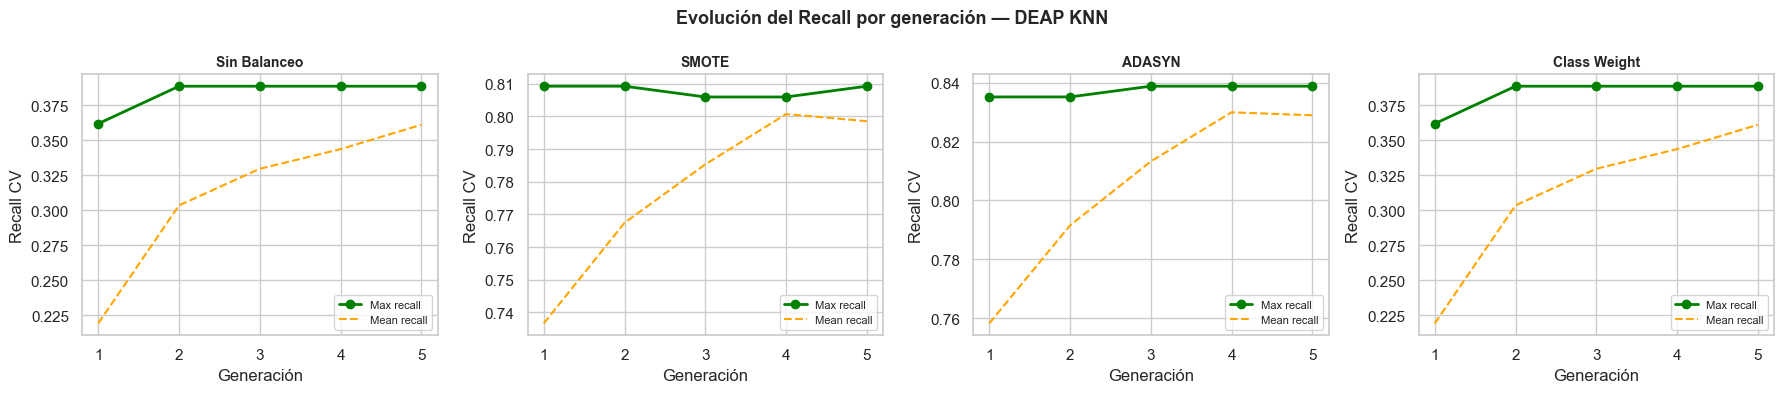

In [99]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
 
for ax, (tecnica, res) in zip(axes, resultados_deap_knn.items()):
    historia = res["Historia"]
    gens     = list(range(1, len(historia) + 1))
    maximos  = [g["max"]  for g in historia]
    medios   = [g["mean"] for g in historia]
 
    ax.plot(gens, maximos, color="green",  linewidth=2, marker="o", label="Max recall")
    ax.plot(gens, medios,  color="orange", linewidth=1.5, linestyle="--", label="Mean recall")
    ax.set_title(tecnica, fontsize=10, fontweight="bold")
    ax.set_xlabel("Generación")
    ax.set_ylabel("Recall CV")
    ax.legend(fontsize=8)
    ax.set_xticks(gens)
 
plt.suptitle("Evolución del Recall por generación — DEAP KNN",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [66]:
mejor_gs   = max(resultados_gs_knn.items(),
                 key=lambda x: (x[1]["Test Recall"], x[1]["Test F1"]))
mejor_rs   = max(resultados_rs_knn.items(),
                 key=lambda x: (x[1]["Test Recall"], x[1]["Test F1"]))
mejor_op   = max(resultados_op_knn.items(),
                 key=lambda x: (x[1]["Test Recall"], x[1]["Test F1"]))
mejor_deap = mejor_tecnica_deap_knn
 
comparacion_final_knn = pd.DataFrame([
    {
        "Método":         "Benchmark",
        "Balanceo":       "—",
        "Test Precision": round(results_knn["Test Precision"], 4),
        "Test Recall":    round(results_knn["Test Recall"], 4),
        "Test F1":        round(results_knn["Test F1"], 4),
        "Test ROC AUC":   round(results_knn["Test AUC"], 4),
    },
    {
        "Método":         "Grid Search",
        "Balanceo":       mejor_gs[0],
        "Test Precision": round(mejor_gs[1]["Test Precision"], 4),
        "Test Recall":    round(mejor_gs[1]["Test Recall"], 4),
        "Test F1":        round(mejor_gs[1]["Test F1"], 4),
        "Test ROC AUC":   round(mejor_gs[1]["Test ROC AUC"], 4),
    },
    {
        "Método":         "Random Search",
        "Balanceo":       mejor_rs[0],
        "Test Precision": round(mejor_rs[1]["Test Precision"], 4),
        "Test Recall":    round(mejor_rs[1]["Test Recall"], 4),
        "Test F1":        round(mejor_rs[1]["Test F1"], 4),
        "Test ROC AUC":   round(mejor_rs[1]["Test ROC AUC"], 4),
    },
    {
        "Método":         "Optuna",
        "Balanceo":       mejor_op[0],
        "Test Precision": round(mejor_op[1]["Test Precision"], 4),
        "Test Recall":    round(mejor_op[1]["Test Recall"], 4),
        "Test F1":        round(mejor_op[1]["Test F1"], 4),
        "Test ROC AUC":   round(mejor_op[1]["Test ROC AUC"], 4),
    },
    {
        "Método":         "DEAP",
        "Balanceo":       mejor_deap[0],
        "Test Precision": round(mejor_deap[1]["Test Precision"], 4),
        "Test Recall":    round(mejor_deap[1]["Test Recall"], 4),
        "Test F1":        round(mejor_deap[1]["Test F1"], 4),
        "Test ROC AUC":   round(mejor_deap[1]["Test ROC AUC"], 4),
    }
])
 
print("── Comparación final — KNN: todos los métodos ──")
display(comparacion_final_knn)

── Comparación final — KNN: todos los métodos ──


,Método,Balanceo,Test Precision,Test Recall,Test F1,Test ROC AUC
0,Benchmark,—,0.3725,0.2355,0.2886,0.6812
1,Grid Search,ADASYN,0.2542,0.7577,0.3807,0.7555
2,Random Search,ADASYN,0.2535,0.7831,0.3830,0.7660
3,Optuna,ADASYN,0.2586,0.7885,0.3895,0.7711
4,DEAP,ADASYN,0.2535,0.7831,0.3830,0.7660


## **Clasificación Naïve Bayes**

### **Grid Search**

In [65]:
param_grid_gnb = {
    "modelo__var_smoothing": [1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6]
}
 
resultados_gs_gnb = optimizar_gridsearch(
    modelo_nombre="GaussianNB",
    estimator=GaussianNB(),
    param_grid=param_grid_gnb,
    X_train=X_train,          
    y_train=y_train,          
    cv=cv_strategy,
    escalado=True,
    scoring="recall"
)

Grid Search — GaussianNB — Sin Balanceo

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Tiempo: 7.23s | Mejor recall CV: 0.5720
Mejores params: {'modelo__var_smoothing': 1e-11}

Grid Search — GaussianNB — SMOTE

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Tiempo: 89.37s | Mejor recall CV: 0.7886
Mejores params: {'modelo__var_smoothing': 1e-11}

Grid Search — GaussianNB — ADASYN

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Tiempo: 270.77s | Mejor recall CV: 0.8193
Mejores params: {'modelo__var_smoothing': 1e-11}

Grid Search — GaussianNB — Class Weight

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Tiempo: 3.75s | Mejor recall CV: 0.5720
Mejores params: {'modelo__var_smoothing': 1e-11}



In [67]:
gs_gnb_df = pd.DataFrame([
    {
        "Balanceo":                tecnica,
        "Mejor Recall CV":         round(res["Mejor recall CV"], 4),
        "Std Recall CV":           round(res["Std recall CV"], 4),
        "Test Accuracy":           round(res["Test Accuracy"], 4),
        "Test Precision":          round(res["Test Precision"], 4),
        "Test Recall":             round(res["Test Recall"], 4),
        "Test F1":                 round(res["Test F1"], 4),
        "Test ROC AUC":            round(res["Test ROC AUC"], 4),
        "Tiempo (s)":              round(res["Tiempo (s)"], 2),
        "Iteraciones":             res["Iteraciones"],
        "Mejores Hiperparámetros": res["Mejores Hiperparámetros"]
    }
    for tecnica, res in resultados_gs_gnb.items()
])
 
print("── Resumen Grid Search — Gaussian Naive Bayes ──")
display(gs_gnb_df)
 
mejor_tecnica_gs_gnb = max(
    resultados_gs_gnb.items(),
    key=lambda x: (x[1]["Test Recall"], x[1]["Test F1"])
)
 
print(f"\n  ★ Mejor balanceo:  {mejor_tecnica_gs_gnb[0]}")
print(f"     Test Recall:    {mejor_tecnica_gs_gnb[1]['Test Recall']:.4f}")
print(f"     Test F1:        {mejor_tecnica_gs_gnb[1]['Test F1']:.4f}")
print(f"     Test ROC AUC:   {mejor_tecnica_gs_gnb[1]['Test ROC AUC']:.4f}")
print(f"     Params:         {mejor_tecnica_gs_gnb[1]['Mejores Hiperparámetros']}")
 

── Resumen Grid Search — Gaussian Naive Bayes ──


,Balanceo,Mejor Recall CV,Std Recall CV,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC AUC,Tiempo (s),Iteraciones,Mejores Hiperparámetros
0,Sin Balanceo,0.5720,0.0043,0.7722,0.3198,0.5639,0.4082,0.7803,7.23,6,{'modelo__var_smoothing': 1e-11}
1,SMOTE,0.7886,0.0036,0.6749,0.2696,0.7800,0.4007,0.7730,89.37,6,{'modelo__var_smoothing': 1e-11}
2,ADASYN,0.8193,0.0022,0.6491,0.2577,0.8072,0.3906,0.7723,270.77,6,{'modelo__var_smoothing': 1e-11}
3,Class Weight,0.5720,0.0043,0.7722,0.3198,0.5639,0.4082,0.7803,3.75,6,{'modelo__var_smoothing': 1e-11}



  ★ Mejor balanceo:  ADASYN
     Test Recall:    0.8072
     Test F1:        0.3906
     Test ROC AUC:   0.7723
     Params:         {'modelo__var_smoothing': 1e-11}


### **Random Search**

In [68]:
param_dist_gnb = {
    "modelo__var_smoothing": np.logspace(-11, -6, 50).tolist()
}

resultados_rs_gnb = optimizar_randomsearch(
    modelo_nombre="GaussianNB",
    estimator=GaussianNB(),
    param_distributions=param_dist_gnb,
    X_train=X_train,
    y_train=y_train,
    cv=cv_strategy,
    escalado=True,
    scoring="recall",
    n_iter=20
)

Random Search — GaussianNB — Sin Balanceo

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Tiempo: 13.58s | Mejor recall CV: 0.5720
Mejores params: {'modelo__var_smoothing': 2.1209508879201926e-10}

Random Search — GaussianNB — SMOTE

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Tiempo: 122.85s | Mejor recall CV: 0.7886
Mejores params: {'modelo__var_smoothing': 2.1209508879201926e-10}

Random Search — GaussianNB — ADASYN

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Tiempo: 783.58s | Mejor recall CV: 0.8193
Mejores params: {'modelo__var_smoothing': 2.1209508879201926e-10}

Random Search — GaussianNB — Class Weight

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Tiempo: 11.95s | Mejor recall CV: 0.5720
Mejores params: {'modelo__var_smoothing': 2.1209508879201926e-10}



In [69]:
rs_gnb_df = pd.DataFrame([
    {
        "Balanceo":                tecnica,
        "Mejor Recall CV":         round(res["Mejor recall CV"], 4),
        "Std Recall CV":           round(res["Std recall CV"], 4),
        "Test Accuracy":           round(res["Test Accuracy"], 4),
        "Test Precision":          round(res["Test Precision"], 4),
        "Test Recall":             round(res["Test Recall"], 4),
        "Test F1":                 round(res["Test F1"], 4),
        "Test ROC AUC":            round(res["Test ROC AUC"], 4),
        "Tiempo (s)":              round(res["Tiempo (s)"], 2),
        "Iteraciones":             res["Iteraciones"],
        "Mejores Hiperparámetros": res["Mejores Hiperparámetros"]
    }
    for tecnica, res in resultados_rs_gnb.items()
])

print("── Resumen Random Search — Gaussian Naive Bayes ──")
display(rs_gnb_df)

mejor_tecnica_rs_gnb = max(
    resultados_rs_gnb.items(),
    key=lambda x: (x[1]["Test Recall"], x[1]["Test F1"])
)

print(f"\n  ★ Mejor balanceo:  {mejor_tecnica_rs_gnb[0]}")
print(f"     Test Recall:    {mejor_tecnica_rs_gnb[1]['Test Recall']:.4f}")
print(f"     Test F1:        {mejor_tecnica_rs_gnb[1]['Test F1']:.4f}")
print(f"     Test ROC AUC:   {mejor_tecnica_rs_gnb[1]['Test ROC AUC']:.4f}")
print(f"     Params:         {mejor_tecnica_rs_gnb[1]['Mejores Hiperparámetros']}")

── Resumen Random Search — Gaussian Naive Bayes ──


,Balanceo,Mejor Recall CV,Std Recall CV,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC AUC,Tiempo (s),Iteraciones,Mejores Hiperparámetros
0,Sin Balanceo,0.5720,0.0043,0.7722,0.3198,0.5639,0.4082,0.7803,13.58,20,{'modelo__var_smoothing': 2.1209508879201926e-10}
1,SMOTE,0.7886,0.0036,0.6749,0.2696,0.7800,0.4007,0.7730,122.85,20,{'modelo__var_smoothing': 2.1209508879201926e-10}
2,ADASYN,0.8193,0.0022,0.6491,0.2577,0.8072,0.3906,0.7723,783.58,20,{'modelo__var_smoothing': 2.1209508879201926e-10}
3,Class Weight,0.5720,0.0043,0.7722,0.3198,0.5639,0.4082,0.7803,11.95,20,{'modelo__var_smoothing': 2.1209508879201926e-10}



  ★ Mejor balanceo:  ADASYN
     Test Recall:    0.8072
     Test F1:        0.3906
     Test ROC AUC:   0.7723
     Params:         {'modelo__var_smoothing': 2.1209508879201926e-10}


### **Optuna**

In [70]:
def gnb_factory(params):
    return GaussianNB(var_smoothing=params["var_smoothing"])

resultados_op_gnb = optimizar_optuna(
    modelo_nombre="GaussianNB",
    estimator=GaussianNB(),
    model_factory=gnb_factory,
    X_train=X_train,
    y_train=y_train,
    cv=cv_strategy,
    escalado=True,
    n_trials=30,
    scoring="recall"
)


Optuna — GaussianNB — Sin Balanceo


  0%|          | 0/30 [00:00<?, ?it/s]


Tiempo: 49.44s | Mejor recall CV: 0.5720
Mejores params: {'var_smoothing': 3.148911647956852e-10}


Optuna — GaussianNB — SMOTE


  0%|          | 0/30 [00:00<?, ?it/s]


Tiempo: 285.61s | Mejor recall CV: 0.7886
Mejores params: {'var_smoothing': 3.148911647956852e-10}


Optuna — GaussianNB — ADASYN


  0%|          | 0/30 [00:00<?, ?it/s]


Tiempo: 1348.51s | Mejor recall CV: 0.8193
Mejores params: {'var_smoothing': 3.148911647956852e-10}


Optuna — GaussianNB — Class Weight


  0%|          | 0/30 [00:00<?, ?it/s]


Tiempo: 35.65s | Mejor recall CV: 0.5720
Mejores params: {'var_smoothing': 3.148911647956852e-10}



In [71]:
op_gnb_df = pd.DataFrame([
    {
        "Balanceo":                tecnica,
        "Mejor Recall CV":         round(res["Mejor recall CV"], 4),
        "Test Accuracy":           round(res["Test Accuracy"], 4),
        "Test Precision":          round(res["Test Precision"], 4),
        "Test Recall":             round(res["Test Recall"], 4),
        "Test F1":                 round(res["Test F1"], 4),
        "Test ROC AUC":            round(res["Test ROC AUC"], 4),
        "Tiempo (s)":              round(res["Tiempo (s)"], 2),
        "Iteraciones":             res["Iteraciones"],
        "Mejores Hiperparámetros": res["Mejores Hiperparámetros"]
    }
    for tecnica, res in resultados_op_gnb.items()
])

print("── Resumen Optuna — Gaussian Naive Bayes ──")
display(op_gnb_df)

mejor_tecnica_op_gnb = max(
    resultados_op_gnb.items(),
    key=lambda x: (x[1]["Test Recall"], x[1]["Test F1"])
)

print(f"\n  ★ Mejor balanceo:  {mejor_tecnica_op_gnb[0]}")
print(f"     Test Recall:    {mejor_tecnica_op_gnb[1]['Test Recall']:.4f}")
print(f"     Test F1:        {mejor_tecnica_op_gnb[1]['Test F1']:.4f}")
print(f"     Test ROC AUC:   {mejor_tecnica_op_gnb[1]['Test ROC AUC']:.4f}")
print(f"     Params:         {mejor_tecnica_op_gnb[1]['Mejores Hiperparámetros']}")

── Resumen Optuna — Gaussian Naive Bayes ──


,Balanceo,Mejor Recall CV,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC AUC,Tiempo (s),Iteraciones,Mejores Hiperparámetros
0,Sin Balanceo,0.5720,0.7722,0.3198,0.5639,0.4082,0.7803,49.44,30,{'var_smoothing': 3.148911647956852e-10}
1,SMOTE,0.7886,0.6749,0.2696,0.7800,0.4007,0.7730,285.61,30,{'var_smoothing': 3.148911647956852e-10}
2,ADASYN,0.8193,0.6491,0.2577,0.8072,0.3906,0.7723,1348.51,30,{'var_smoothing': 3.148911647956852e-10}
3,Class Weight,0.5720,0.7722,0.3198,0.5639,0.4082,0.7803,35.65,30,{'var_smoothing': 3.148911647956852e-10}



  ★ Mejor balanceo:  ADASYN
     Test Recall:    0.8072
     Test F1:        0.3906
     Test ROC AUC:   0.7723
     Params:         {'var_smoothing': 3.148911647956852e-10}


### **DEAP**

In [85]:
espacio_gnb = {
    "var_smoothing": np.logspace(-11, -6, 30).tolist()
}

resultados_deap_gnb = optimizar_deap(
    modelo_nombre="GaussianNB",
    estimator=GaussianNB(),
    model_factory=gnb_factory,
    espacio=espacio_gnb,
    X_train=X_train,
    y_train=y_train,
    cv=cv_strategy,
    escalado=True,
    n_generaciones=5,
    tam_poblacion=20,
    scoring="recall"
)


DEAP — GaussianNB — Sin Balanceo
  Gen 01/5 | Max recall: 0.5720 | Mean: 0.5720 | Min: 0.5720
  Gen 02/5 | Max recall: 0.5720 | Mean: 0.5720 | Min: 0.5720
  Gen 03/5 | Max recall: 0.5720 | Mean: 0.5720 | Min: 0.5720
  Gen 04/5 | Max recall: 0.5720 | Mean: 0.5720 | Min: 0.5720
  Gen 05/5 | Max recall: 0.5720 | Mean: 0.5720 | Min: 0.5720

  Tiempo: 120.06s | Mejor recall CV: 0.5720
  Mejores params: {'var_smoothing': 2.8072162039411815e-08}


DEAP — GaussianNB — SMOTE
  Gen 01/5 | Max recall: 0.7886 | Mean: 0.7886 | Min: 0.7886
  Gen 02/5 | Max recall: 0.7886 | Mean: 0.7886 | Min: 0.7886
  Gen 03/5 | Max recall: 0.7886 | Mean: 0.7886 | Min: 0.7886
  Gen 04/5 | Max recall: 0.7886 | Mean: 0.7886 | Min: 0.7886
  Gen 05/5 | Max recall: 0.7886 | Mean: 0.7886 | Min: 0.7886

  Tiempo: 797.70s | Mejor recall CV: 0.7886
  Mejores params: {'var_smoothing': 2.8072162039411815e-08}


DEAP — GaussianNB — ADASYN
  Gen 01/5 | Max recall: 0.8193 | Mean: 0.8193 | Min: 0.8193
  Gen 02/5 | Max recall: 0.8

In [87]:
deap_gnb_df = pd.DataFrame([
    {
        "Balanceo":                tecnica,
        "Mejor Recall CV":         round(res["Mejor recall CV"], 4),
        "Std Recall CV":           round(res["Std recall CV"], 4),
        "Test Accuracy":           round(res["Test Accuracy"], 4),
        "Test Precision":          round(res["Test Precision"], 4),
        "Test Recall":             round(res["Test Recall"], 4),
        "Test F1":                 round(res["Test F1"], 4),
        "Test ROC AUC":            round(res["Test ROC AUC"], 4),
        "Tiempo (s)":              round(res["Tiempo (s)"], 2),
        "Iteraciones":             res["Iteraciones"],
        "Mejores Hiperparámetros": res["Mejores Hiperparámetros"]
    }
    for tecnica, res in resultados_deap_gnb.items()
])

print("── Resumen DEAP — Gaussian Naive Bayes ──")
display(deap_gnb_df)

mejor_tecnica_deap_gnb = max(
    resultados_deap_gnb.items(),
    key=lambda x: (x[1]["Test Recall"], x[1]["Test F1"])
)

print(f"\n  ★ Mejor balanceo:  {mejor_tecnica_deap_gnb[0]}")
print(f"     Test Recall:    {mejor_tecnica_deap_gnb[1]['Test Recall']:.4f}")
print(f"     Test F1:        {mejor_tecnica_deap_gnb[1]['Test F1']:.4f}")
print(f"     Test ROC AUC:   {mejor_tecnica_deap_gnb[1]['Test ROC AUC']:.4f}")
print(f"     Params:         {mejor_tecnica_deap_gnb[1]['Mejores Hiperparámetros']}")

── Resumen DEAP — Gaussian Naive Bayes ──


,Balanceo,Mejor Recall CV,Std Recall CV,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC AUC,Tiempo (s),Iteraciones,Mejores Hiperparámetros
0,Sin Balanceo,0.5720,0.0,0.7722,0.3198,0.5639,0.4082,0.7803,120.06,100,{'var_smoothing': 2.8072162039411815e-08}
1,SMOTE,0.7886,0.0,0.6749,0.2696,0.7800,0.4007,0.7730,797.70,100,{'var_smoothing': 2.8072162039411815e-08}
2,ADASYN,0.8193,0.0,0.6491,0.2577,0.8072,0.3906,0.7723,5296.93,100,{'var_smoothing': 2.8072162039411815e-08}
3,Class Weight,0.5720,0.0,0.7722,0.3198,0.5639,0.4082,0.7803,105.25,100,{'var_smoothing': 2.8072162039411815e-08}



  ★ Mejor balanceo:  ADASYN
     Test Recall:    0.8072
     Test F1:        0.3906
     Test ROC AUC:   0.7723
     Params:         {'var_smoothing': 2.8072162039411815e-08}


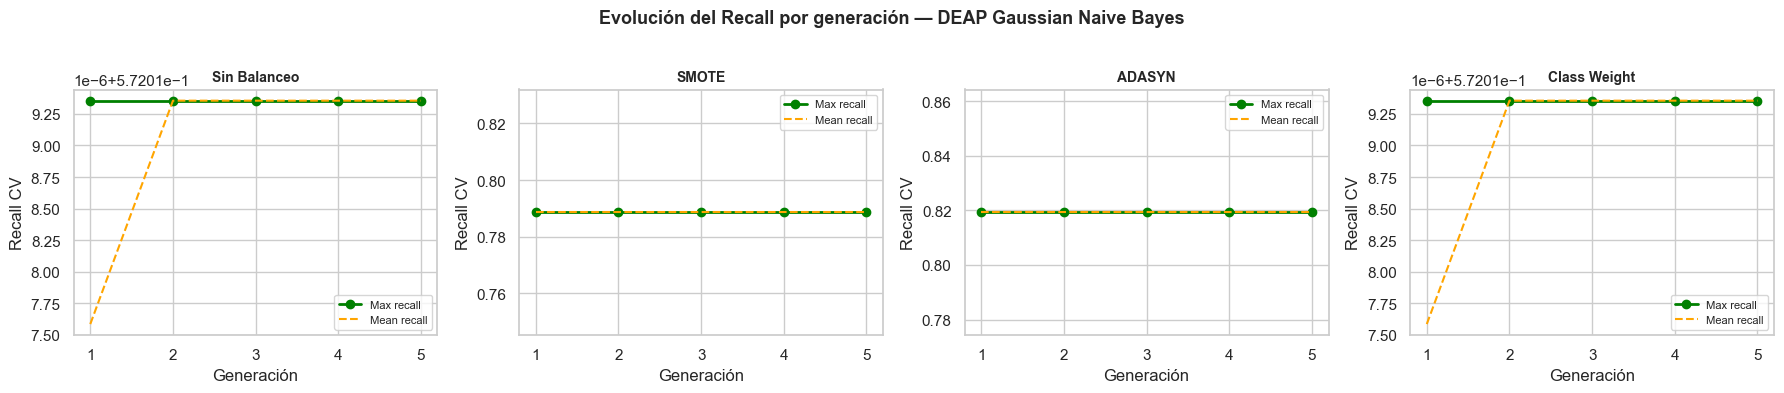

In [98]:
# Evolución del recall por generación y técnica
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (tecnica, res) in zip(axes, resultados_deap_gnb.items()):
    historia = res["Historia"]
    gens     = list(range(1, len(historia) + 1))
    maximos  = [g["max"]  for g in historia]
    medios   = [g["mean"] for g in historia]

    ax.plot(gens, maximos, color="green",  linewidth=2, marker="o", label="Max recall")
    ax.plot(gens, medios,  color="orange", linewidth=1.5, linestyle="--", label="Mean recall")
    ax.set_title(tecnica, fontsize=10, fontweight="bold")
    ax.set_xlabel("Generación")
    ax.set_ylabel("Recall CV")
    ax.legend(fontsize=8)
    ax.set_xticks(gens)

plt.suptitle("Evolución del Recall por generación — DEAP Gaussian Naive Bayes",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [88]:
# Comparación final: todos los métodos
mejor_gs_gnb   = max(resultados_gs_gnb.items(),
                     key=lambda x: (x[1]["Test Recall"], x[1]["Test F1"]))
mejor_rs_gnb   = max(resultados_rs_gnb.items(),
                     key=lambda x: (x[1]["Test Recall"], x[1]["Test F1"]))
mejor_op_gnb   = max(resultados_op_gnb.items(),
                     key=lambda x: (x[1]["Test Recall"], x[1]["Test F1"]))
mejor_deap_gnb = mejor_tecnica_deap_gnb

comparacion_final_gnb = pd.DataFrame([
    {
        "Método":         "Benchmark",
        "Balanceo":       "—",
        "Test Precision": round(results_gnb["Test Precision"], 4),
        "Test Recall":    round(results_gnb["Test Recall"], 4),
        "Test F1":        round(results_gnb["Test F1"], 4),
        "Test ROC AUC":   round(results_gnb["Test AUC"], 4),
    },
    {
        "Método":         "Grid Search",
        "Balanceo":       mejor_gs_gnb[0],
        "Test Precision": round(mejor_gs_gnb[1]["Test Precision"], 4),
        "Test Recall":    round(mejor_gs_gnb[1]["Test Recall"], 4),
        "Test F1":        round(mejor_gs_gnb[1]["Test F1"], 4),
        "Test ROC AUC":   round(mejor_gs_gnb[1]["Test ROC AUC"], 4),
    },
    {
        "Método":         "Random Search",
        "Balanceo":       mejor_rs_gnb[0],
        "Test Precision": round(mejor_rs_gnb[1]["Test Precision"], 4),
        "Test Recall":    round(mejor_rs_gnb[1]["Test Recall"], 4),
        "Test F1":        round(mejor_rs_gnb[1]["Test F1"], 4),
        "Test ROC AUC":   round(mejor_rs_gnb[1]["Test ROC AUC"], 4),
    },
    {
        "Método":         "Optuna",
        "Balanceo":       mejor_op_gnb[0],
        "Test Precision": round(mejor_op_gnb[1]["Test Precision"], 4),
        "Test Recall":    round(mejor_op_gnb[1]["Test Recall"], 4),
        "Test F1":        round(mejor_op_gnb[1]["Test F1"], 4),
        "Test ROC AUC":   round(mejor_op_gnb[1]["Test ROC AUC"], 4),
    },
    {
        "Método":         "DEAP",
        "Balanceo":       mejor_deap_gnb[0],
        "Test Precision": round(mejor_deap_gnb[1]["Test Precision"], 4),
        "Test Recall":    round(mejor_deap_gnb[1]["Test Recall"], 4),
        "Test F1":        round(mejor_deap_gnb[1]["Test F1"], 4),
        "Test ROC AUC":   round(mejor_deap_gnb[1]["Test ROC AUC"], 4),
    }
])

print("── Comparación final — Gaussian Naive Bayes: todos los métodos ──")
display(comparacion_final_gnb)

── Comparación final — Gaussian Naive Bayes: todos los métodos ──


,Método,Balanceo,Test Precision,Test Recall,Test F1,Test ROC AUC
0,Benchmark,—,0.3198,0.5639,0.4082,0.7803
1,Grid Search,ADASYN,0.2577,0.8072,0.3906,0.7723
2,Random Search,ADASYN,0.2577,0.8072,0.3906,0.7723
3,Optuna,ADASYN,0.2577,0.8072,0.3906,0.7723
4,DEAP,ADASYN,0.2577,0.8072,0.3906,0.7723


## **XGBoost**

### **Grid Search**

In [105]:
param_grid_xgb = {
    "modelo__n_estimators":  [100, 200, 300],
    "modelo__max_depth":     [3, 4, 6],
    "modelo__learning_rate": [0.05, 0.1, 0.2]
}
 
resultados_gs_xgb = optimizar_gridsearch(
    modelo_nombre="XGBoost",
    estimator=XGBClassifier(
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_grid=param_grid_xgb,
    X_train=X_train,
    y_train=y_train,
    cv=cv_strategy,
    escalado=False,      
    scoring="recall"
)

Grid Search — XGBoost — Sin Balanceo

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Tiempo: 224.16s | Mejor recall CV: 0.1828
Mejores params: {'modelo__learning_rate': 0.2, 'modelo__max_depth': 6, 'modelo__n_estimators': 300}

Grid Search — XGBoost — SMOTE

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Tiempo: 710.87s | Mejor recall CV: 0.5099
Mejores params: {'modelo__learning_rate': 0.05, 'modelo__max_depth': 3, 'modelo__n_estimators': 100}

Grid Search — XGBoost — ADASYN

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Tiempo: 1509.79s | Mejor recall CV: 0.4972
Mejores params: {'modelo__learning_rate': 0.05, 'modelo__max_depth': 3, 'modelo__n_estimators': 100}

Grid Search — XGBoost — Class Weight

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Tiempo: 183.14s | Mejor recall CV: 0.7956
Mejores params: {'modelo__learning_rate': 0.05, 'modelo__max_depth': 4, 'modelo__n_estimators': 300}



In [106]:
gs_xgb_df = pd.DataFrame([
    {
        "Balanceo":                tecnica,
        "Mejor Recall CV":         round(res["Mejor recall CV"], 4),
        "Std Recall CV":           round(res["Std recall CV"], 4),
        "Test Accuracy":           round(res["Test Accuracy"], 4),
        "Test Precision":          round(res["Test Precision"], 4),
        "Test Recall":             round(res["Test Recall"], 4),
        "Test F1":                 round(res["Test F1"], 4),
        "Test ROC AUC":            round(res["Test ROC AUC"], 4),
        "Tiempo (s)":              round(res["Tiempo (s)"], 2),
        "Iteraciones":             res["Iteraciones"],
        "Mejores Hiperparámetros": res["Mejores Hiperparámetros"]
    }
    for tecnica, res in resultados_gs_xgb.items()
])
 
print("── Resumen Grid Search — XGBoost ──")
display(gs_xgb_df)
 
mejor_tecnica_gs_xgb = max(
    resultados_gs_xgb.items(),
    key=lambda x: (x[1]["Test Recall"], x[1]["Test F1"])
)
 
print(f"\n  ★ Mejor balanceo:  {mejor_tecnica_gs_xgb[0]}")
print(f"     Test Recall:    {mejor_tecnica_gs_xgb[1]['Test Recall']:.4f}")
print(f"     Test F1:        {mejor_tecnica_gs_xgb[1]['Test F1']:.4f}")
print(f"     Test ROC AUC:   {mejor_tecnica_gs_xgb[1]['Test ROC AUC']:.4f}")
print(f"     Params:         {mejor_tecnica_gs_xgb[1]['Mejores Hiperparámetros']}")

── Resumen Grid Search — XGBoost ──


,Balanceo,Mejor Recall CV,Std Recall CV,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC AUC,Tiempo (s),Iteraciones,Mejores Hiperparámetros
0,Sin Balanceo,0.1828,0.0066,0.8635,0.5297,0.1777,0.2661,0.8201,224.16,27,"{'modelo__learning_rate': 0.2, 'modelo__max_de..."
1,SMOTE,0.5099,0.0079,0.8198,0.3879,0.5073,0.4396,0.8152,710.87,27,"{'modelo__learning_rate': 0.05, 'modelo__max_d..."
2,ADASYN,0.4972,0.0033,0.8201,0.3864,0.4953,0.4341,0.8129,1509.79,27,"{'modelo__learning_rate': 0.05, 'modelo__max_d..."
3,Class Weight,0.7956,0.0053,0.7204,0.3059,0.7935,0.4416,0.8275,183.14,27,"{'modelo__learning_rate': 0.05, 'modelo__max_d..."



  ★ Mejor balanceo:  Class Weight
     Test Recall:    0.7935
     Test F1:        0.4416
     Test ROC AUC:   0.8275
     Params:         {'modelo__learning_rate': 0.05, 'modelo__max_depth': 4, 'modelo__n_estimators': 300}


### **Random Search**

In [107]:
param_dist_xgb = {
    "modelo__n_estimators":     [100, 150, 200, 250, 300, 400, 500],
    "modelo__max_depth":        [3, 4, 5, 6, 7, 8],
    "modelo__learning_rate":    np.logspace(-2, -0.5, 20).tolist(),  # 0.01 a 0.3
    "modelo__subsample":        [0.6, 0.7, 0.8, 0.9, 1.0],
    "modelo__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "modelo__min_child_weight": [1, 3, 5, 7, 10]
}
 
resultados_rs_xgb = optimizar_randomsearch(
    modelo_nombre="XGBoost",
    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_distributions=param_dist_xgb,
    X_train=X_train,
    y_train=y_train,
    cv=cv_strategy,
    escalado=False,
    scoring="recall",
    n_iter=30
)

Random Search — XGBoost — Sin Balanceo

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Tiempo: 340.17s | Mejor recall CV: 0.2285
Mejores params: {'modelo__subsample': 0.6, 'modelo__n_estimators': 400, 'modelo__min_child_weight': 7, 'modelo__max_depth': 8, 'modelo__learning_rate': 0.31622776601683794, 'modelo__colsample_bytree': 0.8}

Random Search — XGBoost — SMOTE

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Tiempo: 974.03s | Mejor recall CV: 0.5801
Mejores params: {'modelo__subsample': 0.6, 'modelo__n_estimators': 200, 'modelo__min_child_weight': 5, 'modelo__max_depth': 4, 'modelo__learning_rate': 0.011993539462092343, 'modelo__colsample_bytree': 1.0}

Random Search — XGBoost — ADASYN

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Tiempo: 1890.49s | Mejor recall CV: 0.5624
Mejores params: {'modelo__subsample': 0.6, 'modelo__n_estimators': 200, 'modelo__min_child_weight': 5, 'modelo__max_depth': 4, 'modelo__learning_rate': 0.01199353946

In [108]:
rs_xgb_df = pd.DataFrame([
    {
        "Balanceo":                tecnica,
        "Mejor Recall CV":         round(res["Mejor recall CV"], 4),
        "Std Recall CV":           round(res["Std recall CV"], 4),
        "Test Accuracy":           round(res["Test Accuracy"], 4),
        "Test Precision":          round(res["Test Precision"], 4),
        "Test Recall":             round(res["Test Recall"], 4),
        "Test F1":                 round(res["Test F1"], 4),
        "Test ROC AUC":            round(res["Test ROC AUC"], 4),
        "Tiempo (s)":              round(res["Tiempo (s)"], 2),
        "Iteraciones":             res["Iteraciones"],
        "Mejores Hiperparámetros": res["Mejores Hiperparámetros"]
    }
    for tecnica, res in resultados_rs_xgb.items()
])
 
print("── Resumen Random Search — XGBoost ──")
display(rs_xgb_df)
 
mejor_tecnica_rs_xgb = max(
    resultados_rs_xgb.items(),
    key=lambda x: (x[1]["Test Recall"], x[1]["Test F1"])
)
 
print(f"\n  ★ Mejor balanceo:  {mejor_tecnica_rs_xgb[0]}")
print(f"     Test Recall:    {mejor_tecnica_rs_xgb[1]['Test Recall']:.4f}")
print(f"     Test F1:        {mejor_tecnica_rs_xgb[1]['Test F1']:.4f}")
print(f"     Test ROC AUC:   {mejor_tecnica_rs_xgb[1]['Test ROC AUC']:.4f}")
print(f"     Params:         {mejor_tecnica_rs_xgb[1]['Mejores Hiperparámetros']}")

── Resumen Random Search — XGBoost ──


,Balanceo,Mejor Recall CV,Std Recall CV,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC AUC,Tiempo (s),Iteraciones,Mejores Hiperparámetros
0,Sin Balanceo,0.2285,0.0056,0.8542,0.4530,0.2235,0.2993,0.7930,340.17,30,"{'modelo__subsample': 0.6, 'modelo__n_estimato..."
1,SMOTE,0.5801,0.0040,0.8009,0.3647,0.5787,0.4474,0.8108,974.03,30,"{'modelo__subsample': 0.6, 'modelo__n_estimato..."
2,ADASYN,0.5624,0.0047,0.7990,0.3610,0.5750,0.4436,0.8086,1890.49,30,"{'modelo__subsample': 0.6, 'modelo__n_estimato..."
3,Class Weight,0.7956,0.0045,0.7197,0.3054,0.7937,0.4411,0.8271,290.37,30,"{'modelo__subsample': 0.9, 'modelo__n_estimato..."



  ★ Mejor balanceo:  Class Weight
     Test Recall:    0.7937
     Test F1:        0.4411
     Test ROC AUC:   0.8271
     Params:         {'modelo__subsample': 0.9, 'modelo__n_estimators': 500, 'modelo__min_child_weight': 10, 'modelo__max_depth': 4, 'modelo__learning_rate': 0.017252105499420408, 'modelo__colsample_bytree': 1.0}


### **Optuna**

In [38]:
def xgb_factory(params):
    return XGBClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        learning_rate=params["learning_rate"],
        subsample=params["subsample"],
        colsample_bytree=params["colsample_bytree"],
        min_child_weight=params["min_child_weight"],
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
 
resultados_op_xgb = optimizar_optuna(
    modelo_nombre="XGBoost",
    estimator=XGBClassifier(),
    model_factory=xgb_factory,
    X_train=X_train,
    y_train=y_train,
    cv=cv_strategy,
    escalado=False,
    n_trials=30,
    scoring="recall"
)


Optuna — XGBoost — Sin Balanceo


  0%|          | 0/30 [00:00<?, ?it/s]


Tiempo: 652.14s | Mejor recall CV: 0.2362
Mejores params: {'n_estimators': 386, 'max_depth': 9, 'learning_rate': 0.296173153691593, 'subsample': 0.6429623132210914, 'colsample_bytree': 0.7616675016944651, 'min_child_weight': 4}


Optuna — XGBoost — SMOTE


  0%|          | 0/30 [00:00<?, ?it/s]

  File "c:\Users\MSI TRUE GAMING\miniconda3\envs\ml_venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\MSI TRUE GAMING\miniconda3\envs\ml_venv\lib\subprocess.py", line 505, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\MSI TRUE GAMING\miniconda3\envs\ml_venv\lib\subprocess.py", line 951, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\MSI TRUE GAMING\miniconda3\envs\ml_venv\lib\subprocess.py", line 1436, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,



Tiempo: 782.97s | Mejor recall CV: 0.5805
Mejores params: {'n_estimators': 140, 'max_depth': 4, 'learning_rate': 0.016181551399780905, 'subsample': 0.9026911038560101, 'colsample_bytree': 0.7616675016944651, 'min_child_weight': 6}


Optuna — XGBoost — ADASYN


  0%|          | 0/30 [00:00<?, ?it/s]


Tiempo: 2292.57s | Mejor recall CV: 0.5652
Mejores params: {'n_estimators': 140, 'max_depth': 4, 'learning_rate': 0.016181551399780905, 'subsample': 0.9026911038560101, 'colsample_bytree': 0.7616675016944651, 'min_child_weight': 6}


Optuna — XGBoost — Class Weight


  0%|          | 0/30 [00:00<?, ?it/s]


Tiempo: 441.43s | Mejor recall CV: 0.7957
Mejores params: {'n_estimators': 489, 'max_depth': 3, 'learning_rate': 0.039470677007355015, 'subsample': 0.6052706929853362, 'colsample_bytree': 0.7615788051636565, 'min_child_weight': 4}



In [39]:
op_xgb_df = pd.DataFrame([
    {
        "Balanceo":                tecnica,
        "Mejor Recall CV":         round(res["Mejor recall CV"], 4),
        "Test Accuracy":           round(res["Test Accuracy"], 4),
        "Test Precision":          round(res["Test Precision"], 4),
        "Test Recall":             round(res["Test Recall"], 4),
        "Test F1":                 round(res["Test F1"], 4),
        "Test ROC AUC":            round(res["Test ROC AUC"], 4),
        "Tiempo (s)":              round(res["Tiempo (s)"], 2),
        "Iteraciones":             res["Iteraciones"],
        "Mejores Hiperparámetros": res["Mejores Hiperparámetros"]
    }
    for tecnica, res in resultados_op_xgb.items()
])
 
print("── Resumen Optuna — XGBoost ──")
display(op_xgb_df)
 
mejor_tecnica_op_xgb = max(
    resultados_op_xgb.items(),
    key=lambda x: (x[1]["Test Recall"], x[1]["Test F1"])
)
 
print(f"\n  ★ Mejor balanceo:  {mejor_tecnica_op_xgb[0]}")
print(f"     Test Recall:    {mejor_tecnica_op_xgb[1]['Test Recall']:.4f}")
print(f"     Test F1:        {mejor_tecnica_op_xgb[1]['Test F1']:.4f}")
print(f"     Test ROC AUC:   {mejor_tecnica_op_xgb[1]['Test ROC AUC']:.4f}")
print(f"     Params:         {mejor_tecnica_op_xgb[1]['Mejores Hiperparámetros']}")

── Resumen Optuna — XGBoost ──


,Balanceo,Mejor Recall CV,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC AUC,Tiempo (s),Iteraciones,Mejores Hiperparámetros
0,Sin Balanceo,0.2362,0.8501,0.4289,0.2282,0.2979,0.7828,652.14,30,"{'n_estimators': 386, 'max_depth': 9, 'learnin..."
1,SMOTE,0.5805,0.8000,0.3625,0.5739,0.4443,0.8098,782.97,30,"{'n_estimators': 140, 'max_depth': 4, 'learnin..."
2,ADASYN,0.5652,0.8012,0.3631,0.5660,0.4424,0.8077,2292.57,30,"{'n_estimators': 140, 'max_depth': 4, 'learnin..."
3,Class Weight,0.7957,0.7211,0.3061,0.7909,0.4414,0.8272,441.43,30,"{'n_estimators': 489, 'max_depth': 3, 'learnin..."



  ★ Mejor balanceo:  Class Weight
     Test Recall:    0.7909
     Test F1:        0.4414
     Test ROC AUC:   0.8272
     Params:         {'n_estimators': 489, 'max_depth': 3, 'learning_rate': 0.039470677007355015, 'subsample': 0.6052706929853362, 'colsample_bytree': 0.7615788051636565, 'min_child_weight': 4}


### **DEAP**

In [40]:
espacio_xgb = {
    "n_estimators":     [100, 150, 200, 250, 300, 400, 500],
    "max_depth":        [3, 4, 5, 6, 7, 8],
    "learning_rate":    np.logspace(-2, -0.5, 10).tolist(),
    "subsample":        [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7, 10]
}
 
resultados_deap_xgb = optimizar_deap(
    modelo_nombre="XGBoost",
    estimator=XGBClassifier(),
    model_factory=xgb_factory,
    espacio=espacio_xgb,
    X_train=X_train,
    y_train=y_train,
    cv=cv_strategy,
    escalado=False,
    n_generaciones=5,
    tam_poblacion=20,
    scoring="recall"
)


DEAP — XGBoost — Sin Balanceo
  Gen 01/5 | Max recall: 0.2366 | Mean: 0.1494 | Min: 0.0520
  Gen 02/5 | Max recall: 0.2266 | Mean: 0.1848 | Min: 0.1299
  Gen 03/5 | Max recall: 0.2325 | Mean: 0.2039 | Min: 0.1681
  Gen 04/5 | Max recall: 0.2340 | Mean: 0.2104 | Min: 0.1746
  Gen 05/5 | Max recall: 0.2379 | Mean: 0.2157 | Min: 0.1710

  Tiempo: 2890.22s | Mejor recall CV: 0.2379
  Mejores params: {'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.31622776601683794, 'subsample': 0.6, 'colsample_bytree': 0.9, 'min_child_weight': 1}


DEAP — XGBoost — SMOTE
  Gen 01/5 | Max recall: 0.5781 | Mean: 0.3411 | Min: 0.1830
  Gen 02/5 | Max recall: 0.5877 | Mean: 0.4754 | Min: 0.2226
  Gen 03/5 | Max recall: 0.5877 | Mean: 0.5513 | Min: 0.4620
  Gen 04/5 | Max recall: 0.5877 | Mean: 0.5744 | Min: 0.4585
  Gen 05/5 | Max recall: 0.5913 | Mean: 0.5820 | Min: 0.5102

  Tiempo: 2799.78s | Mejor recall CV: 0.5913
  Mejores params: {'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.01, 'su

In [41]:
deap_xgb_df = pd.DataFrame([
    {
        "Balanceo":                tecnica,
        "Mejor Recall CV":         round(res["Mejor recall CV"], 4),
        "Std Recall CV":           round(res["Std recall CV"], 4),
        "Test Accuracy":           round(res["Test Accuracy"], 4),
        "Test Precision":          round(res["Test Precision"], 4),
        "Test Recall":             round(res["Test Recall"], 4),
        "Test F1":                 round(res["Test F1"], 4),
        "Test ROC AUC":            round(res["Test ROC AUC"], 4),
        "Tiempo (s)":              round(res["Tiempo (s)"], 2),
        "Iteraciones":             res["Iteraciones"],
        "Mejores Hiperparámetros": res["Mejores Hiperparámetros"]
    }
    for tecnica, res in resultados_deap_xgb.items()
])
 
print("── Resumen DEAP — XGBoost ──")
display(deap_xgb_df)
 
mejor_tecnica_deap_xgb = max(
    resultados_deap_xgb.items(),
    key=lambda x: (x[1]["Test Recall"], x[1]["Test F1"])
)
 
print(f"\n  ★ Mejor balanceo:  {mejor_tecnica_deap_xgb[0]}")
print(f"     Test Recall:    {mejor_tecnica_deap_xgb[1]['Test Recall']:.4f}")
print(f"     Test F1:        {mejor_tecnica_deap_xgb[1]['Test F1']:.4f}")
print(f"     Test ROC AUC:   {mejor_tecnica_deap_xgb[1]['Test ROC AUC']:.4f}")
print(f"     Params:         {mejor_tecnica_deap_xgb[1]['Mejores Hiperparámetros']}")

── Resumen DEAP — XGBoost ──


,Balanceo,Mejor Recall CV,Std Recall CV,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC AUC,Tiempo (s),Iteraciones,Mejores Hiperparámetros
0,Sin Balanceo,0.2379,0.0039,0.8501,0.4280,0.2259,0.2957,0.7827,2890.22,100,"{'n_estimators': 400, 'max_depth': 8, 'learnin..."
1,SMOTE,0.5913,0.0044,0.7931,0.3536,0.5859,0.4411,0.8050,2799.78,100,"{'n_estimators': 150, 'max_depth': 4, 'learnin..."
2,ADASYN,0.5844,0.0047,0.7940,0.3540,0.5801,0.4397,0.7970,6932.10,100,"{'n_estimators': 150, 'max_depth': 3, 'learnin..."
3,Class Weight,0.7964,0.0000,0.7207,0.3063,0.7940,0.4421,0.8272,1505.32,100,"{'n_estimators': 300, 'max_depth': 3, 'learnin..."



  ★ Mejor balanceo:  Class Weight
     Test Recall:    0.7940
     Test F1:        0.4421
     Test ROC AUC:   0.8272
     Params:         {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.6, 'colsample_bytree': 1.0, 'min_child_weight': 5}


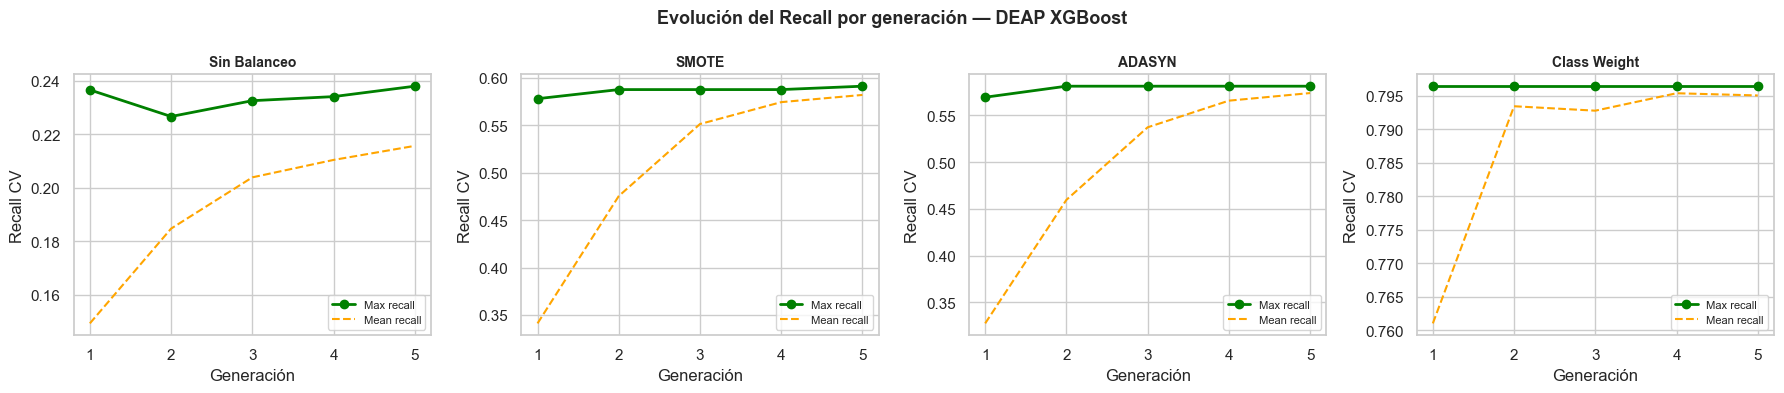

In [42]:
 
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
 
for ax, (tecnica, res) in zip(axes, resultados_deap_xgb.items()):
    historia = res["Historia"]
    gens     = list(range(1, len(historia) + 1))
    maximos  = [g["max"]  for g in historia]
    medios   = [g["mean"] for g in historia]
 
    ax.plot(gens, maximos, color="green",  linewidth=2, marker="o", label="Max recall")
    ax.plot(gens, medios,  color="orange", linewidth=1.5, linestyle="--", label="Mean recall")
    ax.set_title(tecnica, fontsize=10, fontweight="bold")
    ax.set_xlabel("Generación")
    ax.set_ylabel("Recall CV")
    ax.legend(fontsize=8)
    ax.set_xticks(gens)
 
plt.suptitle("Evolución del Recall por generación — DEAP XGBoost",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [44]:
import os
import pickle
import joblib
 
def cargar_resultados(modelo_nombre, metodo):
    """
    Carga resultados desde disco si existen.
 
    Parámetros
    ----------
    modelo_nombre : str
        Nombre del modelo (ej. 'KNN', 'GaussianNB', 'XGBoost').
    metodo : str
        Método de optimización ('Grid', 'Random', 'Optuna', 'DEAP').
 
    Retorna
    -------
    dict con resultados por técnica de balanceo, o None si no existe.
    """
    ruta = (
        f"Modelos_Optimizados_No_Computacional/"
        f"{metodo}_{modelo_nombre}/"
        f"{metodo.lower()}_{modelo_nombre}_resultados.pkl"
    )
 
    if os.path.exists(ruta):
        with open(ruta, "rb") as f:
            resultados = pickle.load(f)
        print(f"  ✓ {metodo} {modelo_nombre} — cargado desde disco")
        return resultados
    else:
        print(f"  ✗ {metodo} {modelo_nombre} — no encontrado, hay que reentrenar")
        return None

In [45]:
print("── Cargando modelos desde disco ──\n")
 
# KNN
print("KNN:")
resultados_gs_knn   = cargar_resultados("KNN", "Grid")
resultados_rs_knn   = cargar_resultados("KNN", "Random")
resultados_op_knn   = cargar_resultados("KNN", "Optuna")
resultados_deap_knn = cargar_resultados("KNN", "DEAP")
 
# Gaussian Naive Bayes
print("\nGaussianNB:")
resultados_gs_gnb   = cargar_resultados("GaussianNB", "Grid")
resultados_rs_gnb   = cargar_resultados("GaussianNB", "Random")
resultados_op_gnb   = cargar_resultados("GaussianNB", "Optuna")
resultados_deap_gnb = cargar_resultados("GaussianNB", "DEAP")
 
# XGBoost
print("\nXGBoost:")
resultados_gs_xgb   = cargar_resultados("XGBoost", "Grid")
resultados_rs_xgb   = cargar_resultados("XGBoost", "Random")
resultados_op_xgb   = cargar_resultados("XGBoost", "Optuna")
resultados_deap_xgb = cargar_resultados("XGBoost", "DEAP")
 

── Cargando modelos desde disco ──

KNN:
  ✓ Grid KNN — cargado desde disco
  ✓ Random KNN — cargado desde disco
  ✓ Optuna KNN — cargado desde disco
  ✓ DEAP KNN — cargado desde disco

GaussianNB:
  ✓ Grid GaussianNB — cargado desde disco
  ✓ Random GaussianNB — cargado desde disco
  ✓ Optuna GaussianNB — cargado desde disco
  ✓ DEAP GaussianNB — cargado desde disco

XGBoost:
  ✓ Grid XGBoost — cargado desde disco
  ✓ Random XGBoost — cargado desde disco
  ✓ Optuna XGBoost — cargado desde disco
  ✓ DEAP XGBoost — cargado desde disco


In [47]:
modelos = {
    "KNN":        [resultados_gs_knn, resultados_rs_knn,
                   resultados_op_knn, resultados_deap_knn],
    "GaussianNB": [resultados_gs_gnb, resultados_rs_gnb,
                   resultados_op_gnb, resultados_deap_gnb],
    "XGBoost":    [resultados_gs_xgb, resultados_rs_xgb,
                   resultados_op_xgb, resultados_deap_xgb],
}
metodos = ["Grid Search", "Random Search", "Optuna", "DEAP"]
 
filas = []
for modelo_nombre, lista in modelos.items():
    for metodo, res in zip(metodos, lista):
        filas.append({
            "Modelo":  modelo_nombre,
            "Método":  metodo,
            "Estado":  "✓ Listo" if res is not None else "✗ Pendiente"
        })
 
estado_df = pd.DataFrame(filas)
display(estado_df)
 
pendientes = estado_df[estado_df["Estado"] == "✗ Pendiente"]
if len(pendientes) == 0:
    print("\n✓ Todos los modelos están cargados. Puedes continuar sin reentrenar.")
else:
    print(f"\n⚠ Hay {len(pendientes)} modelos pendientes de entrenamiento:")
    for _, row in pendientes.iterrows():
        print(f"   - {row['Modelo']} — {row['Método']}")

,Modelo,Método,Estado
0,KNN,Grid Search,✓ Listo
1,KNN,Random Search,✓ Listo
2,KNN,Optuna,✓ Listo
3,KNN,DEAP,✓ Listo
4,GaussianNB,Grid Search,✓ Listo
5,GaussianNB,Random Search,✓ Listo
6,GaussianNB,Optuna,✓ Listo
7,GaussianNB,DEAP,✓ Listo
8,XGBoost,Grid Search,✓ Listo
9,XGBoost,Random Search,✓ Listo



✓ Todos los modelos están cargados. Puedes continuar sin reentrenar.


# **Optimización Computacional**

El objetivo de esta sección es reducir el costo computacional manteniendo o mejorando el desempeño del modelo.

## **KKN**

In [95]:
import faiss
import time
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_is_fitted
from sklearn.neighbors import KNeighborsClassifier
 
 
# =============================================================================
# 1. WRAPPER FAISS
# =============================================================================
 
class FAISSKNNClassifier(BaseEstimator, ClassifierMixin):
    """KNN usando FAISS como motor de búsqueda. API compatible con sklearn."""
 
    def __init__(self, n_neighbors=5, weights="uniform", metric="euclidean"):
        self.n_neighbors = n_neighbors
        self.weights     = weights
        self.metric      = metric
 
    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float32)
        self.classes_        = np.unique(y)
        self.y_train_        = np.asarray(y)
        self.n_features_in_  = X.shape[1]
        self.index_          = faiss.IndexFlatL2(X.shape[1])
        self.index_.add(X)
        return self
 
    def _query(self, X):
        X = np.asarray(X, dtype=np.float32)
        return self.index_.search(X, self.n_neighbors)
 
    def predict(self, X):
        check_is_fitted(self, "index_")
        distances, indices = self._query(X)
        preds = []
        for dists, idxs in zip(distances, indices):
            neighbor_labels = self.y_train_[idxs]
            w = np.ones(len(idxs)) if self.weights == "uniform" \
                else 1.0 / (dists + 1e-10)
            votes = {}
            for lbl, wi in zip(neighbor_labels, w):
                votes[lbl] = votes.get(lbl, 0) + wi
            preds.append(max(votes, key=votes.get))
        return np.array(preds)
 
    def predict_proba(self, X):
        check_is_fitted(self, "index_")
        distances, indices = self._query(X)
        proba = np.zeros((len(distances), len(self.classes_)))
        for i, (dists, idxs) in enumerate(zip(distances, indices)):
            neighbor_labels = self.y_train_[idxs]
            w = np.ones(len(idxs)) if self.weights == "uniform" \
                else 1.0 / (dists + 1e-10)
            for j, cls in enumerate(self.classes_):
                proba[i, j] = w[neighbor_labels == cls].sum()
            proba[i] /= proba[i].sum() + 1e-10
        return proba
 

In [96]:
def knn_factory_kd(params):
    return KNeighborsClassifier(
        n_neighbors=params["n_neighbors"],
        weights=params["weights"],
        metric=params["metric"],
        algorithm="kd_tree",
        n_jobs=-1,
    )
 
def knn_factory_bt(params):
    return KNeighborsClassifier(
        n_neighbors=params["n_neighbors"],
        weights=params["weights"],
        metric=params["metric"],
        algorithm="ball_tree",
        n_jobs=-1,
    )
 
def knn_factory_faiss(params):
    return FAISSKNNClassifier(
        n_neighbors=params["n_neighbors"],
        weights=params["weights"],
        metric=params.get("metric", "euclidean"),
    )

In [97]:
param_grid_kd_bt = {
    "modelo__n_neighbors": list(range(3, 22, 2)),
    "modelo__weights":     ["uniform", "distance"],
    "modelo__metric":      ["euclidean", "manhattan", "minkowski"],
}
 
# FAISS solo soporta L2 → sin metric
param_grid_faiss = {
    "modelo__n_neighbors": list(range(3, 22, 2)),
    "modelo__weights":     ["uniform", "distance"],
}
 
# DEAP
espacio_deap_kd_bt = {
    "n_neighbors": list(range(3, 22, 2)),
    "weights":     ["uniform", "distance"],
    "metric":      ["euclidean", "manhattan", "minkowski"],
}
espacio_deap_faiss = {
    "n_neighbors": list(range(3, 22, 2)),
    "weights":     ["uniform", "distance"],
}
 
# Estimadores de referencia (solo para isinstance en definir_espacio_optuna)
ref_kd    = KNeighborsClassifier(algorithm="kd_tree")
ref_bt    = KNeighborsClassifier(algorithm="ball_tree")
ref_faiss = FAISSKNNClassifier()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# KD-TREE
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "#"*65)
print("  KD-TREE")
print("#"*65)
 
resultados_gs_kd = optimizar_gridsearch(
    modelo_nombre="KNN_kd_tree",
    estimator=knn_factory_kd({"n_neighbors": 5, "weights": "uniform", "metric": "euclidean"}),
    param_grid=param_grid_kd_bt,
    X_train=X_train_knn,
    y_train=y_train_knn,
    cv=cv_knn,
    escalado=True,
    scoring="recall",
)
 
resultados_rs_kd = optimizar_randomsearch(
    modelo_nombre="KNN_kd_tree",
    estimator=knn_factory_kd({"n_neighbors": 5, "weights": "uniform", "metric": "euclidean"}),
    param_distributions=param_grid_kd_bt,
    X_train=X_train_knn,
    y_train=y_train_knn,
    cv=cv_knn,
    escalado=True,
    scoring="recall",
    n_iter=30,
)
 
resultados_op_kd = optimizar_optuna(
    modelo_nombre="KNN_kd_tree",
    estimator=ref_kd,
    model_factory=knn_factory_kd,
    X_train=X_train_knn,
    y_train=y_train_knn,
    cv=cv_knn,
    escalado=True,
    n_trials=30,
    scoring="recall",
)
 
resultados_deap_kd = optimizar_deap(
    modelo_nombre="KNN_kd_tree",
    estimator=ref_kd,
    model_factory=knn_factory_kd,
    espacio=espacio_deap_kd_bt,
    X_train=X_train_knn,
    y_train=y_train_knn,
    cv=cv_knn,
    escalado=True,
    n_generaciones=5,
    tam_poblacion=20,
    scoring="recall",
)
 
# ─────────────────────────────────────────────────────────────────────────────
# BALL-TREE
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "#"*65)
print("  BALL-TREE")
print("#"*65)
 
resultados_gs_bt = optimizar_gridsearch(
    modelo_nombre="KNN_ball_tree",
    estimator=knn_factory_bt({"n_neighbors": 5, "weights": "uniform", "metric": "euclidean"}),
    param_grid=param_grid_kd_bt,
    X_train=X_train_knn,
    y_train=y_train_knn,
    cv=cv_knn,
    escalado=True,
    scoring="recall",
)
 
resultados_rs_bt = optimizar_randomsearch(
    modelo_nombre="KNN_ball_tree",
    estimator=knn_factory_bt({"n_neighbors": 5, "weights": "uniform", "metric": "euclidean"}),
    param_distributions=param_grid_kd_bt,
    X_train=X_train_knn,
    y_train=y_train_knn,
    cv=cv_knn,
    escalado=True,
    scoring="recall",
    n_iter=30,
)
 
resultados_op_bt = optimizar_optuna(
    modelo_nombre="KNN_ball_tree",
    estimator=ref_bt,
    model_factory=knn_factory_bt,
    X_train=X_train_knn,
    y_train=y_train_knn,
    cv=cv_knn,
    escalado=True,
    n_trials=30,
    scoring="recall",
)
 
resultados_deap_bt = optimizar_deap(
    modelo_nombre="KNN_ball_tree",
    estimator=ref_bt,
    model_factory=knn_factory_bt,
    espacio=espacio_deap_kd_bt,
    X_train=X_train_knn,
    y_train=y_train_knn,
    cv=cv_knn,
    escalado=True,
    n_generaciones=5,
    tam_poblacion=20,
    scoring="recall",
)
 
# ─────────────────────────────────────────────────────────────────────────────
# FAISS
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "#"*65)
print("  FAISS")
print("#"*65)
 
resultados_gs_faiss = optimizar_gridsearch(
    modelo_nombre="KNN_faiss",
    estimator=knn_factory_faiss({"n_neighbors": 5, "weights": "uniform"}),
    param_grid=param_grid_faiss,
    X_train=X_train_knn,
    y_train=y_train_knn,
    cv=cv_knn,
    escalado=True,
    scoring="recall",
)
 
resultados_rs_faiss = optimizar_randomsearch(
    modelo_nombre="KNN_faiss",
    estimator=knn_factory_faiss({"n_neighbors": 5, "weights": "uniform"}),
    param_distributions=param_grid_faiss,
    X_train=X_train_knn,
    y_train=y_train_knn,
    cv=cv_knn,
    escalado=True,
    scoring="recall",
    n_iter=30,
)
 
resultados_op_faiss = optimizar_optuna(
    modelo_nombre="KNN_faiss",
    estimator=ref_faiss,          
    model_factory=knn_factory_faiss,
    X_train=X_train_knn,
    y_train=y_train_knn,
    cv=cv_knn,
    escalado=True,
    n_trials=30,
    scoring="recall",
)
 
resultados_deap_faiss = optimizar_deap(
    modelo_nombre="KNN_faiss",
    estimator=ref_faiss,
    model_factory=knn_factory_faiss,
    espacio=espacio_deap_faiss,
    X_train=X_train_knn,
    y_train=y_train_knn,
    cv=cv_knn,
    escalado=True,
    n_generaciones=5,
    tam_poblacion=20,
    scoring="recall",
)
 
 
# =============================================================================
# 5. BENCHMARK DE VELOCIDAD — búsqueda pura (sin clasificación)
# =============================================================================
 
def benchmark_velocidad(X_train, y_train, X_test, n_neighbors=5, reps=10):
    """
    Mide solo el tiempo de búsqueda de vecinos.
    Compara FAISS, KD-Tree y Ball-Tree sobre los mismos datos escalados.
    """
    from sklearn.preprocessing import StandardScaler
 
    scaler = StandardScaler()
    Xtr    = scaler.fit_transform(X_train).astype(np.float32)
    Xte    = scaler.transform(X_test).astype(np.float32)
 
    resultados = []
 
    # FAISS
    idx = faiss.IndexFlatL2(Xtr.shape[1])
    idx.add(Xtr)
    tiempos = []
    for _ in range(reps):
        t0 = time.perf_counter()
        idx.search(Xte, n_neighbors)
        tiempos.append(time.perf_counter() - t0)
    resultados.append({
        "Motor":            "FAISS IndexFlatL2",
        "Tiempo medio (s)": np.mean(tiempos),
        "Std (s)":          np.std(tiempos),
    })
 
    # KD-Tree
    knn_kd = KNeighborsClassifier(algorithm="kd_tree",
                                   n_neighbors=n_neighbors, n_jobs=-1)
    knn_kd.fit(Xtr, y_train)
    tiempos = []
    for _ in range(reps):
        t0 = time.perf_counter()
        knn_kd.kneighbors(Xte)
        tiempos.append(time.perf_counter() - t0)
    resultados.append({
        "Motor":            "sklearn KD-Tree",
        "Tiempo medio (s)": np.mean(tiempos),
        "Std (s)":          np.std(tiempos),
    })
 
    # Ball-Tree
    knn_bt = KNeighborsClassifier(algorithm="ball_tree",
                                   n_neighbors=n_neighbors, n_jobs=-1)
    knn_bt.fit(Xtr, y_train)
    tiempos = []
    for _ in range(reps):
        t0 = time.perf_counter()
        knn_bt.kneighbors(Xte)
        tiempos.append(time.perf_counter() - t0)
    resultados.append({
        "Motor":            "sklearn Ball-Tree",
        "Tiempo medio (s)": np.mean(tiempos),
        "Std (s)":          np.std(tiempos),
    })
 
    df = pd.DataFrame(resultados)
    ref = df.loc[df["Motor"] == "sklearn KD-Tree", "Tiempo medio (s)"].values[0]
    df["Speedup vs KD-Tree"] = (ref / df["Tiempo medio (s)"]).round(2)
    return df.round(6)
 
 
print("\n" + "="*65)
print("BENCHMARK DE VELOCIDAD")
print("="*65)
df_speed = benchmark_velocidad(X_train_knn, y_train_knn, X_test, n_neighbors=5)
display(df_speed)


#################################################################
  KD-TREE
#################################################################
Grid Search — KNN_kd_tree — Sin Balanceo

Fitting 3 folds for each of 60 candidates, totalling 180 fits
Tiempo: 630.83s | Mejor recall CV: 0.3890
Mejores params: {'modelo__metric': 'euclidean', 'modelo__n_neighbors': 3, 'modelo__weights': 'distance'}

Grid Search — KNN_kd_tree — SMOTE

Fitting 3 folds for each of 60 candidates, totalling 180 fits
Tiempo: 926.38s | Mejor recall CV: 0.8088
Mejores params: {'modelo__metric': 'euclidean', 'modelo__n_neighbors': 21, 'modelo__weights': 'distance'}

Grid Search — KNN_kd_tree — ADASYN

Fitting 3 folds for each of 60 candidates, totalling 180 fits
Tiempo: 840.46s | Mejor recall CV: 0.8387
Mejores params: {'modelo__metric': 'euclidean', 'modelo__n_neighbors': 21, 'modelo__weights': 'uniform'}

Grid Search — KNN_kd_tree — Class Weight

Fitting 3 folds for each of 60 candidates, totalling 180 fits
Tiempo: 7

  0%|          | 0/30 [00:00<?, ?it/s]


Tiempo: 260.16s | Mejor recall CV: 0.3890
Mejores params: {'n_neighbors': 3, 'weights': 'distance', 'metric': 'euclidean'}


Optuna — KNN_kd_tree — SMOTE


  0%|          | 0/30 [00:00<?, ?it/s]

### **Resultados**

In [ ]:
def tabla_comparativa_knn(scoring="recall"):
    """
    Consolida todos los resultados (no computacional + computacional)
    en una sola tabla ordenada por Test Recall.
    """
    # Sección no computacional (sección 2 — los que ya tenías)
    no_comp = {
        **{f"Grid — KNN brute — {k}":   v for k, v in resultados_gs_knn.items()},
        **{f"Random — KNN brute — {k}": v for k, v in resultados_rs_knn.items()},
        **{f"Optuna — KNN brute — {k}": v for k, v in resultados_op_knn.items()},
        **{f"DEAP — KNN brute — {k}":   v for k, v in resultados_deap_knn.items()},
    }
 
    # Sección computacional (sección 3 — los nuevos)
    comp = {
        **{f"Grid — KNN kd_tree — {k}":    v for k, v in resultados_gs_kd.items()},
        **{f"Random — KNN kd_tree — {k}":  v for k, v in resultados_rs_kd.items()},
        **{f"Optuna — KNN kd_tree — {k}":  v for k, v in resultados_op_kd.items()},
        **{f"DEAP — KNN kd_tree — {k}":    v for k, v in resultados_deap_kd.items()},
        **{f"Grid — KNN ball_tree — {k}":   v for k, v in resultados_gs_bt.items()},
        **{f"Random — KNN ball_tree — {k}": v for k, v in resultados_rs_bt.items()},
        **{f"Optuna — KNN ball_tree — {k}": v for k, v in resultados_op_bt.items()},
        **{f"DEAP — KNN ball_tree — {k}":   v for k, v in resultados_deap_bt.items()},
        **{f"Grid — KNN faiss — {k}":       v for k, v in resultados_gs_faiss.items()},
        **{f"Random — KNN faiss — {k}":     v for k, v in resultados_rs_faiss.items()},
        **{f"Optuna — KNN faiss — {k}":     v for k, v in resultados_op_faiss.items()},
        **{f"DEAP — KNN faiss — {k}":       v for k, v in resultados_deap_faiss.items()},
    }
 
    filas = []
    for label, datos in {**no_comp, **comp}.items():
        filas.append({
            "Modelo":              label,
            "Test Recall":         datos.get("Test Recall"),
            "Test Precision":      datos.get("Test Precision"),
            "Test F1":             datos.get("Test F1"),
            "Test ROC AUC":        datos.get("Test ROC AUC"),
            f"Mejor {scoring} CV": datos.get(f"Mejor {scoring} CV"),
            "Tiempo (s)":          datos.get("Tiempo (s)"),
            "Iteraciones":         datos.get("Iteraciones"),
        })
 
    return (pd.DataFrame(filas)
              .sort_values("Test Recall", ascending=False)
              .reset_index(drop=True)
              .round(4))
 
 
print("\n" + "="*65)
print("TABLA COMPARATIVA FINAL")
print("="*65)
df_comparativa = tabla_comparativa_knn(scoring="recall")
display(df_comparativa)
 
df_comparativa.to_csv(
    "Modelos_Optimizados_Computacional/KNN/tabla_comparativa_knn.csv",
    index=False
)
 

## **Naive Bayes**

### **Resultados**

## **XGBoost**

### **Resultados**

# **Optimización estadística**

## **14. Referencias bibliograficas**



1. Centers for Disease Control and Prevention. (2024). *About diabetes*. U.S. Department of Health & Human Services. https://www.cdc.gov/diabetes/about/index.html

2. Centers for Disease Control and Prevention. (2024). *Behavioral Risk Factor Surveillance System (BRFSS)*. U.S. Department of Health & Human Services. https://www.cdc.gov/brfss/index.html

3. International Diabetes Federation. (2024). *IDF Diabetes Atlas – United States of America*. https://diabetesatlas.org/es/data-by-location/country/united-states-of-america/

4. MedlinePlus. (2024). *Diabetes*. Biblioteca Nacional de Medicina de EE. UU. https://medlineplus.gov/spanish/diabetes.html

5. American Diabetes Association. (2024). *Standards of care in diabetes*. https://diabetes.org/

6. IBM. (s.f.). ¿Qué es el algoritmo de k vecinos más cercanos (KNN)? https://www.ibm.com/mx-es/think/topics/knn

7. IBM. (s.f.). ¿Qué es un random forest? https://www.ibm.com/mx-es/think/topics/random-forest

8. IBM. (s.f.). ¿Qué es una máquina de vectores de soporte (SVM)? https://www.ibm.com/es-es/think/topics/support-vector-machine

9. IBM. (s.f.). ¿Qué es la regresión logística? https://www.ibm.com/es-es/think/topics/logistic-regression

10. IBM. (s.f.). ¿Qué es XGBoost? https://www.ibm.com/es-es/think/topics/xgboost

11. Aprende Machine Learning. (s.f.). Clasificación con datos desbalanceados. https://www.aprendemachinelearning.com/clasificacion-con-datos-desbalanceados/

12. GeeksforGeeks. (2025). Validación cruzada K-fold estratificada. https://www.geeksforgeeks.org/stratified-k-fold-cross-validation/

13. IBM. (s.f.). ¿Qué es un pipeline de machine learning? https://www.ibm.com/es-es/think/topics/machine-learning-pipeline

14. DataCamp. (2024). AUC y la curva ROC en aprendizaje automático. https://www.datacamp.com/tutorial/auc

15. IBM. (2026). Threshold tuning. https://www.ibm.com/docs/en/omegamon-for-storage

16. International Business Machines Corporation. (s.f.). ¿Qué son los clasificadores Naive Bayes? IBM. https://www.ibm.com/es-es/think/topics/naive-bayes

17. International Business Machines Corporation. (s.f.). ¿Qué es un árbol de decisión? IBM. https://www.ibm.com/es-es/think/topics/decision-trees

18. Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). SMOTE: Synthetic minority over-sampling technique. Journal of Artificial Intelligence Research, 16, 321–357.

19. He, H., Bai, Y., Garcia, E. A., & Li, S. (2008). ADASYN: Adaptive synthetic sampling approach for imbalanced learning. En Proceedings of the IEEE International Joint Conference on Neural Networks (IJCNN) (pp. 1322–1328). IEEE.

20. Akiba, T., Sano, S., Yanase, T., Ohta, T., & Koyama, M. (2019). Optuna: A next-generation hyperparameter optimization framework. En Proceedings of the 25th ACM SIGKDD International Conference on Knowledge Discovery & Data Mining (pp. 2623–2631). ACM

21. Fortin, F.-M., De Rainville, F.-M., Gardner, M.-A., Parizeau, M., & Gagné, C. (2012). DEAP: Evolutionary algorithms made easy. Journal of Machine Learning Research, 13, 2171–2175.

22. Scikit-learn developers. (2024). Pipelines and composite estimators. Scikit-learn. https://scikit-learn.org/stable/modules/pipeline.html

23. DeLong, E. R., DeLong, D. M., & Clarke-Pearson, D. L. (1988). Comparing the areas under two or more correlated receiver operating characteristic curves: A nonparametric approach. Biometrics, 44(3), 837–845. https://doi.org/10.2307/2531595

24. Efron, B., & Tibshirani, R. J. (1993). An introduction to the bootstrap. Chapman & Hall/CRC.
